In [51]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import skimage
import scipy
from IPython.display import display, HTML
from scipy import stats
display(HTML("<style>.container { width:85% !important; }</style>"))

def fmt_p(p):
    """Full-precision p-value; scientific notation below 0.0001."""
    if p is None or np.isnan(p):
        return '     n/a'
    if p < 0.0001:
        return f'{p:.3e}'
    return f'{p:.4f}'

def get_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

Load data

In [2]:
agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B', '31R2', '29L2']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
full_data = pd.read_pickle('multifiber.pickle')
# region and indexing-related variables / functions
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
    'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
    'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
    'PA (E)', 'PA (I)', 'NAc (DA)'] # populations
indices = {val: idx for idx, val in enumerate(region_ids)} # dictionary with IDs for remapping

# subjects 1185, 1162B, 1162L2, and 1162R belong to an independent held-out cohort (collected after initial model tuning) recorded
# with a distinct optical fiber bundle, resulting in altered baseline variance and SNR profiles. unnormalized traces caused
# convergence failure during time-shift optimization. this was resolved via re-z-scoring the traces for these subjects, which was performed
# solely to stabilize the loss landscape and enable proper parameter convergence.

keys_2_change = [x for x in full_data.keys() if '1185' in x or '1162' in x]
for k in keys_2_change:
    session = full_data[k]
    for population in region_ids:
        trace = session[population].values
        trace = stats.zscore(trace)
        session[population] = trace
    full_data[k] = session

Multifiber showcase

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\719216027.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


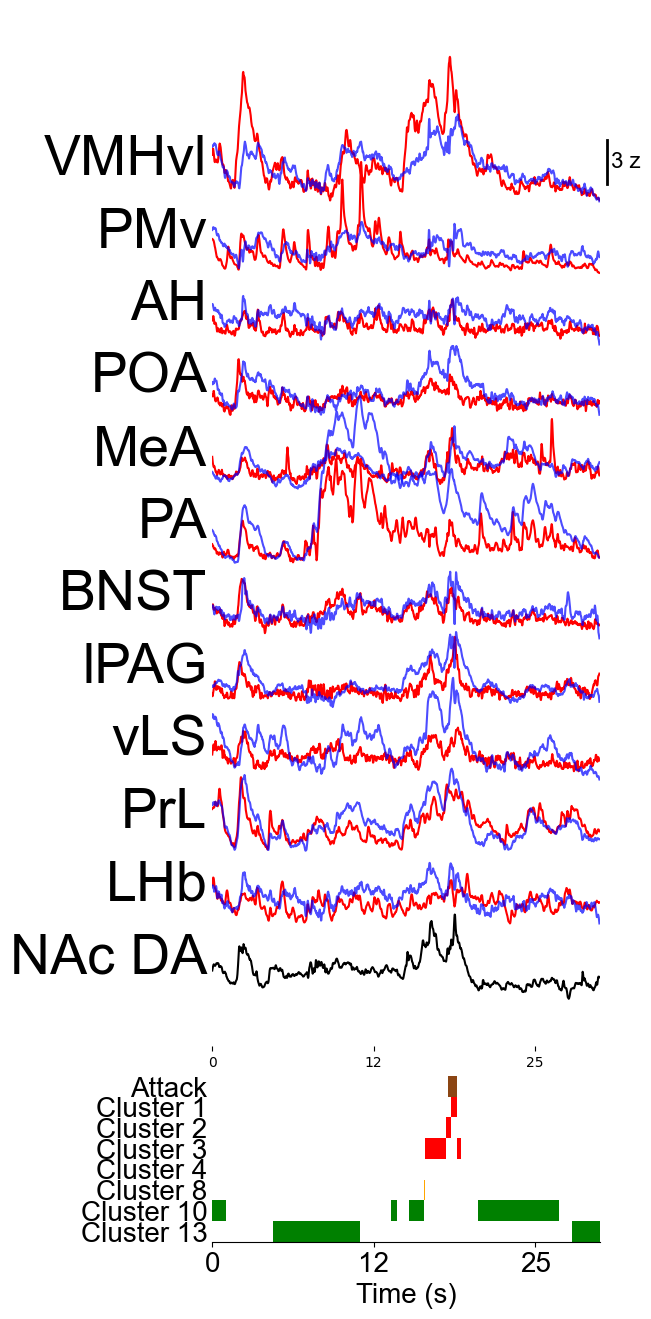

In [3]:
# Animal 1: EXP from training period

import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
sample = full_data['30L_d2_balbc_t2']

# Region order, top-to-bottom as requested. Each entry is
# (label, E_column_idx, I_column_idx) — NAc DA has no I channel (None).
region_order_top_to_bottom = [
    ('VMHvl', 12, 13),
    ('PMv',   16, 17),
    ('AH',     8,  9),
    ('POA',    4,  5),
    ('MeA',   10, 11),
    ('PA',    20, 21),
    ('BNST',   6,  7),
    ('lPAG',  14, 15),
    ('vLS',    2,  3),
    ('PrL',    0,  1),
    ('LHb',   18, 19),
    ('NAc DA', 22, None),
]

scale = 5
range_of_values = [2000, 3200]  # 2500-frame window
n_frames = range_of_values[1] - range_of_values[0]
n_regions = len(region_order_top_to_bottom)

# ── Behaviors for the barcode strip, aligned to the same frame window ────────
behaviors_to_plot = [('Attack', sample['attack labels'].values)]
target_clusters = [1, 2, 3, 4, 8, 10, 13]
cluster_labels_full = sample['unsupervised labels'].values
for c in target_clusters:
    behaviors_to_plot.append((f'Cluster {c}', (cluster_labels_full == c).astype(int)))

n_behaviors = len(behaviors_to_plot)

fig = plt.figure(figsize=(5, 16))
gs = gridspec.GridSpec(2, 1, height_ratios=[20, n_behaviors * 0.4], hspace=0.05)

# ── Top: neural traces, ordered per region_order_top_to_bottom ───────────────
ax_traces = fig.add_subplot(gs[0])
indices = []

for pos, (label, e_idx, i_idx) in enumerate(region_order_top_to_bottom):
    # First entry (position 0) goes at the TOP of the plot, so it gets the
    # largest y-offset; last entry gets the smallest.
    y_offset = (n_regions - 1 - pos) * scale
    indices.append(y_offset)

    e_column = sample.columns[e_idx]
    e_trace = sample[e_column].values[range_of_values[0]:range_of_values[1]]
    e_color = 'black' if i_idx is None else 'red'  # DA channel drawn black
    ax_traces.plot(e_trace + y_offset, color=e_color, linewidth=1.5)

    if i_idx is not None:
        i_column = sample.columns[i_idx]
        i_trace = sample[i_column].values[range_of_values[0]:range_of_values[1]]
        ax_traces.plot(i_trace + y_offset, color='blue', linewidth=1.5, alpha=0.7)

ax_traces.set_yticks(np.array(indices) + 2)
ax_traces.set_yticklabels([label for label, _, _ in region_order_top_to_bottom],
                          fontsize=40, fontfamily='Arial')
ax_traces.set_xticks([])
ax_traces.set_xlim(0, n_frames)
ax_traces.tick_params(axis='y', which='both', length=0)
sns.despine(ax=ax_traces, bottom=True, left=True)

# ── Z-value scale bar, next to the VMHvl trace (top row) ─────────────────────
vmhvl_y_offset = (n_regions - 1 - 0) * scale  # position 0 = VMHvl (top)
scale_bar_x = n_frames * 1.02
scale_bar_height = 3  # z-units

ax_traces.plot([scale_bar_x, scale_bar_x],
               [vmhvl_y_offset, vmhvl_y_offset + scale_bar_height],
               color='black', linewidth=2, clip_on=False)
ax_traces.text(scale_bar_x * 1.01, vmhvl_y_offset + scale_bar_height / 2,
               '3 z', ha='left', va='center', fontsize=16, fontfamily='Arial')

# ── Bottom: behavior barcode strip, x-aligned with the traces above ──────────
ax_barcode = fig.add_subplot(gs[1], sharex=ax_traces)

barcode_colors = {
    'Attack':     '#8B4513',  # brown
    'Cluster 1':  '#FF0000',  # red
    'Cluster 2':  '#FF0000',
    'Cluster 3':  '#FF0000',
    'Cluster 4':  '#FF0000',
    'Cluster 8':  '#FFA500',  # orange
    'Cluster 10': '#008000',  # green
    'Cluster 13': '#008000',
}

# Build an RGBA image manually: one colored row per behavior, transparent
# where the behavior is off (0), opaque in its assigned color where on (1).
rgba_image = np.ones((n_behaviors, n_frames, 4))  # start fully white/opaque
for row_idx, (label, vals) in enumerate(behaviors_to_plot):
    seg = vals[range_of_values[0]:range_of_values[1]]
    color_rgb = mcolors.to_rgb(barcode_colors[label])
    on_mask = seg == 1
    rgba_image[row_idx, on_mask, 0] = color_rgb[0]
    rgba_image[row_idx, on_mask, 1] = color_rgb[1]
    rgba_image[row_idx, on_mask, 2] = color_rgb[2]
    rgba_image[row_idx, on_mask, 3] = 1.0
    rgba_image[row_idx, ~on_mask, 3] = 1.0  # keep off-frames opaque white

ax_barcode.imshow(rgba_image, aspect='auto', interpolation='none')

ax_barcode.set_yticks(np.arange(n_behaviors))
ax_barcode.set_yticklabels([label for label, _ in behaviors_to_plot],
                           fontsize=20, fontfamily='Arial')
ax_barcode.set_xticks(np.arange(0, n_frames, 500))
ax_barcode.set_xticklabels((np.arange(0, n_frames, 500) / 40).astype(int),
                           fontsize=20, fontfamily='Arial')
ax_barcode.set_xlabel('Time (s)', fontsize=20, fontfamily='Arial')
ax_barcode.tick_params(axis='y', which='both', length=0)
sns.despine(ax=ax_barcode, left=True)

plt.tight_layout()
plt.savefig('./figures/EXP_trainingPeriod_activity_with_barcode.svg', dpi=600, bbox_inches='tight')
plt.show()

# ── Source data export: 2d_left ───────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []

# Neural traces — one row per region per channel per frame
for pos, (label, e_idx, i_idx) in enumerate(region_order_top_to_bottom):
    e_column = sample.columns[e_idx]
    e_trace = sample[e_column].values[range_of_values[0]:range_of_values[1]]
    for frame_idx, v in enumerate(e_trace):
        rows.append({
            'signal_type': 'trace',
            'region': label,
            'channel': 'DA' if i_idx is None else 'E',
            'frame': frame_idx,
            'value': v,
        })

    if i_idx is not None:
        i_column = sample.columns[i_idx]
        i_trace = sample[i_column].values[range_of_values[0]:range_of_values[1]]
        for frame_idx, v in enumerate(i_trace):
            rows.append({
                'signal_type': 'trace',
                'region': label,
                'channel': 'I',
                'frame': frame_idx,
                'value': v,
            })

# Behavior barcode — one row per behavior per frame
for label, vals in behaviors_to_plot:
    seg = vals[range_of_values[0]:range_of_values[1]]
    for frame_idx, v in enumerate(seg):
        rows.append({
            'signal_type': 'behavior',
            'region': label,
            'channel': np.nan,
            'frame': frame_idx,
            'value': v,
        })

sourceData_2d_left = pd.DataFrame(rows)
sourceData_2d_left['session'] = '30L_d2_balbc_t2'
sourceData_2d_left.to_csv('./sourceData/2d_left.csv', index=False)

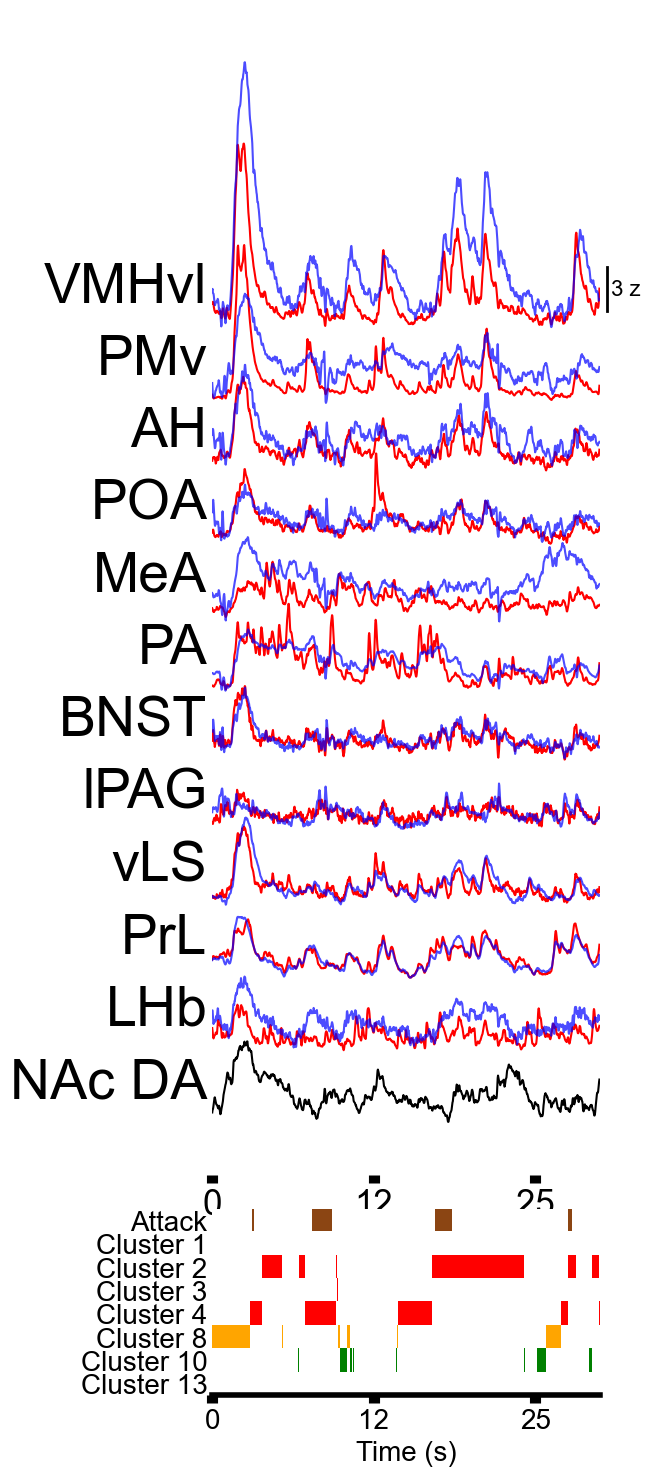

In [232]:
# Animal 2: OBS from training period

sample = full_data['30R2_d2_obs_t1']

# Region order, top-to-bottom as requested. Each entry is
# (label, E_column_idx, I_column_idx) — NAc DA has no I channel (None).
region_order_top_to_bottom = [
    ('VMHvl', 12, 13),
    ('PMv',   16, 17),
    ('AH',     8,  9),
    ('POA',    4,  5),
    ('MeA',   10, 11),
    ('PA',    20, 21),
    ('BNST',   6,  7),
    ('lPAG',  14, 15),
    ('vLS',    2,  3),
    ('PrL',    0,  1),
    ('LHb',   18, 19),
    ('NAc DA', 22, None),
]

scale = 5
range_of_values = [2000, 3200]  # 2500-frame window
n_frames = range_of_values[1] - range_of_values[0]
n_regions = len(region_order_top_to_bottom)

# ── Behaviors for the barcode strip, aligned to the same frame window ────────
behaviors_to_plot = [('Attack', sample['attack labels'].values)]
target_clusters = [1, 2, 3, 4, 8, 10, 13]
cluster_labels_full = sample['unsupervised labels'].values
for c in target_clusters:
    behaviors_to_plot.append((f'Cluster {c}', (cluster_labels_full == c).astype(int)))

n_behaviors = len(behaviors_to_plot)

fig = plt.figure(figsize=(5, 18))
gs = gridspec.GridSpec(2, 1, height_ratios=[20, n_behaviors * 0.4], hspace=0.05)

# ── Top: neural traces, ordered per region_order_top_to_bottom ───────────────
ax_traces = fig.add_subplot(gs[0])
indices = []

for pos, (label, e_idx, i_idx) in enumerate(region_order_top_to_bottom):
    # First entry (position 0) goes at the TOP of the plot, so it gets the
    # largest y-offset; last entry gets the smallest.
    y_offset = (n_regions - 1 - pos) * scale
    indices.append(y_offset)

    e_column = sample.columns[e_idx]
    e_trace = sample[e_column].values[range_of_values[0]:range_of_values[1]]
    e_color = 'black' if i_idx is None else 'red'  # DA channel drawn black
    ax_traces.plot(e_trace + y_offset, color=e_color, linewidth=1.5)

    if i_idx is not None:
        i_column = sample.columns[i_idx]
        i_trace = sample[i_column].values[range_of_values[0]:range_of_values[1]]
        ax_traces.plot(i_trace + y_offset, color='blue', linewidth=1.5, alpha=0.7)

ax_traces.set_yticks(np.array(indices) + 2)
ax_traces.set_yticklabels([label for label, _, _ in region_order_top_to_bottom],
                          fontsize=40, fontfamily='Arial')
ax_traces.set_xticks([])
ax_traces.set_xlim(0, n_frames)
ax_traces.tick_params(axis='y', which='both', length=0)
sns.despine(ax=ax_traces, bottom=True, left=True)

# ── Z-value scale bar, next to the VMHvl trace (top row) ─────────────────────
vmhvl_y_offset = (n_regions - 1 - 0) * scale  # position 0 = VMHvl (top)
scale_bar_x = n_frames * 1.02
scale_bar_height = 3  # z-units

ax_traces.plot([scale_bar_x, scale_bar_x],
               [vmhvl_y_offset, vmhvl_y_offset + scale_bar_height],
               color='black', linewidth=2, clip_on=False)
ax_traces.text(scale_bar_x * 1.01, vmhvl_y_offset + scale_bar_height / 2,
               '3 z', ha='left', va='center', fontsize=16, fontfamily='Arial')

# ── Bottom: behavior barcode strip, x-aligned with the traces above ──────────
ax_barcode = fig.add_subplot(gs[1], sharex=ax_traces)

barcode_colors = {
    'Attack':     '#8B4513',  # brown
    'Cluster 1':  '#FF0000',  # red
    'Cluster 2':  '#FF0000',
    'Cluster 3':  '#FF0000',
    'Cluster 4':  '#FF0000',
    'Cluster 8':  '#FFA500',  # orange
    'Cluster 10': '#008000',  # green
    'Cluster 13': '#008000',
}

# Build an RGBA image manually: one colored row per behavior, transparent
# where the behavior is off (0), opaque in its assigned color where on (1).
rgba_image = np.ones((n_behaviors, n_frames, 4))  # start fully white/opaque
for row_idx, (label, vals) in enumerate(behaviors_to_plot):
    seg = vals[range_of_values[0]:range_of_values[1]]
    color_rgb = mcolors.to_rgb(barcode_colors[label])
    on_mask = seg == 1
    rgba_image[row_idx, on_mask, 0] = color_rgb[0]
    rgba_image[row_idx, on_mask, 1] = color_rgb[1]
    rgba_image[row_idx, on_mask, 2] = color_rgb[2]
    rgba_image[row_idx, on_mask, 3] = 1.0
    rgba_image[row_idx, ~on_mask, 3] = 1.0  # keep off-frames opaque white

ax_barcode.imshow(rgba_image, aspect='auto', interpolation='none')

ax_barcode.set_yticks(np.arange(n_behaviors))
ax_barcode.set_yticklabels([label for label, _ in behaviors_to_plot],
                           fontsize=20, fontfamily='Arial')
ax_barcode.set_xticks(np.arange(0, n_frames, 500))
ax_barcode.set_xticklabels((np.arange(0, n_frames, 500) / 40).astype(int),
                           fontsize=20, fontfamily='Arial')
ax_barcode.set_xlabel('Time (s)', fontsize=20, fontfamily='Arial')
ax_barcode.tick_params(axis='y', which='both', length=0)
sns.despine(ax=ax_barcode, left=True)

plt.tight_layout()
plt.savefig('./figures/OBS_trainingPeriod_activity_with_barcode.svg', dpi=600, bbox_inches='tight')
plt.show()

# ── Source data export: 2d_left ───────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []

# Neural traces — one row per region per channel per frame
for pos, (label, e_idx, i_idx) in enumerate(region_order_top_to_bottom):
    e_column = sample.columns[e_idx]
    e_trace = sample[e_column].values[range_of_values[0]:range_of_values[1]]
    for frame_idx, v in enumerate(e_trace):
        rows.append({
            'signal_type': 'trace',
            'region': label,
            'channel': 'DA' if i_idx is None else 'E',
            'frame': frame_idx,
            'value': v,
        })

    if i_idx is not None:
        i_column = sample.columns[i_idx]
        i_trace = sample[i_column].values[range_of_values[0]:range_of_values[1]]
        for frame_idx, v in enumerate(i_trace):
            rows.append({
                'signal_type': 'trace',
                'region': label,
                'channel': 'I',
                'frame': frame_idx,
                'value': v,
            })

# Behavior barcode — one row per behavior per frame
for label, vals in behaviors_to_plot:
    seg = vals[range_of_values[0]:range_of_values[1]]
    for frame_idx, v in enumerate(seg):
        rows.append({
            'signal_type': 'behavior',
            'region': label,
            'channel': np.nan,
            'frame': frame_idx,
            'value': v,
        })

sourceData_2d_left = pd.DataFrame(rows)
sourceData_2d_left['session'] = '30R2_d2_obs_t1'
sourceData_2d_left.to_csv('./sourceData/2d_middle.csv', index=False)

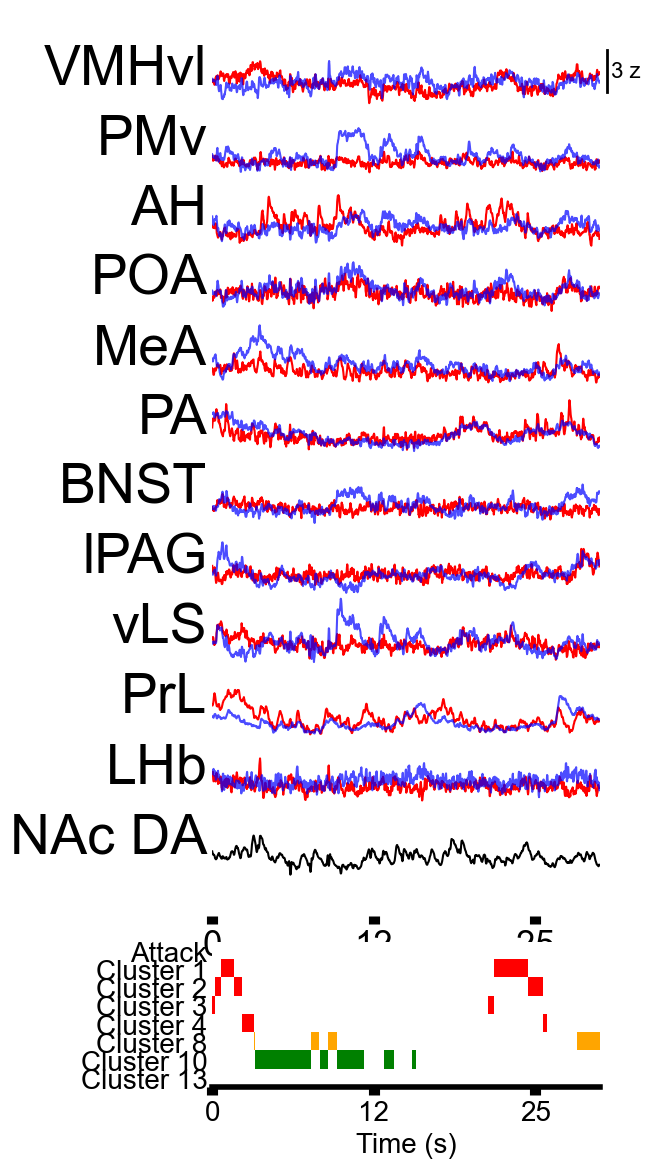

In [233]:
# Animal 3: NON from training period

sample = full_data['87L_d4_toy_t1']
scale = 5
range_of_values = [4500, 5700]  # 2500-frame window
n_frames = range_of_values[1] - range_of_values[0]
n_regions = len(region_order_top_to_bottom)

# ── Behaviors for the barcode strip, aligned to the same frame window ────────
behaviors_to_plot = [('Attack', sample['attack labels'].values)]
target_clusters = [1, 2, 3, 4, 8, 10, 13]
cluster_labels_full = sample['unsupervised labels'].values
for c in target_clusters:
    behaviors_to_plot.append((f'Cluster {c}', (cluster_labels_full == c).astype(int)))

n_behaviors = len(behaviors_to_plot)

fig = plt.figure(figsize=(5, 14))
gs = gridspec.GridSpec(2, 1, height_ratios=[20, n_behaviors * 0.4], hspace=0.05)

# ── Top: neural traces, ordered per region_order_top_to_bottom ───────────────
ax_traces = fig.add_subplot(gs[0])
indices = []

for pos, (label, e_idx, i_idx) in enumerate(region_order_top_to_bottom):
    # First entry (position 0) goes at the TOP of the plot, so it gets the
    # largest y-offset; last entry gets the smallest.
    y_offset = (n_regions - 1 - pos) * scale
    indices.append(y_offset)

    e_column = sample.columns[e_idx]
    e_trace = sample[e_column].values[range_of_values[0]:range_of_values[1]]
    e_color = 'black' if i_idx is None else 'red'  # DA channel drawn black
    ax_traces.plot(e_trace + y_offset, color=e_color, linewidth=1.5)

    if i_idx is not None:
        i_column = sample.columns[i_idx]
        i_trace = sample[i_column].values[range_of_values[0]:range_of_values[1]]
        ax_traces.plot(i_trace + y_offset, color='blue', linewidth=1.5, alpha=0.7)

ax_traces.set_yticks(np.array(indices) + 2)
ax_traces.set_yticklabels([label for label, _, _ in region_order_top_to_bottom],
                          fontsize=40, fontfamily='Arial')
ax_traces.set_xticks([])
ax_traces.set_xlim(0, n_frames)
ax_traces.tick_params(axis='y', which='both', length=0)
sns.despine(ax=ax_traces, bottom=True, left=True)

# ── Z-value scale bar, next to the VMHvl trace (top row) ─────────────────────
vmhvl_y_offset = (n_regions - 1 - 0) * scale  # position 0 = VMHvl (top)
scale_bar_x = n_frames * 1.02
scale_bar_height = 3  # z-units

ax_traces.plot([scale_bar_x, scale_bar_x],
               [vmhvl_y_offset, vmhvl_y_offset + scale_bar_height],
               color='black', linewidth=2, clip_on=False)
ax_traces.text(scale_bar_x * 1.01, vmhvl_y_offset + scale_bar_height / 2,
               '3 z', ha='left', va='center', fontsize=16, fontfamily='Arial')

# ── Bottom: behavior barcode strip, per-row colored ───────────────────────────
ax_barcode = fig.add_subplot(gs[1], sharex=ax_traces)

barcode_colors = {
    'Attack':     '#8B4513',  # brown
    'Cluster 1':  '#FF0000',  # red
    'Cluster 2':  '#FF0000',
    'Cluster 3':  '#FF0000',
    'Cluster 4':  '#FF0000',
    'Cluster 8':  '#FFA500',  # orange
    'Cluster 10': '#008000',  # green
    'Cluster 13': '#008000',
}

# Build an RGBA image manually: one colored row per behavior, transparent
# where the behavior is off (0), opaque in its assigned color where on (1).
rgba_image = np.ones((n_behaviors, n_frames, 4))  # start fully white/opaque
for row_idx, (label, vals) in enumerate(behaviors_to_plot):
    seg = vals[range_of_values[0]:range_of_values[1]]
    color_rgb = mcolors.to_rgb(barcode_colors[label])
    on_mask = seg == 1
    rgba_image[row_idx, on_mask, 0] = color_rgb[0]
    rgba_image[row_idx, on_mask, 1] = color_rgb[1]
    rgba_image[row_idx, on_mask, 2] = color_rgb[2]
    rgba_image[row_idx, on_mask, 3] = 1.0
    rgba_image[row_idx, ~on_mask, 3] = 1.0  # keep off-frames opaque white

ax_barcode.imshow(rgba_image, aspect='auto', interpolation='none')

ax_barcode.set_yticks(np.arange(n_behaviors))
ax_barcode.set_yticklabels([label for label, _ in behaviors_to_plot],
                           fontsize=20, fontfamily='Arial')
ax_barcode.set_xticks(np.arange(0, n_frames, 500))
ax_barcode.set_xticklabels((np.arange(0, n_frames, 500) / 40).astype(int),
                           fontsize=20, fontfamily='Arial')
ax_barcode.set_xlabel('Time (s)', fontsize=20, fontfamily='Arial')
ax_barcode.tick_params(axis='y', which='both', length=0)
sns.despine(ax=ax_barcode, left=True)

plt.tight_layout()
plt.savefig('./figures/NON_trainingPeriod_activity_with_barcode.svg', dpi=600, bbox_inches='tight')
plt.show()

# ── Source data export: 2d_right ───────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []

# Neural traces — one row per region per channel per frame
for pos, (label, e_idx, i_idx) in enumerate(region_order_top_to_bottom):
    e_column = sample.columns[e_idx]
    e_trace = sample[e_column].values[range_of_values[0]:range_of_values[1]]
    for frame_idx, v in enumerate(e_trace):
        rows.append({
            'signal_type': 'trace',
            'region': label,
            'channel': 'DA' if i_idx is None else 'E',
            'frame': frame_idx,
            'value': v,
        })

    if i_idx is not None:
        i_column = sample.columns[i_idx]
        i_trace = sample[i_column].values[range_of_values[0]:range_of_values[1]]
        for frame_idx, v in enumerate(i_trace):
            rows.append({
                'signal_type': 'trace',
                'region': label,
                'channel': 'I',
                'frame': frame_idx,
                'value': v,
            })

# Behavior barcode — one row per behavior per frame
for label, vals in behaviors_to_plot:
    seg = vals[range_of_values[0]:range_of_values[1]]
    for frame_idx, v in enumerate(seg):
        rows.append({
            'signal_type': 'behavior',
            'region': label,
            'channel': np.nan,
            'frame': frame_idx,
            'value': v,
        })

sourceData_2d_left = pd.DataFrame(rows)
sourceData_2d_left['session'] = '87L_d4_toy_t1'
sourceData_2d_left.to_csv('./sourceData/2d_right.csv', index=False)

Extract observer behvior for filtering later:

In [3]:
observer_behaviors = pd.read_pickle('all_obs_xpo_pred_dict_v1_062625.pkl') # 'grooming': 0, 'investigate': 1, 'rearing': 2, 'scratching': 3, 'sniffing': 4, 'still': 5, 'turning': 6}
sniffing_labels_dict = {}

# Format Dexter's labels into the same dictionary structure as full_data
for key in observer_behaviors.keys():
    if key in ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']:
        stim = 'obs'
    else:
        stim = 'xpo'
    for day in np.arange(1, 9):
        for session in np.arange(1, 4):
            day_idxs = np.where(observer_behaviors[key]['day_id'] == day)[0]
            session_idxs = np.where(observer_behaviors[key]['session_id'] == session)[0]
            day_idxs = np.intersect1d(day_idxs, session_idxs)
            if len(day_idxs) == 0:
                continue
            labels = observer_behaviors[key]['prediction'][day_idxs].values
            print(f"Key: {key}, Day: {day}, Session: {session}, Labels: {labels}")
            sniffing_labels_dict['%s_d%i_%s_t%i' % (key, day, stim, session)] = labels
            

Key: 1185, Day: 1, Session: 1, Labels: [2 2 2 ... 2 2 2]
Key: 1185, Day: 1, Session: 2, Labels: [4 4 4 ... 6 6 6]
Key: 1185, Day: 1, Session: 3, Labels: [5 5 5 ... 4 4 4]
Key: 1185, Day: 2, Session: 1, Labels: [5 5 5 ... 4 4 4]
Key: 1185, Day: 2, Session: 2, Labels: [3 3 6 ... 4 4 4]
Key: 1185, Day: 2, Session: 3, Labels: [1 1 1 ... 5 5 5]
Key: 1185, Day: 3, Session: 1, Labels: [1 1 1 ... 6 6 6]
Key: 1185, Day: 3, Session: 2, Labels: [5 5 5 ... 5 5 5]
Key: 1185, Day: 3, Session: 3, Labels: [4 2 2 ... 4 4 4]
Key: 1185, Day: 4, Session: 1, Labels: [4 4 4 ... 4 1 1]
Key: 1185, Day: 4, Session: 2, Labels: [4 4 4 ... 4 4 4]
Key: 1185, Day: 4, Session: 3, Labels: [4 4 4 ... 6 6 6]
Key: 1185, Day: 5, Session: 1, Labels: [4 4 4 ... 2 2 2]
Key: 1185, Day: 5, Session: 2, Labels: [4 4 4 ... 4 4 4]
Key: 1185, Day: 5, Session: 3, Labels: [5 5 5 ... 1 1 1]
Key: 1185, Day: 6, Session: 1, Labels: [4 4 4 ... 1 1 1]
Key: 1185, Day: 6, Session: 2, Labels: [5 5 5 ... 5 5 5]
Key: 1185, Day: 6, Session: 3, 

In [329]:
import pickle

with open('sniffing_labels_dict.pkl', 'wb') as f:
    pickle.dump(sniffing_labels_dict, f)

print(f"Saved {len(sniffing_labels_dict)} entries to sniffing_labels_dict.pkl")

Saved 336 entries to sniffing_labels_dict.pkl


In [179]:
# Define animal groupings
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
xpo_animals = [key for key in observer_behaviors.keys() if key not in obs_animals]

# Define behavior groupings
# Original: 'grooming': 0, 'investigate': 1, 'rearing': 2, 'scratching': 3, 'sniffing': 4, 'still': 5, 'turning': 6
behavior_groups = {
    'Self-directed': [0, 3],       # grooming, scratching
    'Idle': [5],                    # still
    'Exploratory': [1, 2, 6],      # investigate, rearing, turning
    'Sniffing': [4],                # sniffing
}

# Compute occupancy per animal per day (averaged across sessions)
# Shape: {condition: {behavior_group: (n_animals, n_days)}}
conditions = {'OBS': obs_animals, 'XPO': xpo_animals}
n_days = 8

occupancy_data = {}

for cond_name, animal_list in conditions.items():
    occupancy_data[cond_name] = {}
    for group_name in behavior_groups:
        # Collect per-animal, per-day occupancies
        animal_day_occupancies = []
        for animal in animal_list:
            day_occupancies = []
            for day in range(1, n_days + 1):
                session_occs = []
                for session in range(1, 4):
                    day_idxs = np.where(observer_behaviors[animal]['day_id'] == day)[0]
                    session_idxs = np.where(observer_behaviors[animal]['session_id'] == session)[0]
                    idxs = np.intersect1d(day_idxs, session_idxs)
                    if len(idxs) == 0:
                        continue
                    labels = observer_behaviors[animal]['prediction'][idxs].values
                    # Fraction of frames belonging to this behavior group
                    group_labels = behavior_groups[group_name]
                    occ = np.sum(np.isin(labels, group_labels)) / len(labels)
                    session_occs.append(occ)
                if len(session_occs) > 0:
                    day_occupancies.append(np.mean(session_occs))
                else:
                    day_occupancies.append(np.nan)
            animal_day_occupancies.append(day_occupancies)
        occupancy_data[cond_name][group_name] = np.array(animal_day_occupancies)  # (n_animals, n_days)

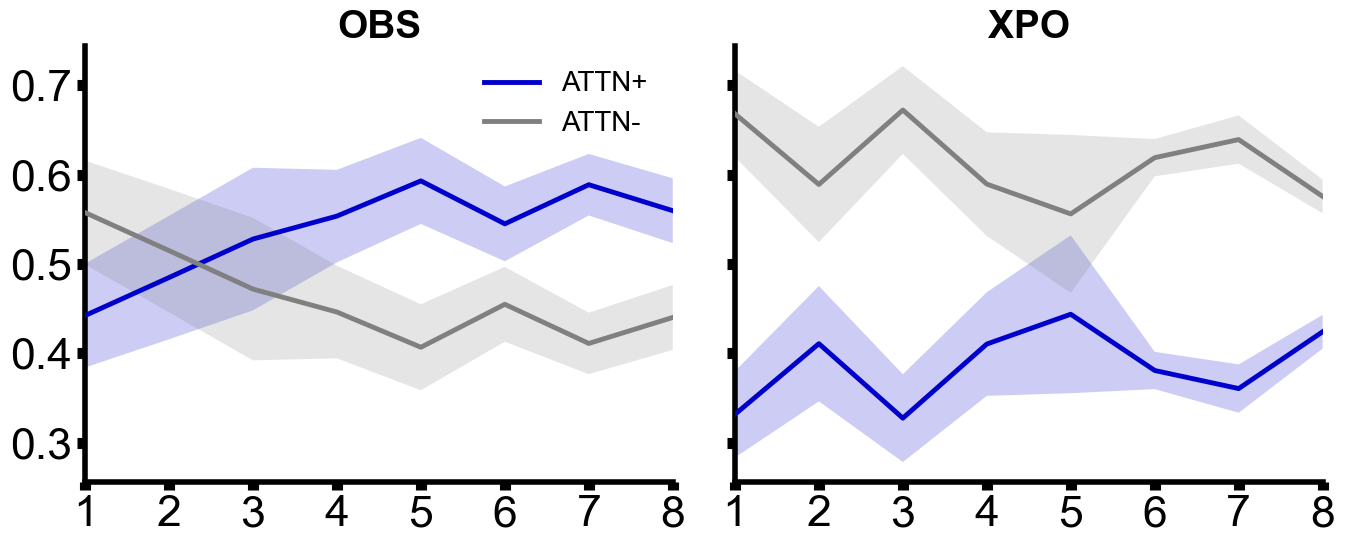

In [331]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Combine non-sniffing behaviors into attention states
def combine_attention_states(occupancy_data, cond_name):
    """Combine Self-directed, Idle, and Exploratory into ATTN-"""
    self_directed = occupancy_data[cond_name]['Self-directed']
    idle = occupancy_data[cond_name]['Idle']
    exploratory = occupancy_data[cond_name]['Exploratory']
    
    # Sum across behaviors for each animal
    attn_minus = self_directed + idle + exploratory
    attn_plus = occupancy_data[cond_name]['Sniffing']
    
    return attn_minus, attn_plus

group_colors = {
    'ATTN+': 'mediumblue',  # Sniffing (magenta)
    'ATTN-': '#808080',  # Combined other behaviors (gray)
}

days = np.arange(1, n_days + 1)

for ax, cond_name in zip(axes, ['OBS', 'XPO']):
    # Get combined attention states
    attn_minus, attn_plus = combine_attention_states(occupancy_data, cond_name)
    
    combined_data = {
        'ATTN-': attn_minus,
        'ATTN+': attn_plus
    }
    
    for group_name, color in group_colors.items():
        data = combined_data[group_name]  # (n_animals, n_days)
        mean = np.nanmean(data, axis=0)
        sem = np.nanstd(data, axis=0) / np.sqrt(np.sum(~np.isnan(data), axis=0))
        
        ax.plot(days, mean, color=color, linewidth=3.5, label=group_name, zorder=3)
        ax.fill_between(days, mean - sem, mean + sem, color=color, alpha=0.2, edgecolor='none')
    
    ax.set_title(cond_name, fontsize=28, fontfamily='Arial', fontweight='bold')
    ax.set_xticks(days)
    ax.set_xlim([1, n_days])
    ax.tick_params(labelsize=20)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily('Arial')
        label.set_fontsize(32)

axes[0].legend(fontsize=20, frameon=False, loc='upper right', prop={'family': 'Arial', 'size': 20})
sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig2/behavior_occupancy_timecourse.svg', dpi=300, bbox_inches='tight')
plt.show()

In [333]:
# LME for stats

import statsmodels.formula.api as mixedlm

# Build long-format DataFrame for LME
records = []
for cond_name in ['OBS', 'XPO']:
    attn_minus, attn_plus = combine_attention_states(occupancy_data, cond_name)
    for attn_label, data in [('ATTN+', attn_plus), ('ATTN-', attn_minus)]:
        n_animals = data.shape[0]
        for animal_idx in range(n_animals):
            for day_idx in range(n_days):
                val = data[animal_idx, day_idx]
                if not np.isnan(val):
                    records.append({
                        'condition': cond_name,
                        'attention': attn_label,
                        'animal':    f'{cond_name}_{animal_idx}',
                        'day':       day_idx + 1,
                        'occupancy': val
                    })

df_lme = pd.DataFrame(records)

# ── Run LME and full reporting ────────────────────────────────────────────────
print(f'\n{"="*100}')
print(f'Linear Mixed Effects Model: occupancy ~ day + (1|animal)')
print(f'Fixed effect of interest: slope on day (REML estimation)')
print(f'{"="*100}')
print(f'{"Condition":<10} {"Attention":<10} {"N_obs":>6} {"N_animals":>10} '
      f'{"Intercept":>11} {"Slope":>10} {"SE":>8} {"z":>8} '
      f'{"p_raw":>10} {"95CI_lo":>9} {"95CI_hi":>9} {"Sig":>5}')
print(f'{"─"*100}')

lme_results = {}

for cond_name in ['OBS', 'XPO']:
    for attn_label in ['ATTN+', 'ATTN-']:
        subset = df_lme[
            (df_lme['condition'] == cond_name) &
            (df_lme['attention'] == attn_label)
        ].copy()

        n_obs     = len(subset)
        n_animals = subset['animal'].nunique()

        model  = mixedlm.mixedlm(
            'occupancy ~ day',
            data=subset,
            groups=subset['animal']
        )
        result = model.fit(reml=True, disp=False)

        intercept = result.params['Intercept']
        slope     = result.params['day']
        se        = result.bse['day']
        z_stat    = result.tvalues['day']
        pval      = result.pvalues['day']

        # 95% CI on slope
        ci        = result.conf_int()
        ci_lo     = ci.loc['day', 0]
        ci_hi     = ci.loc['day', 1]

        # random effects variance + residual
        re_var    = float(result.cov_re.values[0][0]) \
                    if hasattr(result, 'cov_re') else np.nan
        resid_var = result.scale

        if   pval < 0.001: sig = '***'
        elif pval < 0.01:  sig = '**'
        elif pval < 0.05:  sig = '*'
        elif pval < 0.1:   sig = '#'
        else:              sig = 'n.s.'

        direction = '↑' if slope > 0 else '↓'

        print(f'{cond_name:<10} {attn_label:<10} {n_obs:>6} {n_animals:>10} '
              f'{intercept:>+11.4f} {slope:>+10.4f} {se:>8.4f} {z_stat:>8.3f} '
              f'{pval:>10.4e} {ci_lo:>9.4f} {ci_hi:>9.4f} {sig:>4} {direction}')

        lme_results[(cond_name, attn_label)] = {
            'n_obs':      n_obs,
            'n_animals':  n_animals,
            'intercept':  intercept,
            'slope':      slope,
            'se':         se,
            'z':          z_stat,
            'p':          pval,
            'ci_lo':      ci_lo,
            'ci_hi':      ci_hi,
            're_var':     re_var,
            'resid_var':  resid_var,
            'sig':        sig,
            'direction':  direction,
            'result':     result,
        }

print(f'{"─"*100}')
print(f'\n── Random effects variance + residual ──')
print(f'{"Condition":<10} {"Attention":<10} {"RE_var":>12} {"Resid_var":>12}')
print(f'{"─"*45}')
for (cond_name, attn_label), r in lme_results.items():
    re_s  = f'{r["re_var"]:>12.6f}'  if not np.isnan(r["re_var"])  else '         n/a'
    res_s = f'{r["resid_var"]:>12.6f}'
    print(f'{cond_name:<10} {attn_label:<10} {re_s} {res_s}')
print(f'{"="*100}')


Linear Mixed Effects Model: occupancy ~ day + (1|animal)
Fixed effect of interest: slope on day (REML estimation)
Condition  Attention   N_obs  N_animals   Intercept      Slope       SE        z      p_raw   95CI_lo   95CI_hi   Sig
────────────────────────────────────────────────────────────────────────────────────────────────────
OBS        ATTN+          72          9     +0.4603    +0.0170   0.0056    3.041 2.3558e-03    0.0061    0.0280   ** ↑
OBS        ATTN-          72          9     +0.5397    -0.0170   0.0056   -3.041 2.3558e-03   -0.0280   -0.0061   ** ↓
XPO        ATTN+          40          5     +0.3547    +0.0070   0.0081    0.869 3.8503e-01   -0.0088    0.0229 n.s. ↑
XPO        ATTN-          40          5     +0.6453    -0.0070   0.0081   -0.869 3.8503e-01   -0.0229    0.0088 n.s. ↓
────────────────────────────────────────────────────────────────────────────────────────────────────

── Random effects variance + residual ──
Condition  Attention        RE_var    Resid_var

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [334]:
# Source data

rows = []

cond_name = 'OBS'
attn_minus, attn_plus = combine_attention_states(occupancy_data, cond_name)
combined_data = {'ATTN-': attn_minus, 'ATTN+': attn_plus}

# LME fit — ATTN+ only, matching the legend decision to report ATTN+ alone
n_animals_plus = attn_plus.shape[0]
records = []
for animal_idx in range(n_animals_plus):
    for day_idx in range(n_days):
        val = attn_plus[animal_idx, day_idx]
        if not np.isnan(val):
            records.append({
                'animal': f'{cond_name}_{animal_idx}',
                'day': day_idx + 1,
                'occupancy': val
            })
df_lme = pd.DataFrame(records)
model  = mixedlm.mixedlm('occupancy ~ day', data=df_lme, groups=df_lme['animal'])
result = model.fit(reml=True, disp=False)

slope  = result.params['day']
se     = result.bse['day']
z_stat = result.tvalues['day']
pval   = result.pvalues['day']
ci     = result.conf_int()
ci_lo  = ci.loc['day', 0]
ci_hi  = ci.loc['day', 1]

for attn_label, data in combined_data.items():
    n_animals = data.shape[0]
    for animal_idx in range(n_animals):
        for day_idx in range(n_days):
            val = data[animal_idx, day_idx]
            row = {
                'condition': cond_name,
                'attention': attn_label,
                'animal_idx': animal_idx,
                'day': day_idx + 1,
                'occupancy': val,
            }
            # LME stats attached only to ATTN+ rows, per legend decision
            if attn_label == 'ATTN+':
                row.update({
                    'lme_slope': slope,
                    'lme_se': se,
                    'lme_z': z_stat,
                    'lme_p': pval,
                    'lme_ci_lo': ci_lo,
                    'lme_ci_hi': ci_hi,
                })
            else:
                row.update({
                    'lme_slope': np.nan, 'lme_se': np.nan, 'lme_z': np.nan,
                    'lme_p': np.nan, 'lme_ci_lo': np.nan, 'lme_ci_hi': np.nan,
                })
            rows.append(row)

sourceData_2f = pd.DataFrame(rows)
sourceData_2f.to_csv('./sourceData/2f.csv', index=False)

Define functions for extracting time windows

In [3]:
def format4analysis(full_data, animal_ID, binary_labels='attack labels', beh='agg'):

    sessions = list(full_data.keys())
    region_index, region_id = pd.factorize(region_ids)
    epochs = [[0, 3], [3, 6], [6, 9], [9, 12], [12, 15], [15, 18], [18, 21], [21,24], [24, 28]]
    f = np.max([full_data[session].shape[0] for session in sessions])

    traces_lib = np.empty((f, len(region_index)+1, 27))
    traces_lib[:] = np.nan

    # package recordings into traces_lib array
    
    sessions2map = [x for x in sessions if animal_ID in x]
    if beh == 'agg':
        sessions2map = [x for x in sessions2map if '_balbc_' in x or '_mCD1_' in x]
    elif beh == 'obs':
        sessions2map = [x for x in sessions2map if '_obs_' in x or '_OBSmCD1_' in x]
    else:
        sessions2map = [x for x in sessions2map if '_toy_' in x or '_toyCD1_' in x]

    for i, sesh in enumerate(sessions2map):

        # format traces from each session to fit the big nan array above
        s = full_data[sesh]
        if s.shape[0] < f:
            nan_pad = np.zeros((f-s.shape[0], s.shape[1]))
            nan_pad[:] = np.nan
            nan_pad = pd.DataFrame(nan_pad, columns=s.columns)
            s = pd.concat([s, nan_pad], axis=0)

        # copy columns at specific locations
        for idx, roi in zip(region_index, region_id):
            try: 
                traces_lib[:, idx, i] = s[roi]
            except KeyError:
                traces_lib[:, idx, i] = np.nan
        try:
            traces_lib[:, -1, i] = s[binary_labels]
        except KeyError:
            traces_lib[:, -1, i] = np.nan

    # separate into epochs
    d1 = traces_lib[:, :, epochs[0][0]:epochs[0][1]]
    d2 = traces_lib[:, :, epochs[1][0]:epochs[1][1]]
    d3 = traces_lib[:, :, epochs[2][0]:epochs[2][1]]
    d4 = traces_lib[:, :, epochs[3][0]:epochs[3][1]]
    d5 = traces_lib[:, :, epochs[4][0]:epochs[4][1]]
    d6 = traces_lib[: ,:, epochs[5][0]:epochs[5][1]]
    d7 = traces_lib[: ,:, epochs[6][0]:epochs[6][1]]
    d8 = traces_lib[: ,:, epochs[7][0]:epochs[7][1]]
    d9 = traces_lib[: ,:, epochs[8][0]:epochs[8][1]]
    trial_comps = [d1, d2, d3, d4, d5, d6, d7, d8, d9]  
    
    return trial_comps, s.columns

def produce_XY(epoch):
    
    epoch_df = pd.DataFrame()
    for i in range(epoch.shape[-1]):
        epoch_df = pd.concat([epoch_df, pd.DataFrame(epoch[:, :, i])])
    concat_sessions = epoch_df.to_numpy()
    filtered_sessions = concat_sessions[np.invert(np.isnan(concat_sessions[:, -1]))]

    X = filtered_sessions[:, :-1]
    orig_X = X.copy()
    if np.isnan(X).any(axis=0).any(): # remove columns with nan
        has_nan = np.isnan(X).any(axis=0)
        X = X[:, ~has_nan]
    y_init = filtered_sessions[:, -1]
    y = y_init.astype(int).reshape(-1,1)

    return X, y

def find_window_of_behavior(labels, label_ID, min_segment_length=8, window_size=21, window_of_separation=40):
    # Find consecutive segments of label ID
    mask = labels == label_ID
    consecutive_segments = np.diff(mask.astype(int))
    segment_starts = np.where(consecutive_segments == 1)[0] + 1
    segment_ends = np.where(consecutive_segments == -1)[0]

    # Filter out segments below the length threshold
    valid_segments = [segment for segment in zip(segment_starts, segment_ends) if segment[1] - segment[0] + 1 >= min_segment_length]
    
    # Remove segments below the value of 300
    filtered_segments_pre = []
    for start, end in valid_segments:
        if end >= 280:
            filtered_segments_pre.append((start, end))
    valid_segments = filtered_segments_pre
    
    # Remove segments where the end of one segment is within n elements (window of separation) of the start of the next segment
    filtered_segments = []
    filtered_segments.append(valid_segments[0])
    for i in range(len(valid_segments))[1:]:
        if i == len(valid_segments) - 1 or filtered_segments[-1][1] + window_of_separation < valid_segments[i][0]:
            filtered_segments.append(valid_segments[i])

    # Generate onset and offset windows for each segment
    onset_windows = []
    offset_windows = []
    for start, end in filtered_segments:
        onset_start = max(start - (window_size // 2), 0)
        onset_end = min(onset_start + window_size, len(labels))
        onset_indices = np.arange(onset_start, onset_end)
        onset_windows.append(onset_indices)

        offset_end = min(end + (window_size // 2) + 1, len(labels))
        offset_start = max(offset_end - window_size, 0)
        offset_indices = np.arange(offset_start, offset_end)
        offset_windows.append(offset_indices)

    return onset_windows, offset_windows

def format_weights(fold_weights, global_weights, rois):
    
    if fold_weights.shape[0] < global_weights.shape[0]:
        truncated_weights = np.zeros((global_weights.shape[0]))
        pres_idxs, miss_idxs = get_indices(rois)
        truncated_weights[pres_idxs] = np.array(np.mean(fold_weights, axis=1))
        truncated_weights[miss_idxs] = np.nan
        return truncated_weights
    else:
        return np.mean(fold_weights, axis=1)
    
def get_indices(partial_list):
    present_indices = [indices[val] for val in partial_list if val in indices]
    not_present = [val for val in np.arange(len(region_ids)) if val not in present_indices]
    return present_indices, not_present
    
def add_nan_values(matrix, rois, n_features=22):
    
    if len(rois) < n_features: 
        
        # Get roi indices
        pres_idxs, miss_idxs = get_indices(rois)
        # Create a copy of the original matrix to avoid modifying it
        matrix_copy = matrix.copy()
        # Create a 1D boolean mask that indicates where to add NaN values
        nan_mask = np.zeros(matrix_copy.shape[2], dtype=bool)
        print(miss_idxs)
        nan_mask[miss_idxs] = True
        # Add NaN values to the matrix
        matrix_copy = np.insert(matrix_copy, miss_idxs, np.nan, axis=2)
                
        return matrix_copy
    
    else:
        
        return matrix
    
def extract_segments(array):
    segments = []
    current_segment = []

    for i in range(len(array)):
        if i > 0 and array[i] != array[i-1] + 1:
            segments.append(np.array(current_segment))
            current_segment = []
        current_segment.append(array[i])

    if current_segment:
        segments.append(np.array(current_segment))

    return segments
    
def concatenate_arrays(arrays, distance_of_frames=20):
    result = []
    current_array = arrays[0]

    for i in range(1, len(arrays)):
        if arrays[i][0] - current_array[-1] <= distance_of_frames:
            current_array = np.concatenate((current_array, arrays[i]))
            current_array = fill_missing_numbers(current_array)
        else:
            result.append(current_array)
            current_array = arrays[i]

    result.append(current_array)
    return np.array(result)

def process_binary_labels(labels):
    
    segments = extract_segments(np.where(labels==1)[0])
    joined_segments = concatenate_arrays(segments)
    new_labels = generate_binary_array(np.concatenate(joined_segments), labels.shape[0])
    
    return new_labels

def generate_binary_array(indices, length):
    binary_array = np.zeros(length)
    binary_array[indices] = 1
    return binary_array

def fill_missing_numbers(array):
    filled_array = []
    for i in range(len(array) - 1):
        filled_array.append(array[i])
        diff = array[i + 1] - array[i]
        if diff > 1:
            filled_array.extend(np.arange(array[i] + 1, array[i + 1]))
    filled_array.append(array[-1])
    return filled_array

### Extract aggression windows

In [4]:
# Generates +-6s windows around each attack frame, with a minimum of 6s between windows

import warnings
from tqdm import tqdm

# Ignore FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

animals = np.concatenate([agg_animals, obs_animals, non_animals])
n_features = 23
aggro_dict = {}
attack_indices_dict = {}
offset_dict = {}
window_size=480 # for tp, originally 480

for a, animal in tqdm(enumerate(animals)):

    if a <= 11:
        beh='agg'
        stim = 'balbc'
    elif a <= 20:
        beh='obs'
        stim='obs'
    else:
        beh='non'
        stim='toy'

    trial_comps, rois = format4analysis(full_data, animal, beh=beh)
    rois = rois[:-2]

    # ascertain real and global indices for rois
    array_of_rois = np.vstack([np.isnan(full_data['%s_d1_%s_t1' % (animal, stim)][roi].values) for roi in rois])
    removed_rois = np.unique(np.where(array_of_rois == True)[0])
    real_rois = np.unique(np.where(array_of_rois == False)[0])

    # commence extraction of aggression windows
    onset_traces = []
    session_attack_indices = []  # Store attack indices per session

    for e, epoch in enumerate(trial_comps):    

        X, y = produce_XY(epoch)
        y = y.ravel()
        X = X.T

        # Create binary mask for this session
        attack_mask = np.zeros(len(y), dtype=int)
        
        try:
            on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size, window_of_separation=window_size, min_segment_length=0)
            
            # Mark attack frames in the mask
            for attack_window in on:
                attack_indices = np.array(attack_window).astype(int)
                attack_mask[attack_indices] = 1
            
            for i, lst in enumerate(on):
                if len(lst) < window_size:
                    mean_val = sum(lst) / len(lst)
                    on[i] = list(lst) + [mean_val] * (window_size - len(lst))

            aggression_windows = np.asarray(on)
            traces4beh = np.zeros((aggression_windows.shape[0], aggression_windows.shape[1], n_features))
            traces4beh[:] = np.nan

            for i, region in enumerate(real_rois):
                trace = X[i, :]
                for j, window in enumerate(aggression_windows):
                    window = window.astype(int)
                    t = trace[window]
                    traces4beh[j, :, region] = t
                    
        except IndexError:
            # Create empty array for epochs with no attacks
            traces4beh = np.zeros((1, window_size, n_features))
            traces4beh[:] = np.nan

        # Always append something to maintain structure
        onset_traces.append(traces4beh)
        session_attack_indices.append(attack_mask) 
        
    aggro_dict['%s_%s' % (animal, beh)] = onset_traces
    attack_indices_dict['%s_%s' % (animal, beh)] = session_attack_indices  

# Sort groups into separate dictionaries
agg_dict = {}
obs_dict = {}
non_dict = {}
agg_attack_indices = {}
obs_attack_indices = {} 
non_attack_indices = {} 

# Iterate through each key in aggro_dict
for key, value in aggro_dict.items():
    if 'agg' in key:
        agg_dict[key.replace('_agg', '')] = value
        agg_attack_indices[key.replace('_agg', '')] = attack_indices_dict[key]
    elif 'obs' in key:
        obs_dict[key.replace('_obs', '')] = value
        obs_attack_indices[key.replace('_obs', '')] = attack_indices_dict[key]
    elif 'non' in key:
        non_dict[key.replace('_non', '')] = value
        non_attack_indices[key.replace('_non', '')] = attack_indices_dict[key] 

0it [00:00, ?it/s]

29it [00:23,  1.22it/s]


In [ ]:
# (Optional) Save the attack indices dictionaries to pickle files for later use

with open('AGG_attack_indices.pickle', 'wb') as f:
    pickle.dump(agg_attack_indices, f)

with open('OBS_attack_indices.pickle', 'wb') as f:
    pickle.dump(obs_attack_indices, f)

with open('NON_attack_indices.pickle', 'wb') as f:
    pickle.dump(non_attack_indices, f)

### Extract random time windows: (train Markov Chain on attack sequences to generate random faux attack trials)

If these are already saved somewhere, skip ahead to loading.

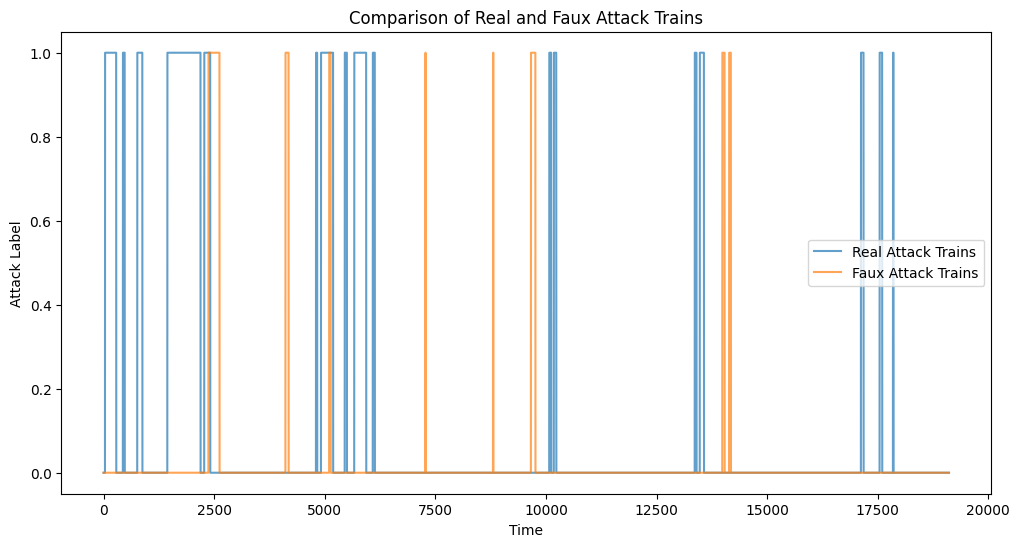

In [6]:
import random
from collections import defaultdict

def calculate_attack_durations(attack_sequence):
    """Calculate duration of each attack bout"""
    durations = []
    in_attack = False
    current_duration = 0
    
    for attack in attack_sequence:
        if int(attack) == 1:
            if not in_attack:
                in_attack = True
                current_duration = 1
            else:
                current_duration += 1
        else:
            if in_attack:
                durations.append(current_duration)
                in_attack = False
                current_duration = 0
    
    if in_attack:
        durations.append(current_duration)
    
    return durations

def analyze_durations(durations):
    """Analyze attack duration distribution"""
    if not durations:
        return {'durations': [1], 'probabilities': [1.0]}
    
    unique_durations, counts = np.unique(durations, return_counts=True)
    probabilities = counts / counts.sum()
    
    return {
        'durations': unique_durations,
        'probabilities': probabilities
    }

def generate_attack_sequence(full_data, n_animals=20, order=3, target_rate=None, 
                           training_seed=9, generation_seed=8888):
    """
    Complete pipeline: train Markov chain with duration model and generate sequences
    """
    # Set training seeds
    np.random.seed(training_seed)
    random.seed(training_seed)
    
    # Select animals and extract attack data
    all_keys = list(full_data.keys())
    selected_keys = random.sample(all_keys, min(n_animals, len(all_keys)))
    
    all_attack_data = []
    all_durations = []
    
    for key in selected_keys:
        animal_data = full_data[key]
        
        if 'attack labels' in animal_data:
            attacks = animal_data['attack labels']
        elif 'attacks' in animal_data:
            attacks = animal_data['attacks']
        else:
            continue
        
        attacks = [int(x) for x in attacks]
        all_attack_data.extend(attacks)
        
        # Extract durations for this animal
        durations = calculate_attack_durations(attacks)
        all_durations.extend(durations)
    
    # Build Markov chain transitions
    transitions = defaultdict(lambda: {'0': 0, '1': 0})
    
    for i in range(len(all_attack_data) - order):
        state = tuple(int(x) for x in all_attack_data[i:i + order])
        next_val = str(int(all_attack_data[i + order]))
        transitions[state][next_val] += 1
    
    # Convert to probabilities
    for state in transitions:
        total = transitions[state]['0'] + transitions[state]['1']
        if total > 0:
            transitions[state]['0'] /= total
            transitions[state]['1'] /= total
    
    # Analyze duration distribution
    duration_stats = analyze_durations(all_durations)
    fallback_prob = sum(all_attack_data) / len(all_attack_data)
    
    def generator(length=1000):
        """Generate attack sequence with realistic durations and optional rate control"""
        # Set generation seed
        np.random.seed(generation_seed)
        random.seed(generation_seed)
        
        if not transitions:
            base_sequence = [random.choice([0, 1]) for _ in range(length)]
        else:
            # Generate base sequence using Markov chain
            current_state = random.choice(list(transitions.keys()))
            generated = list(current_state)
            
            for _ in range(length):
                if current_state in transitions:
                    prob_attack = transitions[current_state]['1']
                else:
                    prob_attack = fallback_prob
                
                next_val = 1 if random.random() < prob_attack else 0
                generated.append(next_val)
                current_state = tuple(generated[-order:])
            
            base_sequence = generated[-length:]
        
        # Apply realistic durations
        enhanced_sequence = [0] * length
        i = 0
        
        while i < length:
            if base_sequence[i] == 1 and (i == 0 or base_sequence[i-1] == 0):
                # Attack onset - assign realistic duration
                if len(duration_stats['durations']) > 0:
                    duration = np.random.choice(
                        duration_stats['durations'], 
                        p=duration_stats['probabilities']
                    )
                else:
                    duration = 1
                
                # Fill attack bout
                for j in range(min(duration, length - i)):
                    enhanced_sequence[i + j] = 1
                
                i += duration
            else:
                i += 1
        
        # Apply rate control if specified
        if target_rate is not None:
            current_rate = sum(enhanced_sequence) / len(enhanced_sequence)
            if current_rate > target_rate:
                attack_indices = [i for i, x in enumerate(enhanced_sequence) if x == 1]
                if len(attack_indices) > 0:
                    keep_count = max(1, int(len(attack_indices) * (target_rate / current_rate)))
                    keep_indices = set(random.sample(attack_indices, keep_count))
                    
                    enhanced_sequence = [
                        1 if (i in keep_indices and enhanced_sequence[i] == 1) else 0
                        for i in range(len(enhanced_sequence))
                    ]
        
        return enhanced_sequence
    
    return generator

# Usage
attack_generator = generate_attack_sequence(
    full_data, 
    n_animals=20, 
    order=10, 
    target_rate=0.1,
    training_seed=9,
    generation_seed=8888
)

# Generate sequences
real_attack_trains = full_data['1162B_d5_obs_t3']['attack labels']
faux_attack_trains = attack_generator(length=len(real_attack_trains))

# Compare the real and faux attack trains
plt.figure(figsize=(12, 6))
plt.plot(real_attack_trains, label='Real Attack Trains', alpha=0.7)
plt.plot(faux_attack_trains, label='Faux Attack Trains', alpha=0.7)
plt.title('Comparison of Real and Faux Attack Trains')
plt.xlabel('Time')
plt.ylabel('Attack Label')
plt.legend()
plt.show()

In [ ]:
animals = np.concatenate([agg_animals, obs_animals, non_animals])
n_features = 23
faux_dict = {}
offset_dict = {}
window_size=480 # for tp, originally 480
min_segment_length=1 # for tp
np.random.seed(12398)

for a, animal in tqdm(enumerate(animals)):

    if a <= 11:
        beh='agg'
        stim = 'balbc'
    elif a <= 20:
        beh='obs'
        stim='obs'
    else:
        beh='non'
        stim='toy'

    trial_comps, rois = format4analysis(full_data, animal, beh=beh)
    rois = rois[:-2]

    # ascertain real and global indices for rois
    array_of_rois = np.vstack([np.isnan(full_data['%s_d1_%s_t1' % (animal, stim)][roi].values) for roi in rois])
    removed_rois = np.unique(np.where(array_of_rois == True)[0])
    real_rois = np.unique(np.where(array_of_rois == False)[0])

    # commence extraction of aggression windows
    onset_traces = []

    for e, epoch in enumerate(trial_comps):    

        X, y_hat = produce_XY(epoch)
        y = attack_generator(length=len(y_hat)) # generate faux attack sequences
        y = np.array(y) 
        y[y_hat.ravel() == 1] = 0
        X = X.T
        
        try:
            on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size, window_of_separation=window_size, min_segment_length=min_segment_length) # 3 is aggression
            
            for i, lst in enumerate(on):
                if len(lst) < window_size:
                    mean_val = sum(lst) / len(lst)
                    on[i] = list(lst) + [mean_val] * (window_size - len(lst))

            aggression_windows = np.asarray(on)
            traces4beh = np.zeros((aggression_windows.shape[0], aggression_windows.shape[1], n_features))
            traces4beh[:] = np.nan

            for i, region in enumerate(real_rois):
                trace = X[i, :]
                for j, window in enumerate(aggression_windows):
                    window = window.astype(int)
                    t = trace[window]
                    traces4beh[j, :, region] = t
                    
        except IndexError:
            # Create empty array for epochs with no attacks
            traces4beh = np.zeros((1, window_size, n_features))
            traces4beh[:] = np.nan

        # Always append something to onset_traces to maintain 9 items
        onset_traces.append(traces4beh)
        
    faux_dict['%s_%s' % (animal, beh)] = onset_traces # dictionary of each animal with all of their aggression windows by day

# Sort groups into separate dictionaries
agg_faux_dict = {}
obs_faux_dict = {}
non_faux_dict = {}

# Iterate through each key in aggro_dict
for key, value in faux_dict.items():
    if 'agg' in key:
        agg_faux_dict[key.replace('_agg', '')] = value
    elif 'obs' in key:
        obs_faux_dict[key.replace('_obs', '')] = value
    elif 'non' in key:
        non_faux_dict[key.replace('_non', '')] = value

In [14]:
# (Optional) - Save and/or load pickle file containing the faux trains for later use

import pickle

# # Save the dictionary to a pickle file
# with open('obs_faux_dict.pickle', 'wb') as f:
# 	pickle.dump(obs_faux_dict, f)

# Load the dictionary from the pickle file
with open('obs_faux_dict.pickle', 'rb') as f:
    obs_faux_dict = pickle.load(f)

In [15]:
# Balancing trial counts between real and synthetic attack data

import random
import torch

def balance_trial_counts(obs_dict, faux_dict):

    balanced_faux_dict = {}
    
    for key in obs_dict.keys():
        if key.split('_')[0] not in faux_dict:
            print(f"Warning: Key '{key}' not found in faux_dict")
            continue
            
        balanced_faux_dict[key] = []
        
        # Process each day (0-8)
        for day in range(9):
            real_tensor = obs_dict[key][day]  # shape: trials x time x regions
            faux_tensor = faux_dict[key][day]  # shape: trials x time x regions
            
            n_real_trials = real_tensor.shape[0]
            n_faux_trials = faux_tensor.shape[0]
            
            if n_faux_trials >= n_real_trials:
                # Randomly subsample faux trials to match real trials
                if n_real_trials > 0:
                    random_indices = random.sample(range(n_faux_trials), n_real_trials)
                    balanced_tensor = faux_tensor[random_indices]
                else:
                    # If no real trials, keep empty tensor with same shape
                    balanced_tensor = faux_tensor[:0]
            else:
                # If fewer faux trials than real trials, keep all faux trials
                balanced_tensor = faux_tensor
            
            balanced_faux_dict[key].append(balanced_tensor)
            
            print(f"{key:<15} {day:<5} {n_real_trials:<8} {n_faux_trials:<10} {balanced_tensor.shape[0]:<10}")
    
    return balanced_faux_dict

# Usage:
faux_dict = obs_faux_dict  # or agg_faux_dict, non_faux_dict
balanced_faux_dict = balance_trial_counts(obs_dict, faux_dict)

# Verify the balancing worked
print("\nVerification - Final trial counts:")
print("=" * 50)
for key in obs_dict.keys():
    if key in balanced_faux_dict:
        for day in range(9):
            real_count = obs_dict[key][day].shape[0]
            balanced_count = balanced_faux_dict[key][day].shape[0]
            match = "✓" if real_count == balanced_count else "✗"
            print(f"{key} day {day}: Real={real_count}, Balanced={balanced_count} {match}")

30R2            0     23       27         23        
30R2            1     41       25         25        
30R2            2     43       30         30        
30R2            3     27       26         26        
30R2            4     31       27         27        
30R2            5     48       25         25        
30R2            6     31       26         26        
30R2            7     29       26         26        
30R2            8     8        16         8         
29L             0     21       28         21        
29L             1     27       27         27        
29L             2     37       26         26        
29L             3     14       27         14        
29L             4     14       28         14        
29L             5     1        28         1         
29L             6     29       26         26        
29L             7     29       26         26        
29L             8     5        15         5         
86L             0     23       26         23  

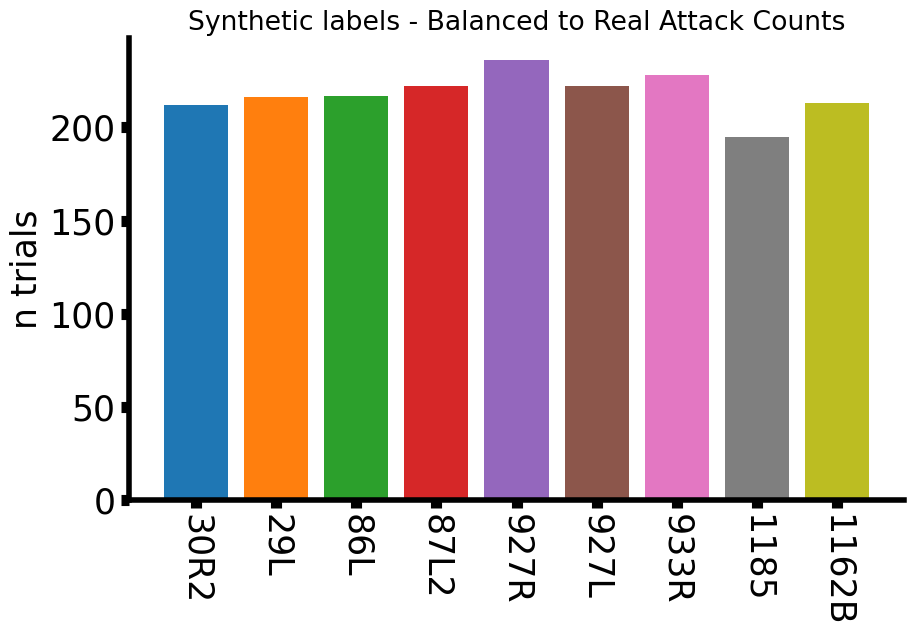

In [16]:
plt.figure(figsize=(10, 6))
for i, key in enumerate(list(obs_faux_dict.keys())):
    try:
        all_subj_trials = np.concatenate(obs_faux_dict[key][:-1]).shape[0]
    except ValueError:
        break
    plt.bar(i, all_subj_trials)
plt.xticks(np.arange(len(obs_faux_dict)), list(obs_faux_dict.keys()), rotation=270);
plt.ylabel('n trials')
plt.title('Synthetic labels - Balanced to Real Attack Counts')
sns.despine()

In [17]:
faux_dict = balanced_faux_dict.copy()

### Extract high velocity events that are NOT aggression

Extract features (need parquet files with all processed features)

In [ ]:
               # DISTANCES
feats_list1 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list2 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               # IoU
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list3 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list4 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms', 'proximity roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               'proximity roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list5 =  ['proximity', 'proximity median across lags', 'resident2intruder head-head', 'resident2intruder head-head median across lags', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms', 'proximity roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               'proximity roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']


feats_list = list(set(feats_list1 + feats_list2 + feats_list3 + feats_list4 + feats_list5))
feats_list.sort()
feats_list = np.asarray(feats_list)

from tqdm import tqdm

features = {}
implanted_list = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '29L', '30R2', '30B', '91R2', '30L', '87R2', '87L', '87B', '87L2', '86L', '86L2', '933R', '927R','927L','583L2','583B', '1185', '1162B', '1162L2', '1162R', '4321L', '4321R2', '4321R', '7452R', '7452L', '7452B', '7452R']
feats_path = "S:\\jmig\\processed_features_020924_parquets\\"
feat_pickles = np.sort([x for x in os.listdir(feats_path) if 'zscored' in x])
feats_path2 = "S:\\jmig\\feature_processing\\processed_features_not4training\\"
feat_pickles2 = np.sort([x for x in os.listdir(feats_path2) if 'zscored' in x])

for session in tqdm(np.sort(feat_pickles)):
    if any(imp in session for imp in implanted_list):
        n = 4
    else:
        n = 3
    z = pd.read_parquet(feats_path + session, columns=feats_list)
    features['_'.join(session.split('_')[:n])] = z
    
for session in tqdm(np.sort(feat_pickles2)):
    if any(imp in session for imp in implanted_list):
        n = 4
    else:
        n = 3
    z = pd.read_parquet(feats_path2 + session, columns=feats_list)
    features['_'.join(session.split('_')[:n])] = z

Save (or load?) features

In [12]:
import pickle

# Save the dictionary to a pickle file
# with open('features.pickle', 'wb') as f:
#     pickle.dump(features, f)

# Load the dictionary back from the pickle file
with open('features.pickle', 'rb') as f:
    features = pickle.load(f)

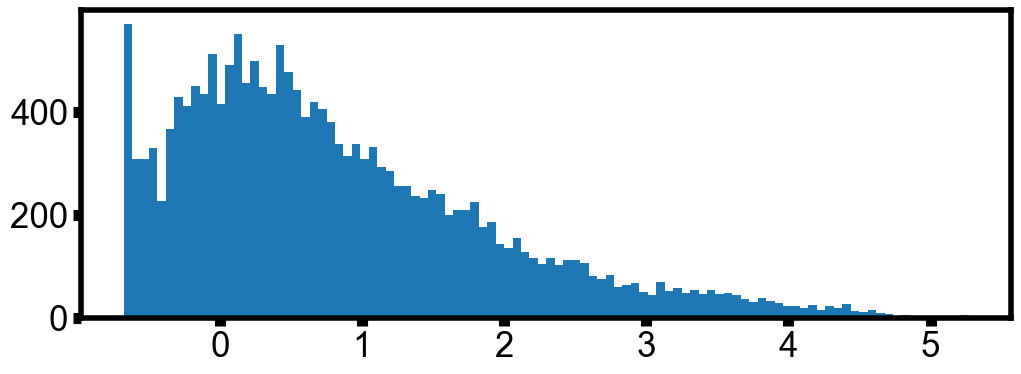

In [341]:
l = features['1185_d1_obs_t1']['resident centroid roc 100 ms'].values
plt.figure(figsize=(12, 4))
plt.hist(l[~np.isnan(l)], bins=100);

In [13]:
speed_dict = {}

for key in features.keys():
    speed = features[key]['resident centroid roc 100 ms'].values
    speed_binary = np.where(speed > 2, 1, 0)  # Threshold at 2 z-scores
    speed_dict[key] = speed_binary

In [14]:
speed_data = full_data.copy()

for key in speed_data.keys():
    df = speed_data[key]
    try:
        df['speed labels'] = speed_dict[key]
        speed_data[key] = df
    except KeyError:
        print(f"Key '{key}' not found in speed_dict")
        continue

Key '1162L2_d1_toy_t1' not found in speed_dict
Key '1162L2_d1_toy_t2' not found in speed_dict
Key '1162L2_d1_toy_t3' not found in speed_dict
Key '1162L2_d2_toy_t1' not found in speed_dict
Key '1162L2_d2_toy_t2' not found in speed_dict
Key '1162L2_d2_toy_t3' not found in speed_dict
Key '1162L2_d3_toy_t1' not found in speed_dict
Key '1162L2_d3_toy_t2' not found in speed_dict
Key '1162L2_d3_toy_t3' not found in speed_dict
Key '1162L2_d4_toy_t1' not found in speed_dict
Key '1162L2_d4_toy_t2' not found in speed_dict
Key '1162L2_d4_toy_t3' not found in speed_dict
Key '1162L2_d5_toy_t1' not found in speed_dict
Key '1162L2_d5_toy_t2' not found in speed_dict
Key '1162L2_d5_toy_t3' not found in speed_dict
Key '1162L2_d6_toy_t1' not found in speed_dict
Key '1162L2_d6_toy_t2' not found in speed_dict
Key '1162L2_d6_toy_t3' not found in speed_dict
Key '1162L2_d7_toy_t1' not found in speed_dict
Key '1162L2_d7_toy_t2' not found in speed_dict
Key '1162L2_d7_toy_t3' not found in speed_dict
Key '1162L2_d

In [15]:
animals = np.concatenate([agg_animals, obs_animals, non_animals])
n_features = 23
speed_dict = {}
offset_dict = {}
window_size=480 # for tp, originally 480
min_segment_length=1 # for tp
np.random.seed(12398)

for a, animal in tqdm(enumerate(animals)):

    if a <= 11:
        beh='agg'
        stim = 'balbc'
        continue
    elif a <= 20:
        beh='obs'
        stim='obs'
    else:
        beh='non'
        stim='toy'
        continue

    trial_comps_attack, rois = format4analysis(full_data, animal, binary_labels='attack labels', beh=beh)
    trial_comps_speed, _ = format4analysis(speed_data, animal, binary_labels='speed labels', beh=beh)
    rois = rois[:-3]

    # ascertain real and global indices for rois
    array_of_rois = np.vstack([np.isnan(full_data['%s_d1_%s_t1' % (animal, stim)][roi].values) for roi in rois])
    removed_rois = np.unique(np.where(array_of_rois == True)[0])
    real_rois = np.unique(np.where(array_of_rois == False)[0])

    # commence extraction of aggression windows
    onset_traces = []

    for e, epoch in enumerate(trial_comps_attack):    

        X_attack, y_attack = produce_XY(epoch)
        X_speed, y_speed = produce_XY(trial_comps_speed[e])
        y_attack = y_attack.ravel()
        y_speed = y_speed.ravel()
        y_speed[y_attack == 1] = 0
        y = y_speed
        X = X_speed.T
        
        try:
            on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size, window_of_separation=window_size, min_segment_length=min_segment_length) # 3 is aggression
            
            for i, lst in enumerate(on):
                if len(lst) < window_size:
                    mean_val = sum(lst) / len(lst)
                    on[i] = list(lst) + [mean_val] * (window_size - len(lst))

            aggression_windows = np.asarray(on)
            traces4beh = np.zeros((aggression_windows.shape[0], aggression_windows.shape[1], n_features))
            traces4beh[:] = np.nan

            for i, region in enumerate(real_rois):
                trace = X[i, :]
                for j, window in enumerate(aggression_windows):
                    window = window.astype(int)
                    t = trace[window]
                    traces4beh[j, :, region] = t
                    
        except IndexError:
            # Create empty array for epochs with no attacks
            traces4beh = np.zeros((1, window_size, n_features))
            traces4beh[:] = np.nan

        # Always append something to onset_traces to maintain 9 items
        onset_traces.append(traces4beh)
        
    speed_dict['%s_%s' % (animal, beh)] = onset_traces # dictionary of each animal with all of their aggression windows by day

# Sort groups into separate dictionaries
obs_speed_dict = {}

# Iterate through each key in speed_dict
for key, value in speed_dict.items():
    if 'obs' in key:
        obs_speed_dict[key.replace('_obs', '')] = value

29it [00:14,  1.96it/s]


In [18]:
# (Optional) - Save and/or load pickle file containing the speed trains for later use

# Save the dictionary to a pickle file
# with open('obs_speed_dict.pickle', 'wb') as f:
# 	pickle.dump(obs_speed_dict, f)

# Load the dictionary from the pickle file
with open('obs_speed_dict.pickle', 'rb') as f:
    speed_dict = pickle.load(f)

### Ranking OBS attacks by intruder or resident speed

For simplicity, simply load the speed pickles and skip to loading

In [ ]:
intruder_data = full_data.copy()

for key in intruder_data.keys():
    df = intruder_data[key]
    try:
        df['PrL (E)'] = features[key]['intruder centroid roc 100 ms'].values # Sub in intruder speed for PrL
        df['PrL (I)'] = features[key]['resident centroid roc 100 ms'].values # Sub in intruder speed for PrL
        intruder_data[key] = df
    except KeyError:
        print(f"Key '{key}' not found in features")
        continue

Key '1162L2_d1_toy_t1' not found in features
Key '1162L2_d1_toy_t2' not found in features
Key '1162L2_d1_toy_t3' not found in features
Key '1162L2_d2_toy_t1' not found in features
Key '1162L2_d2_toy_t2' not found in features
Key '1162L2_d2_toy_t3' not found in features
Key '1162L2_d3_toy_t1' not found in features
Key '1162L2_d3_toy_t2' not found in features
Key '1162L2_d3_toy_t3' not found in features
Key '1162L2_d4_toy_t1' not found in features
Key '1162L2_d4_toy_t2' not found in features
Key '1162L2_d4_toy_t3' not found in features
Key '1162L2_d5_toy_t1' not found in features
Key '1162L2_d5_toy_t2' not found in features
Key '1162L2_d5_toy_t3' not found in features
Key '1162L2_d6_toy_t1' not found in features
Key '1162L2_d6_toy_t2' not found in features
Key '1162L2_d6_toy_t3' not found in features
Key '1162L2_d7_toy_t1' not found in features
Key '1162L2_d7_toy_t2' not found in features
Key '1162L2_d7_toy_t3' not found in features
Key '1162L2_d8_toy_t1' not found in features
Key '1162L

In [ ]:
animals = np.concatenate([agg_animals, obs_animals, non_animals])
n_features = 24
new_dict = {}
offset_dict = {}
window_size=480 # for tp, originally 480
min_segment_length=0 # for tp
np.random.seed(12398)

for a, animal in tqdm(enumerate(animals)):

    if a <= 11:
        beh='agg'
        stim = 'balbc'
        continue
    elif a <= 20:
        beh='obs'
        stim='obs'
    else:
        beh='non'
        stim='toy'
        continue

    trial_comps, rois = format4analysis(intruder_data, animal, binary_labels='attack labels', beh=beh)
    rois = rois[:-3]

    # ascertain real and global indices for rois
    array_of_rois = np.vstack([np.isnan(intruder_data['%s_d1_%s_t1' % (animal, stim)][roi].values) for roi in rois])
    removed_rois = np.unique(np.where(array_of_rois == True)[0])
    real_rois = np.unique(np.where(array_of_rois == False)[0])
    print(real_rois)

    # commence extraction of aggression windows
    onset_traces = []

    for e, epoch in enumerate(trial_comps):

        X, y = produce_XY(epoch)
        y = y.ravel()
        X = X.T
        
        try:
            on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size, window_of_separation=window_size, min_segment_length=min_segment_length) # 3 is aggression

            for i, lst in enumerate(on):
                if len(lst) < window_size:
                    mean_val = sum(lst) / len(lst)
                    on[i] = list(lst) + [mean_val] * (window_size - len(lst))

            aggression_windows = np.asarray(on)
            traces4beh = np.zeros((aggression_windows.shape[0], aggression_windows.shape[1], n_features))
            traces4beh[:] = np.nan
            for i, region in enumerate(real_rois):
                trace = X[i, :]
                for j, window in enumerate(aggression_windows):
                    window = window.astype(int)
                    t = trace[window]
                    traces4beh[j, :, region] = t
                    
        except IndexError:
            # Create empty array for epochs with no attacks
            print('failed')
            traces4beh = np.zeros((1, window_size, n_features))
            traces4beh[:] = np.nan

        # Always append something to onset_traces to maintain 9 items
        onset_traces.append(traces4beh)

    new_dict['%s_%s' % (animal, beh)] = onset_traces # dictionary of each animal with all of their aggression windows by day

# Sort groups into separate dictionaries
obs_intruder_dict = {}

# Iterate through each key in new_dict
for key, value in new_dict.items():
    if 'obs' in key:
        obs_intruder_dict[key.replace('_obs', '')] = value

0it [00:00, ?it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


13it [00:00, 16.10it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
failed
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


15it [00:02,  5.20it/s]

...

19it [00:05,  2.06it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


20it [00:06,  1.79it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


29it [00:07,  4.06it/s]


In [ ]:
# Initialize storage for max values
all_max_values = [] # Intruder spd
orig_max_values = []

all_max2_values = [] # Resident spd
orig_max2_values = []

# Loop through each animal in the dictionary
for animal, array_list in obs_intruder_dict.items():
    print(f"Processing animal: {animal}")
    
    # Loop through each of the 9 arrays for this animal
    for array_idx, array in enumerate(array_list[:-1]):
        # Extract population 0 data (shape: time-window x trial)
        pop_0_data = array[:, 240:, 0]
        pop_1_data = array[:, 240:, 1]
        
        # Get max across time-window for each trial
        max_per_trial = np.nanmax(pop_0_data, axis=1)
        max2_per_trial = np.nanmax(pop_1_data, axis=1)
        
        # Store these max values
        all_max_values.extend(max_per_trial)
        all_max2_values.extend(max2_per_trial)

        # Analogous array from obs_dict for comparison
        try:
            comparison_array = obs_dict[animal][array_idx]
            comp_pop_0_data = comparison_array[:, 240:, 0]
            comp_max_per_trial = np.nanmax(comp_pop_0_data, axis=1)
            orig_max_values.extend(comp_max_per_trial)
            comp_mean = np.nanmean(comp_max_per_trial)
            comp_std = np.nanstd(comp_max_per_trial)
            print(f"  Original array {array_idx}: shape {array.shape}, found {len(max_per_trial)} max values | Comparison mean: {comp_mean:.3f}, std: {comp_std:.3f}")
        except KeyError:
            print(f"  Original array {array_idx}: shape {array.shape}, found {len(max_per_trial)} max values | No comparison data available")
            continue
        
        print(f"  Speed array {array_idx}: shape {array.shape}, found {len(max_per_trial)} max values")

# Convert to numpy array for easier analysis
all_max_values = np.array(all_max_values)
all_max2_values = np.array(all_max2_values)

print(f"\nTotal max values collected: {len(all_max_values)}")
print(f"Original max values collected: {len(orig_max_values)}")

Processing animal: 30R2
  Original array 0: shape (23, 480, 24), found 23 max values | Comparison mean: 2.882, std: 1.413
  Speed array 0: shape (23, 480, 24), found 23 max values
  Original array 1: shape (41, 480, 24), found 41 max values | Comparison mean: 2.632, std: 1.217
  Speed array 1: shape (41, 480, 24), found 41 max values
  Original array 2: shape (43, 480, 24), found 43 max values | Comparison mean: 2.719, std: 2.195
  Speed array 2: shape (43, 480, 24), found 43 max values
  Original array 3: shape (27, 480, 24), found 27 max values | Comparison mean: 3.188, std: 1.402
  Speed array 3: shape (27, 480, 24), found 27 max values
  Original array 4: shape (31, 480, 24), found 31 max values | Comparison mean: 3.703, std: 1.729
  Speed array 4: shape (31, 480, 24), found 31 max values
  Original array 5: shape (48, 480, 24), found 48 max values | Comparison mean: 4.284, std: 2.101
  Speed array 5: shape (48, 480, 24), found 48 max values
  Original array 6: shape (31, 480, 24),

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_29280\1938471418.py:19: RuntimeWarning: All-NaN slice encountered
  max_per_trial = np.nanmax(pop_0_data, axis=1)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_29280\1938471418.py:20: RuntimeWarning: All-NaN slice encountered
  max2_per_trial = np.nanmax(pop_1_data, axis=1)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_29280\1938471418.py:30: RuntimeWarning: All-NaN slice encountered
  comp_max_per_trial = np.nanmax(comp_pop_0_data, axis=1)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_29280\1938471418.py:32: RuntimeWarning: Mean of empty slice
  comp_mean = np.nanmean(comp_max_per_trial)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Save and/or load. Skip here if you already have pickle file.

In [5]:
# Save the arrays to pickle files
# with open('all_max_values.pickle', 'wb') as f:
#     pickle.dump(all_max_values, f)

# with open('all_max2_values.pickle', 'wb') as f:
#     pickle.dump(all_max2_values, f)

# Load the arrays back from pickle files
with open('all_subordinate_sorted_values.pickle', 'rb') as f:
    all_max_values = pickle.load(f)

with open('all_dominant_sorted_values.pickle', 'rb') as f:
    all_max2_values = pickle.load(f)

### Ranking attacks by attention state

Skip to end of section to simply load the file rather than re-generate from scratch.

NOTE: If running the code from front-to-back, this section can break the rest of the analysis. I recommend skipping, and then returning here if you're looking at the time course of attention probability. Otherwise, skip this section entirely. 

First pass: using real OBS data

In [21]:
attention_data = full_data.copy()

# To incorporate attention labels, we sneakily sub in occupancy (binary) to PrL

for key in attention_data.keys():
    df = attention_data[key]
    try:
        gap = len(sniffing_labels_dict[key]) - len(df)
        if gap < 0:
            print(f"Warning: Negative gap for key '{key}'. Skipping.")
            continue
        df['PrL (E)'] = sniffing_labels_dict[key][gap:] # Sub in intruder speed for PrL
        attention_data[key] = df
    except KeyError:
        print(f"Key '{key}' not found in observer behaviors")
        continue

Key '1162B_d9_OBSmCD1_t1' not found in observer behaviors
Key '1162B_d9_OBSmCD1_t2' not found in observer behaviors
Key '1162B_d9_OBSmCD1_t3' not found in observer behaviors
Key '1162L2_d1_toy_t1' not found in observer behaviors
Key '1162L2_d1_toy_t2' not found in observer behaviors
Key '1162L2_d1_toy_t3' not found in observer behaviors
Key '1162L2_d2_toy_t1' not found in observer behaviors
Key '1162L2_d2_toy_t2' not found in observer behaviors
Key '1162L2_d2_toy_t3' not found in observer behaviors
Key '1162L2_d3_toy_t1' not found in observer behaviors
Key '1162L2_d3_toy_t2' not found in observer behaviors
Key '1162L2_d3_toy_t3' not found in observer behaviors
Key '1162L2_d4_toy_t1' not found in observer behaviors
Key '1162L2_d4_toy_t2' not found in observer behaviors
Key '1162L2_d4_toy_t3' not found in observer behaviors
Key '1162L2_d5_toy_t1' not found in observer behaviors
Key '1162L2_d5_toy_t2' not found in observer behaviors
Key '1162L2_d5_toy_t3' not found in observer behaviors
K

In [22]:
animals = np.concatenate([agg_animals, obs_animals, non_animals])
n_features = 24
new_dict = {}
offset_dict = {}
window_size=480 # for tp, originally 480
min_segment_length=0 # for tp
np.random.seed(12398)

for a, animal in tqdm(enumerate(animals)):

    if a <= 11:
        beh='agg'
        stim = 'balbc'
        continue
    elif a <= 20:
        beh='obs'
        stim='obs'
    else:
        beh='non'
        stim='toy'
        continue

    trial_comps, rois = format4analysis(attention_data, animal, binary_labels='attack labels', beh=beh)
    rois = rois[:-3]

    # ascertain real and global indices for rois
    array_of_rois = np.vstack([np.isnan(attention_data['%s_d1_%s_t1' % (animal, stim)][roi].values) for roi in rois])
    removed_rois = np.unique(np.where(array_of_rois == True)[0])
    real_rois = np.unique(np.where(array_of_rois == False)[0])
    print(real_rois)

    # commence extraction of aggression windows
    onset_traces = []

    for e, epoch in enumerate(trial_comps):

        X, y = produce_XY(epoch)
        y = y.ravel()
        X = X.T
        
        try:
            on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size, window_of_separation=window_size, min_segment_length=min_segment_length) # 3 is aggression

            for i, lst in enumerate(on):
                if len(lst) < window_size:
                    mean_val = sum(lst) / len(lst)
                    on[i] = list(lst) + [mean_val] * (window_size - len(lst))

            aggression_windows = np.asarray(on)
            traces4beh = np.zeros((aggression_windows.shape[0], aggression_windows.shape[1], n_features))
            traces4beh[:] = np.nan
            for i, region in enumerate(real_rois):
                trace = X[i, :]
                for j, window in enumerate(aggression_windows):
                    window = window.astype(int)
                    t = trace[window]
                    traces4beh[j, :, region] = t
                    
        except IndexError:
            # Create empty array for epochs with no attacks
            print('failed')
            traces4beh = np.zeros((1, window_size, n_features))
            traces4beh[:] = np.nan

        # Always append something to onset_traces to maintain 9 items
        onset_traces.append(traces4beh)

    new_dict['%s_%s' % (animal, beh)] = onset_traces # dictionary of each animal with all of their aggression windows by day

# Sort groups into separate dictionaries
obs_attention_dict = {}

# Iterate through each key in new_dict
for key, value in new_dict.items():
    if 'obs' in key:
        obs_attention_dict[key.replace('_obs', '')] = value

0it [00:00, ?it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


13it [00:00, 16.08it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
failed
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


15it [00:02,  5.17it/s]

...

19it [00:05,  2.12it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


20it [00:06,  1.85it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


29it [00:07,  4.14it/s]


In [23]:
def all_integers_modulo(arr):
    """Check if all values in array are whole numbers (e.g., 4.0 vs 4.123)"""
    return np.all(arr % 1 == 0)

# Initialize storage for sniffing occupancy
all_occupancy_values = []
orig_occupancy_values = []

all_grooming_values = []
orig_grooming_values = []

# Loop through each animal in the dictionary
for animal, array_list in obs_attention_dict.items():
    print(f"Processing animal: {animal}")
    
    # Loop through each of the 9 arrays for this animal
    for array_idx, array in enumerate(array_list[:-1]):
        # Extract population 0 data (shape: time-window x trial)
        pop_0_data = array[:, 200:, 0]
        if all_integers_modulo(pop_0_data) == False:
            print(f"  Warning: Non-integer values found in array {array_idx} for animal {animal}. Setting all values to 0.")
            pop_0_data = np.zeros_like(pop_0_data)
        sniffing = np.where(pop_0_data == 4, 1, 0)
        grooming = np.where(pop_0_data == 0, 1, 0)
        
        # Get max across time-window for each trial
        occupancy_per_trial = np.nansum(sniffing, axis=1)
        grooming_per_trial = np.nansum(grooming, axis=1)
        
        # Store these max values
        all_occupancy_values.extend(occupancy_per_trial)
        all_grooming_values.extend(grooming_per_trial)

        # Analogous array from obs_dict for comparison
        try:
            comparison_array = obs_dict[animal][array_idx]
            comp_pop_0_data = comparison_array[:, 240:, 0]
            comp_max_per_trial = np.nanmax(comp_pop_0_data, axis=1)
            orig_occupancy_values.extend(comp_max_per_trial)
            comp_mean = np.nanmean(comp_max_per_trial)
            comp_std = np.nanstd(comp_max_per_trial)
            print(f"  Original array {array_idx}: shape {array.shape}, found {len(occupancy_per_trial)} occupancy values | Comparison mean: {comp_mean:.3f}, std: {comp_std:.3f}")
        except KeyError:
            print(f"  Original array {array_idx}: shape {array.shape}, found {len(occupancy_per_trial)} occupancy values | No comparison data available")
            continue
        
        print(f"  Attention array {array_idx}: shape {array.shape}, found {len(occupancy_per_trial)} occupancy values")

# Convert to numpy array for easier analysis
all_occupancy_values = np.array(all_occupancy_values)
all_grooming_values = np.array(all_grooming_values)

print(f"\nTotal occupancy values collected: {len(all_occupancy_values)}")
print(f"Original occupancy values collected: {len(orig_occupancy_values)}")

Processing animal: 30R2
  Original array 0: shape (23, 480, 24), found 23 occupancy values | Comparison mean: 2.882, std: 1.413
  Attention array 0: shape (23, 480, 24), found 23 occupancy values
  Original array 1: shape (41, 480, 24), found 41 occupancy values | Comparison mean: 2.632, std: 1.217
  Attention array 1: shape (41, 480, 24), found 41 occupancy values
  Original array 2: shape (43, 480, 24), found 43 occupancy values | Comparison mean: 2.719, std: 2.195
  Attention array 2: shape (43, 480, 24), found 43 occupancy values
  Original array 3: shape (27, 480, 24), found 27 occupancy values | Comparison mean: 3.188, std: 1.402
  Attention array 3: shape (27, 480, 24), found 27 occupancy values
  Original array 4: shape (31, 480, 24), found 31 occupancy values | Comparison mean: 3.703, std: 1.729
  Attention array 4: shape (31, 480, 24), found 31 occupancy values
  Original array 5: shape (48, 480, 24), found 48 occupancy values | Comparison mean: 4.284, std: 2.101
  Attention 

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_46908\941538901.py:38: RuntimeWarning: All-NaN slice encountered
  comp_max_per_trial = np.nanmax(comp_pop_0_data, axis=1)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_46908\941538901.py:40: RuntimeWarning: Mean of empty slice
  comp_mean = np.nanmean(comp_max_per_trial)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [24]:
# Additionally, for future analysis on shifting x attention

def all_integers_modulo(arr):
    """Check if all values in array are whole numbers (e.g., 4.0 vs 4.123)"""
    return np.all(arr % 1 == 0)

# Initialize storage for sniffing occupancy per trial
all_sniffing_windows = []  # will become (n_trials x window_size)

# Loop through each animal in the dictionary
for animal, array_list in obs_attention_dict.items():
    print(f"Processing animal: {animal}")
    
    for array_idx, array in enumerate(array_list[:-1]):
        # Extract population 0 data (shape: trial x time-window)
        pop_0_data = array[:, :, 0]
        if all_integers_modulo(pop_0_data) == False:
            print(f"  Warning: Non-integer values found in array {array_idx} for animal {animal}. Setting all values to 0.")
            pop_0_data = np.zeros_like(pop_0_data)
        
        # Binary: 1 where sniffing (==4), 0 otherwise — shape: (n_trials, window_size)
        sniffing = np.where(pop_0_data == 4, 1, 0)
        
        # Append each trial's binary window
        all_sniffing_windows.append(sniffing)
        
        print(f"  Array {array_idx}: shape {array.shape}, sniffing window shape {sniffing.shape}")

# Stack into (total_trials x window_size) array
all_sniffing_windows = np.vstack(all_sniffing_windows)

print(f"\nSniffing occupancy array shape: {all_sniffing_windows.shape}")
# Expected: (1647, 480) — trials x time bins

Processing animal: 30R2
  Array 0: shape (23, 480, 24), sniffing window shape (23, 480)
  Array 1: shape (41, 480, 24), sniffing window shape (41, 480)
  Array 2: shape (43, 480, 24), sniffing window shape (43, 480)
  Array 3: shape (27, 480, 24), sniffing window shape (27, 480)
  Array 4: shape (31, 480, 24), sniffing window shape (31, 480)
  Array 5: shape (48, 480, 24), sniffing window shape (48, 480)
  Array 6: shape (31, 480, 24), sniffing window shape (31, 480)
  Array 7: shape (29, 480, 24), sniffing window shape (29, 480)
Processing animal: 29L
  Array 0: shape (21, 480, 24), sniffing window shape (21, 480)
  Array 1: shape (27, 480, 24), sniffing window shape (27, 480)
  Array 2: shape (37, 480, 24), sniffing window shape (37, 480)
  Array 3: shape (14, 480, 24), sniffing window shape (14, 480)
  Array 4: shape (14, 480, 24), sniffing window shape (14, 480)
  Array 5: shape (1, 480, 24), sniffing window shape (1, 480)
  Array 6: shape (29, 480, 24), sniffing window shape (29, 

Second pass: randomized data

NOTE: If running the code from front-to-back, this section can break the rest of the analysis. I recommend skipping, and then returning here if you're looking at the time course of attention probability. Otherwise, skip this section entirely. 

In [132]:
animals = np.concatenate([agg_animals, obs_animals, non_animals])
n_features = 24
new_faux_dict = {}
offset_dict = {}
window_size = 480  # for tp, originally 480
min_segment_length = 0  # for tp
np.random.seed(12398)

for a, animal in tqdm(enumerate(animals)):

    if a <= 11:
        beh = 'agg'
        stim = 'balbc'
        continue
    elif a <= 20:
        beh = 'obs'
        stim = 'obs'
    else:
        beh = 'non'
        stim = 'toy'
        continue

    trial_comps, rois = format4analysis(attention_data, animal, binary_labels='attack labels', beh=beh)
    rois = rois[:-3]

    # ascertain real and global indices for rois
    array_of_rois = np.vstack([np.isnan(attention_data['%s_d1_%s_t1' % (animal, stim)][roi].values) for roi in rois])
    removed_rois = np.unique(np.where(array_of_rois == True)[0])
    real_rois = np.unique(np.where(array_of_rois == False)[0])
    print(real_rois)

    # commence extraction of faux aggression windows
    onset_traces = []

    for e, epoch in enumerate(trial_comps):

        X, y = produce_XY(epoch)
        y = y.ravel()
        X = X.T
        total_length = X.shape[1]

        try:
            on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size,
                                              window_of_separation=window_size,
                                              min_segment_length=min_segment_length)

            n_windows = len(on)

            # Build set of all indices occupied by original windows
            original_indices = set()
            for lst in on:
                original_indices.update(int(idx) for idx in lst)

            # Find all valid start positions for faux windows that don't overlap with originals
            valid_starts = []
            for start in range(total_length - window_size):
                faux_indices = set(range(start, start + window_size))
                if faux_indices.isdisjoint(original_indices):
                    valid_starts.append(start)

            if len(valid_starts) == 0:
                print(f'No valid faux positions for {animal} epoch {e}, skipping')
                traces4beh = np.zeros((1, window_size, n_features))
                traces4beh[:] = np.nan
                onset_traces.append(traces4beh)
                continue

            # Greedily pick non-overlapping faux windows
            faux_starts = []
            occupied = set(original_indices)  # block original AND previously chosen faux windows
            np.random.shuffle(valid_starts)

            for start in valid_starts:
                if len(faux_starts) >= n_windows:
                    break
                faux_indices = set(range(start, start + window_size))
                if faux_indices.isdisjoint(occupied):
                    faux_starts.append(start)
                    occupied.update(faux_indices)

            if len(faux_starts) < n_windows:
                print(f'Warning: only found {len(faux_starts)}/{n_windows} non-overlapping faux windows '
                      f'for {animal} epoch {e}')

            if len(faux_starts) == 0:
                traces4beh = np.zeros((1, window_size, n_features))
                traces4beh[:] = np.nan
                onset_traces.append(traces4beh)
                continue

            # Build faux aggression windows as index arrays (matching original format)
            faux_windows = np.array([np.arange(s, s + window_size) for s in faux_starts])

            traces4beh = np.zeros((faux_windows.shape[0], faux_windows.shape[1], n_features))
            traces4beh[:] = np.nan
            for i, region in enumerate(real_rois):
                trace = X[i, :]
                for j, window in enumerate(faux_windows):
                    window = window.astype(int)
                    t = trace[window]
                    traces4beh[j, :, region] = t

        except IndexError:
            # Create empty array for epochs with no attacks
            print('failed')
            traces4beh = np.zeros((1, window_size, n_features))
            traces4beh[:] = np.nan

        # Always append something to onset_traces to maintain 9 items
        onset_traces.append(traces4beh)

    new_faux_dict['%s_%s' % (animal, beh)] = onset_traces

# Sort groups into separate dictionaries
obs_attention_faux_dict = {}

# Iterate through each key in new_faux_dict
for key, value in new_faux_dict.items():
    if 'obs' in key:
        obs_attention_faux_dict[key.replace('_obs', '')] = value

0it [00:00, ?it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


13it [00:07,  1.71it/s]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
failed


14it [00:14,  1.21s/it]

...

19it [00:55,  5.51s/it]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


20it [01:02,  5.97s/it]

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]


29it [01:10,  2.42s/it]


In [133]:
# Compute sniffing probs around these windows

def all_integers_modulo(arr):
    """Check if all values in array are whole numbers (e.g., 4.0 vs 4.123)"""
    return np.all(arr % 1 == 0)

# Initialize storage for sniffing occupancy per trial
all_faux_windows = []  # will become (n_trials x window_size)

# Loop through each animal in the dictionary
for animal, array_list in obs_attention_faux_dict.items():
    print(f"Processing animal: {animal}")
    
    for array_idx, array in enumerate(array_list[:-1]):
        # Extract population 0 data (shape: trial x time-window)
        pop_0_data = array[:, :, 0]
        if all_integers_modulo(pop_0_data) == False:
            print(f"  Warning: Non-integer values found in array {array_idx} for animal {animal}. Setting all values to 0.")
            pop_0_data = np.zeros_like(pop_0_data)
        
        # Binary: 1 where sniffing (==4), 0 otherwise — shape: (n_trials, window_size)
        sniffing = np.where(pop_0_data == 4, 1, 0)
        
        # Append each trial's binary window
        all_faux_windows.append(sniffing)
        
        print(f"  Array {array_idx}: shape {array.shape}, sniffing window shape {sniffing.shape}")

# Stack into (total_trials x window_size) array
all_faux_windows = np.vstack(all_faux_windows)

print(f"\nSniffing occupancy array shape: {all_faux_windows.shape}")
# Expected: (1647, 480) — trials x time bins

Processing animal: 30R2
  Array 0: shape (23, 480, 24), sniffing window shape (23, 480)
  Array 1: shape (41, 480, 24), sniffing window shape (41, 480)
  Array 2: shape (43, 480, 24), sniffing window shape (43, 480)
  Array 3: shape (27, 480, 24), sniffing window shape (27, 480)
  Array 4: shape (31, 480, 24), sniffing window shape (31, 480)
  Array 5: shape (48, 480, 24), sniffing window shape (48, 480)
  Array 6: shape (31, 480, 24), sniffing window shape (31, 480)
  Array 7: shape (29, 480, 24), sniffing window shape (29, 480)
Processing animal: 29L
  Array 0: shape (21, 480, 24), sniffing window shape (21, 480)
  Array 1: shape (27, 480, 24), sniffing window shape (27, 480)
  Array 2: shape (37, 480, 24), sniffing window shape (37, 480)
  Array 3: shape (14, 480, 24), sniffing window shape (14, 480)
  Array 4: shape (14, 480, 24), sniffing window shape (14, 480)
  Array 5: shape (1, 480, 24), sniffing window shape (1, 480)
  Array 6: shape (29, 480, 24), sniffing window shape (29, 

Save (or load?) pickles. Skip here if already saved.

In [6]:
import pickle

# Save the arrays to pickle files
# with open('all_occupancy_values.pkl', 'wb') as f:
#     pickle.dump(all_occupancy_values, f)

# with open('all_grooming_values.pkl', 'wb') as f:
#     pickle.dump(all_grooming_values, f)

# with open('all_faux_windows.pkl', 'wb') as f:
#     pickle.dump(all_faux_windows, f)

# with open('all_sniffing_windows.pkl', 'wb') as f:
#     pickle.dump(all_sniffing_windows, f)

# Load the arrays back from pickle files
with open('all_occupancy_values.pkl', 'rb') as f:
    all_occupancy_values = pickle.load(f)

with open('all_grooming_values.pkl', 'rb') as f:
    all_grooming_values = pickle.load(f)

with open('all_faux_windows.pkl', 'rb') as f:
    all_faux_windows = pickle.load(f)

with open('all_sniffing_windows.pkl', 'rb') as f:
    all_sniffing_windows = pickle.load(f)

### Using time warping to standardize PETHs for all three groups - training period

Training period

In [53]:
import affinewarp 
import sys
print(f'affinewarp    : {affinewarp.__version__}')

affinewarp    : 0.2.0


In [52]:
# Prep for shift-warp
from affinewarp import ShiftWarping, PiecewiseWarping

sns.set_context(rc={'lines.linewidth': 2.5,
                    'axes.labelsize': 25,
                    'axes.titlesize': 19.200000000000003,
                    'font.size': 25,
                    'xtick.major.width': 8,
                    'ytick.major.width': 8,
                    'xtick.major.size':6,
                    'ytick.major.size':6,
                    'axes.linewidth':4})

In [8]:
class RobustTimeWarping(ShiftWarping):
    def __init__(self, artifact_threshold=1.5, artifact_window=(0, 20), 
                 boundary_threshold=420, zero_boundary_shifts=True, niter = 1, **kwargs):
        super().__init__(**kwargs)
        self.artifact_threshold = artifact_threshold
        self.artifact_window = artifact_window
        self.boundary_threshold = boundary_threshold
        self.zero_boundary_shifts = zero_boundary_shifts
        self.niter = niter
        self.boundary_corrected_count = 0
    
    def preprocess_data(self, data):
        """Remove trials with early artifacts before warping"""
        # Detect artifact trials
        early_activity = np.mean(data[:, self.artifact_window[0]:self.artifact_window[1], :], axis=(1, 2))
        clean_mask = early_activity <= self.artifact_threshold
        
        print(f"Removing {np.sum(~clean_mask)} artifact trials out of {len(clean_mask)} total")
        return data[clean_mask], clean_mask
    
    def _correct_boundary_shifts(self):
        """Set shifts at boundaries to zero"""
        boundary_threshold_value = self.boundary_threshold * self.maxlag
        boundary_mask = np.abs(self.shifts) > boundary_threshold_value
        
        self.boundary_corrected_count = np.sum(boundary_mask)
        
        if self.boundary_corrected_count > 0:
            self.shifts[boundary_mask] = 0
            print(f"Set {self.boundary_corrected_count} boundary shifts to zero (threshold: {boundary_threshold_value:.3f})")
    
    def fit_transform(self, data):
        """One-step fit and transform with artifact removal and boundary correction"""
        clean_data, clean_mask = self.preprocess_data(data)
        super().fit(clean_data, iterations=self.niter)  # Fewer iterations for robustness

        # Apply boundary shift correction
        if self.zero_boundary_shifts and self.shifts is not None:
            self._correct_boundary_shifts()
        
        return super().transform(clean_data), clean_mask
    
    def align_to_template(self, new_data, verbose=True):
        """
        Find new shifts for new_data that align it to the existing template.
        This is the CORRECT way to apply a fitted model to new data.
        
        Parameters:
        -----------
        new_data : ndarray
            New data to align to the existing template (trials x time x features)
        verbose : bool
            Whether to print alignment statistics
            
        Returns:
        --------
        aligned_data : ndarray
            New data aligned using optimized shifts
        new_shifts : ndarray  
            The shifts found for the new data
        clean_mask : ndarray
            Mask indicating which trials were kept (not artifacts)
        """
        
        # Check if model has been fitted
        if not hasattr(self, 'template') or self.template is None:
            raise ValueError("Model must be fitted first before aligning new data to template")
        
        # Preprocess new data (remove artifacts)
        clean_new_data, clean_mask = self.preprocess_data(new_data)
        
        if clean_new_data.shape[0] == 0:
            if verbose:
                print("Warning: No clean trials remaining after artifact removal")
            return np.array([]), np.array([]), clean_mask
        
        # Store original shifts to restore later
        original_shifts = self.shifts.copy() if hasattr(self, 'shifts') else None
        
        # Find NEW shifts for the new data that align it to the existing template
        if verbose:
            print(f"Finding optimal shifts for {clean_new_data.shape[0]} new trials...")
        
        self._fit_warps(clean_new_data)  # This finds new shifts!
        new_shifts = self.shifts.copy()
        
        # Apply boundary correction to new shifts
        if self.zero_boundary_shifts:
            self._correct_boundary_shifts()
            corrected_new_shifts = self.shifts.copy()
        else:
            corrected_new_shifts = new_shifts.copy()
        
        # Transform the new data using the corrected new shifts
        aligned_data = self.transform(clean_new_data)
        
        # Restore original shifts (so the original model state is preserved)
        if original_shifts is not None:
            self.shifts = original_shifts
        
        if verbose:
            print(f"New shifts range: {new_shifts.min():.1f} to {new_shifts.max():.1f}")
            print(f"Mean new shift: {new_shifts.mean():.2f} ± {new_shifts.std():.2f}")
            if self.zero_boundary_shifts and self.boundary_corrected_count > 0:
                print(f"Corrected {self.boundary_corrected_count} boundary shifts")
        
        return aligned_data, corrected_new_shifts, clean_mask
    
    def fit_and_align_to_template(self, training_data, new_data, verbose=True):
        """
        Convenience method: fit on training data, then align new data to the learned template.
        
        Parameters:
        -----------
        training_data : ndarray
            Data to fit the template on (trials x time x features)
        new_data : ndarray  
            New data to align to the template (trials x time x features)
        verbose : bool
            Whether to print progress information
            
        Returns:
        --------
        dict containing:
            - 'training_aligned': aligned training data
            - 'training_shifts': shifts used for training data  
            - 'training_mask': clean mask for training data
            - 'new_aligned': aligned new data
            - 'new_shifts': shifts found for new data
            - 'new_mask': clean mask for new data
            - 'template': the learned template
        """
        
        if verbose:
            print("=== FITTING TEMPLATE ON TRAINING DATA ===")
        
        # Fit on training data
        training_aligned, training_mask = self.fit_transform(training_data)
        training_shifts = self.shifts.copy()
        template = self.template.copy()
        
        if verbose:
            print(f"Template fitted on {training_aligned.shape[0]} clean training trials")
            print("\n=== ALIGNING NEW DATA TO TEMPLATE ===")
        
        # Align new data to the learned template
        new_aligned, new_shifts, new_mask = self.align_to_template(new_data, verbose=verbose)
        
        return {
            'training_aligned': training_aligned,
            'training_shifts': training_shifts,
            'training_mask': training_mask,
            'new_aligned': new_aligned,
            'new_shifts': new_shifts,
            'new_mask': new_mask,
            'template': template
        }

1. Apply time warping algorithm to aggression windows:

EXP group

For time-warping to work, there must not be NaNs in the tensor that ultimately gets processed by the model. Therefore, we filter out NaN trials that exist due to missing regions. We will train a "global model" on clean signal of animals that have no NaNs, then apply the template from this model to new time-warp models constructed for individual animals.

In [19]:
def prepare_clean_dataset_with_tracking(data_dict, exclude_last=True):
    """
    Prepare dataset by removing rows with NANs and track excluded data.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing data arrays for each key
    exclude_last : bool
        Whether to exclude the last trial for each key (default: True)
    
    Returns:
    --------
    dict
        Contains 'clean_data', 'preserved_indices', 'excluded_keys', 'excluded_trials'
    """
    excluded_keys = []
    excluded_trials = {}
    preserved_indices = []
    clean_data_list = []
    
    # First, concatenate all data and track source
    all_data = []
    trial_sources = []  # Track which key each trial comes from
    
    for key in data_dict.keys():
        if exclude_last:
            key_data = np.concatenate(data_dict[key][:-1], axis=0)
        else:
            key_data = np.concatenate(data_dict[key], axis=0)
        
        if key_data.size == 0:
            excluded_keys.append(key)
            continue
            
        all_data.append(key_data)
        trial_sources.extend([key] * key_data.shape[0])
    
    if not all_data:
        return {
            'clean_data': np.array([]),
            'preserved_indices': [],
            'excluded_keys': list(data_dict.keys()),
            'excluded_trials': {}
        }
    
    # Concatenate all data
    concatenated_data = np.concatenate(all_data, axis=0)
    
    # Track excluded trials by key
    for key in data_dict.keys():
        excluded_trials[key] = []
    
    # Check each row for NaNs
    for row_idx in range(concatenated_data.shape[0]):
        source_key = trial_sources[row_idx]
        
        if not np.isnan(concatenated_data[row_idx]).all():
            clean_data_list.append(concatenated_data[row_idx])
            preserved_indices.append(row_idx)
        else:
            excluded_trials[source_key].append(row_idx)
    
    # Convert to final format
    if clean_data_list:
        clean_data = np.array(clean_data_list)
        # Ensure correct shape (trials, time, features)
        if len(clean_data.shape) == 2:
            clean_data = clean_data.reshape(-1, 480, 23)
    else:
        clean_data = np.array([]).reshape(0, 480, 23)
    
    # Remove keys with no excluded trials from the excluded_trials dict
    excluded_trials = {k: v for k, v in excluded_trials.items() if v}
    
    return {
        'clean_data': clean_data,
        'preserved_indices': preserved_indices,
        'excluded_keys': excluded_keys,
        'excluded_trials': excluded_trials,
        'total_original_trials': concatenated_data.shape[0],
        'total_clean_trials': clean_data.shape[0]
    }

# Define agg_dict for cleaning
agg_data = np.concatenate([np.concatenate(agg_dict[key][:-1], axis=0) for key in agg_dict.keys()], axis=0)

# Usage:
result = prepare_clean_dataset_with_tracking(agg_dict, exclude_last=False)
clean_data = result['clean_data']
preserved_idxs = result['preserved_indices']

# Print summary of exclusions
print(f"Total original trials: {result['total_original_trials']}")
print(f"Total clean trials: {result['total_clean_trials']}")
print(f"Excluded {result['total_original_trials'] - result['total_clean_trials']} trials due to NaNs")

if result['excluded_keys']:
    print(f"\nKeys with no data: {result['excluded_keys']}")

if result['excluded_trials']:
    print(f"\nKeys with excluded trials:")
    for key, trial_indices in result['excluded_trials'].items():
        print(f"  {key}: {len(trial_indices)} trials excluded")

# Filter clean_data to remove trials with any NaNs (missing regions)
print(f"\nOriginal clean_data shape: {clean_data.shape}")

# Find trials without any NaNs
trials_without_nans = []
valid_trial_indices = []

for trial_idx in range(clean_data.shape[0]):
    if not np.isnan(clean_data[trial_idx]).any():
        trials_without_nans.append(clean_data[trial_idx])
        valid_trial_indices.append(trial_idx)

# Convert back to numpy array
if trials_without_nans:
    clean_data_filtered = np.array(trials_without_nans)
    print(f"Filtered clean_data shape: {clean_data_filtered.shape}")
    print(f"Removed {clean_data.shape[0] - clean_data_filtered.shape[0]} trials with NaNs")
    print(f"Kept {len(valid_trial_indices)} trials without NaNs")
    
    # Update clean_data to use the filtered version
    clean_data = clean_data_filtered
    
else:
    print("Warning: No trials found without NaNs!")
    clean_data = np.array([]).reshape(0, 480, 23)

print(f"Final clean_data shape for time warping: {clean_data.shape}")

Total original trials: 1800
Total clean trials: 1798
Excluded 2 trials due to NaNs

Keys with excluded trials:
  4013: 1 trials excluded
  31R2: 1 trials excluded

Original clean_data shape: (1798, 480, 23)
Filtered clean_data shape: (1077, 480, 23)
Removed 721 trials with NaNs
Kept 1077 trials without NaNs
Final clean_data shape for time warping: (1077, 480, 23)


Removing 0 artifact trials out of 1077 total


Loss: 1.84: 100%|██████████| 1/1 [00:00<00:00, 11.32it/s]


Fitted template on 1077 AGG trials

Shift statistics:
AGG shifts:  mean=1.09, std=20.75


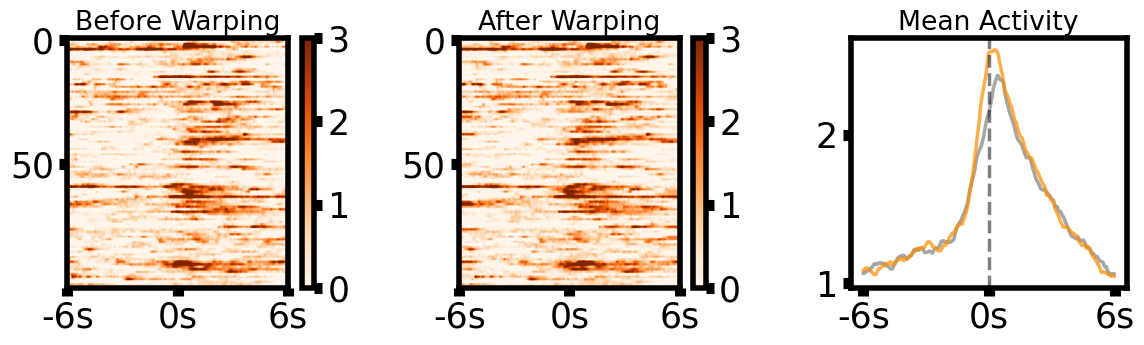

In [20]:
# Fit template on AGG data
trained_agg_model = RobustTimeWarping(
    maxlag=0.05, # 0.5s
    warp_reg_scale=0.0,
    smoothness_reg_scale=0.0,
    l2_reg_scale=0.0, 
    artifact_threshold=10, # set higher than 10 to not use
    artifact_window=(0, 40), 
    boundary_threshold=8888, # set higher than 420 to not use
    center_shifts=False, # do not arbitrarily center on 0
    niter=1 # originally 5
)

agg_new_data, agg_clean_mask = trained_agg_model.fit_transform(clean_data_filtered)
template = trained_agg_model.template
print(f"Fitted template on {agg_new_data.shape[0]} AGG trials")

# Compare the shifts to see they're different:
print(f"\nShift statistics:")
print(f"AGG shifts:  mean={trained_agg_model.shifts.mean():.2f}, std={trained_agg_model.shifts.std():.2f}")

# Verify warping quality
plt.figure(figsize=(12, 4))
roi = 12  # VMH region

# Plot before warping
plt.subplot(1, 3, 1)
filtered_data = clean_data_filtered[agg_clean_mask]
plt.imshow(filtered_data[:100, :, roi], aspect='auto', vmin=0, vmax=3, cmap='Oranges')
plt.colorbar()
plt.xticks([0, window_size//2, window_size], ['-6s', '0s', '6s'])
plt.title('Before Warping')

# Plot after warping  
plt.subplot(1, 3, 2)
plt.imshow(agg_new_data[:100, :, roi], aspect='auto', vmin=0, vmax=3, cmap='Oranges')
plt.xticks([0, window_size//2, window_size], ['-6s', '0s', '6s'])
plt.colorbar()
plt.title('After Warping')

# Plot mean traces
plt.subplot(1, 3, 3)
plt.plot(np.mean(clean_data_filtered[:, :, roi], axis=0), color='gray', label='Original', alpha=0.7)
plt.plot(np.mean(agg_new_data[:, :, roi], axis=0), color='darkorange', label='Warped', alpha=0.7)
plt.axvline(window_size//2, linestyle='--', color='black', alpha=0.5)
plt.xticks([0, window_size//2, window_size], ['-6s', '0s', '6s'])
# plt.legend()
plt.title('Mean Activity')
# plt.ylim(top=0.8, bottom=-0.2)
plt.tight_layout()

# Save
plt.savefig('agg_data_warps.svg')

Fit models to AGG data that was filtered out using template from  "global" model. 

In [21]:
def apply_agg_model_to_individual_animals_with_missing_regions(model, individual_animals_data, full_agg_clean_data):
    """
    Apply trained agg model template to individual animals with missing brain regions.
    Uses align_to_template to infer new shifts for each animal's data.
    
    Parameters:
    -----------
    model: trained RobustTimeWarping model from full agg dataset
    individual_animals_data: dict with animals 3095, 3096, 3097, 4013, 30B
    full_agg_clean_data: the full clean agg dataset used to train the model (983 trials)
    
    Returns:
    --------
    dict with warped data for each animal (with missing regions restored as NaNs)
    """
    
    warped_results = {}
    
    for animal_name, animal_data in individual_animals_data.items():
        print(f"Processing {animal_name}...")
        
        # Get data (shape: trials x time x regions)
        concatenated_data = np.concatenate(animal_data[:-1], axis=0)  # Exclude labels
        original_shape = concatenated_data.shape
        
        # Identify missing regions (NaN regions)
        missing_regions = []
        for region_idx in range(original_shape[2]):  # axis 2 = regions
            if np.isnan(concatenated_data[:, :, region_idx]).all():
                missing_regions.append(region_idx)
        
        print(f"  Missing regions: {missing_regions}")
        
        # Create a copy for processing
        data_for_warping = concatenated_data.copy()
        
        # Fill missing regions with existing region data (use first available region)
        available_regions = [i for i in range(original_shape[2]) if i not in missing_regions]
        if not available_regions:
            print(f"  No available regions for {animal_name}, skipping...")
            continue
            
        replacement_region = available_regions[0]
        
        for missing_idx in missing_regions:
            data_for_warping[:, :, missing_idx] = data_for_warping[:, :, replacement_region]
        
        # Remove NaN trials
        clean_trial_indices = []
        for trial_idx in range(data_for_warping.shape[0]):
            if not np.isnan(data_for_warping[trial_idx]).any():
                clean_trial_indices.append(trial_idx)
        
        if len(clean_trial_indices) == 0:
            print(f"  No clean trials for {animal_name}, skipping...")
            continue
            
        clean_data = data_for_warping[clean_trial_indices]
        print(f"  Animal has {clean_data.shape[0]} clean trials")
        
        # KEY CHANGE: Use align_to_template to infer new shifts
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                # Align this animal's data to the existing template
                # This will compute new optimal shifts for this specific animal
                warped_data, clean_mask, inferred_shifts = model.align_to_template(
                    clean_data, 
                    verbose=False
                )
                
                print(f"  Successfully aligned with {len(inferred_shifts)} new shifts")
                
        except Exception as e:
            print(f"  Error during template alignment for {animal_name}: {e}")
            continue
        
        # Restore missing regions as NaNs in the warped data
        for missing_idx in missing_regions:
            warped_data[:, :, missing_idx] = np.nan
        
        warped_results[animal_name] = {
            'warped_data': warped_data,
            'clean_trial_indices': clean_trial_indices,
            'missing_regions': missing_regions,
            'original_shape': original_shape,
            'inferred_shifts': inferred_shifts,
            'clean_mask': clean_mask,
            }

        
        print(f"  Final result: {warped_data.shape[0]} trials, {np.sum(clean_mask)} clean trials")
    
    return warped_results

# Define animals with missing ROIs
target_animals = ['3095', '3096', '3097', '4013', '30B']
heldout_agg_data = {animal: agg_dict[animal] for animal in target_animals if animal in agg_dict}

# Apply model template (find new shifts for held-out missing-ROI animals)
heldout_results = apply_agg_model_to_individual_animals_with_missing_regions(
    trained_agg_model,  # trained model
    heldout_agg_data, # animals with missing regions
    clean_data_filtered 
)

# Combine data sets
combined_agg_data = np.concatenate([heldout_results[animal]['warped_data'] for animal in heldout_results], axis=0)
combined_agg_data = np.concatenate([agg_new_data, combined_agg_data], axis=0)
print(f"Combined data shape: {combined_agg_data.shape}")

Processing 3095...
  Missing regions: [6, 7, 14, 15, 18, 19, 20, 21]
  Animal has 199 clean trials
Removing 0 artifact trials out of 199 total
  Successfully aligned with 199 new shifts
  Final result: 199 trials, 864 clean trials
Processing 3096...
  Missing regions: [4, 5, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  Animal has 105 clean trials
Removing 0 artifact trials out of 105 total
  Successfully aligned with 105 new shifts
  Final result: 105 trials, 1262 clean trials
Processing 3097...
  Missing regions: [10, 11, 14, 15, 16, 17, 20, 21]
  Animal has 126 clean trials
Removing 0 artifact trials out of 126 total
  Successfully aligned with 126 new shifts
  Final result: 126 trials, 1515 clean trials
Processing 4013...
  Missing regions: [0, 1, 8, 9]
  Animal has 108 clean trials
Removing 0 artifact trials out of 108 total
  Successfully aligned with 108 new shifts
  Final result: 108 trials, 100 clean trials
Processing 30B...
  Missing regions: [6, 7, 8, 9, 14, 15, 16, 17, 18, 19]
  An

OBS group

    OBS and NON animals will undergo Robust Time Warping, i.e., time warping that filters out key attack trials demonstrating some threshold of activity early in the time window. This assumes that there shouldn't be any activity prior to attacks and that any such activity likely carries over from previous attacks that are happening close in time. In order to avoid these confounds and fit a template to attack-aligned signals that features activity early in the attack window, we filter out a subset of trials that might contribute to such a template.

In [22]:
# Prepare data

# OBS
obs_data = np.concatenate([np.concatenate(obs_dict[key][:-1], axis=0) for key in list(obs_dict.keys())[:-2]], axis=0) # last two are held out
clean_obs_data = []
preserved_idxs = []
for row in range(obs_data.shape[0]):
    if np.isnan(obs_data[row]).any() == False:
        clean_obs_data.append(obs_data[row, :, :])
        preserved_idxs.append(row)
clean_obs_data = [x.reshape(1, window_size, 23) for x in clean_obs_data]
clean_obs_data = np.concatenate(clean_obs_data, axis=0)
clean_obs_data = clean_obs_data[:, :, :]

# Faux OBS
faux_data = np.concatenate([np.concatenate(obs_faux_dict[key][:-1], axis=0) for key in list(obs_dict.keys())], axis=0)
clean_faux_data = []
preserved_idxs = []
for row in range(faux_data.shape[0]):
	if np.isnan(faux_data[row]).any() == False:
		clean_faux_data.append(faux_data[row, :, :])
		preserved_idxs.append(row)
clean_faux_data = [x.reshape(1, window_size, 23) for x in clean_faux_data]
clean_faux_data = np.concatenate(clean_faux_data, axis=0)
clean_faux_data = clean_faux_data[:, :, :]

# NON
non_data = np.concatenate([np.concatenate(non_dict[key][:-1], axis=0) for key in list(non_dict.keys())], axis=0)
clean_non_data = []
preserved_idxs = []
for row in range(non_data.shape[0]):
    if np.isnan(non_data[row]).any() == False:
        clean_non_data.append(non_data[row, :, :])
        preserved_idxs.append(row)
clean_non_data = [x.reshape(1, window_size, 23) for x in clean_non_data]
clean_non_data = np.concatenate(clean_non_data, axis=0)
clean_non_data = clean_non_data[:, :, :]

# SPD
spd_data = np.concatenate([np.concatenate(speed_dict[key][:-1], axis=0) for key in list(speed_dict.keys())], axis=0)
clean_spd_data = []
preserved_idxs = []
for row in range(spd_data.shape[0]):
	if np.isnan(spd_data[row]).any() == False:
		clean_spd_data.append(spd_data[row, :, :])
		preserved_idxs.append(row)
clean_spd_data = [x.reshape(1, window_size, 23) for x in clean_spd_data]
clean_spd_data = np.concatenate(clean_spd_data, axis=0)
clean_spd_data = clean_spd_data[:, :, :]

# Intruder data
clean_max_spd = all_max_values[~np.isnan(all_max_values)]
clean_max_spd1 = clean_max_spd[:clean_obs_data.shape[0]]
clean_max_spd2 = clean_max_spd[clean_obs_data.shape[0]:]

# Resident data
clean_max2_spd = np.array(all_max2_values)[~np.isnan(all_max_values)]
clean_max2_spd1 = clean_max2_spd[:clean_obs_data.shape[0]]
clean_max2_spd2 = clean_max2_spd[clean_obs_data.shape[0]:]

# Attention data
clean_occupancy = all_occupancy_values[~np.isnan(all_max_values)]
clean_occupancy1 = clean_occupancy[:clean_obs_data.shape[0]]
clean_occupancy2 = clean_occupancy[clean_obs_data.shape[0]:]

# Grooming data
groom_data = all_grooming_values[~np.isnan(all_max_values)]
clean_groom_data1 = groom_data[:clean_obs_data.shape[0]]
clean_groom_data2 = groom_data[clean_obs_data.shape[0]:]

In [23]:
# Enhanced artifact-aware time warping with proper template alignment
class RobustTimeWarping(ShiftWarping):
    def __init__(self, artifact_threshold=1.5, artifact_window=(0, 20), 
                 boundary_threshold=420, zero_boundary_shifts=True, niter = 1, **kwargs):
        super().__init__(**kwargs)
        self.artifact_threshold = artifact_threshold
        self.artifact_window = artifact_window
        self.boundary_threshold = boundary_threshold
        self.zero_boundary_shifts = zero_boundary_shifts
        self.niter = niter
        self.boundary_corrected_count = 0
    
    def preprocess_data(self, data):
        """Remove trials with early artifacts before warping"""
        # Detect artifact trials
        early_activity = np.mean(data[:, self.artifact_window[0]:self.artifact_window[1], :], axis=(1, 2))
        clean_mask = early_activity <= self.artifact_threshold
        
        print(f"Removing {np.sum(~clean_mask)} artifact trials out of {len(clean_mask)} total")
        return data[clean_mask], clean_mask
    
    def _correct_boundary_shifts(self):
        """Set shifts at boundaries to zero"""
        boundary_threshold_value = self.boundary_threshold * self.maxlag
        boundary_mask = np.abs(self.shifts) > boundary_threshold_value
        
        self.boundary_corrected_count = np.sum(boundary_mask)
        
        if self.boundary_corrected_count > 0:
            self.shifts[boundary_mask] = 0
            print(f"Set {self.boundary_corrected_count} boundary shifts to zero (threshold: {boundary_threshold_value:.3f})")
    
    def fit_transform(self, data):
        """One-step fit and transform with artifact removal and boundary correction"""
        clean_data, clean_mask = self.preprocess_data(data)
        super().fit(clean_data, iterations=self.niter)  # Fewer iterations for robustness

        # Apply boundary shift correction
        if self.zero_boundary_shifts and self.shifts is not None:
            self._correct_boundary_shifts()
        
        return super().transform(clean_data), clean_mask
    
    def align_to_template(self, new_data, verbose=True):
        """
        Find new shifts for new_data that align it to the existing template.
        This is the CORRECT way to apply a fitted model to new data.
        
        Parameters:
        -----------
        new_data : ndarray
            New data to align to the existing template (trials x time x features)
        verbose : bool
            Whether to print alignment statistics
            
        Returns:
        --------
        aligned_data : ndarray
            New data aligned using optimized shifts
        new_shifts : ndarray  
            The shifts found for the new data
        clean_mask : ndarray
            Mask indicating which trials were kept (not artifacts)
        """
        
        # Check if model has been fitted
        if not hasattr(self, 'template') or self.template is None:
            raise ValueError("Model must be fitted first before aligning new data to template")
        
        # Preprocess new data (remove artifacts)
        clean_new_data, clean_mask = self.preprocess_data(new_data)
        
        if clean_new_data.shape[0] == 0:
            if verbose:
                print("Warning: No clean trials remaining after artifact removal")
            return np.array([]), np.array([]), clean_mask
        
        # Store original shifts to restore later
        original_shifts = self.shifts.copy() if hasattr(self, 'shifts') else None
        
        # Find NEW shifts for the new data that align it to the existing template
        if verbose:
            print(f"Finding optimal shifts for {clean_new_data.shape[0]} new trials...")
        
        self._fit_warps(clean_new_data)  # This finds new shifts!
        new_shifts = self.shifts.copy()
        
        # Apply boundary correction to new shifts
        if self.zero_boundary_shifts:
            self._correct_boundary_shifts()
            corrected_new_shifts = self.shifts.copy()
        else:
            corrected_new_shifts = new_shifts.copy()
        
        # Transform the new data using the corrected new shifts
        aligned_data = self.transform(clean_new_data)
        
        # Restore original shifts (so the original model state is preserved)
        if original_shifts is not None:
            self.shifts = original_shifts
        
        if verbose:
            print(f"New shifts range: {new_shifts.min():.1f} to {new_shifts.max():.1f}")
            print(f"Mean new shift: {new_shifts.mean():.2f} ± {new_shifts.std():.2f}")
            if self.zero_boundary_shifts and self.boundary_corrected_count > 0:
                print(f"Corrected {self.boundary_corrected_count} boundary shifts")
        
        return aligned_data, corrected_new_shifts, clean_mask
    
    def fit_and_align_to_template(self, training_data, new_data, verbose=True):
        """
        Convenience method: fit on training data, then align new data to the learned template.
        
        Parameters:
        -----------
        training_data : ndarray
            Data to fit the template on (trials x time x features)
        new_data : ndarray  
            New data to align to the template (trials x time x features)
        verbose : bool
            Whether to print progress information
            
        Returns:
        --------
        dict containing:
            - 'training_aligned': aligned training data
            - 'training_shifts': shifts used for training data  
            - 'training_mask': clean mask for training data
            - 'new_aligned': aligned new data
            - 'new_shifts': shifts found for new data
            - 'new_mask': clean mask for new data
            - 'template': the learned template
        """
        
        if verbose:
            print("=== FITTING TEMPLATE ON TRAINING DATA ===")
        
        # Fit on training data
        training_aligned, training_mask = self.fit_transform(training_data)
        training_shifts = self.shifts.copy()
        template = self.template.copy()
        
        if verbose:
            print(f"Template fitted on {training_aligned.shape[0]} clean training trials")
            print("\n=== ALIGNING NEW DATA TO TEMPLATE ===")
        
        # Align new data to the learned template
        new_aligned, new_shifts, new_mask = self.align_to_template(new_data, verbose=verbose)
        
        return {
            'training_aligned': training_aligned,
            'training_shifts': training_shifts,
            'training_mask': training_mask,
            'new_aligned': new_aligned,
            'new_shifts': new_shifts,
            'new_mask': new_mask,
            'template': template
        }

# Fit template on OBS data
trained_obs_model = RobustTimeWarping(
    maxlag=0.18, # 0.175
    warp_reg_scale=0.1, # 0.0
    smoothness_reg_scale=0.1,
    l2_reg_scale=0.1, # 0
    artifact_threshold=4, # set higher than 10 to not use
    artifact_window=(0, 40), 
    boundary_threshold=420, # set higher than 420 to not use
    center_shifts=False, 
    niter=5 # originally 30
)

obs_new_data, obs_clean_mask = trained_obs_model.fit_transform(clean_obs_data)
clean_max_spd1 = clean_max_spd1[obs_clean_mask]
clean_occupancy1 = clean_occupancy1[obs_clean_mask]
# clean_grooming1 = clean_groom_data1[obs_clean_mask]
clean_max2_spd1 = clean_max2_spd1[obs_clean_mask]
template = trained_obs_model.template
print(f"Fitted template on {obs_new_data.shape[0]} OBS trials")

# Compare the shifts to see they're different:
print(f"\nShift statistics:")
print(f"OBS shifts:  mean={trained_obs_model.shifts.mean():.2f}, std={trained_obs_model.shifts.std():.2f}")

Removing 4 artifact trials out of 1147 total


Loss: 1.20: 100%|██████████| 5/5 [00:01<00:00,  4.75it/s]

Set 389 boundary shifts to zero (threshold: 75.600)
Fitted template on 1143 OBS trials

Shift statistics:
OBS shifts:  mean=-1.36, std=30.45


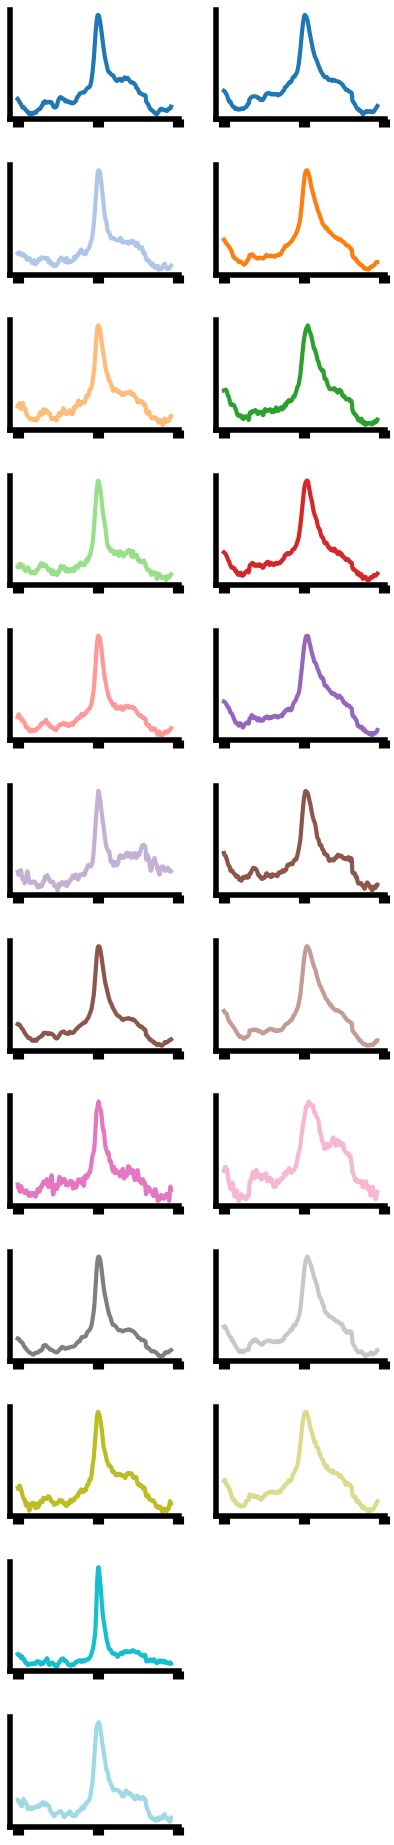

In [35]:
# Plot templates
fig, ax = plt.subplots(12, 2, figsize=(4.5, 19))

# Generate distinct colors for each signal
colors = plt.cm.tab20(np.linspace(0, 1, 23))

# Plot even-numbered populations (0, 2, 4, ..., 22) in first column
even_indices = np.arange(0, 23, 2)  # [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
for i, idx in enumerate(even_indices):
    if i < 12:  # Ensure we don't exceed subplot count
        ax[i, 0].plot(template[10:-10, idx], color=colors[idx], linewidth=3)
        ax[i, 0].set_xticks([0, 240, 480])  # Sparse ticks
        ax[i, 0].set_yticks([])  # No y ticks
        ax[i, 0].tick_params(labelbottom=False, labelleft=False)  # No labels

# Plot odd-numbered populations (1, 3, 5, ..., 21) in second column  
odd_indices = np.arange(1, 23, 2)  # [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
for i, idx in enumerate(odd_indices):
    if i < 11:  # Only 11 odd indices
        ax[i, 1].plot(template[10:-10, idx], color=colors[idx], linewidth=3)
        ax[i, 1].set_xticks([0, 240, 480])  # Sparse ticks
        ax[i, 1].set_yticks([])  # No y ticks
        ax[i, 1].tick_params(labelbottom=False, labelleft=False)  # No labels

# Remove the last subplot in second column since we only have 11 odd populations
fig.delaxes(ax[11, 1])
fig.delaxes(ax[10, 1])

sns.despine()
plt.tight_layout()
# plt.savefig('.\\figures\\fig2\\obs_template_plots.svg', dpi=300)

In [ ]:
even_indices = np.arange(0, 23, 2)  # [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]

# Requested rows [0, 2, 7, 5] in the plotted first column -> template column indices
row_to_template_col = {row: even_indices[row] for row in [0, 2, 7, 5]}
row_to_population    = {0: 1, 2: 2, 7: 21, 5: 22} 

sourceData_ED6_top = pd.DataFrame({
    f'population_{row_to_population[row]}': template[10:-10, col]
    for row, col in row_to_template_col.items()
})
sourceData_ED6_top.insert(0, 'frame', np.arange(len(sourceData_ED6_top)))

sourceData_ED6_top.to_csv('./sourceData/ED6_topleft.csv', index=False)

Apply time-warping to newer OBS animals (1185, 1186B). These animals have strong presence of artifacts in regions MeA (E), AH (E) and PA (E), therefore we remove these regions from the tensor in order to achieve proper model fit.

In [24]:
# Apply this template to new data (last 2 OBS animals)
obs_data_subset = np.concatenate([np.concatenate(obs_dict[key][:-1], axis=0) for key in list(obs_dict.keys())[-2:]], axis=0)

# Clean the subset data
clean_data_subset = []
for row in range(obs_data_subset.shape[0]):
    if np.isnan(obs_data_subset[row]).any() == False:
        clean_data_subset.append(obs_data_subset[row, :, :])
clean_data_subset = np.concatenate([x.reshape(1, window_size, 23) for x in clean_data_subset], axis=0)

obs_heldover_new_data, obs_heldover_new_shifts, obs_heldover_clean_mask = trained_obs_model.align_to_template(clean_data_subset)
print(f"Aligned {obs_heldover_new_data.shape[0]} heldover trials to OBS template")
warped_subset = obs_heldover_new_data.copy()
clean_max_spd2 = clean_max_spd2[obs_heldover_clean_mask]
clean_occupancy2 = clean_occupancy2[obs_heldover_clean_mask]
clean_grooming2 = clean_groom_data2[obs_heldover_clean_mask]
clean_max2_spd2 = clean_max2_spd2[obs_heldover_clean_mask]

Removing 1 artifact trials out of 499 total
Finding optimal shifts for 498 new trials...
Set 70 boundary shifts to zero (threshold: 75.600)
New shifts range: -86.0 to 86.0
Mean new shift: -8.56 ± 38.33
Corrected 70 boundary shifts
Aligned 498 heldover trials to OBS template


In [25]:
# Define regions to remove; these are removed from 1162B and 1185 due to no signal / high presence of artifacts
regions_to_remove = ['MeA (E)', 'AH (E)', 'PA (E)']

# Find indices of regions to remove
indices_to_remove = [region_ids.index(region) for region in regions_to_remove if region in region_ids]
print(f"Removing regions at indices: {indices_to_remove}")
print(f"Regions being removed: {[region_ids[i] for i in indices_to_remove]}")
warped_subset[:, :, indices_to_remove] = np.nan  # Remove regions that were not present in the original data

Removing regions at indices: [10, 8, 20]
Regions being removed: ['MeA (E)', 'AH (E)', 'PA (E)']


In [26]:
# Stack new data with full warped data
combined_obs_data = np.concatenate([obs_new_data, warped_subset], axis=0)
all_spd_values = np.concatenate([clean_max_spd1, clean_max_spd2], axis=0)
all_occupancy_values = np.concatenate([clean_occupancy1, clean_occupancy2], axis=0)
# all_grooming_values = np.concatenate([clean_grooming1, clean_grooming2], axis=0)
all_spd2_values = np.concatenate([clean_max2_spd1, clean_max2_spd2], axis=0)

print(f"obs_new_data shape: {obs_new_data.shape}")
print(f"warped_subset_full shape: {warped_subset.shape}")
print(f"Combined shape: {combined_obs_data.shape}")

obs_new_data shape: (1143, 480, 23)
warped_subset_full shape: (498, 480, 23)
Combined shape: (1641, 480, 23)


Plot shift distributions

Shift range: -75.0 to 75.0 time points
Shift range in time: -1.875 to 1.875 seconds
Mean shift: -2.32 ± 28.37 time points
Mean shift in time: -0.058 ± 0.709 seconds

=== SHIFT ASYMMETRY TESTS (nonzero shifts only, n=1115) ===
Negative shifts: 698  |  Positive shifts: 417
Mean nonzero shift: -0.0853 s
Median nonzero shift: -0.0250 s
Wilcoxon signed-rank (one-sided: shifts < 0):
  W = 258136.5, p = 3.98e-07
One-sample t-test (one-sided: mean < 0):
  t = -3.313, p = 4.76e-04


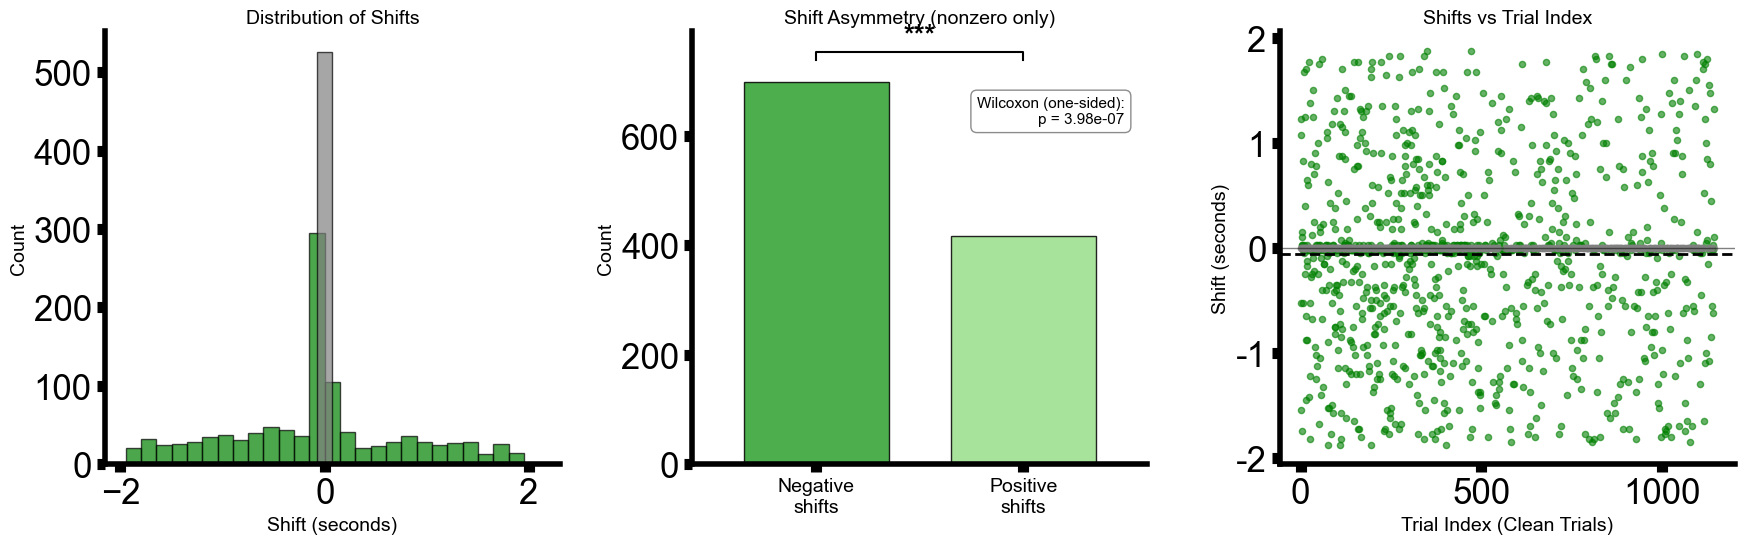

In [27]:
# Extract shifts from the trained model
shifts = trained_obs_model.shifts
clean_trial_indices = np.where(obs_clean_mask)[0]
artifact_trial_indices = np.where(~obs_clean_mask)[0]

shifts2 = obs_heldover_new_shifts.copy()
clean_trial_indices2 = np.where(obs_heldover_clean_mask)[0]
artifact_trial_indices2 = np.where(~obs_heldover_clean_mask)[0]

all_shifts = np.concatenate([shifts, shifts2], axis=0)
all_clean_indices = np.concatenate([clean_trial_indices, clean_trial_indices2], axis=0)
all_artifact_indices = np.concatenate([artifact_trial_indices, artifact_trial_indices2], axis=0)

shifts = all_shifts
clean_trial_indices = all_clean_indices
artifact_trial_indices = all_artifact_indices

# Convert shifts to time units (assuming 40 Hz sampling rate)
shifts_time = shifts / 40  # Convert to seconds
sampling_rate = 40  # Hz
max_lag_time = 0.2 * (window_size / sampling_rate)  # Convert maxlag to actual time

print(f"Shift range: {shifts.min():.1f} to {shifts.max():.1f} time points")
print(f"Shift range in time: {shifts_time.min():.3f} to {shifts_time.max():.3f} seconds")
print(f"Mean shift: {shifts.mean():.2f} ± {shifts.std():.2f} time points")
print(f"Mean shift in time: {shifts_time.mean():.3f} ± {shifts_time.std():.3f} seconds")

# Statistical test: are shifts asymmetrically distributed (more negative)?
from scipy.stats import wilcoxon, ttest_1samp

# Only consider nonzero shifts for asymmetry testing
nonzero_shifts_all = shifts_time[shifts_time != 0]
n_negative = np.sum(nonzero_shifts_all < 0)
n_positive = np.sum(nonzero_shifts_all > 0)
n_nonzero = len(nonzero_shifts_all)

# 1. Wilcoxon signed-rank test: are nonzero shifts significantly < 0?
stat_wilcox, p_wilcox_two = wilcoxon(nonzero_shifts_all)
# One-sided (less than 0)
stat_wilcox_one, p_wilcox_one = wilcoxon(nonzero_shifts_all, alternative='less')

# 2. One-sample t-test: mean shift != 0 (or < 0)
t_stat, p_ttest_two = ttest_1samp(nonzero_shifts_all, 0)
_, p_ttest_one = ttest_1samp(nonzero_shifts_all, 0, alternative='less')

print(f"\n=== SHIFT ASYMMETRY TESTS (nonzero shifts only, n={n_nonzero}) ===")
print(f"Negative shifts: {n_negative}  |  Positive shifts: {n_positive}")
print(f"Mean nonzero shift: {np.mean(nonzero_shifts_all):.4f} s")
print(f"Median nonzero shift: {np.median(nonzero_shifts_all):.4f} s")
print(f"Wilcoxon signed-rank (one-sided: shifts < 0):")
print(f"  W = {stat_wilcox_one:.1f}, p = {p_wilcox_one:.2e}")
print(f"One-sample t-test (one-sided: mean < 0):")
print(f"  t = {t_stat:.3f}, p = {p_ttest_one:.2e}")

# Helper for sig stars
def get_sig_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Set global font to Arial
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

# Create comprehensive shift analysis plots — now 1x3
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Histogram of shifts (seconds) — dedicated bin for 0
ax1 = axes[0]

# Separate exact zeros from nonzero shifts
zero_count = np.sum(shifts_time == 0)
nonzero_shifts = shifts_time[shifts_time != 0]

# Bin the nonzero shifts symmetrically
bin_width = 0.15  # seconds — adjust to taste
max_abs_shift = np.max(np.abs(nonzero_shifts)) if len(nonzero_shifts) > 0 else 1.0
n_bins_side = int(np.ceil(max_abs_shift / bin_width))
bin_edges = np.arange(-n_bins_side, n_bins_side + 2) * bin_width

# Plot nonzero histogram — green for shifted
counts_time, bins_time, patches_time = ax1.hist(nonzero_shifts, bins=bin_edges, alpha=0.7,
                                                 color='green', edgecolor='black')

# Plot the zero bar explicitly — gray for unshifted
bar_width = bin_width
ax1.bar(0, zero_count, width=bar_width, alpha=0.7, color='gray', edgecolor='black',
        label=f'0 shift (n={zero_count})')

ax1.set_xlabel('Shift (seconds)', fontsize=14)
ax1.set_ylabel('Count', fontsize=14)
ax1.set_title('Distribution of Shifts', fontsize=14)

# Plot 2: Bar plot — negative vs positive shift counts with Wilcoxon test
ax_bar = axes[1]

bar_positions = [0, 0.5]
bar_heights = [n_negative, n_positive]
bar_colors = ['#2ca02c', '#98df8a']  # dark green for negative, light green for positive
bar_labels = [f'Negative\n(n={n_negative})', f'Positive\n(n={n_positive})']

ax_bar.bar(bar_positions, bar_heights, color=bar_colors, edgecolor='black',
           width=0.35, alpha=0.85)

ax_bar.set_xticks(bar_positions)
ax_bar.set_xticklabels(['Negative\nshifts', 'Positive\nshifts'], fontsize=14)
ax_bar.set_ylabel('Count', fontsize=14)
ax_bar.set_title('Shift Asymmetry (nonzero only)', fontsize=14)

# Add significance bracket
stars_wilcox = get_sig_stars(p_wilcox_one)
max_y = max(bar_heights)
bracket_y = max_y + max_y * 0.08
bracket_h = max_y * 0.02
ax_bar.plot([bar_positions[0], bar_positions[0], bar_positions[1], bar_positions[1]],
            [bracket_y - bracket_h, bracket_y, bracket_y, bracket_y - bracket_h],
            'k-', linewidth=1.5)
ax_bar.text(np.mean(bar_positions), bracket_y + max_y * 0.01, stars_wilcox,
            ha='center', va='bottom', fontsize=20, fontweight='bold', fontfamily='Arial')

# Add Wilcoxon p-value text
ax_bar.text(0.95, 0.85, f'Wilcoxon (one-sided):\np = {p_wilcox_one:.2e}',
            transform=ax_bar.transAxes, ha='right', va='top',
            fontsize=11, fontfamily='Arial',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9))

# Tighten x-axis
ax_bar.set_xlim(-0.3, 0.5 + 0.3)

# Plot 3: Shifts vs trial index — color by zero vs nonzero
ax2 = axes[2]

# Separate zero and nonzero shifts for coloring
zero_mask = shifts == 0
nonzero_mask = ~zero_mask

# Plot unshifted (0) as gray, shifted (nonzero) as green
ax2.scatter(clean_trial_indices[nonzero_mask], shifts[nonzero_mask], alpha=0.6, s=20, color='green', label='Shifted')
ax2.scatter(clean_trial_indices[zero_mask], shifts[zero_mask], alpha=0.6, s=20, color='gray', label='Unshifted')

ax2.axhline(shifts.mean(), color='black', linestyle='--', linewidth=2,
            label=f'Mean: {shifts.mean():.1f}')
ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_xlabel('Trial Index (Clean Trials)', fontsize=14)
ax2.set_ylabel('Shift (seconds)', fontsize=14)
# Symmetric y-axis around 0
max_abs_shift_pts = np.max(np.abs(shifts))
y_lim = max(max_abs_shift_pts * 1.1, 80)
ax2.set_ylim(-y_lim, y_lim)
ax2.set_yticks([-80, -40, 0, 40, 80])
ax2.set_yticklabels([-2, -1, 0, 1, 2])
ax2.set_title('Shifts vs Trial Index', fontsize=14)

sns.despine()

plt.tight_layout()
# plt.savefig('./figures/fig2/obs_shifts_analysis.svg', dpi=300)
plt.show()

In [ ]:
sourceData_ED6a_bottom_left = pd.DataFrame({
    'shift_sec': shifts_time,
    'is_zero': shifts_time == 0,
})
sourceData_ED6a_bottom_left.to_csv('./sourceData/ED6a_bottom_left.csv', index=False)

# ── Panel 2 (middle): negative vs positive shift asymmetry ─────────────────
sourceData_ED6a_bottom_middle = pd.DataFrame({
    'direction': ['Negative', 'Positive'],
    'count': [n_negative, n_positive],
})
sourceData_ED6a_bottom_middle['n_nonzero'] = n_nonzero
sourceData_ED6a_bottom_middle['wilcoxon_stat_one_sided'] = stat_wilcox_one
sourceData_ED6a_bottom_middle['wilcoxon_p_one_sided'] = p_wilcox_one
sourceData_ED6a_bottom_middle['wilcoxon_stat_two_sided'] = stat_wilcox
sourceData_ED6a_bottom_middle['wilcoxon_p_two_sided'] = p_wilcox_two
sourceData_ED6a_bottom_middle['ttest_stat'] = t_stat
sourceData_ED6a_bottom_middle['ttest_p_one_sided'] = p_ttest_one
sourceData_ED6a_bottom_middle['ttest_p_two_sided'] = p_ttest_two
sourceData_ED6a_bottom_middle.to_csv('./sourceData/ED6a_bottom_middle.csv', index=False)

# ── Panel 3 (right): shift vs trial index ───────────────────────────────────
# Plotted values are raw `shifts` (sample units, 40 Hz), with y-axis ticks
# manually relabeled to seconds via a fixed /40 conversion — not shifts_time.
# Keeping both raw and seconds-converted columns so the CSV matches what's
# rendered without requiring the reader to know the tick-relabel factor.
sourceData_ED6a_bottom_right = pd.DataFrame({
    'trial_index': clean_trial_indices,
    'shift_samples': shifts,
    'shift_sec': shifts / sampling_rate,
    'is_zero': shifts == 0,
})
sourceData_ED6a_bottom_right.to_csv('./sourceData/ED6a_bottom_right.csv', index=False)

Real attacks:  0.5636 ± 0.0108 (n=1641)
Faux attacks:  0.4621 ± 0.0105 (n=1645)
Mann-Whitney U = 1522309.0, p = 7.87e-11 ***

=== PRE (-3 to 0s) vs POST (0 to +3s) ATTENTION, WITHIN CONDITION ===
Real: pre=0.5371±0.0109  post=0.5636±0.0108  Wilcoxon signed-rank: stat=161744.500, p=8.330e-06 ***  (n=1641)
Faux: pre=0.4554±0.0105  post=0.4621±0.0105  Wilcoxon signed-rank: stat=224883.500, p=2.465e-01 n.s.  (n=1645)

Pre- vs post-attack-onset attention — stats table
   condition  pre_mean  pre_sem  post_mean  post_sem                 test     stat  p_value  sig    n
Real attacks  0.537142 0.010872   0.563605  0.010835 Wilcoxon signed-rank 161744.5 0.000008  *** 1641
Faux attacks  0.455388 0.010479   0.462052  0.010550 Wilcoxon signed-rank 224883.5 0.246484 n.s. 1645


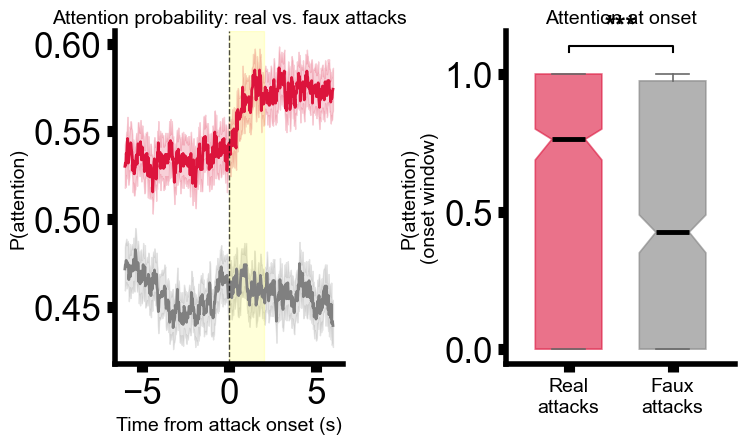

In [51]:
# Attention probability time course

# (Ensure that you've fully ran the section that ranks attacks by attention state - a few cells before.
# AND the section that grabs all the attention metadata a few cells below. After you've done both,
# come back here. 

# This section is a bit gimmicky because it uses the "all_clean_indices" variable from the attention metadata section, 
# which is a list of indices of trials that were kept after artifact removal. 
# It also uses the "all_sniffing_windows" variable, which is a 2D array of attention probability time courses for all trials. 
# The goal here is to compute the mean attention probability time course for real attacks and faux attacks, 
# and then compare them statistically in a critical window around attack onset.

# Compute attention probability time courses
faux_windows = all_faux_windows.copy()
attention_windows = all_sniffing_windows[all_clean_indices, :]
sampling_rate = 40  # Hz
n_time = attention_windows.shape[1]
time_axis = (np.arange(n_time) - 240) / sampling_rate  # center on attack onset (index 240)
animal_mappings = animal_trial_mappings_with_artifacts['obs']

# Binary arrays: probability = mean across trials at each time point
real_prob = np.nanmean(attention_windows, axis=0)
faux_prob = np.nanmean(faux_windows, axis=0)

# SEM across trials
real_sem = np.nanstd(attention_windows, axis=0) / np.sqrt(attention_windows.shape[0])
faux_sem = np.nanstd(faux_windows, axis=0) / np.sqrt(faux_windows.shape[0])

# Statistical comparison in critical window around onset
from scipy.stats import mannwhitneyu

window_start = 240
window_end = 320

# Mean attention per trial in onset window
real_onset_prob = np.nanmean(attention_windows[:, window_start:window_end], axis=1)
faux_onset_prob = np.nanmean(faux_windows[:, window_start:window_end], axis=1)

stat_mw, p_mw = mannwhitneyu(real_onset_prob, faux_onset_prob, alternative='two-sided')

def get_sig_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

print(f"Real attacks:  {np.mean(real_onset_prob):.4f} ± {np.std(real_onset_prob)/np.sqrt(len(real_onset_prob)):.4f} (n={len(real_onset_prob)})")
print(f"Faux attacks:  {np.mean(faux_onset_prob):.4f} ± {np.std(faux_onset_prob)/np.sqrt(len(faux_onset_prob)):.4f} (n={len(faux_onset_prob)})")
print(f"Mann-Whitney U = {stat_mw:.1f}, p = {p_mw:.2e} {get_sig_stars(p_mw)}")

# --- Pre- vs Post-attack-onset attention comparison (real vs faux) ───────────
from scipy.stats import wilcoxon, ttest_rel, shapiro

pre_window  = (160, 240)   # -3s to 0s
post_window = (240, 320)   # 0s to +3s

def pre_post_attention_test(windows, pre_window, post_window):
    """
    Paired comparison of per-trial mean P(attention) before vs after
    attack onset. Pairing is within-trial (same trial's pre and post
    means), so a paired test is appropriate.
    """
    pre_vals  = np.nanmean(windows[:, pre_window[0]:pre_window[1]], axis=1)
    post_vals = np.nanmean(windows[:, post_window[0]:post_window[1]], axis=1)

    valid = ~np.isnan(pre_vals) & ~np.isnan(post_vals)
    pre_vals, post_vals = pre_vals[valid], post_vals[valid]

    diffs = post_vals - pre_vals
    _, p_norm = shapiro(diffs) if len(diffs) >= 3 else (None, 0.0)

    if p_norm > 0.05:
        stat, p = ttest_rel(pre_vals, post_vals)
        test_label = 'paired t-test'
    else:
        stat, p = wilcoxon(pre_vals, post_vals)
        test_label = 'Wilcoxon signed-rank'

    return {
        'pre_vals': pre_vals, 'post_vals': post_vals,
        'pre_mean': np.mean(pre_vals), 'pre_sem': np.std(pre_vals) / np.sqrt(len(pre_vals)),
        'post_mean': np.mean(post_vals), 'post_sem': np.std(post_vals) / np.sqrt(len(post_vals)),
        'test': test_label, 'stat': stat, 'p': p, 'n': len(pre_vals),
    }

real_pre_post = pre_post_attention_test(attention_windows, pre_window, post_window)
faux_pre_post = pre_post_attention_test(faux_windows, pre_window, post_window)

print(f"\n=== PRE (-3 to 0s) vs POST (0 to +3s) ATTENTION, WITHIN CONDITION ===")
for label, res in [('Real', real_pre_post), ('Faux', faux_pre_post)]:
    sig = get_sig_stars(res['p'])
    print(f"{label}: pre={res['pre_mean']:.4f}±{res['pre_sem']:.4f}  "
          f"post={res['post_mean']:.4f}±{res['post_sem']:.4f}  "
          f"{res['test']}: stat={res['stat']:.3f}, p={res['p']:.3e} {sig}  (n={res['n']})")

# ── Stats table ────────────────────────────────────────────────────────────────
stats_table_pre_post = pd.DataFrame([
    {
        'condition': label,
        'pre_mean': res['pre_mean'], 'pre_sem': res['pre_sem'],
        'post_mean': res['post_mean'], 'post_sem': res['post_sem'],
        'test': res['test'], 'stat': res['stat'], 'p_value': res['p'],
        'sig': get_sig_stars(res['p']), 'n': res['n'],
    }
    for label, res in [('Real attacks', real_pre_post), ('Faux attacks', faux_pre_post)]
])

print(f'\n{"="*90}')
print('Pre- vs post-attack-onset attention — stats table')
print(f'{"="*90}')
print(stats_table_pre_post.to_string(index=False))
      

# --- Plot ---
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# Panel 1: Time course — real vs faux
ax1 = axes[0]
ax1.plot(time_axis, real_prob, color='crimson', linewidth=2, label='Real attacks')
ax1.fill_between(time_axis, real_prob - real_sem, real_prob + real_sem,
                 color='crimson', alpha=0.2)
ax1.plot(time_axis, faux_prob, color='gray', linewidth=2, label='Faux attacks')
ax1.fill_between(time_axis, faux_prob - faux_sem, faux_prob + faux_sem,
                 color='gray', alpha=0.2)

ax1.axvspan((window_start - 240) / sampling_rate, (window_end - 240) / sampling_rate,
            color='yellow', alpha=0.15, label='Onset window')
ax1.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Attack onset')

ax1.set_xlabel('Time from attack onset (s)', fontsize=14)
ax1.set_ylabel('P(attention)', fontsize=14)
ax1.set_title('Attention probability: real vs. faux attacks', fontsize=14)

# Panel 2: Box-and-whiskers — real vs faux
ax2 = axes[1]

box_positions = [0, 0.5]
box_data      = [real_onset_prob, faux_onset_prob]
box_colors    = ['crimson', 'gray']

bp = ax2.boxplot(box_data, positions=box_positions, widths=0.32,
                 patch_artist=True, notch=True, bootstrap=1000,
                 showfliers=False,
                 medianprops=dict(color='black', linewidth=3.5),
                 boxprops=dict(linewidth=1.2, alpha=0.6),
                 whiskerprops=dict(linewidth=1.2, color='dimgray'),
                 capprops=dict(linewidth=1.2, color='dimgray'))

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)

ax2.set_xticks(box_positions)
ax2.set_xticklabels(['Real\nattacks', 'Faux\nattacks'], fontsize=14)
ax2.set_ylabel('P(attention)\n(onset window)', fontsize=14)
ax2.set_title('Attention at onset', fontsize=14)

stars = get_sig_stars(p_mw)
max_y = max(np.percentile(d, 75) + 1.5*(np.percentile(d,75)-np.percentile(d,25))
            for d in box_data)
bracket_y = 1 + 1 * 0.1
bracket_h = 1 * 0.02
ax2.plot([box_positions[0], box_positions[0], box_positions[1], box_positions[1]],
         [bracket_y - bracket_h, bracket_y, bracket_y, bracket_y - bracket_h],
         'k-', linewidth=1.5)
ax2.text(np.mean(box_positions), bracket_y + max_y * 0.01, stars,
         ha='center', va='bottom', fontsize=20, fontweight='bold')

ax2.set_xlim(-0.3, 0.8)

sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig2_obs_real_vs_faux_attention.svg', dpi=300)
plt.show()

In [68]:
# Left panel — time course, real vs faux
sourceData_2g_left = pd.DataFrame({
    'time_from_onset_s': time_axis,
    'real_mean': real_prob,
    'real_sem': real_sem,
    'faux_mean': faux_prob,
    'faux_sem': faux_sem,
})
sourceData_2g_left.to_csv('./sourceData/2g_left.csv', index=False)

# Right panel — per-trial onset-window attention, real vs faux
sourceData_2g_right = pd.concat([
    pd.DataFrame({'condition': 'Real', 'p_attention_onset': real_onset_prob}),
    pd.DataFrame({'condition': 'Faux', 'p_attention_onset': faux_onset_prob}),
], ignore_index=True)
sourceData_2g_right['mannwhitney_U'] = stat_mw
sourceData_2g_right['mannwhitney_p'] = p_mw
sourceData_2g_right.to_csv('./sourceData/2g_right.csv', index=False)

Apply time-warping on random, faux aggression data

In [25]:
# Process data
faux_new_data, faux_clean_mask = trained_obs_model.fit_transform(clean_faux_data)

# Extract template
template = trained_obs_model.template

Removing 0 artifact trials out of 1961 total


Loss: 0.97: 100%|██████████| 5/5 [00:01<00:00,  2.73it/s]

Set 428 boundary shifts to zero (threshold: 75.600)


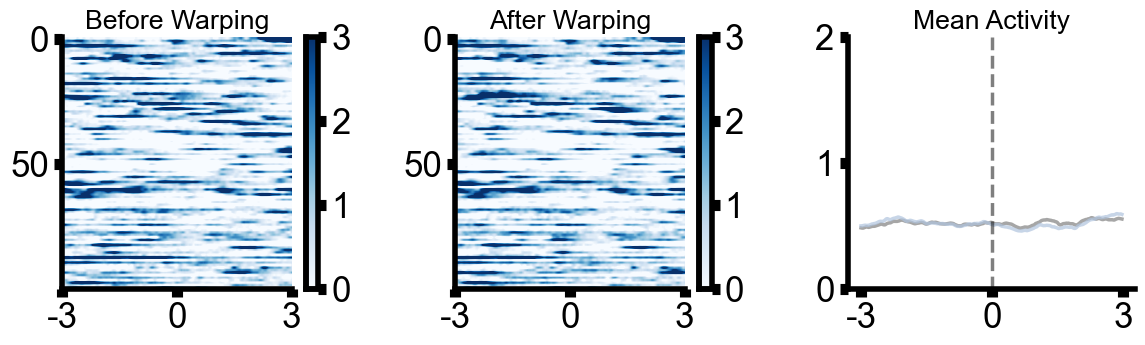

In [26]:
# Verify warping quality
plt.figure(figsize=(12, 4))
roi = 12  # VMH region

# Plot before warping
plt.subplot(1, 3, 1)
filtered_data = clean_faux_data[faux_clean_mask]
plt.imshow(filtered_data[:100, 120:-120, roi], aspect='auto', vmin=0, vmax=3, cmap='Blues')
plt.colorbar()
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.title('Before Warping')

# Plot after warping  
plt.subplot(1, 3, 2)
plt.imshow(faux_new_data[:100, 120:-120, roi], aspect='auto', vmin=0, vmax=3, cmap='Blues')
plt.colorbar()
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.title('After Warping')

# Plot mean traces
plt.subplot(1, 3, 3)
plt.plot(np.mean(clean_faux_data[:, 120:-120, roi], axis=0), color='gray', label='Original', alpha=0.7)
plt.plot(np.mean(faux_new_data[:, 120:-120, roi], axis=0), color='lightsteelblue', label='Warped', alpha=0.7)
plt.axvline(window_size//4, linestyle='--', color='black', alpha=0.5)
plt.ylim(top=2, bottom=0)
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
# plt.legend()
plt.title('Mean Activity')
sns.despine()
plt.tight_layout()

# Save
# plt.savefig('./figures/ext_fig2_faux_data_warps.svg')

In [41]:
roi = 12  # VMH region
filtered_data = clean_faux_data[faux_clean_mask]

n_frames = filtered_data.shape[1] - 240  # post [120:-120] slice length
frame_idx = np.arange(n_frames)

# ── Left: before warping (heatmap, first 100 trials) ────────────────────────
sourceData_ED6c_top_left = pd.DataFrame(
    filtered_data[:100, 120:-120, roi],
    columns=[f'frame_{f}' for f in frame_idx]
)
sourceData_ED6c_top_left.insert(0, 'trial', np.arange(100))
sourceData_ED6c_top_left.to_csv('./sourceData/ED6c_top_left.csv', index=False)

# ── Middle: after warping (heatmap, first 100 trials) ────────────────────────
sourceData_ED6c_top_middle = pd.DataFrame(
    faux_new_data[:100, 120:-120, roi],
    columns=[f'frame_{f}' for f in frame_idx]
)
sourceData_ED6c_top_middle.insert(0, 'trial', np.arange(100))
sourceData_ED6c_top_middle.to_csv('./sourceData/ED6c_top_middle.csv', index=False)

# ── Right: mean traces, original vs warped ───────────────────────────────────
sourceData_ED6c_top_right = pd.DataFrame({
    'frame_idx': frame_idx,
    'original_mean': np.mean(clean_faux_data[:, 120:-120, roi], axis=0),
    'warped_mean': np.mean(faux_new_data[:, 120:-120, roi], axis=0),
})
sourceData_ED6c_top_right.to_csv('./sourceData/ED6c_top_right.csv', index=False)

Apply time-warping on high resident velocity but not aggression data

In [27]:
# Process data
spd_new_data, spd_clean_mask = trained_obs_model.fit_transform(clean_spd_data)

# Extract template
template = trained_obs_model.template

Removing 3 artifact trials out of 2437 total


Loss: 1.03: 100%|██████████| 5/5 [00:02<00:00,  2.13it/s]

Set 434 boundary shifts to zero (threshold: 75.600)


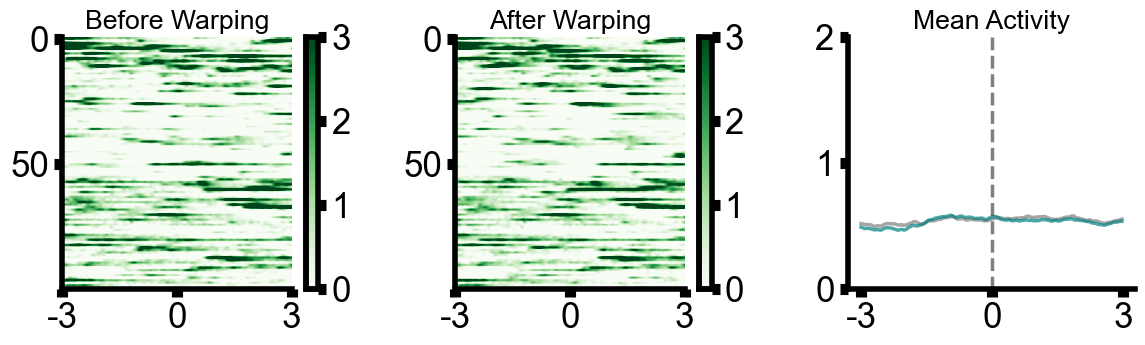

In [ ]:
# Verify warping quality
plt.figure(figsize=(12, 4))
roi = 12  # VMH region

# Plot before warping
plt.subplot(1, 3, 1)
filtered_data = clean_spd_data[spd_clean_mask]
plt.imshow(filtered_data[:100, 120:-120, roi], aspect='auto', vmin=0, vmax=3, cmap='Greens')
plt.colorbar()
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.title('Before Warping')

# Plot after warping  
plt.subplot(1, 3, 2)
plt.imshow(spd_new_data[:100, 120:-120, roi], aspect='auto', vmin=0, vmax=3, cmap='Greens')
plt.colorbar()
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.title('After Warping')

# Plot mean traces
plt.subplot(1, 3, 3)
plt.plot(np.mean(clean_spd_data[:, 120:-120, roi], axis=0), color='gray', label='Original', alpha=0.7)
plt.plot(np.mean(spd_new_data[:, 120:-120, roi], axis=0), color='teal', label='Warped', alpha=0.7)
plt.axvline(window_size//4, linestyle='--', color='black', alpha=0.5)
plt.ylim(top=2, bottom=0)
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
# plt.legend()
plt.title('Mean Activity')
sns.despine()
plt.tight_layout()

# Save
# plt.savefig('./figures/ext_fig2_spd_data_warps.svg')

In [35]:
# ── Source data export: ED6c_middle_left / middle / right ────────────────────
os.makedirs('./sourceData', exist_ok=True)

roi = 12  # VMH region
filtered_data = clean_spd_data[spd_clean_mask]

n_frames = filtered_data.shape[1] - 240  # post [120:-120] slice length
frame_idx = np.arange(n_frames)

# ── Left: before warping (heatmap, first 100 trials) ────────────────────────
sourceData_ED6c_middle_left = pd.DataFrame(
    filtered_data[:100, 120:-120, roi],
    columns=[f'frame_{f}' for f in frame_idx]
)
sourceData_ED6c_middle_left.insert(0, 'trial', np.arange(100))
sourceData_ED6c_middle_left.to_csv('./sourceData/ED6c_middle_left.csv', index=False)

# ── Middle: after warping (heatmap, first 100 trials) ────────────────────────
sourceData_ED6c_middle_middle = pd.DataFrame(
    spd_new_data[:100, 120:-120, roi],
    columns=[f'frame_{f}' for f in frame_idx]
)
sourceData_ED6c_middle_middle.insert(0, 'trial', np.arange(100))
sourceData_ED6c_middle_middle.to_csv('./sourceData/ED6c_middle_middle.csv', index=False)

# ── Right: mean traces, original vs warped ───────────────────────────────────
sourceData_ED6c_middle_right = pd.DataFrame({
    'frame_idx': frame_idx,
    'original_mean': np.mean(clean_spd_data[:, 120:-120, roi], axis=0),
    'warped_mean': np.mean(spd_new_data[:, 120:-120, roi], axis=0),
})
sourceData_ED6c_middle_right.to_csv('./sourceData/ED6c_middle_right.csv', index=False)

NON group

Removing 0 artifact trials out of 1612 total


Loss: 0.74: 100%|██████████| 5/5 [00:01<00:00,  3.33it/s]


Set 373 boundary shifts to zero (threshold: 75.600)


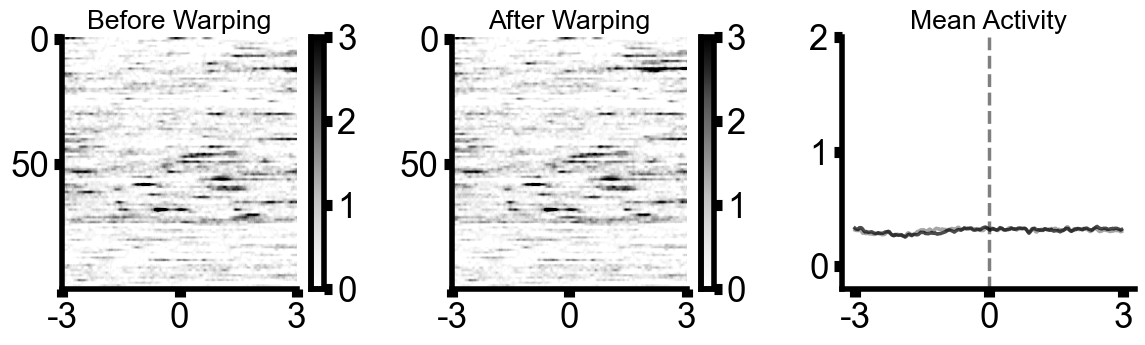

In [28]:
# NON data warping
non_new_data, non_clean_mask = trained_obs_model.fit_transform(clean_non_data)

# Verify warping quality
plt.figure(figsize=(12, 4))
roi = 12  # VMH region

# Plot before warping
plt.subplot(1, 3, 1)
filtered_data = clean_non_data[non_clean_mask]
plt.imshow(filtered_data[:100, 120:-120, roi], aspect='auto', vmin=0, vmax=3, cmap='Grays')
plt.colorbar()
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.title('Before Warping')

# Plot after warping  
plt.subplot(1, 3, 2)
plt.imshow(non_new_data[:100, 120:-120, roi], aspect='auto', vmin=0, vmax=3, cmap='Grays')
plt.colorbar()
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
plt.title('After Warping')

# Plot mean traces
plt.subplot(1, 3, 3)
plt.plot(np.mean(clean_non_data[:, 120:-120, roi], axis=0), color='gray', label='Original', alpha=0.7)
plt.plot(np.mean(non_new_data[:, 120:-120, roi], axis=0), color='black', label='Warped', alpha=0.7)
plt.axvline(window_size//4, linestyle='--', color='black', alpha=0.5)
plt.ylim(top=2, bottom=-0.2)
plt.xticks([0, window_size//4, window_size-240], ['-3', '0', '3'], fontfamily='Arial')
plt.yticks(fontfamily='Arial')
# plt.legend()
plt.title('Mean Activity')
sns.despine()
plt.tight_layout()

# Save
plt.savefig('./figures/ext_fig2_non_data_warps.svg')

In [23]:
roi = 12  # VMH region
filtered_data = clean_non_data[non_clean_mask]

# Frame index after the [120:-120] time-window slice, consistent across all
# three panels. Left as raw frame index rather than converted to seconds,
# since the tick-to-time mapping (window_size//4 -> 0s, window_size-240 -> 3s)
# depends on `window_size`'s numeric value, which isn't set in this cell —
# confirm the conversion factor before adding a seconds column if needed.
n_frames = filtered_data.shape[1] - 240  # post-slice length (120:-120 removes 240 total)
frame_idx = np.arange(n_frames)

# ── Left: before warping (heatmap, first 100 trials) ────────────────────────
sourceData_ED6c_bottom_left = pd.DataFrame(
    filtered_data[:100, 120:-120, roi],
    columns=[f'frame_{f}' for f in frame_idx]
)
sourceData_ED6c_bottom_left.insert(0, 'trial', np.arange(100))
sourceData_ED6c_bottom_left.to_csv('./sourceData/ED6c_bottom_left.csv', index=False)

# ── Middle: after warping (heatmap, first 100 trials) ────────────────────────
sourceData_ED6c_bottom_middle = pd.DataFrame(
    non_new_data[:100, 120:-120, roi],
    columns=[f'frame_{f}' for f in frame_idx]
)
sourceData_ED6c_bottom_middle.insert(0, 'trial', np.arange(100))
sourceData_ED6c_bottom_middle.to_csv('./sourceData/ED6c_bottom_middle.csv', index=False)

# ── Right: mean traces, original vs warped ───────────────────────────────────
sourceData_ED6c_bottom_right = pd.DataFrame({
    'frame_idx': frame_idx,
    'original_mean': np.mean(clean_non_data[:, 120:-120, roi], axis=0),
    'warped_mean': np.mean(non_new_data[:, 120:-120, roi], axis=0),
})
sourceData_ED6c_bottom_right.to_csv('./sourceData/ED6c_bottom_right.csv', index=False)

2. Index of all attack trials

In [29]:
def create_comprehensive_trial_indices_with_spurious_and_artifact_tracking(agg_dict, obs_dict, non_dict):
    """
    Create comprehensive trial indices accounting for both spurious trials (NaNs) 
    and artifact trials (filtered by RobustTimeWarping for OBS, except 1185 and 1162B).
    
    Returns:
    --------
    dict containing trial mapping info for all datasets with artifact tracking
    """
    
    def process_agg_dataset(data_dict):
        """Process AGG dataset (no artifact filtering)"""
        animal_info = {}
        current_clean_idx = 0
        
        for animal_idx, (animal_name, animal_data) in enumerate(data_dict.items()):
            all_trials = np.concatenate(animal_data[:-1], axis=0)
            total_original = all_trials.shape[0]
            
            # Count clean trials (no NaNs)
            clean_trials = []
            for trial_idx in range(total_original):
                if not np.isnan(all_trials[trial_idx]).all():
                    clean_trials.append(trial_idx)
            
            total_clean = len(clean_trials)
            spurious_count = total_original - total_clean
            
            if total_clean > 0:
                clean_start = current_clean_idx
                clean_end = current_clean_idx + total_clean - 1
                current_clean_idx += total_clean
            else:
                clean_start = None
                clean_end = None
            
            animal_info[animal_name] = {
                'trial_range_clean': {'start': clean_start, 'end': clean_end},
                'total_trials_original': total_original,
                'total_trials_clean': total_clean,
                'spurious_count': spurious_count,
                'artifact_count': 0,  # No artifact filtering for AGG
                'animal_index': animal_idx
            }
        
        return animal_info
    
    def process_obs_dataset(data_dict):
        """Process OBS dataset with artifact filtering simulation (except for 1185 and 1162B)"""
        animal_info = {}
        current_clean_idx = 0
        
        # Animals that had artifact filtering applied
        artifact_filtered_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
        # Animals that had region removal instead (no artifact filtering)
        region_removed_animals = []
        
        # Simulate the RobustTimeWarping artifact detection parameters
        artifact_threshold = 4
        artifact_window = (0, 40)
        
        for animal_idx, (animal_name, animal_data) in enumerate(data_dict.items()):
            all_trials = np.concatenate(animal_data[:-1], axis=0)
            total_original = all_trials.shape[0]
            
            # First filter: Remove trials with NaNs
            nan_free_trials = []
            nan_free_indices = []
            for trial_idx in range(total_original):
                if not np.isnan(all_trials[trial_idx]).any():
                    nan_free_trials.append(all_trials[trial_idx])
                    nan_free_indices.append(trial_idx)
            
            spurious_count = total_original - len(nan_free_trials)
            
            # Check if this animal had artifact filtering or region removal
            if animal_name in artifact_filtered_animals:
                # Apply artifact filtering as before
                if len(nan_free_trials) > 0:
                    nan_free_array = np.array(nan_free_trials)
                    
                    # Second filter: Detect artifact trials (early activity)
                    early_activity = np.mean(nan_free_array[:, artifact_window[0]:artifact_window[1], :], axis=(1, 2))
                    clean_mask = early_activity <= artifact_threshold
                    
                    artifact_count = np.sum(~clean_mask)
                    final_clean_trials = np.sum(clean_mask)
                else:
                    artifact_count = 0
                    final_clean_trials = 0
                    
            elif animal_name in region_removed_animals:
                # No artifact filtering - all non-NaN trials are kept
                artifact_count = 0
                final_clean_trials = len(nan_free_trials)
                
            else:
                # Default case - no artifact filtering
                artifact_count = 0
                final_clean_trials = len(nan_free_trials)
            
            if final_clean_trials > 0:
                clean_start = current_clean_idx
                clean_end = current_clean_idx + final_clean_trials - 1
                current_clean_idx += final_clean_trials
            else:
                clean_start = None
                clean_end = None
            
            animal_info[animal_name] = {
                'trial_range_clean': {'start': clean_start, 'end': clean_end},
                'total_trials_original': total_original,
                'total_trials_clean': final_clean_trials,
                'spurious_count': spurious_count,
                'artifact_count': artifact_count,
                'animal_index': animal_idx
            }
        
        return animal_info
    
    def process_non_dataset(data_dict):
        """Process NON dataset (no artifact filtering)"""
        animal_info = {}
        current_clean_idx = 0
        
        for animal_idx, (animal_name, animal_data) in enumerate(data_dict.items()):
            all_trials = np.concatenate(animal_data[:-1], axis=0)
            total_original = all_trials.shape[0]
            
            # Count clean trials (no NaNs)
            clean_trials = []
            for trial_idx in range(total_original):
                if not np.isnan(all_trials[trial_idx]).all():
                    clean_trials.append(trial_idx)
            
            total_clean = len(clean_trials)
            spurious_count = total_original - total_clean
            
            if total_clean > 0:
                clean_start = current_clean_idx
                clean_end = current_clean_idx + total_clean - 1
                current_clean_idx += total_clean
            else:
                clean_start = None
                clean_end = None
            
            animal_info[animal_name] = {
                'trial_range_clean': {'start': clean_start, 'end': clean_end},
                'total_trials_original': total_original,
                'total_trials_clean': total_clean,
                'spurious_count': spurious_count,
                'artifact_count': 0,  # No artifact filtering for NON
                'animal_index': animal_idx
            }
        
        return animal_info
    
    return {
        'agg': process_agg_dataset(agg_dict),
        'obs': process_obs_dataset(obs_dict), 
        'non': process_non_dataset(non_dict)
    }

def create_animal_trial_mapping_with_spurious_tracking(comprehensive_indices, 
                                                     combined_agg_data, 
                                                     combined_obs_data, 
                                                     non_new_data):
    """
    Create mapping of trial ranges to animals for time-warped data, accounting for spurious trials
    and the actual construction order of combined datasets.
    
    Parameters:
    -----------
    comprehensive_indices : dict
        Output from create_comprehensive_trial_indices_with_spurious_tracking
    combined_agg_data : np.ndarray
        Time-warped AGG data (trials, time, features)
    combined_obs_data : np.ndarray  
        Time-warped OBS data (trials, time, features)
    non_new_data : np.ndarray
        Time-warped NON data (trials, time, features)
    
    Returns:
    --------
    dict containing mappings for each dataset
    """
    
    def create_dataset_mapping(dataset_info, data_array, dataset_name, animal_order=None):
        """Create trial range mapping for a single dataset"""
        animal_mappings = {}
        current_clean_idx = 0
        
        # Use specified order or default to dictionary order
        if animal_order:
            animals_to_process = animal_order
        else:
            animals_to_process = list(dataset_info.keys())
        
        for animal_name in animals_to_process:
            if animal_name not in dataset_info:
                continue
                
            animal_info = dataset_info[animal_name]
            
            # Get clean trial range for this animal
            clean_start = animal_info['trial_range_clean']['start']
            clean_end = animal_info['trial_range_clean']['end']
            
            if clean_start is not None and clean_end is not None:
                # Calculate number of clean trials
                n_clean_trials = clean_end - clean_start + 1
                
                # Assign range in the time-warped data
                tw_start = current_clean_idx
                tw_end = current_clean_idx + n_clean_trials - 1
                
                animal_mappings[animal_name] = {
                    'tw_trial_range': (tw_start, tw_end),
                    'tw_data_slice': data_array[tw_start:tw_end + 1],
                    'original_clean_range': (clean_start, clean_end),
                    'total_trials_original': animal_info['total_trials_original'],
                    'total_trials_clean': animal_info['total_trials_clean'],
                    'artifact_count': animal_info['artifact_count'],
                    'spurious_count': animal_info['spurious_count'],
                    'animal_index': animal_info['animal_index']
                }
                
                current_clean_idx += n_clean_trials
            else:
                # Animal has no clean trials
                animal_mappings[animal_name] = {
                    'tw_trial_range': (None, None),
                    'tw_data_slice': None,
                    'original_clean_range': (None, None),
                    'total_trials_original': animal_info['total_trials_original'],
                    'total_trials_clean': 0,
                    'spurious_count': animal_info['spurious_count'],
                    'animal_index': animal_info['animal_index']
                }
        
        return animal_mappings
    
    # Define the correct construction orders
    agg_construction_order = ['4014', '4015', '4016', '91R2', '30L', '31R2', '29L2', '3095', '3096', '3097', '4013', '30B']
    obs_construction_order = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
    non_construction_order = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
    
    # Create mappings for each dataset with correct order
    agg_mapping = create_dataset_mapping(
        comprehensive_indices['agg'], combined_agg_data, "AGG", agg_construction_order
    )
    
    obs_mapping = create_dataset_mapping(
        comprehensive_indices['obs'], combined_obs_data, "OBS", obs_construction_order
    )
    
    non_mapping = create_dataset_mapping(
        comprehensive_indices['non'], non_new_data, "NON", non_construction_order
    )
    
    return {
        'agg': agg_mapping,
        'obs': obs_mapping,
        'non': non_mapping,
        'summary': {
            'total_agg_trials': combined_agg_data.shape[0],
            'total_obs_trials': combined_obs_data.shape[0],
            'total_non_trials': non_new_data.shape[0]
        }
    }


# implement:
comprehensive_indices_with_artifacts = create_comprehensive_trial_indices_with_spurious_and_artifact_tracking(
    agg_dict, obs_dict, non_dict
)

animal_trial_mappings_with_artifacts = create_animal_trial_mapping_with_spurious_tracking(
    comprehensive_indices_with_artifacts, 
    combined_agg_data,
    combined_obs_data,
    non_new_data
)

In [30]:
# Print summary with artifact tracking

# Print summary for AGG animals in correct order
print("=== AGG ANIMAL TRIAL MAPPINGS (Correct Order) ===")
print(f"Total AGG trials: {animal_trial_mappings_with_artifacts['summary']['total_agg_trials']}")
agg_construction_order = ['4014', '4015', '4016', '91R2', '30L', '31R2', '29L2', '3095', '3096', '3097', '4013', '30B']
for animal_name in agg_construction_order:
    if animal_name in animal_trial_mappings_with_artifacts['agg']:
        animal_info = animal_trial_mappings_with_artifacts['agg'][animal_name]
        tw_range = animal_info['tw_trial_range']
        if tw_range[0] is not None:
            print(f"{animal_name}: TW trials {tw_range[0]}-{tw_range[1]} "
                  f"({animal_info['total_trials_clean']} clean trials, "
                  f"{animal_info['spurious_count']} spurious)")
        else:
            print(f"{animal_name}: No clean trials "
                  f"({animal_info['spurious_count']} spurious)")

print("\n=== OBS ANIMAL TRIAL MAPPINGS (With Corrected Artifact Tracking) ===")
print(f"Total OBS trials: {animal_trial_mappings_with_artifacts['summary']['total_obs_trials']}")
obs_construction_order = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
for animal_name in obs_construction_order:
    if animal_name in animal_trial_mappings_with_artifacts['obs']:
        animal_info = animal_trial_mappings_with_artifacts['obs'][animal_name]
        tw_range = animal_info['tw_trial_range']
        if tw_range[0] is not None:
            artifact_note = " (region removal)" if animal_name in ['1185', '1162B'] else ""
            print(f"{animal_name}: TW trials {tw_range[0]}-{tw_range[1]} "
                  f"({animal_info['total_trials_clean']} clean trials, "
                  f"{animal_info['spurious_count']} spurious, "
                  f"{animal_info['artifact_count']} artifacts{artifact_note})")
        else:
            print(f"{animal_name}: No clean trials "
                  f"({animal_info['spurious_count']} spurious, "
                  f"{animal_info['artifact_count']} artifacts)")

# Print summary for NON animals
print("\n=== NON ANIMAL TRIAL MAPPINGS (Correct Order) ===")
print(f"Total NON trials: {animal_trial_mappings_with_artifacts['summary']['total_non_trials']}")
non_construction_order = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
for animal_name in non_construction_order:
    if animal_name in animal_trial_mappings_with_artifacts['non']:
        animal_info = animal_trial_mappings_with_artifacts['non'][animal_name]
        tw_range = animal_info['tw_trial_range']
        if tw_range[0] is not None:
            print(f"{animal_name}: TW trials {tw_range[0]}-{tw_range[1]} "
                  f"({animal_info['total_trials_clean']} clean trials, "
                  f"{animal_info['spurious_count']} spurious)")
        else:
            print(f"{animal_name}: No clean trials "
                  f"({animal_info['spurious_count']} spurious)")

=== AGG ANIMAL TRIAL MAPPINGS (Correct Order) ===
Total AGG trials: 1744
4014: TW trials 0-125 (126 clean trials, 0 spurious)
4015: TW trials 126-269 (144 clean trials, 0 spurious)
4016: TW trials 270-433 (164 clean trials, 0 spurious)
91R2: TW trials 434-621 (188 clean trials, 0 spurious)
30L: TW trials 622-797 (176 clean trials, 0 spurious)
31R2: TW trials 798-911 (114 clean trials, 0 spurious)
29L2: TW trials 912-1028 (117 clean trials, 0 spurious)
3095: TW trials 1029-1227 (199 clean trials, 0 spurious)
3096: TW trials 1228-1332 (105 clean trials, 0 spurious)
3097: TW trials 1333-1458 (126 clean trials, 0 spurious)
4013: TW trials 1459-1566 (108 clean trials, 1 spurious)
30B: TW trials 1567-1695 (129 clean trials, 0 spurious)

=== OBS ANIMAL TRIAL MAPPINGS (With Corrected Artifact Tracking) ===
Total OBS trials: 1641
30R2: TW trials 0-270 (271 clean trials, 0 spurious, 2 artifacts)
29L: TW trials 271-440 (170 clean trials, 1 spurious, 1 artifacts)
86L: TW trials 441-569 (129 clean 

3. Descriptive: work out PETHs from time warped data

In [31]:
# Use the comprehensive trial mapping to correctly assign time-warped data to animals

# OBS animals 
TW_obs_dict = {}
obs_construction_order = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
animal_mappings = animal_trial_mappings_with_artifacts['obs']

for animal_idx, animal_name in enumerate(obs_construction_order):
    if animal_name in animal_mappings:
        animal_info = animal_mappings[animal_name]
        tw_range = animal_info['tw_trial_range']
        
        if tw_range[0] is not None and tw_range[1] is not None:
            # Extract the time-warped data for this animal
            TW_obs_dict[f'mouse{animal_idx}'] = combined_obs_data[tw_range[0]:tw_range[1]+1, :, :]
            print(f"{animal_name} -> mouse{animal_idx}: TW trials {tw_range[0]}-{tw_range[1]} "
                  f"({animal_info['total_trials_clean']} trials)")
        else:
            # Animal has no clean trials - create empty array
            TW_obs_dict[f'mouse{animal_idx}'] = np.array([]).reshape(0, 480, 23)
            print(f"{animal_name} -> mouse{animal_idx}: No clean trials")

print(f"Total time-warped OBS trials: {combined_obs_data.shape[0]}")
print(f"Sum of individual animal trials: {sum([TW_obs_dict[key].shape[0] for key in TW_obs_dict.keys()])}")
print('')

# OBS animals (but non-time-shifted data)

unshifted = np.concatenate([clean_obs_data[obs_clean_mask], clean_data_subset[obs_heldover_clean_mask]], axis=0)
TW_obs_unshifted_dict = {}
for animal_idx, animal_name in enumerate(obs_construction_order):
    if animal_name in animal_mappings:
        animal_info = animal_mappings[animal_name]
        clean_range = animal_info['original_clean_range']
        
        if clean_range[0] is not None and clean_range[1] is not None:
            TW_obs_unshifted_dict[f'mouse{animal_idx}'] = unshifted[clean_range[0]:clean_range[1]+1, :, :]
            print(f"{animal_name} -> mouse{animal_idx}: Unshifted clean trials {clean_range[0]}-{clean_range[1]} "
                  f"({animal_info['total_trials_clean']} trials)")
        else:
            TW_obs_unshifted_dict[f'mouse{animal_idx}'] = np.array([]).reshape(0, 480, 23)
            print(f"{animal_name} -> mouse{animal_idx}: No clean trials")

# AGG animals
TW_agg_dict = {}
agg_construction_order = ['4014', '4015', '4016', '91R2', '30L', '31R2', '29L2', '3095', '3096', '3097', '4013', '30B']
animal_mappings_agg = animal_trial_mappings_with_artifacts['agg']

for animal_idx, animal_name in enumerate(agg_construction_order):
    if animal_name in animal_mappings_agg:
        animal_info = animal_mappings_agg[animal_name]
        tw_range = animal_info['tw_trial_range']
        
        if tw_range[0] is not None and tw_range[1] is not None:
            # Extract the time-warped data for this animal
            TW_agg_dict[f'mouse{animal_idx}'] = combined_agg_data[tw_range[0]:tw_range[1]+1, :, :]
            print(f"{animal_name} -> mouse{animal_idx}: TW trials {tw_range[0]}-{tw_range[1]} "
                  f"({animal_info['total_trials_clean']} trials)")
        else:
            # Animal has no clean trials - create empty array
            TW_agg_dict[f'mouse{animal_idx}'] = np.array([]).reshape(0, 480, 23)
            print(f"{animal_name} -> mouse{animal_idx}: No clean trials")

print(f"Total time-warped AGG trials: {combined_agg_data.shape[0]}")
print(f"Sum of individual AGG animal trials: {sum([TW_agg_dict[key].shape[0] for key in TW_agg_dict.keys()])}")
print('')

# NON animals
TW_non_dict = {}
non_construction_order = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
animal_mappings_non = animal_trial_mappings_with_artifacts['non']

for animal_idx, animal_name in enumerate(non_construction_order):
    if animal_name in animal_mappings_non:
        animal_info = animal_mappings_non[animal_name]
        tw_range = animal_info['tw_trial_range']
        
        if tw_range[0] is not None and tw_range[1] is not None:
            # Extract the time-warped data for this animal
            TW_non_dict[f'mouse{animal_idx}'] = non_new_data[tw_range[0]:tw_range[1]+1, :, :]
            print(f"{animal_name} -> mouse{animal_idx}: TW trials {tw_range[0]}-{tw_range[1]} "
                  f"({animal_info['total_trials_clean']} trials)")
        else:
            # Animal has no clean trials - create empty array
            TW_non_dict[f'mouse{animal_idx}'] = np.array([]).reshape(0, 480, 23)
            print(f"{animal_name} -> mouse{animal_idx}: No clean trials")

print(f"Total time-warped NON trials: {non_new_data.shape[0]}")
print(f"Sum of individual NON animal trials: {sum([TW_non_dict[key].shape[0] for key in TW_non_dict.keys()])}")

# Faux OBS animals
TW_faux_dict = {}
faux_construction_order = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1185', '1162B']
animal_mappings_faux = animal_trial_mappings_with_artifacts['obs']

# Verification summary
print("\n=== SUMMARY ===")
print(f"AGG: {len(TW_agg_dict)} animals, {sum([TW_agg_dict[key].shape[0] for key in TW_agg_dict.keys()])} total trials")
print(f"OBS: {len(TW_obs_dict)} animals, {sum([TW_obs_dict[key].shape[0] for key in TW_obs_dict.keys()])} total trials")
print(f"NON: {len(TW_non_dict)} animals, {sum([TW_non_dict[key].shape[0] for key in TW_non_dict.keys()])} total trials")

30R2 -> mouse0: TW trials 0-270 (271 trials)
29L -> mouse1: TW trials 271-440 (170 trials)
86L -> mouse2: TW trials 441-569 (129 trials)
87L2 -> mouse3: TW trials 570-725 (156 trials)
927R -> mouse4: TW trials 726-809 (84 trials)
927L -> mouse5: TW trials 810-972 (163 trials)
933R -> mouse6: TW trials 973-1142 (170 trials)
1185 -> mouse7: TW trials 1143-1461 (319 trials)
1162B -> mouse8: TW trials 1462-1640 (179 trials)
Total time-warped OBS trials: 1641
Sum of individual animal trials: 1641

30R2 -> mouse0: Unshifted clean trials 0-270 (271 trials)
29L -> mouse1: Unshifted clean trials 271-440 (170 trials)
86L -> mouse2: Unshifted clean trials 441-569 (129 trials)
87L2 -> mouse3: Unshifted clean trials 570-725 (156 trials)
927R -> mouse4: Unshifted clean trials 726-809 (84 trials)
927L -> mouse5: Unshifted clean trials 810-972 (163 trials)
933R -> mouse6: Unshifted clean trials 973-1142 (170 trials)
1185 -> mouse7: Unshifted clean trials 1143-1461 (319 trials)
1162B -> mouse8: Unshift

4. Filtering by attention

mouse0: 141 attended trials retained
mouse1: 121 attended trials retained
mouse2: 71 attended trials retained
mouse3: 34 attended trials retained
mouse4: 37 attended trials retained
mouse5: 81 attended trials retained
mouse6: 31 attended trials retained
mouse7: 80 attended trials retained
mouse8: 66 attended trials retained


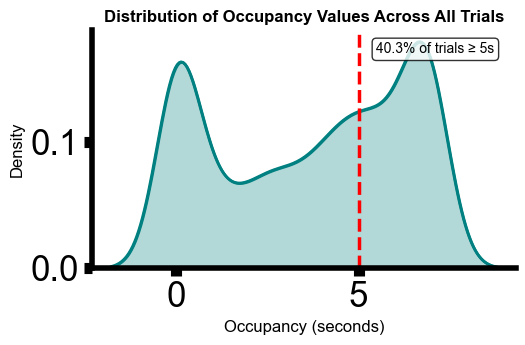


Occupancy Distribution Summary:
Total trials: 1641
Mean occupancy: 3.71s
Median occupancy: 4.20s
Trials ≥ 5s: 662 (40.3%)
Trials < 5s: 979 (59.7%)


In [32]:
# Update OBS dictionary to only include attended trials
attention_organized = {}
for k, key in enumerate(animal_mappings.keys()):
    range2map = animal_mappings[key]['tw_trial_range']
    attention_organized['mouse%i' % k] = all_occupancy_values[range2map[0]:range2map[1]+1] / 40

TW_obs_attn_dict = {}
TW_obs_nonattn_dict = {}
TW_unshifted_attn_dict = {}
TW_unshifted_nonattn_dict = {}
for key in TW_obs_dict.keys():
    if key in attention_organized:
        attention_values = attention_organized[key]
        attended_mask = attention_values >= 5  # attended for at least 5s
        nonattended_mask = attention_values < 1  # not attended to
        TW_obs_attn_dict[key] = TW_obs_dict[key][attended_mask]
        TW_obs_nonattn_dict[key] = TW_obs_dict[key][nonattended_mask]
        TW_unshifted_attn_dict[key] = TW_obs_unshifted_dict[key][attended_mask]
        TW_unshifted_nonattn_dict[key] = TW_obs_unshifted_dict[key][nonattended_mask]
        
        print(f"{key}: {np.sum(attended_mask)} attended trials retained")

# Depict final distribution of attended trials
all_occupancy_seconds = []
for key in attention_organized.keys():
    all_occupancy_seconds.extend(attention_organized[key])

all_occupancy_seconds = np.array(all_occupancy_seconds)

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Plot distribution
sns.kdeplot(all_occupancy_seconds, ax=ax, color='teal', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(all_occupancy_seconds, ax=ax, color='teal', linewidth=2)

# Add vertical line at occupancy = 5
ax.axvline(x=5, color='red', linestyle='--', linewidth=2.5, label='Threshold (5s)')

# Labels and styling
ax.set_xlabel('Occupancy (seconds)', fontfamily='Arial', fontsize=12)
ax.set_ylabel('Density', fontfamily='Arial', fontsize=12)
ax.set_title('Distribution of Occupancy Values Across All Trials', 
             fontfamily='Arial', fontsize=12, fontweight='bold')

# Set tick labels to Arial
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')

# Add text showing percentage of trials above threshold
pct_above = (np.sum(all_occupancy_seconds >= 5) / len(all_occupancy_seconds)) * 100
ax.text(0.95, 0.95, f'{pct_above:.1f}% of trials ≥ 5s', 
        transform=ax.transAxes, ha='right', va='top',
        fontfamily='Arial', fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig3alt/occupancy_distribution.svg', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nOccupancy Distribution Summary:")
print(f"Total trials: {len(all_occupancy_seconds)}")
print(f"Mean occupancy: {np.mean(all_occupancy_seconds):.2f}s")
print(f"Median occupancy: {np.median(all_occupancy_seconds):.2f}s")
print(f"Trials ≥ 5s: {np.sum(all_occupancy_seconds >= 5)} ({pct_above:.1f}%)")
print(f"Trials < 5s: {np.sum(all_occupancy_seconds < 5)} ({100-pct_above:.1f}%)")

In [34]:
# Create comprehensive metadata for trial filtering
trial_filtering_metadata = {}

for key in TW_obs_dict.keys():
    if key in attention_organized:
        attention_values = attention_organized[key]
        attended_mask = attention_values >= 5  # attended for at least 5s
        
        # Store detailed metadata for this animal
        trial_filtering_metadata[key] = {
            'total_trials': len(attention_values),
            'kept_trials': np.sum(attended_mask),
            'filtered_trials': np.sum(~attended_mask),
            'kept_indices': np.where(attended_mask)[0].tolist(),  # Indices of kept trials
            'filtered_indices': np.where(~attended_mask)[0].tolist(),  # Indices of filtered trials
            'attention_values': attention_values,  # Full attention values per trial
            'trial_status': ['kept' if mask else 'filtered' for mask in attended_mask],  # Status per trial
            'kept_mask': attended_mask,  # Boolean mask
            'original_data': TW_obs_dict[key],  # Original unfiltered data
            'filtered_data': TW_obs_dict[key][attended_mask]  # Filtered data
        }
        
        # Update the filtered dictionary
        TW_obs_attn_dict[key] = TW_obs_dict[key][attended_mask]
        
        print(f"{key}: {np.sum(attended_mask)}/{len(attended_mask)} attended trials retained "
              f"({100*np.sum(attended_mask)/len(attended_mask):.1f}%)")

# Create a flattened version for easy access across all animals
all_trials_metadata = []
for mouse_id, metadata in trial_filtering_metadata.items():
    for trial_idx in range(metadata['total_trials']):
        all_trials_metadata.append({
            'mouse_id': mouse_id,
            'trial_idx': trial_idx,
            'status': metadata['trial_status'][trial_idx],
            'attention_value': metadata['attention_values'][trial_idx],
            'kept': metadata['trial_status'][trial_idx] == 'kept'
        })

# Convert to DataFrame for easy querying
trial_metadata_df = pd.DataFrame(all_trials_metadata)

# Print summary
print("\n=== TRIAL FILTERING SUMMARY ===")
print(f"Total animals: {len(trial_filtering_metadata)}")
print(f"Total trials across all animals: {len(all_trials_metadata)}")
print(f"Kept trials: {trial_metadata_df['kept'].sum()} ({100*trial_metadata_df['kept'].sum()/len(trial_metadata_df):.1f}%)")
print(f"Filtered trials: {(~trial_metadata_df['kept']).sum()} ({100*(~trial_metadata_df['kept']).sum()/len(trial_metadata_df):.1f}%)")

# Example: Query trials for specific mouse
example_mouse = list(trial_filtering_metadata.keys())[0]
print(f"\n=== EXAMPLE: {example_mouse} ===")
print(f"Kept trial indices: {trial_filtering_metadata[example_mouse]['kept_indices']}")
print(f"Filtered trial indices: {trial_filtering_metadata[example_mouse]['filtered_indices']}")
print(f"Original data shape: {trial_filtering_metadata[example_mouse]['original_data'].shape}")
print(f"Filtered data shape: {trial_filtering_metadata[example_mouse]['filtered_data'].shape}")

# Save metadata
import pickle
with open('trial_filtering_metadata.pickle', 'wb') as f:
    pickle.dump(trial_filtering_metadata, f)

with open('trial_metadata_dataframe.pickle', 'wb') as f:
    pickle.dump(trial_metadata_df, f)

print("\nMetadata saved to 'trial_filtering_metadata.pickle' and 'trial_metadata_dataframe.pickle'")

mouse0: 141/271 attended trials retained (52.0%)
mouse1: 121/170 attended trials retained (71.2%)
mouse2: 71/129 attended trials retained (55.0%)
mouse3: 34/156 attended trials retained (21.8%)
mouse4: 37/84 attended trials retained (44.0%)
mouse5: 81/163 attended trials retained (49.7%)
mouse6: 31/170 attended trials retained (18.2%)
mouse7: 80/319 attended trials retained (25.1%)
mouse8: 66/179 attended trials retained (36.9%)

=== TRIAL FILTERING SUMMARY ===
Total animals: 9
Total trials across all animals: 1641
Kept trials: 662 (40.3%)
Filtered trials: 979 (59.7%)

=== EXAMPLE: mouse0 ===
Kept trial indices: [0, 2, 4, 5, 7, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 64, 65, 66, 68, 69, 70, 72, 73, 74, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 101, 102, 103, 104, 106, 134, 135, 137, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 152, 153, 154, 155, 156, 157, 158, 161, 162, 164, 165, 166, 167, 168, 169, 170, 172, 173

In [76]:
# with open('TW_obs_dict_112525.pickle', 'wb') as f:
#     pickle.dump(TW_obs_attn_dict, f)

# with open('TW_agg_dict_112525.pickle', 'wb') as f:
#     pickle.dump(TW_agg_dict, f)

# with open('TW_non_dict_112525.pickle', 'wb') as f:
#     pickle.dump(TW_non_dict, f)

### 4.5. Comparing unshifted (attn+no attn), shifted (attn+no attn) and shifted (attn only)

Total trials: 1641
Attentive trials: 662 (40.3%)
Non-attentive trials: 979

After slicing (slice(250, 325, None)):
  Trials shown:          75
  Attentive in slice:    54
  Blanked in slice:      21


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\4042477968.py:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\4042477968.py:115: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\4042477968.py:115: MatplotlibDeprecationWarning: The get_c

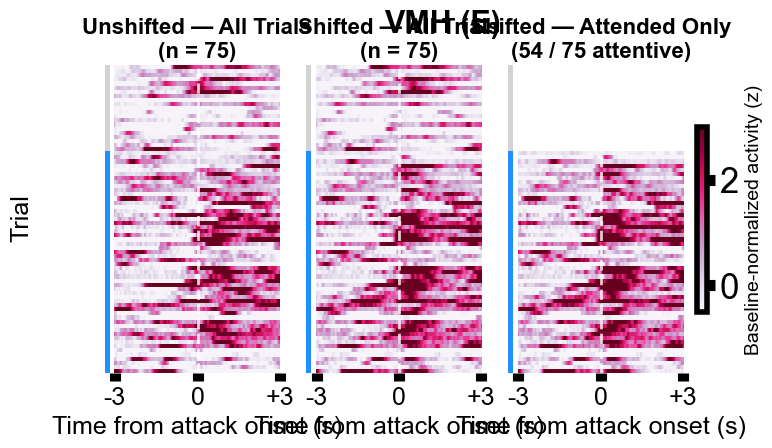

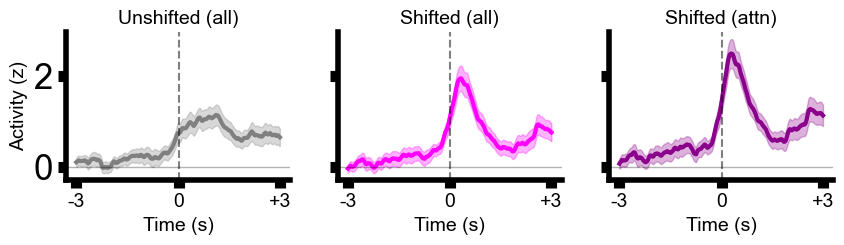


=== VMH (E) — SUMMARY (post-onset window: 0 to +1s) ===
Unshifted (all): mean = 0.961 ± 1.647, n = 75 valid trials
Shifted (all): mean = 1.484 ± 1.936, n = 75 valid trials
Shifted (attn): mean = 1.914 ± 1.796, n = 54 valid trials


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\4042477968.py:209: RuntimeWarning: Mean of empty slice
  post_activity = np.nanmean(data[:, post_onset_start:post_onset_end], axis=1)


In [127]:
# Comparison of unshifted vs shifted vs shifted+attention-filtered
# trial-by-trial heatmaps for a key brain region
# Non-attentive trials are blanked (NaN) in the attention panel

from mpl_toolkits.axes_grid1 import make_axes_locatable

roi = 12  # VMH (E) — change to 18 for LHb (E), 22 for NAc (DA), etc.
roi_name = region_ids[roi]
time_slice = slice(120, -120)  # crop edges to avoid boundary artifacts
baseline = [0, 120]
vmin, vmax = -0.5, 3.0  # colormap range — adjust as needed

# --- Trial selection parameters ---
trial_slice = slice(250, 325)  # which trials to show across all 3 panels

# --- 1. Concatenate all trials across animals for each condition ---

sorted_keys = sorted(TW_obs_unshifted_dict.keys())

# (A) Unshifted, ALL trials
unshifted_all = np.concatenate(
    [TW_obs_unshifted_dict[key] for key in sorted_keys
     if TW_obs_unshifted_dict[key].shape[0] > 0], axis=0
)

# (B) Shifted, ALL trials
shifted_all = np.concatenate(
    [TW_obs_dict[key] for key in sorted_keys
     if TW_obs_dict[key].shape[0] > 0], axis=0
)

# (C) Build attention mask: True = attentive, False = non-attentive
# For each animal, mark which trials survived attention filtering
attn_mask_per_animal = []
for key in sorted_keys:
    n_total = TW_obs_dict[key].shape[0]
    n_attn = TW_obs_attn_dict[key].shape[0]
    if n_total == 0:
        continue
    # Assume attention trials are the first n_attn trials per animal
    # If you have an explicit boolean mask per animal, replace this logic
    mask = np.zeros(n_total, dtype=bool)
    mask[:n_attn] = True
    attn_mask_per_animal.append(mask)

attn_mask = np.concatenate(attn_mask_per_animal, axis=0)

print(f"Total trials: {shifted_all.shape[0]}")
print(f"Attentive trials: {attn_mask.sum()} ({attn_mask.mean()*100:.1f}%)")
print(f"Non-attentive trials: {(~attn_mask).sum()}")

# Apply trial slicing to all three
unshifted_all = unshifted_all[trial_slice]
shifted_all = shifted_all[trial_slice]
attn_mask_sliced = attn_mask[trial_slice]

# (C) Shifted with non-attentive trials blanked out (set to NaN)
shifted_attn_blanked = shifted_all.copy().astype(float)
shifted_attn_blanked[~attn_mask_sliced] = np.nan

print(f"\nAfter slicing ({trial_slice}):")
print(f"  Trials shown:          {unshifted_all.shape[0]}")
print(f"  Attentive in slice:    {attn_mask_sliced.sum()}")
print(f"  Blanked in slice:      {(~attn_mask_sliced).sum()}")

# --- 2. Baseline-normalize each trial ---
def baseline_normalize(data, roi, baseline_range):
    """Subtract per-trial baseline median for a given ROI."""
    bl = np.nanmedian(data[:, baseline_range[0]:baseline_range[1], roi], axis=1, keepdims=True)
    return data[:, :, roi] - bl

unshifted_all_norm = baseline_normalize(unshifted_all, roi, baseline)
shifted_all_norm   = baseline_normalize(shifted_all, roi, baseline)
shifted_attn_norm  = baseline_normalize(shifted_attn_blanked, roi, baseline)

# Crop to the time_slice
unshifted_all_crop = unshifted_all_norm[:, time_slice]
shifted_all_crop   = shifted_all_norm[:, time_slice]
shifted_attn_crop  = shifted_attn_norm[:, time_slice]

n_time = unshifted_all_crop.shape[1]
half_time = n_time // 2

# --- 3. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True,
                         gridspec_kw={'wspace': 0.15})

titles = [
    f'Unshifted — All Trials\n(n = {unshifted_all_crop.shape[0]})',
    f'Shifted — All Trials\n(n = {shifted_all_crop.shape[0]})',
    f'Shifted — Attended Only\n({attn_mask_sliced.sum()} / {unshifted_all_crop.shape[0]} attentive)',
]
data_list = [unshifted_all_crop, shifted_all_crop, shifted_attn_crop]
cmaps = ['PuRd', 'PuRd', 'PuRd']

# Build attention indicator strip: 1 = attentive, 0 = non-attentive
attn_indicator = attn_mask_sliced.astype(float).reshape(-1, 1)

# Colormap for the indicator strip
from matplotlib.colors import ListedColormap
indicator_cmap = ListedColormap(['lightgray', 'dodgerblue'])  # gray = inattentive, blue = attentive

for ax, data, title, cmap in zip(axes, data_list, titles, cmaps):
    # --- Attention indicator strip ---
    # Create an inset axes to the left of the heatmap
    divider = make_axes_locatable(ax)
    ax_indicator = divider.append_axes("left", size="3%", pad=0.05)
    ax_indicator.imshow(attn_indicator, aspect='auto', cmap=indicator_cmap,
                        vmin=0, vmax=1, interpolation='none')
    ax_indicator.set_xticks([])
    ax_indicator.set_yticks([])
    ax_indicator.set_ylabel('')
    
    # --- Main heatmap ---
    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='white')
    
    im = ax.imshow(data, aspect='auto', vmin=vmin, vmax=vmax, cmap=cmap_obj,
                   interpolation='none')
    ax.axvline(half_time, linestyle='--', color='white', alpha=0.8, linewidth=2)
    
    # X-axis: time in seconds
    n_pts = data.shape[1]
    seconds_per_frame = 1 / 40  # 40 Hz
    total_sec = n_pts * seconds_per_frame
    half_sec = total_sec / 2
    ax.set_xticks([0, half_time, n_pts - 1])
    ax.set_xticklabels([f'-{half_sec:.0f}', '0', f'+{half_sec:.0f}'],
                       fontfamily='Arial', fontsize=18)
    ax.set_xlabel('Time from attack onset (s)', fontfamily='Arial', fontsize=18)
    ax.set_title(title, fontfamily='Arial', fontsize=16, fontweight='bold')
    ax.set_yticks([])  # hide y-tick numbers since indicator strip replaces them
    
    for label in ax.get_yticklabels():
        label.set_fontfamily('Arial')
        label.set_fontsize(14)

# Add "Trial" label to the leftmost indicator strip
axes[0].set_ylabel('')
fig.text(0.02, 0.5, 'Trial', va='center', rotation='vertical',
         fontfamily='Arial', fontsize=18)

# Legend for indicator strip
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='dodgerblue', edgecolor='black', label='Attentive'),
    Patch(facecolor='lightgray', edgecolor='black', label='Inattentive'),
]
# fig.legend(handles=legend_elements, loc='lower center', ncol=2,
#            fontsize=14, frameon=True, bbox_to_anchor=(0.45, -0.02),
#            prop={'family': 'Arial'})

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label('Baseline-normalized activity (z)', fontfamily='Arial', fontsize=14)
for label in cbar.ax.get_yticklabels():
    label.set_fontfamily('Arial')

plt.suptitle(f'{roi_name}', fontfamily='Arial', fontsize=22, fontweight='bold', y=1.02)
sns.despine(left=True, bottom=True)
plt.tight_layout()
# plt.savefig(f'./figures/fig2/heatmap_comparison_{roi_name.replace(" ", "_").replace("(", "").replace(")", "")}.svg',
#             dpi=300, bbox_inches='tight')
plt.show()

# --- 4. Corresponding mean traces below the heatmaps ---
fig2, axes2 = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

trace_data = [unshifted_all_crop, shifted_all_crop, shifted_attn_crop]
trace_colors = ['gray', 'magenta', 'darkmagenta']
trace_labels = ['Unshifted (all)', 'Shifted (all)', 'Shifted (attn)']

for ax, data, color, label in zip(axes2, trace_data, trace_colors, trace_labels):
    mean_trace = np.nanmean(data, axis=0)
    # For SEM, count only non-NaN trials per time point
    n_valid = np.sum(~np.isnan(data), axis=0)
    n_valid = np.where(n_valid == 0, 1, n_valid)  # avoid div by zero
    sem_trace = np.nanstd(data, axis=0) / np.sqrt(n_valid)
    
    x = np.arange(data.shape[1])
    ax.plot(mean_trace, color=color, linewidth=3, label=label)
    ax.fill_between(x, mean_trace - sem_trace, mean_trace + sem_trace,
                    color=color, alpha=0.3)
    ax.axvline(half_time, linestyle='--', color='black', alpha=0.5, linewidth=1.5)
    ax.axhline(0, linestyle='-', color='black', alpha=0.3, linewidth=1)
    
    ax.set_xticks([0, half_time, data.shape[1] - 1])
    ax.set_xticklabels([f'-{half_sec:.0f}', '0', f'+{half_sec:.0f}'],
                       fontfamily='Arial', fontsize=14)
    ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=14)
    ax.set_title(label, fontfamily='Arial', fontsize=14)
    
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontfamily('Arial')

axes2[0].set_ylabel('Activity (z)', fontfamily='Arial', fontsize=14)
sns.despine()
plt.tight_layout()
# plt.savefig(f'./figures/fig2/mean_traces_comparison_{roi_name.replace(" ", "_").replace("(", "").replace(")", "")}.svg',
#             dpi=300, bbox_inches='tight')
plt.show()

# --- 5. Print summary statistics ---
print(f"\n=== {roi_name} — SUMMARY (post-onset window: 0 to +1s) ===")
post_onset_start = half_time
post_onset_end = half_time + 40  # +1s at 40 Hz

for name, data in zip(trace_labels, trace_data):
    post_activity = np.nanmean(data[:, post_onset_start:post_onset_end], axis=1)
    n_valid_trials = np.sum(~np.isnan(post_activity))
    print(f"{name}: mean = {np.nanmean(post_activity):.3f} ± {np.nanstd(post_activity):.3f}, "
          f"n = {n_valid_trials} valid trials")

In [78]:
n_pts = shifted_attn_crop.shape[1]
frame_cols = [f'frame_{f}' for f in np.arange(n_pts)]

sourceData_2i_ED6a_top_right = pd.DataFrame(
    shifted_attn_crop,
    columns=frame_cols
)
sourceData_2i_ED6a_top_right.insert(0, 'trial', np.arange(trial_slice.start, trial_slice.stop))
sourceData_2i_ED6a_top_right.insert(1, 'attentive', attn_mask_sliced)
sourceData_2i_ED6a_top_right.insert(2, 'roi', roi_name)

sourceData_2i_ED6a_top_right.to_csv('./sourceData/2i.csv', index=False)

### 5. Finalize PETH computation

NOTE: Rerun the OBS time shifting for accurate results. If the notebook has been run from front-to-back, occassionally some variables get mixed in the process. Just reset the OBS data to make sure it's ACTUALLY OBS data.

In [34]:
# Compute PETHs from time-warped data dictionaries

def compute_peths(data_dict, region_ids, window_size, ntrials=None, early_late=None):
    """
    Compute PETHs from time-warped data dictionaries.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing time-warped data for each animal
    region_ids : list
        List of region identifiers
    ntrials : int, optional
        Number of trials to use for early/late analysis
    early_late : str, optional
        'early' for first ntrials, 'late' for last ntrials, None for all trials
    
    Returns:
    --------
    np.ndarray
        3D array of shape (480, len(region_ids), len(data_dict.keys()))
    """
    n_animals = len(data_dict.keys())
    peths = np.zeros((window_size, len(region_ids), n_animals))
    
    for k, key in enumerate(data_dict.keys()):
        if early_late == 'early':
            data_subset = data_dict[key][:ntrials]
        elif early_late == 'late':
            data_subset = data_dict[key][-ntrials:]
        else:
            data_subset = data_dict[key]
            
        peths[:, :, k] = np.nanmean(data_subset, axis=0)
    
    return peths

def compute_all_peths(TW_agg_dict, TW_obs_dict, TW_non_dict, region_ids, window_size, ntrials=100):
    """
    Compute all PETH variations for the three experimental groups.
    
    Returns:
    --------
    dict
        Dictionary containing all computed PETHs
    """
    peths_dict = {}
    
    # All trials
    peths_dict['agg'] = compute_peths(TW_agg_dict, region_ids, window_size=window_size)
    peths_dict['obs'] = compute_peths(TW_obs_dict, region_ids, window_size=window_size)
    peths_dict['non'] = compute_peths(TW_non_dict, region_ids, window_size=window_size)
    
    # Early trials
    peths_dict['agg_early'] = compute_peths(TW_agg_dict, region_ids, window_size, ntrials, 'early')
    peths_dict['obs_early'] = compute_peths(TW_obs_dict, region_ids, window_size, ntrials, 'early')
    
    # Late trials
    peths_dict['agg_late'] = compute_peths(TW_agg_dict, region_ids, window_size, ntrials, 'late')
    peths_dict['obs_late'] = compute_peths(TW_obs_dict, region_ids, window_size, ntrials, 'late')
    
    return peths_dict

# Usage:
all_peths = compute_all_peths(TW_agg_dict, TW_obs_attn_dict, TW_non_dict, region_ids, window_size, ntrials=15)

# Access the arrays:
agg_peths = all_peths['agg']
obs_peths = all_peths['obs']
non_peths = all_peths['non']
agg_peths_early = all_peths['agg_early']
agg_peths_late = all_peths['agg_late']
obs_peths_early = all_peths['obs_early']
obs_peths_late = all_peths['obs_late']

# Unshifted data
unshifted_peths = compute_all_peths(TW_agg_dict, TW_unshifted_attn_dict, TW_non_dict, region_ids, window_size, ntrials=window_size//2)
unshifted_attn_obs_peths = unshifted_peths['obs']

unshifted_peths = compute_all_peths(TW_agg_dict, TW_unshifted_nonattn_dict, TW_non_dict, region_ids, window_size, ntrials=window_size//2)
unshifted_nonattn_obs_peths = unshifted_peths['obs']

# Same but for faux data
# faux_attack_idxs = [len(x) for x in [obs_faux_dict[key][:-1] for key in obs_faux_dict.keys()]]
# z_faux= np.diff(np.cumsum(np.array(faux_attack_idxs)))
# z_faux = np.insert(np.cumsum(faux_attack_idxs), 0, 0)
# TW_faux_dict = {}
# for t, trials in enumerate(z_faux[:-1]):
#     TW_faux_dict['mouse%i' % t] = faux_new_data[z_faux[t]:z_faux[t+1], :, :]

# # Compute PETHs for faux data
# faux_peths = compute_peths(TW_faux_dict, region_ids, window_size=window_size)

# # Same but for spd data
# spd_attack_idxs = [len(x) for x in [obs_speed_dict[key][:-1] for key in obs_speed_dict.keys()]]
# z_spd= np.diff(np.cumsum(np.array(spd_attack_idxs)))
# z_spd = np.insert(np.cumsum(spd_attack_idxs), 0, 0)
# TW_spd_dict = {}
# for t, trials in enumerate(z_spd[:-1]):
#     TW_spd_dict['mouse%i' % t] = spd_new_data[z_spd[t]:z_spd[t+1], :, :]

# # Compute PETHs for spd data
# spd_peths = compute_peths(TW_spd_dict, region_ids, window_size=window_size)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\738318655.py:34: RuntimeWarning: Mean of empty slice
  peths[:, :, k] = np.nanmean(data_subset, axis=0)


In [129]:
def compute_peths_across_all_trials(data_dict, region_ids, window_size, ntrials=None, early_late=None):
    """
    Compute PETHs across all trials from all animals (not subject-by-subject).
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary containing time-warped data for each animal
    region_ids : list
        List of region identifiers
    ntrials : int, optional
        Number of trials to use for early/late analysis (per animal)
    early_late : str, optional
        'early' for first ntrials, 'late' for last ntrials, None for all trials
    
    Returns:
    --------
    np.ndarray
        2D array of shape (window_size, len(region_ids)) - averaged across ALL trials
    """
    all_trials = []
    
    for key in data_dict.keys():
        animal_data = data_dict[key]
        
        if early_late == 'early':
            data_subset = animal_data[:ntrials]
        elif early_late == 'late':
            data_subset = animal_data[-ntrials:]
        else:
            data_subset = animal_data
            
        # Only add if there are trials for this animal
        if data_subset.shape[0] > 0:
            all_trials.append(data_subset)
    
    if not all_trials:
        # Return zeros if no trials found
        return np.zeros((window_size, len(region_ids)))
    
    # Concatenate all trials across all animals
    concatenated_trials = np.concatenate(all_trials, axis=0)
    
    # Compute mean across all trials
    # peths = np.nanmean(concatenated_trials, axis=0)
    
    return concatenated_trials

def compute_all_peths_across_trials(TW_agg_dict, TW_obs_dict, TW_non_dict, region_ids, window_size, ntrials=25):
    """
    Compute all PETH variations across all trials for the three experimental groups.
    
    Returns:
    --------
    dict
        Dictionary containing all computed PETHs (each as 2D array: time x regions)
    """
    peths_dict = {}
    
    # All trials across all animals
    peths_dict['agg'] = compute_peths_across_all_trials(TW_agg_dict, region_ids, window_size=window_size)
    peths_dict['obs'] = compute_peths_across_all_trials(TW_obs_dict, region_ids, window_size=window_size)
    peths_dict['non'] = compute_peths_across_all_trials(TW_non_dict, region_ids, window_size=window_size)
    
    # Early trials across all animals
    peths_dict['agg_early'] = compute_peths_across_all_trials(TW_agg_dict, region_ids, window_size, ntrials, 'early')
    peths_dict['obs_early'] = compute_peths_across_all_trials(TW_obs_dict, region_ids, window_size, ntrials, 'early')
    
    # Late trials across all animals
    peths_dict['agg_late'] = compute_peths_across_all_trials(TW_agg_dict, region_ids, window_size, ntrials, 'late')
    peths_dict['obs_late'] = compute_peths_across_all_trials(TW_obs_dict, region_ids, window_size, ntrials, 'late')
    
    return peths_dict

# Usage with the new functions:
all_peths_across_trials = compute_all_peths_across_trials(TW_agg_dict, TW_obs_attn_dict, TW_non_dict, region_ids, window_size, ntrials=20)

# Access the arrays (now 2D: time x regions):
agg_peths_across = all_peths_across_trials['agg']  # Shape: (ntrials, 480, 23)
obs_peths_across = all_peths_across_trials['obs']  # Shape: (ntrials, 480, 23)  
non_peths_across = all_peths_across_trials['non']  # Shape: (ntrials, 480, 23)
agg_peths_early_across = all_peths_across_trials['agg_early']
agg_peths_late_across = all_peths_across_trials['agg_late']
obs_peths_early_across = all_peths_across_trials['obs_early']
obs_peths_late_across = all_peths_across_trials['obs_late']

# Compute faux data PETHs across all trials
# faux_attack_idxs = [x.shape[0] for x in [obs_faux_dict[key][-1] for key in obs_faux_dict.keys()]]
# z_faux = np.insert(np.cumsum(faux_attack_idxs), 0, 0)
# TW_faux_dict = {}
# for t, trials in enumerate(z_faux[:-1]):
# 	TW_faux_dict['mouse%i' % t] = faux_new_data[z_faux[t]:z_faux[t+1], :, :]
# faux_peths_across = compute_peths_across_all_trials(TW_faux_dict, region_ids, window_size=window_size)

# # Compute spd data PETHs across all trials
# spd_attack_idxs = [x.shape[0] for x in [obs_speed_dict[key][-1] for key in obs_speed_dict.keys()]]
# z_spd = np.insert(np.cumsum(spd_attack_idxs), 0, 0)
# TW_spd_dict = {}
# for t, trials in enumerate(z_spd[:-1]):
# 	TW_spd_dict['mouse%i' % t] = spd_new_data[z_spd[t]:z_spd[t+1], :, :]
# spd_peths_across = compute_peths_across_all_trials(TW_spd_dict, region_ids, window_size=window_size)

### Stats with multiple comparisons (FDR)

In [35]:
from statsmodels.stats.multitest import multipletests

def improved_between_group_stats(data2plot, alpha=0.05):
    """
    Improved between-group statistical testing with better normality testing
    and effect size calculations.
    """
    # Clean data
    agg_roi_activity = data2plot[0][~np.isnan(data2plot[0])]
    obs_roi_activity = data2plot[1][~np.isnan(data2plot[1])]
    non_roi_activity = data2plot[2][~np.isnan(data2plot[2])]
    results = {}
    
    # Test AGG vs NON
    results['agg_vs_non'] = _perform_comparison(
        agg_roi_activity, non_roi_activity, 'AGG', 'NON', alpha
    )
    
    # Test OBS vs NON  
    results['obs_vs_non'] = _perform_comparison(
        obs_roi_activity, non_roi_activity, 'OBS', 'NON', alpha
    )
    
    return results

def _perform_comparison(group1, group2, name1, name2, alpha):
    """Helper function to perform individual comparisons"""
    
    # Enhanced normality testing using multiple methods
    def test_normality(data, name):
        if len(data) < 8:
            return False, "Sample too small"
        
        # Shapiro-Wilk (most powerful for small samples)
        _, p_shapiro = stats.shapiro(data)
        
        # D'Agostino-Pearson (better for larger samples >20)
        if len(data) >= 20:
            _, p_dagostino = stats.normaltest(data)
            is_normal = (p_shapiro > alpha) and (p_dagostino > alpha)
            return is_normal, f"Shapiro: {p_shapiro:.4f}, D'Agostino: {p_dagostino:.4f}"
        else:
            is_normal = p_shapiro > alpha
            return is_normal, f"Shapiro: {p_shapiro:.4f}"
    
    # Calculate means and direction
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    mean_diff = mean1 - mean2
    
    # Determine direction
    if mean_diff > 0:
        direction = f"{name1} > {name2}"
    elif mean_diff < 0:
        direction = f"{name1} < {name2}"
    else:
        direction = f"{name1} = {name2}"
    
    # Test normality for both groups
    normal1, norm_info1 = test_normality(group1, name1)
    normal2, norm_info2 = test_normality(group2, name2)
    
    # Choose appropriate test
    if normal1 and normal2:
        # Check equal variances (Levene's test is more robust than Bartlett's)
        _, p_levene = stats.levene(group1, group2)
        equal_var = p_levene > alpha
        
        # Perform t-test
        statistic, p_value = stats.ttest_ind(group1, group2, equal_var=equal_var)
        test_type = f"t-test (equal_var={equal_var})"
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(group1)-1)*np.var(group1, ddof=1) + 
                            (len(group2)-1)*np.var(group2, ddof=1)) / 
                           (len(group1) + len(group2) - 2))
        effect_size = (mean1 - mean2) / pooled_std
        effect_name = "Cohen's d"
        
    else:
        # Non-parametric test
        statistic, p_value = stats.brunnermunzel(group1, group2, alternative='two-sided')
        test_type = "Brunner Munzel"

        if np.isnan(p_value):
            statistic, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
            test_type = "MWU"
        
        # Effect size (r = Z / sqrt(N)) - preserve sign
        z_score = stats.norm.ppf(1 - p_value/2) * np.sign(np.median(group1) - np.median(group2))
        effect_size = z_score / np.sqrt(len(group1) + len(group2))  # Keep sign for direction
        effect_name = "r (effect size)"
    
    return {
        'statistic': statistic,
        'p_value': p_value,
        'test_type': test_type,
        'effect_size': effect_size,
        'effect_name': effect_name,
        'direction': direction,
        'group1_normal': normal1,
        'group2_normal': normal2,
        'norm_info1': norm_info1,
        'norm_info2': norm_info2,
        'n1': len(group1),
        'n2': len(group2),
        'group1_mean': mean1,
        'group2_mean': mean2,
        'mean_diff': mean_diff
    }

In [36]:
# pre-attack statistics with separate multiple comparisons correction
from statsmodels.stats.multitest import multipletests
from scipy.stats import brunnermunzel
mean_func = np.nanmean

# compute baseline-corrected activity for all regions
start = 160  # -2s
stop = start + 80  # 0s
baseline = [0, 160]
agg_peths[:, 18, -2:] = np.nan  # blank out LHb (E) to avoid spurious significance
agg_peths[:, -1, -2:] = np.nan  # blank out NAc (DA) to avoid spurious significance
agg_diff = agg_peths[start:stop, :, :] - \
           np.nanmean(agg_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
obs_diff = obs_peths[start:stop, :, :] - \
           np.nanmean(obs_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
non_diff = non_peths[start:stop, :, :] - \
           np.nanmean(non_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)

# Define regions to analyze
idxs2loop = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1]) # exclude NAc DA and LHb - these are analyzed later
pval_names = [region_ids[idx] for idx in idxs2loop]

# Collect all region data for analysis
all_region_data = []
for roi in idxs2loop:
    region_data = [
        mean_func(agg_diff[:, roi], axis=0),  # AGG data
        mean_func(obs_diff[:, roi], axis=0),  # OBS data
        mean_func(non_diff[:, roi], axis=0)   # NON data
    ]
    all_region_data.append(region_data)

# Run statistical analysis without multiple comparisons correction first
results_uncorrected = []
agg_pvals_uncorrected = []
obs_pvals_uncorrected = []

for region_idx, region_data in enumerate(all_region_data):
    region_results = improved_between_group_stats(region_data, alpha=0.05)
    results_uncorrected.append(region_results)
    
    # Collect uncorrected p-values separately
    agg_pvals_uncorrected.append(region_results['agg_vs_non']['p_value'])
    obs_pvals_uncorrected.append(region_results['obs_vs_non']['p_value'])

# Apply separate multiple comparisons corrections
agg_rejected, agg_pvals_corrected, _, _ = multipletests(agg_pvals_uncorrected, method='bonferroni', alpha=0.05)
obs_rejected, obs_pvals_corrected, _, _ = multipletests(obs_pvals_uncorrected, method='bonferroni', alpha=0.05)

# Extract results for display with separate corrections
prep_pvals_corrected_AGG = agg_pvals_corrected
prep_pvals_corrected_OBS = obs_pvals_corrected
prep_effect_sizes_AGG = []
prep_effect_sizes_OBS = []
prep_test_types_AGG = []
prep_test_types_OBS = []
prep_tvals_AGG = []
prep_tvals_OBS = []

for region_results in results_uncorrected:
    # AGG vs NON
    agg_result = region_results['agg_vs_non']
    prep_effect_sizes_AGG.append(agg_result['effect_size'])
    prep_test_types_AGG.append(agg_result['test_type'])
    prep_tvals_AGG.append(agg_result['statistic'])
    
    # OBS vs NON
    obs_result = region_results['obs_vs_non']
    prep_effect_sizes_OBS.append(obs_result['effect_size'])
    prep_test_types_OBS.append(obs_result['test_type'])
    prep_tvals_OBS.append(obs_result['statistic'])

# Convert to numpy arrays
prep_pvals_corrected_AGG = np.array(prep_pvals_corrected_AGG)
prep_pvals_corrected_OBS = np.array(prep_pvals_corrected_OBS)

### Display results with enhanced information
print("=== PRE-ATTACK PERIOD STATISTICS (SEPARATE CORRECTIONS) ===")
print(f"AGG comparisons corrected across {len(agg_pvals_uncorrected)} regions")
print(f"OBS comparisons corrected across {len(obs_pvals_uncorrected)} regions")
print()

print("### AGG vs NON ###")
for i, region_name in enumerate(pval_names):
    significance = "***" if prep_pvals_corrected_AGG[i] < 0.001 else "**" if prep_pvals_corrected_AGG[i] < 0.01 else "*" if prep_pvals_corrected_AGG[i] < 0.05 else "ns"
    direction = results_uncorrected[i]['agg_vs_non']['direction']
    print(f'{region_name} AGG vs NON: {prep_test_types_AGG[i]}, '
          f'statistic = {prep_tvals_AGG[i]:.3f}, '
          f'p_uncorrected = {agg_pvals_uncorrected[i]:.6f}, '
          f'p_corrected = {prep_pvals_corrected_AGG[i]:.6f} {significance}, '
          f'effect_size = {prep_effect_sizes_AGG[i]:.3f}, '
          f'direction: {direction}')

print("\n### OBS vs NON ###")
for i, region_name in enumerate(pval_names):
    significance = "***" if prep_pvals_corrected_OBS[i] < 0.001 else "**" if prep_pvals_corrected_OBS[i] < 0.01 else "*" if prep_pvals_corrected_OBS[i] < 0.05 else "ns"
    direction = results_uncorrected[i]['obs_vs_non']['direction']
    print(f'{region_name} OBS vs NON: {prep_test_types_OBS[i]}, '
          f'statistic = {prep_tvals_OBS[i]:.3f}, '
          f'p_uncorrected = {obs_pvals_uncorrected[i]:.6f}, '
          f'p_corrected = {prep_pvals_corrected_OBS[i]:.6f} {significance}, '
          f'effect_size = {prep_effect_sizes_OBS[i]:.3f}, '
          f'direction: {direction}')

# Print summary of significant results
print(f"\n=== SUMMARY ===")
agg_significant = np.sum(prep_pvals_corrected_AGG < 0.05)
obs_significant = np.sum(prep_pvals_corrected_OBS < 0.05)
print(f"AGG vs NON: {agg_significant}/{len(pval_names)} regions significant (separate correction)")
print(f"OBS vs NON: {obs_significant}/{len(pval_names)} regions significant (separate correction)")

# Compare with joint correction impact
print(f"\nUncorrected significant:")
print(f"AGG vs NON: {np.sum(np.array(agg_pvals_uncorrected) < 0.05)}/{len(pval_names)} regions")
print(f"OBS vs NON: {np.sum(np.array(obs_pvals_uncorrected) < 0.05)}/{len(pval_names)} regions")

# Display regions with strongest effects
print(f"\n=== TOP REGIONS BY EFFECT SIZE ===")
agg_sorted_idx = np.argsort(np.abs(prep_effect_sizes_AGG))[::-1]
obs_sorted_idx = np.argsort(np.abs(prep_effect_sizes_OBS))[::-1]

print("AGG (top 5 by effect size):")
for i in agg_sorted_idx[:5]:
    if prep_pvals_corrected_AGG[i] < 0.05:
        print(f"  {pval_names[i]}: effect = {prep_effect_sizes_AGG[i]:.3f}, p = {prep_pvals_corrected_AGG[i]:.4f}")

print("OBS (top 5 by effect size):")
for i in obs_sorted_idx[:5]:
    if prep_pvals_corrected_OBS[i] < 0.05:
        print(f"  {pval_names[i]}: effect = {prep_effect_sizes_OBS[i]:.3f}, p = {prep_pvals_corrected_OBS[i]:.4f}")

=== PRE-ATTACK PERIOD STATISTICS (SEPARATE CORRECTIONS) ===
AGG comparisons corrected across 20 regions
OBS comparisons corrected across 20 regions

### AGG vs NON ###
VMH (E) AGG vs NON: t-test (equal_var=False), statistic = 8.213, p_uncorrected = 0.000003, p_corrected = 0.000052 ***, effect_size = 3.079, direction: AGG > NON
PMv (E) AGG vs NON: t-test (equal_var=False), statistic = 3.504, p_uncorrected = 0.004601, p_corrected = 0.092014 ns, effect_size = 1.403, direction: AGG > NON
AH (E) AGG vs NON: t-test (equal_var=True), statistic = 3.173, p_uncorrected = 0.005563, p_corrected = 0.111269 ns, effect_size = 1.474, direction: AGG > NON
POA (E) AGG vs NON: t-test (equal_var=True), statistic = 4.395, p_uncorrected = 0.000349, p_corrected = 0.006985 **, effect_size = 2.006, direction: AGG > NON
MeA (E) AGG vs NON: t-test (equal_var=True), statistic = 5.499, p_uncorrected = 0.000032, p_corrected = 0.000639 ***, effect_size = 2.510, direction: AGG > NON
PA (E) AGG vs NON: t-test (equal_v

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\704738283.py:13: RuntimeWarning: Mean of empty slice
  np.nanmean(agg_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\704738283.py:15: RuntimeWarning: Mean of empty slice
  np.nanmean(obs_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\704738283.py:27: RuntimeWarning: Mean of empty slice
  mean_func(agg_diff[:, roi], axis=0),  # AGG data
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\704738283.py:28: RuntimeWarning: Mean of empty slice
  mean_func(obs_diff[:, roi], axis=0),  # OBS data
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9485: RuntimeWarning: divide by zero encountered in double_scalars
  wbfn /= (nx + ny) * np.sqrt(nx * Sx + ny * Sy)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9491: RuntimeWarni

In [37]:
# attack statistics with separate multiple comparisons correction
from statsmodels.stats.multitest import multipletests

# compute baseline-corrected activity for all regions
start = 240  # 0s
stop = start + 40  # +1s
agg_diff = agg_peths[start:stop, :, :] - \
           np.nanmean(agg_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
obs_diff = obs_peths[start:stop, :, :] - \
           np.nanmean(obs_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
non_diff = non_peths[start:stop, :, :] - \
           np.nanmean(non_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)

# Define regions to analyze
idxs2loop = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1])
pval_names = [region_ids[idx] for idx in idxs2loop]

# Collect all region data for analysis
all_region_data = []
for roi in idxs2loop:
    region_data = [
        mean_func(agg_diff[:, roi], axis=0),  # AGG data
        mean_func(obs_diff[:, roi], axis=0),  # OBS data  
        mean_func(non_diff[:, roi], axis=0)   # NON data
    ]
    all_region_data.append(region_data)

# Run statistical analysis without multiple comparisons correction first
results_uncorrected = []
agg_pvals_uncorrected = []
obs_pvals_uncorrected = []

for region_idx, region_data in enumerate(all_region_data):
    region_results = improved_between_group_stats(region_data, alpha=0.05)
    results_uncorrected.append(region_results)
    
    # Collect uncorrected p-values separately
    agg_pvals_uncorrected.append(region_results['agg_vs_non']['p_value'])
    obs_pvals_uncorrected.append(region_results['obs_vs_non']['p_value'])

# Apply separate multiple comparisons corrections
agg_rejected, agg_pvals_corrected, _, _ = multipletests(agg_pvals_uncorrected, method='bonferroni', alpha=0.05)
obs_rejected, obs_pvals_corrected, _, _ = multipletests(obs_pvals_uncorrected, method='bonferroni', alpha=0.05)

# Extract results for display with separate corrections
post_pvals_corrected_AGG = agg_pvals_corrected
post_pvals_corrected_OBS = obs_pvals_corrected
post_effect_sizes_AGG = []
post_effect_sizes_OBS = []
post_test_types_AGG = []
post_test_types_OBS = []
post_tvals_AGG = []
post_tvals_OBS = []

for region_results in results_uncorrected:
    # AGG vs NON
    agg_result = region_results['agg_vs_non']
    post_effect_sizes_AGG.append(agg_result['effect_size'])
    post_test_types_AGG.append(agg_result['test_type'])
    post_tvals_AGG.append(agg_result['statistic'])
    
    # OBS vs NON
    obs_result = region_results['obs_vs_non']
    post_effect_sizes_OBS.append(obs_result['effect_size'])
    post_test_types_OBS.append(obs_result['test_type'])
    post_tvals_OBS.append(obs_result['statistic'])

# Convert to numpy arrays
post_pvals_corrected_AGG = np.array(post_pvals_corrected_AGG)
post_pvals_corrected_OBS = np.array(post_pvals_corrected_OBS)

### Display results with enhanced information
print("=== PRE-ATTACK PERIOD STATISTICS (SEPARATE CORRECTIONS) ===")
print(f"AGG comparisons corrected across {len(agg_pvals_uncorrected)} regions")
print(f"OBS comparisons corrected across {len(obs_pvals_uncorrected)} regions")
print()

print("### AGG vs NON ###")
for i, region_name in enumerate(pval_names):
    significance = "***" if post_pvals_corrected_AGG[i] < 0.001 else "**" if post_pvals_corrected_AGG[i] < 0.01 else "*" if post_pvals_corrected_AGG[i] < 0.05 else "ns"
    direction = results_uncorrected[i]['agg_vs_non']['direction']
    print(f'{region_name} AGG vs NON: {post_test_types_AGG[i]}, '
          f'statistic = {post_tvals_AGG[i]:.3f}, '
          f'p_uncorrected = {agg_pvals_uncorrected[i]:.6f}, '
          f'p_corrected = {post_pvals_corrected_AGG[i]:.6f} {significance}, '
          f'effect_size = {post_effect_sizes_AGG[i]:.3f}, '
          f'direction: {direction}')

print("\n### OBS vs NON ###")
for i, region_name in enumerate(pval_names):
    significance = "***" if post_pvals_corrected_OBS[i] < 0.001 else "**" if post_pvals_corrected_OBS[i] < 0.01 else "*" if post_pvals_corrected_OBS[i] < 0.05 else "ns"
    direction = results_uncorrected[i]['obs_vs_non']['direction']   
    print(f'{region_name} OBS vs NON: {post_test_types_OBS[i]}, '
          f'statistic = {post_tvals_OBS[i]:.3f}, '
          f'p_uncorrected = {obs_pvals_uncorrected[i]:.6f}, '
          f'p_corrected = {post_pvals_corrected_OBS[i]:.6f} {significance}, '
          f'effect_size = {post_effect_sizes_OBS[i]:.3f}, '
          f'direction: {direction}')

# Print summary of significant results
print(f"\n=== SUMMARY ===")
agg_significant = np.sum(post_pvals_corrected_AGG < 0.05)
obs_significant = np.sum(post_pvals_corrected_OBS < 0.05)
print(f"AGG vs NON: {agg_significant}/{len(pval_names)} regions significant (separate correction)")
print(f"OBS vs NON: {obs_significant}/{len(pval_names)} regions significant (separate correction)")

# Compare with joint correction impact
print(f"\nUncorrected significant:")
print(f"AGG vs NON: {np.sum(np.array(agg_pvals_uncorrected) < 0.05)}/{len(pval_names)} regions")
print(f"OBS vs NON: {np.sum(np.array(obs_pvals_uncorrected) < 0.05)}/{len(pval_names)} regions")

# Display regions with strongest effects
print(f"\n=== TOP REGIONS BY EFFECT SIZE ===")
agg_sorted_idx = np.argsort(np.abs(post_effect_sizes_AGG))[::-1]
obs_sorted_idx = np.argsort(np.abs(post_effect_sizes_OBS))[::-1]

print("AGG (top 5 by effect size):")
for i in agg_sorted_idx[:5]:
    if post_pvals_corrected_AGG[i] < 0.05:
        print(f"  {pval_names[i]}: effect = {post_effect_sizes_AGG[i]:.3f}, p = {post_pvals_corrected_AGG[i]:.4f}")

print("OBS (top 5 by effect size):")
for i in obs_sorted_idx[:5]:
    if post_pvals_corrected_OBS[i] < 0.05:
        print(f"  {pval_names[i]}: effect = {post_effect_sizes_OBS[i]:.3f}, p = {post_pvals_corrected_OBS[i]:.4f}")

=== PRE-ATTACK PERIOD STATISTICS (SEPARATE CORRECTIONS) ===
AGG comparisons corrected across 20 regions
OBS comparisons corrected across 20 regions

### AGG vs NON ###
VMH (E) AGG vs NON: t-test (equal_var=False), statistic = 10.561, p_uncorrected = 0.000000, p_corrected = 0.000005 ***, effect_size = 3.938, direction: AGG > NON
PMv (E) AGG vs NON: t-test (equal_var=False), statistic = 5.583, p_uncorrected = 0.000191, p_corrected = 0.003813 **, effect_size = 2.210, direction: AGG > NON
AH (E) AGG vs NON: t-test (equal_var=False), statistic = 5.537, p_uncorrected = 0.000159, p_corrected = 0.003176 **, effect_size = 2.211, direction: AGG > NON
POA (E) AGG vs NON: t-test (equal_var=False), statistic = 7.148, p_uncorrected = 0.000008, p_corrected = 0.000168 ***, effect_size = 2.699, direction: AGG > NON
MeA (E) AGG vs NON: t-test (equal_var=False), statistic = 8.878, p_uncorrected = 0.000000, p_corrected = 0.000007 ***, effect_size = 3.413, direction: AGG > NON
PA (E) AGG vs NON: t-test (eq

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1899011862.py:8: RuntimeWarning: Mean of empty slice
  np.nanmean(agg_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1899011862.py:10: RuntimeWarning: Mean of empty slice
  np.nanmean(obs_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1899011862.py:22: RuntimeWarning: Mean of empty slice
  mean_func(agg_diff[:, roi], axis=0),  # AGG data
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1899011862.py:23: RuntimeWarning: Mean of empty slice
  mean_func(obs_diff[:, roi], axis=0),  # OBS data


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function

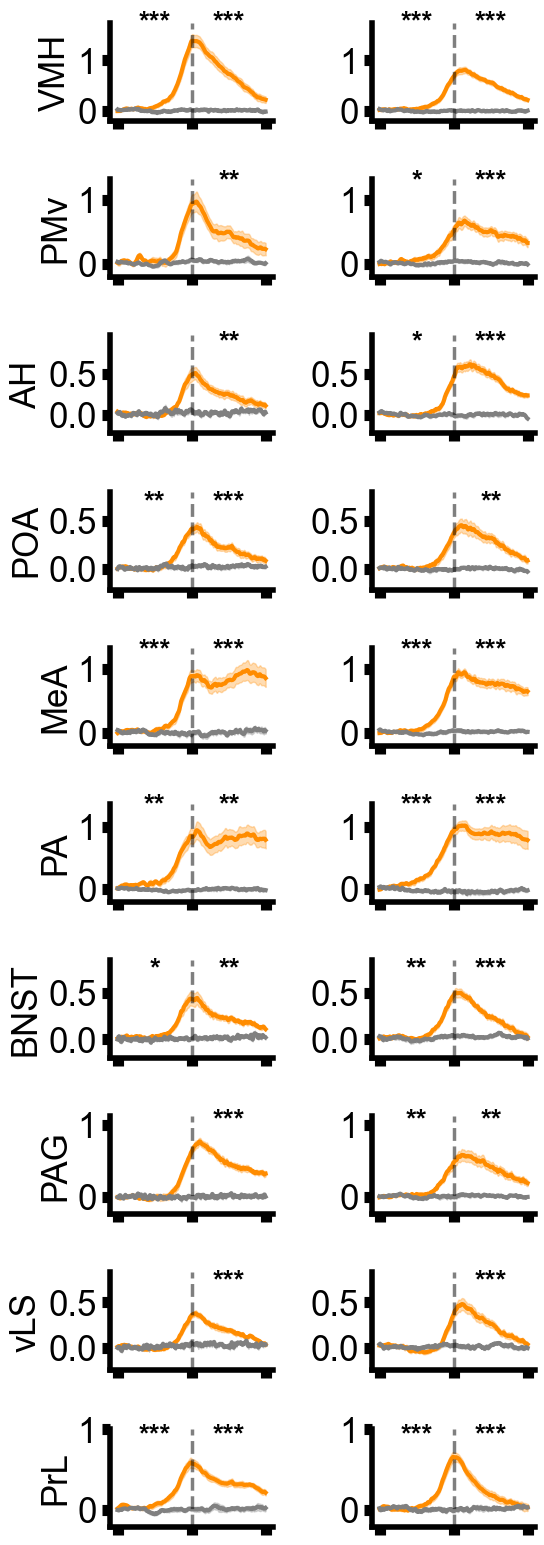

In [38]:
from matplotlib.ticker import MaxNLocator

def add_significance_to_plot(ax, prep_pval, post_pval, ylim_top, n):
    def get_sig_marker(p):
        if p < 0.001:  return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else:          return ''

    prep_marker = get_sig_marker(prep_pval)
    if prep_marker:
        ax.text(n/4, ylim_top + 0.1, prep_marker,
                ha='center', va='bottom', fontsize=20, fontweight='bold')

    post_marker = get_sig_marker(post_pval)
    if post_marker:
        ax.text(3*n/4, ylim_top + 0.1, post_marker,
                ha='center', va='bottom', fontsize=20, fontweight='bold')


periods   = [80, 400]
n         = periods[1] - periods[0]
agg_color = 'darkorange'
non_color = 'gray'

# ── LHb (18) and NAc DA (22) removed ─────────────────────────────────────────
sorting = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0]   # 10 E regions
# idxs2loop for stats (21 regions, no LHb/NAc) — E then I
# E: [12,16,8,4,10,20,6,14,2,0]  indices 0-9
# I: [13,17,9,5,11,21,7,15,3,1]  indices 10-19
idxs2loop_plot = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0,
                            13, 17, 9, 5, 11, 21, 7, 15, 3, 1])

fig, ax = plt.subplots(10, 2, figsize=(6, 16))

for i, r in enumerate(sorting):
    try:
        # ── E column ──────────────────────────────────────────────────────────
        agg_E = agg_peths[:, r, :] - \
                np.nanmedian(agg_peths[baseline[0]:baseline[1], r, :],
                             axis=0, keepdims=True)
        non_E = non_peths[:, r, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r, :],
                             axis=0, keepdims=True)

        ax[i, 0].plot(np.nanmean(agg_E, axis=1)[periods[0]:periods[1]],
                      color=agg_color, linewidth=3, label='agg')
        ax[i, 0].fill_between(
            range(n),
            np.nanmean(agg_E, axis=1)[periods[0]:periods[1]] -
            np.nanstd(agg_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(agg_peths.shape[2]),
            np.nanmean(agg_E, axis=1)[periods[0]:periods[1]] +
            np.nanstd(agg_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(agg_peths.shape[2]),
            alpha=0.3, color=agg_color)
        ax[i, 0].plot(np.nanmean(non_E, axis=1)[periods[0]:periods[1]],
                      color=non_color, linewidth=3, label='non')
        ax[i, 0].fill_between(
            range(n),
            np.nanmean(non_E, axis=1)[periods[0]:periods[1]] -
            np.nanstd(non_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_peths.shape[2]),
            np.nanmean(non_E, axis=1)[periods[0]:periods[1]] +
            np.nanstd(non_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_peths.shape[2]),
            alpha=0.3, color=non_color)
        ax[i, 0].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 0].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # ── I column ──────────────────────────────────────────────────────────
        agg_I = agg_peths[:, r+1, :] - \
                np.nanmedian(agg_peths[baseline[0]:baseline[1], r+1, :],
                             axis=0, keepdims=True)
        non_I = non_peths[:, r+1, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r+1, :],
                             axis=0, keepdims=True)

        ax[i, 1].plot(np.nanmean(agg_I, axis=1)[periods[0]:periods[1]],
                      color=agg_color, linewidth=3)
        ax[i, 1].fill_between(
            range(n),
            np.nanmean(agg_I, axis=1)[periods[0]:periods[1]] -
            np.nanstd(agg_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(agg_I.shape[1]),
            np.nanmean(agg_I, axis=1)[periods[0]:periods[1]] +
            np.nanstd(agg_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(agg_I.shape[1]),
            alpha=0.3, color=agg_color)
        ax[i, 1].plot(np.nanmean(non_I, axis=1)[periods[0]:periods[1]],
                      color=non_color, linewidth=3)
        ax[i, 1].fill_between(
            range(n),
            np.nanmean(non_I, axis=1)[periods[0]:periods[1]] -
            np.nanstd(non_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_I.shape[1]),
            np.nanmean(non_I, axis=1)[periods[0]:periods[1]] +
            np.nanstd(non_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_I.shape[1]),
            alpha=0.3, color=non_color)
        ax[i, 1].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 1].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # ── y limits ──────────────────────────────────────────────────────────
        max1 = np.nanmean(agg_E, axis=1)[periods[0]:periods[1]].max()
        max2 = np.nanmean(agg_I, axis=1)[periods[0]:periods[1]].max()
        min1 = np.nanmean(agg_E, axis=1)[periods[0]:periods[1]].min()
        min2 = np.nanmean(agg_I, axis=1)[periods[0]:periods[1]].min()
        ylim_top    = max(max1, max2)
        ylim_bottom = min(min1, min2)
        ax[i, 0].set_ylim(bottom=ylim_bottom - 0.2, top=ylim_top + 0.35)
        ax[i, 1].set_ylim(bottom=ylim_bottom - 0.2, top=ylim_top + 0.35)
        ax[i, 0].set_ylabel(
            region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''),
            fontfamily='Arial')

        # ── significance — index into 21-region corrected p-val arrays ────────
        # E regions occupy positions 0-9, I regions 10-19 in idxs2loop_plot
        add_significance_to_plot(
            ax[i, 0],
            prep_pvals_corrected_AGG[i],
            post_pvals_corrected_AGG[i],
            ylim_top, n)
        add_significance_to_plot(
            ax[i, 1],
            prep_pvals_corrected_AGG[i + 10],
            post_pvals_corrected_AGG[i + 10],
            ylim_top, n)

        sns.despine()

    except IndexError as e:
        print(f'IndexError for region index {r}: {e}')

fig.subplots_adjust(wspace=0.7, hspace=0.25)
plt.tight_layout()
# plt.savefig('./figure_updates/fig2_agg_PETHs.svg', dpi=300)

In [39]:
# Save EXP PETH source data

rows = []

for i, r in enumerate(sorting):
    try:
        region_label = region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        # ── E channel ─────────────────────────────────────────────────────────
        agg_E = agg_peths[:, r, :] - \
                np.nanmedian(agg_peths[baseline[0]:baseline[1], r, :], axis=0, keepdims=True)
        non_E = non_peths[:, r, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r, :], axis=0, keepdims=True)

        exp_E_slice = agg_E[periods[0]:periods[1], :]  # (n_timepoints, n_animals)
        non_E_slice = non_E[periods[0]:periods[1], :]

        exp_E_mean = np.nanmean(exp_E_slice, axis=1)
        exp_E_sem  = np.nanstd(exp_E_slice, axis=1) / np.sqrt(agg_peths.shape[2])
        non_E_mean = np.nanmean(non_E_slice, axis=1)
        non_E_sem  = np.nanstd(non_E_slice, axis=1) / np.sqrt(non_peths.shape[2])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'E', 'timepoint': t,
                'exp_mean': exp_E_mean[t], 'exp_sem': exp_E_sem[t],
                'non_mean': non_E_mean[t], 'non_sem': non_E_sem[t],
                'prep_p_fdr': prep_pvals_corrected_AGG[i],
                'post_p_fdr': post_pvals_corrected_AGG[i],
            }
            for a in range(exp_E_slice.shape[1]):
                row[f'exp_animal_{a}'] = exp_E_slice[t, a]
            for a in range(non_E_slice.shape[1]):
                row[f'non_animal_{a}'] = non_E_slice[t, a]
            rows.append(row)

        # ── I channel ─────────────────────────────────────────────────────────
        agg_I = agg_peths[:, r+1, :] - \
                np.nanmedian(agg_peths[baseline[0]:baseline[1], r+1, :], axis=0, keepdims=True)
        non_I = non_peths[:, r+1, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r+1, :], axis=0, keepdims=True)

        exp_I_slice = agg_I[periods[0]:periods[1], :]
        non_I_slice = non_I[periods[0]:periods[1], :]

        exp_I_mean = np.nanmean(exp_I_slice, axis=1)
        exp_I_sem  = np.nanstd(exp_I_slice, axis=1) / np.sqrt(agg_I.shape[1])
        non_I_mean = np.nanmean(non_I_slice, axis=1)
        non_I_sem  = np.nanstd(non_I_slice, axis=1) / np.sqrt(non_I.shape[1])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'I', 'timepoint': t,
                'exp_mean': exp_I_mean[t], 'exp_sem': exp_I_sem[t],
                'non_mean': non_I_mean[t], 'non_sem': non_I_sem[t],
                'prep_p_fdr': prep_pvals_corrected_AGG[i + 10],
                'post_p_fdr': post_pvals_corrected_AGG[i + 10],
            }
            for a in range(exp_I_slice.shape[1]):
                row[f'exp_animal_{a}'] = exp_I_slice[t, a]
            for a in range(non_I_slice.shape[1]):
                row[f'non_animal_{a}'] = non_I_slice[t, a]
            rows.append(row)

    except IndexError as e:
        print(f'IndexError for region index {r}: {e}')

sourceData_2j = pd.DataFrame(rows)
sourceData_2j.to_csv('./sourceData/2j_EXP.csv', index=False)

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


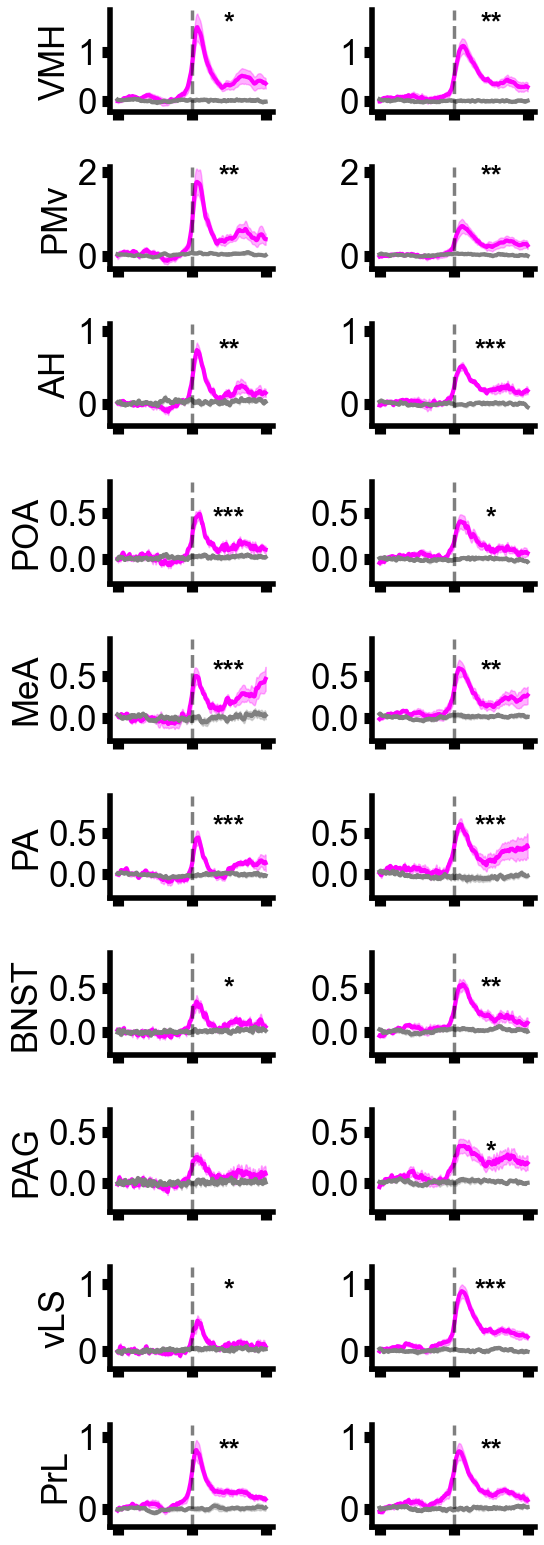

In [40]:
from matplotlib.ticker import MaxNLocator

periods   = [80, 400]
n         = periods[1] - periods[0]
obs_color = 'magenta'
non_color = 'gray'

# ── LHb (18) and NAc DA (22) removed ─────────────────────────────────────────
sorting = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0]   # 10 E regions

fig, ax = plt.subplots(10, 2, figsize=(6, 16))

for i, r in enumerate(sorting):
    try:
        # ── E column ──────────────────────────────────────────────────────────
        obs_E = obs_peths[:, r, :] - \
                np.nanmedian(obs_peths[baseline[0]:baseline[1], r, :],
                             axis=0, keepdims=True)
        non_E = non_peths[:, r, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r, :],
                             axis=0, keepdims=True)

        ax[i, 0].plot(np.nanmean(obs_E, axis=1)[periods[0]:periods[1]],
                      color=obs_color, linewidth=3, label='obs')
        ax[i, 0].fill_between(
            range(n),
            np.nanmean(obs_E, axis=1)[periods[0]:periods[1]] -
            np.nanstd(obs_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(obs_peths.shape[2]),
            np.nanmean(obs_E, axis=1)[periods[0]:periods[1]] +
            np.nanstd(obs_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(obs_peths.shape[2]),
            alpha=0.3, color=obs_color)
        ax[i, 0].plot(np.nanmean(non_E, axis=1)[periods[0]:periods[1]],
                      color=non_color, linewidth=3, label='non')
        ax[i, 0].fill_between(
            range(n),
            np.nanmean(non_E, axis=1)[periods[0]:periods[1]] -
            np.nanstd(non_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_peths.shape[2]),
            np.nanmean(non_E, axis=1)[periods[0]:periods[1]] +
            np.nanstd(non_E,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_peths.shape[2]),
            alpha=0.3, color=non_color)
        ax[i, 0].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 0].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # ── I column ──────────────────────────────────────────────────────────
        obs_I = obs_peths[:, r+1, :] - \
                np.nanmedian(obs_peths[baseline[0]:baseline[1], r+1, :],
                             axis=0, keepdims=True)
        non_I = non_peths[:, r+1, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r+1, :],
                             axis=0, keepdims=True)

        ax[i, 1].plot(np.nanmean(obs_I, axis=1)[periods[0]:periods[1]],
                      color=obs_color, linewidth=3)
        ax[i, 1].fill_between(
            range(n),
            np.nanmean(obs_I, axis=1)[periods[0]:periods[1]] -
            np.nanstd(obs_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(obs_I.shape[1]),
            np.nanmean(obs_I, axis=1)[periods[0]:periods[1]] +
            np.nanstd(obs_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(obs_I.shape[1]),
            alpha=0.3, color=obs_color)
        ax[i, 1].plot(np.nanmean(non_I, axis=1)[periods[0]:periods[1]],
                      color=non_color, linewidth=3)
        ax[i, 1].fill_between(
            range(n),
            np.nanmean(non_I, axis=1)[periods[0]:periods[1]] -
            np.nanstd(non_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_I.shape[1]),
            np.nanmean(non_I, axis=1)[periods[0]:periods[1]] +
            np.nanstd(non_I,  axis=1)[periods[0]:periods[1]] /
            np.sqrt(non_I.shape[1]),
            alpha=0.3, color=non_color)
        ax[i, 1].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 1].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # ── y limits ──────────────────────────────────────────────────────────
        max1 = np.nanmean(obs_E, axis=1)[periods[0]:periods[1]].max()
        max2 = np.nanmean(obs_I, axis=1)[periods[0]:periods[1]].max()
        min1 = np.nanmean(obs_E, axis=1)[periods[0]:periods[1]].min()
        min2 = np.nanmean(obs_I, axis=1)[periods[0]:periods[1]].min()
        ylim_top    = max(max1, max2)
        ylim_bottom = min(min1, min2)
        ax[i, 0].set_ylim(bottom=ylim_bottom - 0.2, top=ylim_top + 0.35)
        ax[i, 1].set_ylim(bottom=ylim_bottom - 0.2, top=ylim_top + 0.35)
        ax[i, 0].set_ylabel(
            region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''),
            fontfamily='Arial')

        # ── significance ──────────────────────────────────────────────────────
        add_significance_to_plot(
            ax[i, 0],
            prep_pvals_corrected_OBS[i],
            post_pvals_corrected_OBS[i],
            ylim_top - 0.3, n)
        add_significance_to_plot(
            ax[i, 1],
            prep_pvals_corrected_OBS[i + 10],
            post_pvals_corrected_OBS[i + 10],
            ylim_top - 0.3, n)

        sns.despine()

    except IndexError as e:
        print(f'IndexError for region index {r}: {e}')

fig.subplots_adjust(wspace=0.7, hspace=0.25)
plt.tight_layout()
# plt.savefig('./figure_updates/fig2_obs_PETHs.svg', dpi=300)

In [48]:
rows = []

for i, r in enumerate(sorting):
    try:
        region_label = region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        # ── E channel ─────────────────────────────────────────────────────────
        obs_E = obs_peths[:, r, :] - \
                np.nanmedian(obs_peths[baseline[0]:baseline[1], r, :], axis=0, keepdims=True)
        non_E = non_peths[:, r, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r, :], axis=0, keepdims=True)

        obs_E_slice = obs_E[periods[0]:periods[1], :]
        non_E_slice = non_E[periods[0]:periods[1], :]

        obs_E_mean = np.nanmean(obs_E_slice, axis=1)
        obs_E_sem  = np.nanstd(obs_E_slice, axis=1) / np.sqrt(obs_peths.shape[2])
        non_E_mean = np.nanmean(non_E_slice, axis=1)
        non_E_sem  = np.nanstd(non_E_slice, axis=1) / np.sqrt(non_peths.shape[2])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'E', 'timepoint': t,
                'obs_mean': obs_E_mean[t], 'obs_sem': obs_E_sem[t],
                'non_mean': non_E_mean[t], 'non_sem': non_E_sem[t],
                'prep_p_fdr': prep_pvals_corrected_OBS[i],
                'post_p_fdr': post_pvals_corrected_OBS[i],
            }
            for a in range(obs_E_slice.shape[1]):
                row[f'obs_animal_{a}'] = obs_E_slice[t, a]
            for a in range(non_E_slice.shape[1]):
                row[f'non_animal_{a}'] = non_E_slice[t, a]
            rows.append(row)

        # ── I channel ─────────────────────────────────────────────────────────
        obs_I = obs_peths[:, r+1, :] - \
                np.nanmedian(obs_peths[baseline[0]:baseline[1], r+1, :], axis=0, keepdims=True)
        non_I = non_peths[:, r+1, :] - \
                np.nanmedian(non_peths[baseline[0]:baseline[1], r+1, :], axis=0, keepdims=True)

        obs_I_slice = obs_I[periods[0]:periods[1], :]
        non_I_slice = non_I[periods[0]:periods[1], :]

        obs_I_mean = np.nanmean(obs_I_slice, axis=1)
        obs_I_sem  = np.nanstd(obs_I_slice, axis=1) / np.sqrt(obs_I.shape[1])
        non_I_mean = np.nanmean(non_I_slice, axis=1)
        non_I_sem  = np.nanstd(non_I_slice, axis=1) / np.sqrt(non_I.shape[1])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'I', 'timepoint': t,
                'obs_mean': obs_I_mean[t], 'obs_sem': obs_I_sem[t],
                'non_mean': non_I_mean[t], 'non_sem': non_I_sem[t],
                'prep_p_fdr': prep_pvals_corrected_OBS[i + 10],
                'post_p_fdr': post_pvals_corrected_OBS[i + 10],
            }
            for a in range(obs_I_slice.shape[1]):
                row[f'obs_animal_{a}'] = obs_I_slice[t, a]
            for a in range(non_I_slice.shape[1]):
                row[f'non_animal_{a}'] = non_I_slice[t, a]
            rows.append(row)

    except IndexError as e:
        print(f'IndexError for region index {r}: {e}')

sourceData_2k = pd.DataFrame(rows)
sourceData_2k.to_csv('./sourceData/2j_OBS.csv', index=False)

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


In [41]:
# Summarize all statistics for export

mean_func = np.nanmean

def improved_between_group_stats(data2plot, alpha=0.05):
    agg_roi_activity = data2plot[0][~np.isnan(data2plot[0])]
    obs_roi_activity = data2plot[1][~np.isnan(data2plot[1])]
    non_roi_activity = data2plot[2][~np.isnan(data2plot[2])]
    results = {}
    results['agg_vs_non'] = _perform_comparison(agg_roi_activity, non_roi_activity, 'AGG', 'NON', alpha)
    results['obs_vs_non'] = _perform_comparison(obs_roi_activity, non_roi_activity, 'OBS', 'NON', alpha)
    return results

def _perform_comparison(group1, group2, name1, name2, alpha):
    def test_normality(data):
        if len(data) < 8:
            return False
        _, p_shapiro = stats.shapiro(data)
        if len(data) >= 20:
            _, p_dagostino = stats.normaltest(data)
            return (p_shapiro > alpha) and (p_dagostino > alpha)
        else:
            return p_shapiro > alpha

    mean1, mean2 = np.mean(group1), np.mean(group2)
    mean_diff    = mean1 - mean2
    direction    = f"{name1} > {name2}" if mean_diff > 0 else \
                   f"{name1} < {name2}" if mean_diff < 0 else f"{name1} = {name2}"

    normal1 = test_normality(group1)
    normal2 = test_normality(group2)

    df = np.nan  # only defined for t-tests

    if normal1 and normal2:
        _, p_levene = stats.levene(group1, group2)
        equal_var   = p_levene > alpha
        statistic, p_value = stats.ttest_ind(group1, group2, equal_var=equal_var)
        test_type = f"t-test (eqvar={equal_var})"

        if equal_var:
            df = len(group1) + len(group2) - 2
        else:
            # Welch-Satterthwaite approximation
            v1, v2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
            n1, n2 = len(group1), len(group2)
            df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))

        pooled_std = np.sqrt(((len(group1)-1)*np.var(group1, ddof=1) +
                              (len(group2)-1)*np.var(group2, ddof=1)) /
                             (len(group1) + len(group2) - 2))
        effect_size = (mean1 - mean2) / pooled_std
        effect_name = "Cohen's d"
    else:
        statistic, p_value = stats.brunnermunzel(group1, group2, alternative='two-sided')
        test_type = "Brunner Munzel"
        if np.isnan(p_value):
            statistic, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
            test_type = "Mann-Whitney U"
        z_score = stats.norm.ppf(1 - p_value/2) * np.sign(np.median(group1) - np.median(group2))
        effect_size = z_score / np.sqrt(len(group1) + len(group2))
        effect_name = "r"

    return {
        'statistic': statistic, 'p_value': p_value, 'test_type': test_type,
        'df': df, 'effect_size': effect_size, 'effect_name': effect_name,
        'direction': direction, 'n1': len(group1), 'n2': len(group2),
        'mean1': mean1, 'mean2': mean2,
    }

def fmt_p(p):
    """Full-precision p-value; scientific notation below 0.0001."""
    if p < 0.0001:
        return f'{p:.3e}'
    return f'{p:.6f}'

# ── shared region list ────────────────────────────────────────────────────────
idxs2loop  = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 13, 17, 9, 5, 11, 21, 7, 15, 3, 1])
pval_names = [region_ids[idx] for idx in idxs2loop]
baseline   = [0, 160]

# ── define both timepoints from scratch ────────────────────────────────────────
timepoint_configs = [
    ('Pre-attack (-2s to 0s)', 160, 240),
    ('Attack (0s to +1s)',      240, 280),
]

all_records = []

for tp_label, start, stop in timepoint_configs:

    agg_peths_tp = agg_peths.copy()
    if tp_label.startswith('Pre'):
        agg_peths_tp[:, 18, -2:] = np.nan
        agg_peths_tp[:, -1, -2:] = np.nan

    agg_diff = agg_peths_tp[start:stop, :, :] - \
               np.nanmean(agg_peths_tp[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
    obs_diff = obs_peths[start:stop, :, :] - \
               np.nanmean(obs_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
    non_diff = non_peths[start:stop, :, :] - \
               np.nanmean(non_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)

    all_region_data = []
    for roi in idxs2loop:
        region_data = [
            mean_func(agg_diff[:, roi], axis=0),
            mean_func(obs_diff[:, roi], axis=0),
            mean_func(non_diff[:, roi], axis=0)
        ]
        all_region_data.append(region_data)

    results_uncorrected    = []
    agg_pvals_uncorrected  = []
    obs_pvals_uncorrected  = []

    for region_data in all_region_data:
        region_results = improved_between_group_stats(region_data, alpha=0.05)
        results_uncorrected.append(region_results)
        agg_pvals_uncorrected.append(region_results['agg_vs_non']['p_value'])
        obs_pvals_uncorrected.append(region_results['obs_vs_non']['p_value'])

    _, agg_pvals_corrected, _, _ = multipletests(agg_pvals_uncorrected, method='bonferroni', alpha=0.05)
    _, obs_pvals_corrected, _, _ = multipletests(obs_pvals_uncorrected, method='bonferroni', alpha=0.05)

    for i, region_name in enumerate(pval_names):
        for comp_key, comp_label, p_corr in [
            ('agg_vs_non', 'AGG vs NON', agg_pvals_corrected[i]),
            ('obs_vs_non', 'OBS vs NON', obs_pvals_corrected[i]),
        ]:
            r = results_uncorrected[i][comp_key]
            all_records.append({
                'timepoint':   tp_label,
                'region':      region_name,
                'comparison':  comp_label,
                'test_type':   r['test_type'],
                'statistic':   r['statistic'],
                'df':          r['df'],
                'p_raw':       r['p_value'],
                'p_bonf':      p_corr,
                'effect_size': r['effect_size'],
                'effect_name': r['effect_name'],
                'direction':   r['direction'],
                'n1':          r['n1'],
                'n2':          r['n2'],
                'mean1':       r['mean1'],
                'mean2':       r['mean2'],
            })

# ── print unified table ─────────────────────────────────────────────────────────
def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print(f'\n{"="*175}')
print(f'PETH statistics — pre-attack and attack windows, Bonferroni-corrected separately '
      f'within AGG-vs-NON and OBS-vs-NON families ({len(pval_names)} regions each, per timepoint)')
print(f'{"="*175}')
header = (f'{"Timepoint":<24} {"Region":<10} {"Comparison":<12} {"Test":<20} '
          f'{"n1":>4} {"n2":>4} {"stat":>9} {"df":>7} '
          f'{"p_raw":>13} {"p_bonf":>13} {"Sig":>4} '
          f'{"EffSz":>8} {"Direction":<12}')
print(header)
print(f'{"─"*175}')

for rec in all_records:
    df_str = f'{rec["df"]:.1f}' if not np.isnan(rec['df']) else 'n/a'
    print(f'{rec["timepoint"]:<24} {rec["region"]:<10} {rec["comparison"]:<12} '
          f'{rec["test_type"]:<20} {rec["n1"]:>4} {rec["n2"]:>4} '
          f'{rec["statistic"]:>9.3f} {df_str:>7} '
          f'{fmt_p(rec["p_raw"]):>13} {fmt_p(rec["p_bonf"]):>13} '
          f'{get_sig(rec["p_bonf"]):>4} {rec["effect_size"]:>8.3f} '
          f'{rec["direction"]:<12}')

print(f'{"="*175}')

# ── summary counts ────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'SUMMARY')
print(f'{"="*60}')
for tp_label, _, _ in timepoint_configs:
    tp_records = [r for r in all_records if r['timepoint'] == tp_label]
    for comp_label in ['AGG vs NON', 'OBS vs NON']:
        subset = [r for r in tp_records if r['comparison'] == comp_label]
        n_sig  = sum(1 for r in subset if r['p_bonf'] < 0.05)
        print(f'  {tp_label:<24} {comp_label:<12}: {n_sig}/{len(subset)} significant (Bonferroni)')
print(f'{"="*60}')


PETH statistics — pre-attack and attack windows, Bonferroni-corrected separately within AGG-vs-NON and OBS-vs-NON families (20 regions each, per timepoint)
Timepoint                Region     Comparison   Test                   n1   n2      stat      df         p_raw        p_bonf  Sig    EffSz Direction   
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Pre-attack (-2s to 0s)   VMH (E)    AGG vs NON   t-test (eqvar=False)   12    8     8.213    12.2     2.597e-06     5.195e-05  ***    3.079 AGG > NON   
Pre-attack (-2s to 0s)   VMH (E)    OBS vs NON   t-test (eqvar=True)     9    8     2.123    15.0      0.050844      1.000000   ns    1.031 OBS > NON   
Pre-attack (-2s to 0s)   PMv (E)    AGG vs NON   t-test (eqvar=False)   11    8     3.504    11.5      0.004601      0.092014   ns    1.403 AGG > NON   
Pre-attack (-2s to 0s)   PMv (E)    OBS vs NON   t-test

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1427641148.py:98: RuntimeWarning: Mean of empty slice
  np.nanmean(agg_peths_tp[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1427641148.py:100: RuntimeWarning: Mean of empty slice
  np.nanmean(obs_peths[baseline[0]:baseline[1], :, :], axis=0, keepdims=True)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1427641148.py:107: RuntimeWarning: Mean of empty slice
  mean_func(agg_diff[:, roi], axis=0),
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7368\1427641148.py:108: RuntimeWarning: Mean of empty slice
  mean_func(obs_diff[:, roi], axis=0),
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9485: RuntimeWarning: divide by zero encountered in double_scalars
  wbfn /= (nx + ny) * np.sqrt(nx * Sx + ny * Sy)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9491: RuntimeWarning: invalid va

In [38]:
lhb_idx = region_ids.index('LHb (E)')
nac_idx = region_ids.index('NAc (DA)')

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\1582004179.py:25: RuntimeWarning: Mean of empty slice
  np.nanmean(peth[baseline[0]:baseline[1], roi, :],
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\1582004179.py:27: RuntimeWarning: Mean of empty slice
  vals = np.nanmean(data[window[0]:window[1], :], axis=0)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\1582004179.py:100: RuntimeWarning: Mean of empty slice
  np.nanmean(peth[baseline[0]:baseline[1], roi, :],
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\1582004179.py:141: RuntimeWarning: Mean of empty slice
  np.nanmean(peth[baseline[0]:baseline[1], roi, :],
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\1582004179.py:141: RuntimeWarning: Mean of empty slice
  np.nanmean(peth[baseline[0]:baseline[1], roi, :],



NAc DA + LHb (E) — Bonferroni corrected across 8 comparisons
  Panel              Period Test                       Stat      p_raw     p_bonf   Sig
  ───────────────────────────────────────────────────────────────────────────
  EXP NAc (DA)       pre    t-test (eqvar=False)      4.087     0.0018     0.0145     *
  EXP NAc (DA)       post   t-test (eqvar=False)      3.580     0.0049     0.0396     *
  OBS NAc (DA)       pre    t-test (eqvar=True)      -0.198     0.8455     1.0000      
  OBS NAc (DA)       post   t-test (eqvar=True)       3.894     0.0014     0.0115     *
  EXP LHb (E)        pre    t-test (eqvar=False)      0.722     0.4880     1.0000      
  EXP LHb (E)        post   t-test (eqvar=False)      2.379     0.0435     0.3483      
  OBS LHb (E)        pre    t-test (eqvar=False)      2.643     0.0233     0.1864      
  OBS LHb (E)        post   t-test (eqvar=False)      7.532     0.0001     0.0004   ***


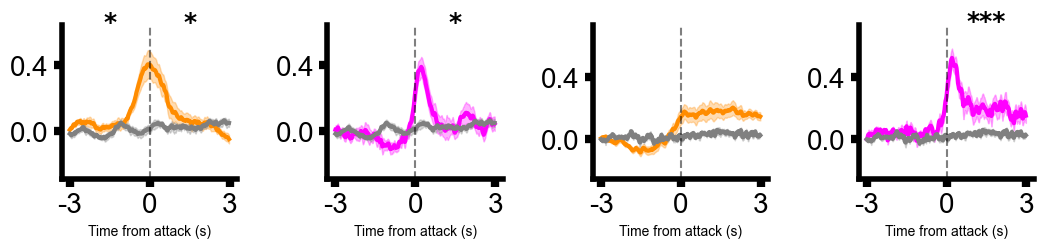

In [39]:
# Separately plot NAc DA and LHb (E) with significance markers for pre/post periods

from matplotlib.ticker import MaxNLocator

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '#'
    return ''

periods   = [80, 400]
n         = periods[1] - periods[0]
baseline  = [0, 120]


# ── Fixed windows for stats ────────────────────────────────────────────────────
pre_window  = (200, 240)
post_window = (240, 270)

# ── Per-animal window means for stats ─────────────────────────────────────────
def get_window_means(peth, roi, window):
    data = peth[:, roi, :] - \
           np.nanmean(peth[baseline[0]:baseline[1], roi, :],
                      axis=0, keepdims=True)
    vals = np.nanmean(data[window[0]:window[1], :], axis=0)
    return data, vals[~np.isnan(vals)]

# ── Run stats for all 4 panels × 2 periods ────────────────────────────────────
# family: 4 regions × 2 periods = 8 comparisons → Bonferroni across all 8
raw_pvals_all = []
stat_records  = []

panels = [
    ('EXP', 'NAc (DA)', agg_peths, nac_idx, 'darkorange'),
    ('OBS', 'NAc (DA)', obs_peths, nac_idx, 'magenta'),
    ('EXP', 'LHb (E)',  agg_peths, lhb_idx, 'darkorange'),
    ('OBS', 'LHb (E)',  obs_peths, lhb_idx, 'magenta'),
]

for group_label, region_label, peth, roi, color in panels:
    for period_label, window in [('pre', pre_window), ('post', post_window)]:
        _, grp_vals = get_window_means(peth, roi, window)
        _, non_vals = get_window_means(non_peths, roi, window)
        res = _perform_comparison(grp_vals, non_vals, group_label, 'NON', alpha=0.05)
        raw_pvals_all.append(res['p_value'])
        stat_records.append({
            'group':   group_label,
            'region':  region_label,
            'period':  period_label,
            'res':     res,
        })

# ── Bonferroni across all 8 comparisons ───────────────────────────────────────
valid_idx   = [i for i, p in enumerate(raw_pvals_all) if not np.isnan(p)]
bonf_pvals  = np.full(len(raw_pvals_all), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests(
        [raw_pvals_all[i] for i in valid_idx], method='bonferroni')
    for rank, i in enumerate(valid_idx):
        bonf_pvals[i] = corr[rank]

for i, rec in enumerate(stat_records):
    rec['p_corrected'] = bonf_pvals[i]

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'\n{"="*75}')
print(f'NAc DA + LHb (E) — Bonferroni corrected across 8 comparisons')
print(f'{"="*75}')
print(f'  {"Panel":<18} {"Period":<6} {"Test":<22} {"Stat":>8} '
      f'{"p_raw":>10} {"p_bonf":>10} {"Sig":>5}')
print(f'  {"─"*75}')
for rec in stat_records:
    r   = rec['res']
    sig = get_sig(rec['p_corrected'])
    print(f'  {rec["group"]} {rec["region"]:<14} {rec["period"]:<6} '
          f'{r["test_type"]:<22} {r["statistic"]:>8.3f} '
          f'{r["p_value"]:>10.4f} {rec["p_corrected"]:>10.4f} {sig:>5}')

# ── Build lookup for sig markers ──────────────────────────────────────────────
sig_lookup = {}
for rec in stat_records:
    sig_lookup[(rec['group'], rec['region'], rec['period'])] = \
        rec['p_corrected']

def get_sig_marker(p):
    if np.isnan(p):    return ''
    if p < 0.001:      return '***'
    elif p < 0.01:     return '**'
    elif p < 0.05:     return '*'
    return ''

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(11, 3))

# ── Pre-compute shared y limits ───────────────────────────────────────────────
def get_ylims(peth, roi):
    data     = peth[:, roi, :] - \
               np.nanmean(peth[baseline[0]:baseline[1], roi, :],
                          axis=0, keepdims=True)
    non_data = non_peths[:, roi, :] - \
               np.nanmean(non_peths[baseline[0]:baseline[1], roi, :],
                          axis=0, keepdims=True)
    mean_grp = np.nanmean(data,     axis=1)[periods[0]:periods[1]]
    sem_grp  = np.nanstd(data,      axis=1)[periods[0]:periods[1]] / \
               np.sqrt(data.shape[1])
    mean_non = np.nanmean(non_data, axis=1)[periods[0]:periods[1]]
    sem_non  = np.nanstd(non_data,  axis=1)[periods[0]:periods[1]] / \
               np.sqrt(non_data.shape[1])
    top    = max((mean_grp + sem_grp).max(), (mean_non + sem_non).max())
    bottom = min((mean_grp - sem_grp).min(), (mean_non - sem_non).min())
    return bottom, top

# shared y limits across both NAc panels and both LHb panels
nac_bot_agg, nac_top_agg = get_ylims(agg_peths, nac_idx)
nac_bot_obs, nac_top_obs = get_ylims(obs_peths, nac_idx)
nac_bottom = min(nac_bot_agg, nac_bot_obs) - 0.15
nac_top    = max(nac_top_agg, nac_top_obs) + 0.15

lhb_bot_agg, lhb_top_agg = get_ylims(agg_peths, lhb_idx)
lhb_bot_obs, lhb_top_obs = get_ylims(obs_peths, lhb_idx)
lhb_bottom = min(lhb_bot_agg, lhb_bot_obs) - 0.15
lhb_top    = max(lhb_top_agg, lhb_top_obs) + 0.15

ylim_lookup = {
    'NAc (DA)': (nac_bottom, nac_top),
    'LHb (E)':  (lhb_bottom, lhb_top),
}

# ── x-tick positions: -3s, 0s, +3s relative to attack onset ──────────────────
# periods[0]=80, attack onset at frame 240, so onset within plot = 240-80=160
# -3s = 160 - 3*40 = 40, 0s = 160, +3s = 160 + 3*40 = 280 (but n=320 so clip)
fps         = 40
onset_frame = 160
xtick_pos   = [0, 160, 320]  # clip to valid range

for ax, (group_label, region_label, peth, roi, color) in zip(axes, panels):

    data     = peth[:, roi, :] - \
               np.nanmean(peth[baseline[0]:baseline[1], roi, :],
                          axis=0, keepdims=True)
    non_data = non_peths[:, roi, :] - \
               np.nanmean(non_peths[baseline[0]:baseline[1], roi, :],
                          axis=0, keepdims=True)

    mean_grp = np.nanmean(data,     axis=1)[periods[0]:periods[1]]
    sem_grp  = np.nanstd(data,      axis=1)[periods[0]:periods[1]] / \
               np.sqrt(data.shape[1])
    mean_non = np.nanmean(non_data, axis=1)[periods[0]:periods[1]]
    sem_non  = np.nanstd(non_data,  axis=1)[periods[0]:periods[1]] / \
               np.sqrt(non_data.shape[1])

    ax.plot(mean_grp, color=color,  linewidth=3, label=group_label)
    ax.fill_between(range(n), mean_grp - sem_grp, mean_grp + sem_grp,
                    alpha=0.3, color=color)
    ax.plot(mean_non, color='gray', linewidth=3, label='NON')
    ax.fill_between(range(n), mean_non - sem_non, mean_non + sem_non,
                    alpha=0.3, color='gray')

    ax.axvline(onset_frame, linestyle='--', color='black',
               alpha=0.5, linewidth=1.5)

    # ── x ticks: -3, 0, +3 ───────────────────────────────────────────────────
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(['-3', '0', '3'], fontfamily='Arial', fontsize=11)
    ax.set_xlabel('Time from attack (s)', fontfamily='Arial', fontsize=10)

    # ── shared y limits ───────────────────────────────────────────────────────
    y_bot, y_top = ylim_lookup[region_label]
    ax.set_ylim(bottom=y_bot, top=y_top)

    # ── significance markers ──────────────────────────────────────────────────
    p_pre  = sig_lookup.get((group_label, region_label, 'pre'),  np.nan)
    p_post = sig_lookup.get((group_label, region_label, 'post'), np.nan)

    pre_marker  = get_sig_marker(p_pre)
    post_marker = get_sig_marker(p_post)

    if pre_marker:
        ax.text(onset_frame / 2, y_top - 0.05, pre_marker,
                ha='center', va='bottom', fontsize=18, fontweight='bold')
    if post_marker:
        ax.text(onset_frame + (n - onset_frame) / 2, y_top - 0.05,
                post_marker,
                ha='center', va='bottom', fontsize=18, fontweight='bold')

    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial'); tick.set_fontsize(20)
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    ax.tick_params(width=6, length=6)
    sns.despine(ax=ax)

fig.subplots_adjust(wspace=0.5)
plt.tight_layout()
# plt.savefig('./figures/fig2/nac_lhb_PETHs.svg', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# Separately plot NAc DA and LHb (E) with significance markers for pre/post periods

from matplotlib.ticker import MaxNLocator

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '#'
    return ''

periods   = [80, 400]
n         = periods[1] - periods[0]
baseline  = [0, 120]

pre_window  = (200, 240)
post_window = (240, 270)

def get_window_means(peth, roi, window):
    data = peth[:, roi, :] - \
           np.nanmean(peth[baseline[0]:baseline[1], roi, :],
                      axis=0, keepdims=True)
    vals = np.nanmean(data[window[0]:window[1], :], axis=0)
    return data, vals[~np.isnan(vals)]

# ── Run stats for all 4 panels × 2 periods, now with df carried through ───────
# family: 4 regions × 2 periods = 8 comparisons → Bonferroni across all 8
raw_pvals_all = []
stat_records  = []

panels = [
    ('EXP', 'NAc (DA)', agg_peths, nac_idx, 'darkorange'),
    ('OBS', 'NAc (DA)', obs_peths, nac_idx, 'magenta'),
    ('EXP', 'LHb (E)',  agg_peths, lhb_idx, 'darkorange'),
    ('OBS', 'LHb (E)',  obs_peths, lhb_idx, 'magenta'),
]

for group_label, region_label, peth, roi, color in panels:
    for period_label, window in [('pre', pre_window), ('post', post_window)]:
        _, grp_vals = get_window_means(peth, roi, window)
        _, non_vals = get_window_means(non_peths, roi, window)
        # _perform_comparison already returns 'df' (NaN for Brunner-Munzel,
        # populated for both t-test branches) — carry it through directly
        res = _perform_comparison(grp_vals, non_vals, group_label, 'NON', alpha=0.05)
        raw_pvals_all.append(res['p_value'])
        stat_records.append({
            'group':   group_label,
            'region':  region_label,
            'period':  period_label,
            'res':     res,
        })

# ── Bonferroni across all 8 comparisons ───────────────────────────────────────
valid_idx   = [i for i, p in enumerate(raw_pvals_all) if not np.isnan(p)]
bonf_pvals  = np.full(len(raw_pvals_all), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests(
        [raw_pvals_all[i] for i in valid_idx], method='bonferroni')
    for rank, i in enumerate(valid_idx):
        bonf_pvals[i] = corr[rank]

for i, rec in enumerate(stat_records):
    rec['p_corrected'] = bonf_pvals[i]

# ── Print summary — now includes df ────────────────────────────────────────────
print(f'\n{"="*90}')
print(f'NAc DA + LHb (E) — Bonferroni corrected across 8 comparisons')
print(f'{"="*90}')
print(f'  {"Panel":<18} {"Period":<6} {"Test":<20} {"Stat":>8} {"df":>7} '
      f'{"p_raw":>10} {"p_bonf":>10} {"Sig":>5}')
print(f'  {"─"*90}')
for rec in stat_records:
    r = rec['res']
    sig = get_sig(rec['p_corrected'])
    df_str = f'{r["df"]:.1f}' if not np.isnan(r['df']) else 'n/a'
    print(f'  {rec["group"]} {rec["region"]:<14} {rec["period"]:<6} '
          f'{r["test_type"]:<20} {r["statistic"]:>8.3f} {df_str:>7} '
          f'{r["p_value"]:>10.4f} {rec["p_corrected"]:>10.4f} {sig:>5}')


NAc DA + LHb (E) — Bonferroni corrected across 8 comparisons
  Panel              Period Test                     Stat      df      p_raw     p_bonf   Sig
  ──────────────────────────────────────────────────────────────────────────────────────────
  EXP NAc (DA)       pre    t-test (eqvar=False)    4.087    10.9     0.0018     0.0145     *
  EXP NAc (DA)       post   t-test (eqvar=False)    3.580    10.1     0.0049     0.0396     *
  OBS NAc (DA)       pre    t-test (eqvar=True)    -0.198    15.0     0.8455     1.0000      
  OBS NAc (DA)       post   t-test (eqvar=True)     3.894    15.0     0.0014     0.0115     *
  EXP LHb (E)        pre    t-test (eqvar=False)    0.722     9.2     0.4880     1.0000      
  EXP LHb (E)        post   t-test (eqvar=False)    2.379     8.3     0.0435     0.3483      
  OBS LHb (E)        pre    t-test (eqvar=False)    2.643    10.7     0.0233     0.1864      
  OBS LHb (E)        post   t-test (eqvar=False)    7.532     8.4     0.0001     0.0004   ***

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\3530170455.py:22: RuntimeWarning: Mean of empty slice
  np.nanmean(peth[baseline[0]:baseline[1], roi, :],
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\3530170455.py:24: RuntimeWarning: Mean of empty slice
  vals = np.nanmean(data[window[0]:window[1], :], axis=0)


In [41]:
# ── Sample sizes ──────────────────────────────────────────────────────────────
print(f'\n{"="*50}')
print(f'Sample sizes (n animals per group)')
print(f'{"="*50}')
print(f'  EXP (agg_peths):  {agg_peths.shape[2]} animals')
print(f'  OBS (obs_peths):  {obs_peths.shape[2]} animals')
print(f'  NON (non_peths):  {non_peths.shape[2]} animals')
print()
for group_label, region_label, peth, roi, color in panels:
    for period_label, window in [('pre', pre_window), ('post', post_window)]:
        _, grp_vals = get_window_means(peth, roi, window)
        _, non_vals = get_window_means(non_peths, roi, window)
        print(f'  {group_label} {region_label:<14} {period_label:<6} '
              f'n_grp={len(grp_vals):>3}  n_non={len(non_vals):>3}')
print(f'{"="*50}')


Sample sizes (n animals per group)
  EXP (agg_peths):  12 animals
  OBS (obs_peths):  9 animals
  NON (non_peths):  8 animals

  EXP NAc (DA)       pre    n_grp= 10  n_non=  8
  EXP NAc (DA)       post   n_grp= 10  n_non=  8
  OBS NAc (DA)       pre    n_grp=  9  n_non=  8
  OBS NAc (DA)       post   n_grp=  9  n_non=  8
  EXP LHb (E)        pre    n_grp=  9  n_non=  8
  EXP LHb (E)        post   n_grp=  9  n_non=  8
  OBS LHb (E)        pre    n_grp=  9  n_non=  8
  OBS LHb (E)        post   n_grp=  9  n_non=  8


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\3530170455.py:22: RuntimeWarning: Mean of empty slice
  np.nanmean(peth[baseline[0]:baseline[1], roi, :],
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_26332\3530170455.py:24: RuntimeWarning: Mean of empty slice
  vals = np.nanmean(data[window[0]:window[1], :], axis=0)


In [97]:
rows = []

for group_label, region_label, peth, roi, color in panels:
    data_slice     = (peth[:, roi, :] - np.nanmean(peth[baseline[0]:baseline[1], roi, :], axis=0, keepdims=True))[periods[0]:periods[1], :]
    non_data_slice = (non_peths[:, roi, :] - np.nanmean(non_peths[baseline[0]:baseline[1], roi, :], axis=0, keepdims=True))[periods[0]:periods[1], :]

    mean_grp = np.nanmean(data_slice, axis=1)
    sem_grp  = np.nanstd(data_slice, axis=1) / np.sqrt(data_slice.shape[1])
    mean_non = np.nanmean(non_data_slice, axis=1)
    sem_non  = np.nanstd(non_data_slice, axis=1) / np.sqrt(non_data_slice.shape[1])

    p_pre  = sig_lookup.get((group_label, region_label, 'pre'), np.nan)
    p_post = sig_lookup.get((group_label, region_label, 'post'), np.nan)

    for t in range(n):
        row = {
            'group': group_label,
            'region': region_label,
            'timepoint': t,
            'group_mean': mean_grp[t],
            'group_sem': sem_grp[t],
            'non_mean': mean_non[t],
            'non_sem': sem_non[t],
            'pre_p_bonf': p_pre,
            'post_p_bonf': p_post,
        }
        for a in range(data_slice.shape[1]):
            row[f'group_animal_{a}'] = data_slice[t, a]
        for a in range(non_data_slice.shape[1]):
            row[f'non_animal_{a}'] = non_data_slice[t, a]
        rows.append(row)

sourceData_3a = pd.DataFrame(rows)
sourceData_3a.to_csv('./sourceData/3a.csv', index=False)

IndexError for region index: 22


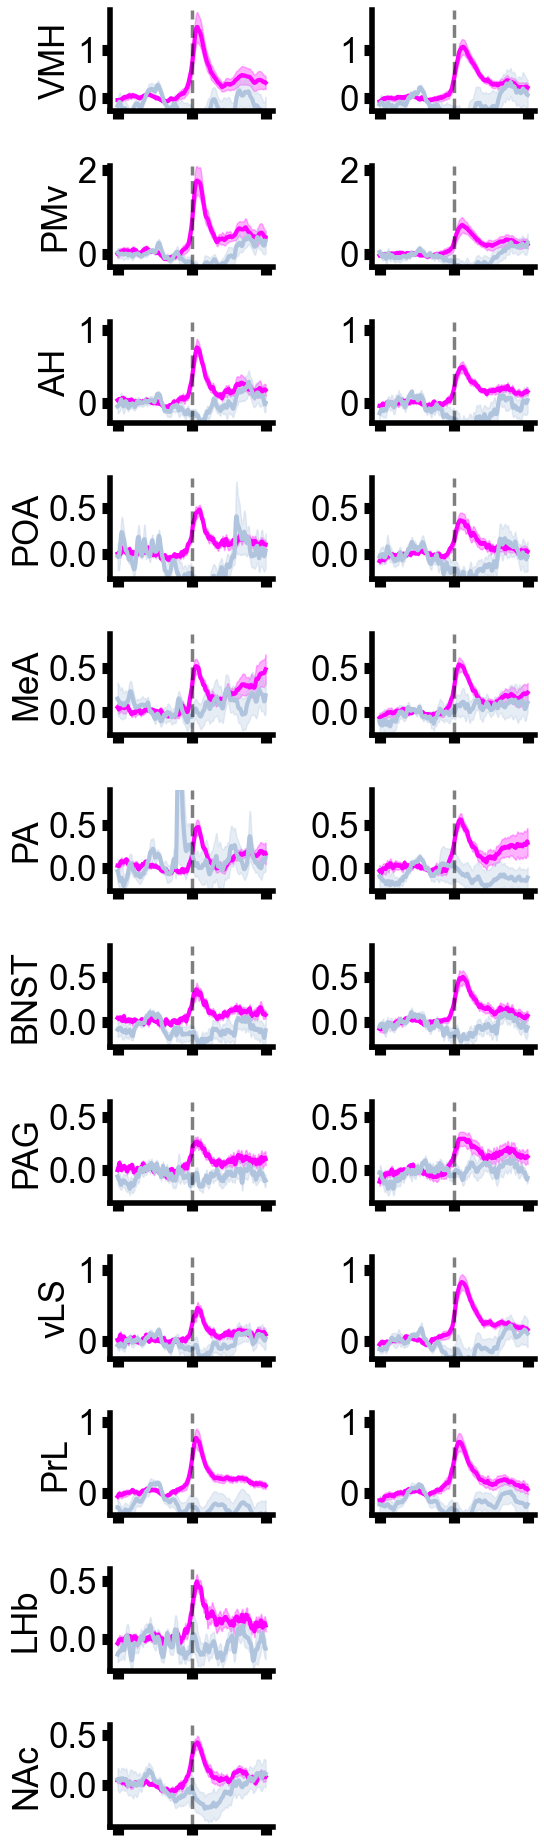

In [142]:
# plot individually averaged PETHs for OBS group

from matplotlib.ticker import MaxNLocator
periods = [80, 400]
# periods = [0, 320]
n = periods[1] - periods[0]

fig, ax = plt.subplots(12, 2, figsize=(6, 19))
sorting = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 22]
obs_color = 'magenta'
non_color='lightsteelblue'

for i, r in enumerate(sorting):
    try:

        # plot exc.
        obs_E = obs_peths[:, r, :] - np.nanmedian(obs_peths[baseline[0]:baseline[1], r, :], axis=0)
        non_E = faux_peths[:, r, :] - np.nanmedian(faux_peths[baseline[0]:baseline[1], r, :], axis=0)
        ax[i, 0].plot(np.nanmean(obs_E, axis=1)[periods[0]:periods[1]], label='obs', color=obs_color,
        linewidth=3)
        ax[i, 0].fill_between(range(n), np.nanmean(obs_E, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_peths.shape[2]),
        np.nanmean(obs_E, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_peths.shape[2]), alpha=0.3, color=obs_color)
        ax[i, 0].plot(np.nanmean(non_E, axis=1)[periods[0]:periods[1]], label='non', color=non_color,
        linewidth=3)
        ax[i, 0].fill_between(range(n), np.nanmean(non_E, axis=1)[periods[0]:periods[1]] - np.nanstd(non_E, axis=1)[periods[0]:periods[1]]/np.sqrt(faux_peths.shape[2]),
        np.nanmean(non_E, axis=1)[periods[0]:periods[1]] + np.nanstd(non_E, axis=1)[periods[0]:periods[1]]/np.sqrt(faux_peths.shape[2]), alpha=0.3, color=non_color)
        ax[i, 0].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 0].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # plot inh.
        obs_I = obs_peths[:, r+1, :] - np.nanmedian(obs_peths[baseline[0]:baseline[1], r+1, :], axis=0)
        non_I = faux_peths[:, r+1, :] - np.nanmedian(faux_peths[baseline[0]:baseline[1], r+1, :], axis=0)
        ax[i, 1].plot(np.nanmean(obs_I, axis=1)[periods[0]:periods[1]], label='obs', color=obs_color,
        linewidth=3)
        ax[i, 1].fill_between(range(n), np.nanmean(obs_I, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_I.shape[1]),
        np.nanmean(obs_I, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_I.shape[1]), alpha=0.3, color=obs_color)
        ax[i, 1].plot(np.nanmean(non_I, axis=1)[periods[0]:periods[1]], label='non', color=non_color,
        linewidth=3)
        ax[i, 1].fill_between(range(n), np.nanmean(non_I, axis=1)[periods[0]:periods[1]] - np.nanstd(non_I, axis=1)[periods[0]:periods[1]]/np.sqrt(non_I.shape[1]),
        np.nanmean(non_I, axis=1)[periods[0]:periods[1]] + np.nanstd(non_I, axis=1)[periods[0]:periods[1]]/np.sqrt(non_I.shape[1]), alpha=0.3, color=non_color)
        ax[i, 1].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 1].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # fix y scaling
        max1 = np.nanmean(obs_E, axis=1)[periods[0]:periods[1]].max()
        max2 = np.nanmean(obs_I, axis=1)[periods[0]:periods[1]].max()
        min1 = np.nanmean(obs_E, axis=1)[periods[0]:periods[1]].min()
        min2 = np.nanmean(obs_I, axis=1)[periods[0]:periods[1]].min()
        ylim_top = max(max1, max2)
        ylim_bottom = min(min1, min2)
        ax[i, 0].set_ylim(bottom=ylim_bottom-0.2, top=ylim_top+0.35)
        ax[i, 1].set_ylim(bottom=ylim_bottom-0.2, top=ylim_top+0.35)
        ax[i, 0].set_ylabel(region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''), fontfamily='Arial')
        sns.despine()
    except IndexError:
        print('IndexError for region index:', r)

ax[11, 0].set_ylabel('NAc')
fig.delaxes(ax[11, 1])
fig.delaxes(ax[10, 1])
ax[11, 0].set_ylim(top=0.6)
ax[10, 0].set_ylim(top=0.6)
fig.subplots_adjust(wspace=0.7, hspace=0.25)
plt.tight_layout()
# plt.savefig('./figures/ext_fig2/faux_PETHs.svg', dpi=300)


In [143]:
rows = []
for i, r in enumerate(sorting):
    try:
        region_label = region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        obs_slice  = (obs_peths[:, r, :]  - np.nanmedian(obs_peths[baseline[0]:baseline[1], r, :], axis=0))[periods[0]:periods[1], :]
        faux_slice = (faux_peths[:, r, :] - np.nanmedian(faux_peths[baseline[0]:baseline[1], r, :], axis=0))[periods[0]:periods[1], :]

        obs_mean  = np.nanmean(obs_slice, axis=1)
        obs_sem   = np.nanstd(obs_slice, axis=1) / np.sqrt(obs_peths.shape[2])
        faux_mean = np.nanmean(faux_slice, axis=1)
        faux_sem  = np.nanstd(faux_slice, axis=1) / np.sqrt(faux_peths.shape[2])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'E', 'timepoint': t,
                'obs_mean': obs_mean[t], 'obs_sem': obs_sem[t],
                'faux_mean': faux_mean[t], 'faux_sem': faux_sem[t],
            }
            for a in range(obs_slice.shape[1]):
                row[f'obs_animal_{a}'] = obs_slice[t, a]
            for a in range(faux_slice.shape[1]):
                row[f'faux_animal_{a}'] = faux_slice[t, a]
            rows.append(row)

    except IndexError:
        print('IndexError for region index:', r)

sourceData_ED6d_left = pd.DataFrame(rows)
sourceData_ED6d_left.to_csv('./sourceData/ED6d_left.csv', index=False)

IndexError for region index: 22


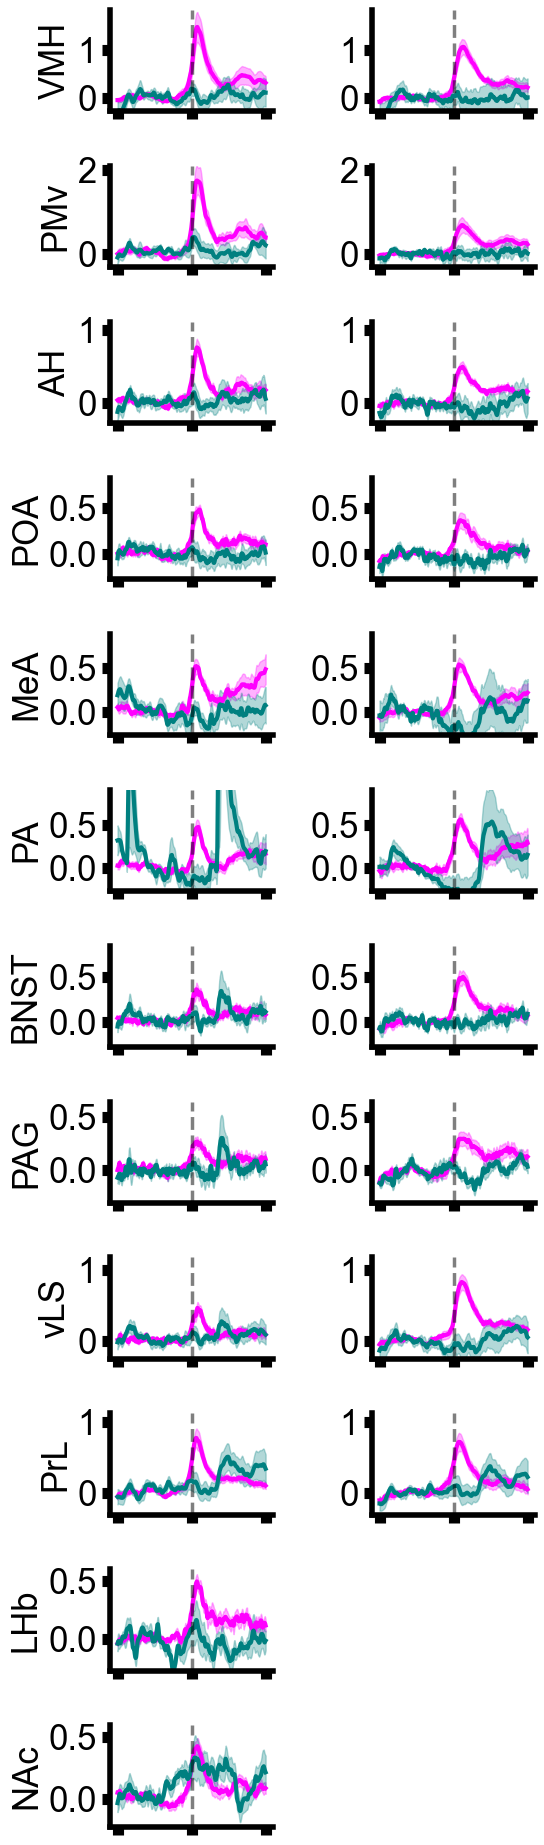

In [144]:
# Plot animal-by-animal PETHs for OBS vs SPD groups

from matplotlib.ticker import MaxNLocator
periods = [80, 400]
# periods = [0, 320]
n = periods[1] - periods[0]

fig, ax = plt.subplots(12, 2, figsize=(6, 19))
sorting = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 22]
obs_color = 'magenta'
non_color='teal'

for i, r in enumerate(sorting):
    try:

        # plot exc.
        obs_E = obs_peths[:, r, :] - np.nanmedian(obs_peths[baseline[0]:baseline[1], r, :], axis=0)
        non_E = spd_peths[:, r, :] - np.nanmedian(spd_peths[baseline[0]:baseline[1], r, :], axis=0)
        ax[i, 0].plot(np.nanmean(obs_E, axis=1)[periods[0]:periods[1]], label='obs', color=obs_color,
        linewidth=3)
        ax[i, 0].fill_between(range(n), np.nanmean(obs_E, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_peths.shape[2]),
        np.nanmean(obs_E, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_peths.shape[2]), alpha=0.3, color=obs_color)
        ax[i, 0].plot(np.nanmean(non_E, axis=1)[periods[0]:periods[1]], label='non', color=non_color,
        linewidth=3)
        ax[i, 0].fill_between(range(n), np.nanmean(non_E, axis=1)[periods[0]:periods[1]] - np.nanstd(non_E, axis=1)[periods[0]:periods[1]]/np.sqrt(spd_peths.shape[2]),
        np.nanmean(non_E, axis=1)[periods[0]:periods[1]] + np.nanstd(non_E, axis=1)[periods[0]:periods[1]]/np.sqrt(spd_peths.shape[2]), alpha=0.3, color=non_color)
        ax[i, 0].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 0].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # plot inh.
        obs_I = obs_peths[:, r+1, :] - np.nanmedian(obs_peths[baseline[0]:baseline[1], r+1, :], axis=0)
        non_I = spd_peths[:, r+1, :] - np.nanmedian(spd_peths[baseline[0]:baseline[1], r+1, :], axis=0)
        ax[i, 1].plot(np.nanmean(obs_I, axis=1)[periods[0]:periods[1]], label='obs', color=obs_color,
        linewidth=3)
        ax[i, 1].fill_between(range(n), np.nanmean(obs_I, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_I.shape[1]),
        np.nanmean(obs_I, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_I.shape[1]), alpha=0.3, color=obs_color)
        ax[i, 1].plot(np.nanmean(non_I, axis=1)[periods[0]:periods[1]], label='non', color=non_color,
        linewidth=3)
        ax[i, 1].fill_between(range(n), np.nanmean(non_I, axis=1)[periods[0]:periods[1]] - np.nanstd(non_I, axis=1)[periods[0]:periods[1]]/np.sqrt(non_I.shape[1]),
        np.nanmean(non_I, axis=1)[periods[0]:periods[1]] + np.nanstd(non_I, axis=1)[periods[0]:periods[1]]/np.sqrt(non_I.shape[1]), alpha=0.3, color=non_color)
        ax[i, 1].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 1].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])

        # fix y scaling
        max1 = np.nanmean(obs_E, axis=1)[periods[0]:periods[1]].max()
        max2 = np.nanmean(obs_I, axis=1)[periods[0]:periods[1]].max()
        min1 = np.nanmean(obs_E, axis=1)[periods[0]:periods[1]].min()
        min2 = np.nanmean(obs_I, axis=1)[periods[0]:periods[1]].min()
        ylim_top = max(max1, max2)
        ylim_bottom = min(min1, min2)
        ax[i, 0].set_ylim(bottom=ylim_bottom-0.2, top=ylim_top+0.35)
        ax[i, 1].set_ylim(bottom=ylim_bottom-0.2, top=ylim_top+0.35)
        ax[i, 0].set_ylabel(region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''), fontfamily='Arial')
        sns.despine()
    except IndexError:
        print('IndexError for region index:', r)

ax[11, 0].set_ylabel('NAc')
fig.delaxes(ax[11, 1])
fig.delaxes(ax[10, 1])
ax[11, 0].set_ylim(top=0.6)
ax[10, 0].set_ylim(top=0.6)
fig.subplots_adjust(wspace=0.7, hspace=0.25)
plt.tight_layout()
# plt.savefig('./figures/ext_fig2/spd_PETHs.svg', dpi=300)


In [145]:
rows = []
for i, r in enumerate(sorting[:10]):
    try:
        region_label = region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        obs_slice = (obs_peths[:, r+1, :] - np.nanmedian(obs_peths[baseline[0]:baseline[1], r+1, :], axis=0))[periods[0]:periods[1], :]
        spd_slice = (spd_peths[:, r+1, :] - np.nanmedian(spd_peths[baseline[0]:baseline[1], r+1, :], axis=0))[periods[0]:periods[1], :]

        obs_mean = np.nanmean(obs_slice, axis=1)
        obs_sem  = np.nanstd(obs_slice, axis=1) / np.sqrt(obs_slice.shape[1])
        spd_mean = np.nanmean(spd_slice, axis=1)
        spd_sem  = np.nanstd(spd_slice, axis=1) / np.sqrt(spd_slice.shape[1])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'I', 'timepoint': t,
                'obs_mean': obs_mean[t], 'obs_sem': obs_sem[t],
                'spd_mean': spd_mean[t], 'spd_sem': spd_sem[t],
            }
            for a in range(obs_slice.shape[1]):
                row[f'obs_animal_{a}'] = obs_slice[t, a]
            for a in range(spd_slice.shape[1]):
                row[f'spd_animal_{a}'] = spd_slice[t, a]
            rows.append(row)

    except IndexError:
        print('IndexError for region index:', r)

sourceData_ED6d_right = pd.DataFrame(rows)
sourceData_ED6d_right.to_csv('./sourceData/ED6d_right.csv', index=False)

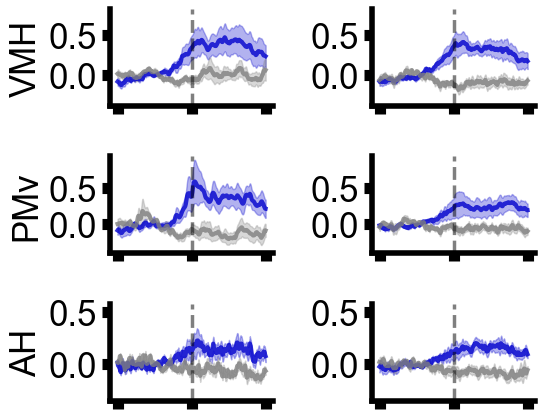

In [146]:
# Examples of ATTN+ vs ATTN- signals; just first three

# Plot unshifted attended vs non-attended PETHs for OBS group — VMHvl, PMv, AH only
from matplotlib.ticker import MaxNLocator
periods = [80, 400]
n = periods[1] - periods[0]

sorting = [12, 16, 8]  # VMHvl, PMv, AH

fig, ax = plt.subplots(3, 2, figsize=(6, 4.75))
early_color = 'mediumblue'
late_color = 'gray'

for i, r in enumerate(sorting):
    try:
        # plot exc.
        obs_attn_E = unshifted_attn_obs_peths[:, r, :] - np.nanmedian(unshifted_attn_obs_peths[baseline[0]:baseline[1], r, :], axis=0)
        obs_nonattn_E = unshifted_nonattn_obs_peths[:, r, :] - np.nanmedian(unshifted_nonattn_obs_peths[baseline[0]:baseline[1], r, :], axis=0)

        ax[i, 0].plot(np.nanmean(obs_attn_E, axis=1)[periods[0]:periods[1]],
                     color=early_color, linewidth=3, alpha=0.8)
        ax[i, 0].fill_between(range(n),
                             np.nanmean(obs_attn_E, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_attn_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_attn_E.shape[1]),
                             np.nanmean(obs_attn_E, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_attn_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_attn_E.shape[1]),
                             alpha=0.3, color=early_color)

        ax[i, 0].plot(np.nanmean(obs_nonattn_E, axis=1)[periods[0]:periods[1]],
                     color=late_color, linewidth=3, alpha=0.8)
        ax[i, 0].fill_between(range(n),
                             np.nanmean(obs_nonattn_E, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_nonattn_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_nonattn_E.shape[1]),
                             np.nanmean(obs_nonattn_E, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_nonattn_E, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_nonattn_E.shape[1]),
                             alpha=0.3, color=late_color)

        ax[i, 0].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 0].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])
        for label in ax[i, 0].get_xticklabels() + ax[i, 0].get_yticklabels():
            label.set_fontfamily('Arial')

        # plot inh.
        obs_attn_I = unshifted_attn_obs_peths[:, r+1, :] - np.nanmedian(unshifted_attn_obs_peths[baseline[0]:baseline[1], r+1, :], axis=0)
        obs_nonattn_I = unshifted_nonattn_obs_peths[:, r+1, :] - np.nanmedian(unshifted_nonattn_obs_peths[baseline[0]:baseline[1], r+1, :], axis=0)

        ax[i, 1].plot(np.nanmean(obs_attn_I, axis=1)[periods[0]:periods[1]],
                     color=early_color, linewidth=3, alpha=0.8)
        ax[i, 1].fill_between(range(n),
                             np.nanmean(obs_attn_I, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_attn_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_attn_I.shape[1]),
                             np.nanmean(obs_attn_I, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_attn_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_attn_I.shape[1]),
                             alpha=0.3, color=early_color)

        ax[i, 1].plot(np.nanmean(obs_nonattn_I, axis=1)[periods[0]:periods[1]],
                     color=late_color, linewidth=3, alpha=0.8)
        ax[i, 1].fill_between(range(n),
                             np.nanmean(obs_nonattn_I, axis=1)[periods[0]:periods[1]] - np.nanstd(obs_nonattn_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_nonattn_I.shape[1]),
                             np.nanmean(obs_nonattn_I, axis=1)[periods[0]:periods[1]] + np.nanstd(obs_nonattn_I, axis=1)[periods[0]:periods[1]]/np.sqrt(obs_nonattn_I.shape[1]),
                             alpha=0.3, color=late_color)

        ax[i, 1].axvline(n/2, linestyle='--', color='black', alpha=0.5)
        ax[i, 1].set_xticks(np.arange(0, 480, 480/3), ['', '', ''])
        for label in ax[i, 1].get_xticklabels() + ax[i, 1].get_yticklabels():
            label.set_fontfamily('Arial')

        # fix y scaling
        max1 = max(np.nanmean(obs_attn_E, axis=1)[periods[0]:periods[1]].max(),
                   np.nanmean(obs_nonattn_E, axis=1)[periods[0]:periods[1]].max())
        max2 = max(np.nanmean(obs_attn_I, axis=1)[periods[0]:periods[1]].max(),
                   np.nanmean(obs_nonattn_I, axis=1)[periods[0]:periods[1]].max())
        min1 = min(np.nanmean(obs_attn_E, axis=1)[periods[0]:periods[1]].min(),
                   np.nanmean(obs_nonattn_E, axis=1)[periods[0]:periods[1]].min())
        min2 = min(np.nanmean(obs_attn_I, axis=1)[periods[0]:periods[1]].min(),
                   np.nanmean(obs_nonattn_I, axis=1)[periods[0]:periods[1]].min())
        ylim_top = max(max1, max2)
        ylim_bottom = min(min1, min2)
        ax[i, 0].set_ylim(bottom=ylim_bottom-0.2, top=ylim_top+0.35)
        ax[i, 1].set_ylim(bottom=ylim_bottom-0.2, top=ylim_top+0.35)
        ax[i, 0].set_ylabel(region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''), fontfamily='Arial')

        sns.despine()
    except IndexError:
        print('IndexError for region index:', r)

fig.subplots_adjust(wspace=0.7, hspace=0.25)
plt.tight_layout()
# plt.savefig('./figures/fig2/attn_vs_noattn_PETHs.svg', dpi=300)
plt.show()

In [147]:
rows = []
for i, r in enumerate(sorting):  # VMHvl, PMv, AH
    try:
        region_label = region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        attn_slice_E    = (unshifted_attn_obs_peths[:, r, :]    - np.nanmedian(unshifted_attn_obs_peths[baseline[0]:baseline[1], r, :], axis=0))[periods[0]:periods[1], :]
        nonattn_slice_E = (unshifted_nonattn_obs_peths[:, r, :] - np.nanmedian(unshifted_nonattn_obs_peths[baseline[0]:baseline[1], r, :], axis=0))[periods[0]:periods[1], :]

        attn_mean_E    = np.nanmean(attn_slice_E, axis=1)
        attn_sem_E     = np.nanstd(attn_slice_E, axis=1) / np.sqrt(attn_slice_E.shape[1])
        nonattn_mean_E = np.nanmean(nonattn_slice_E, axis=1)
        nonattn_sem_E  = np.nanstd(nonattn_slice_E, axis=1) / np.sqrt(nonattn_slice_E.shape[1])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'E', 'timepoint': t,
                'attended_mean': attn_mean_E[t], 'attended_sem': attn_sem_E[t],
                'nonattended_mean': nonattn_mean_E[t], 'nonattended_sem': nonattn_sem_E[t],
            }
            for a in range(attn_slice_E.shape[1]):
                row[f'attended_animal_{a}'] = attn_slice_E[t, a]
            for a in range(nonattn_slice_E.shape[1]):
                row[f'nonattended_animal_{a}'] = nonattn_slice_E[t, a]
            rows.append(row)

        attn_slice_I    = (unshifted_attn_obs_peths[:, r+1, :]    - np.nanmedian(unshifted_attn_obs_peths[baseline[0]:baseline[1], r+1, :], axis=0))[periods[0]:periods[1], :]
        nonattn_slice_I = (unshifted_nonattn_obs_peths[:, r+1, :] - np.nanmedian(unshifted_nonattn_obs_peths[baseline[0]:baseline[1], r+1, :], axis=0))[periods[0]:periods[1], :]

        attn_mean_I    = np.nanmean(attn_slice_I, axis=1)
        attn_sem_I     = np.nanstd(attn_slice_I, axis=1) / np.sqrt(attn_slice_I.shape[1])
        nonattn_mean_I = np.nanmean(nonattn_slice_I, axis=1)
        nonattn_sem_I  = np.nanstd(nonattn_slice_I, axis=1) / np.sqrt(nonattn_slice_I.shape[1])

        for t in range(n):
            row = {
                'region': region_label, 'channel': 'I', 'timepoint': t,
                'attended_mean': attn_mean_I[t], 'attended_sem': attn_sem_I[t],
                'nonattended_mean': nonattn_mean_I[t], 'nonattended_sem': nonattn_sem_I[t],
            }
            for a in range(attn_slice_I.shape[1]):
                row[f'attended_animal_{a}'] = attn_slice_I[t, a]
            for a in range(nonattn_slice_I.shape[1]):
                row[f'nonattended_animal_{a}'] = nonattn_slice_I[t, a]
            rows.append(row)

    except IndexError:
        print('IndexError for region index:', r)

sourceData_2h = pd.DataFrame(rows)
sourceData_2h.to_csv('./sourceData/2h.csv', index=False)

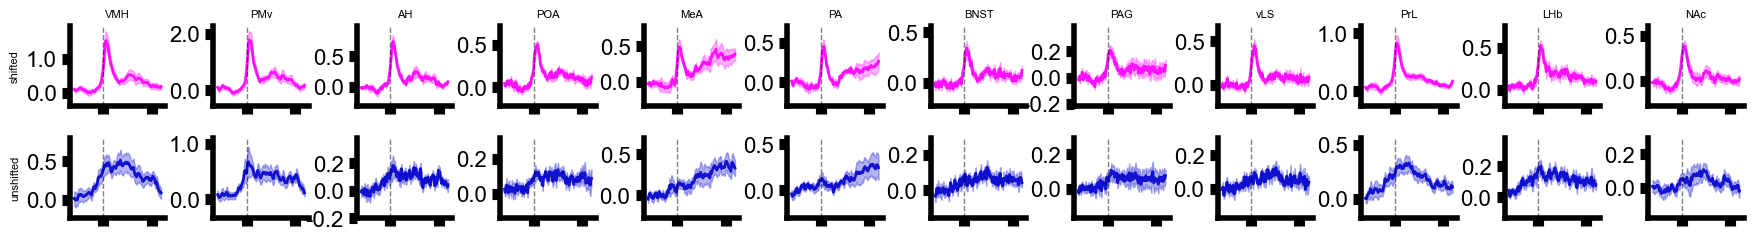

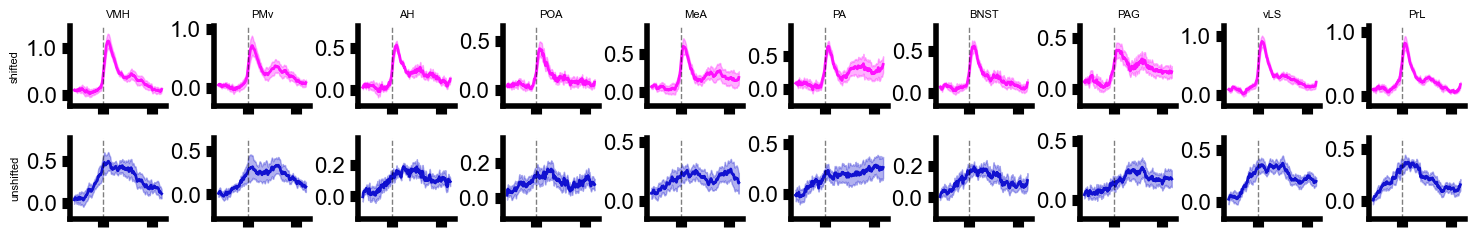

In [237]:
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
periods = [120, -1]                        
baseline = [0, 120]
n = obs_peths.shape[0] - periods[0]  

# ── Zero out noisy MeA E and PA E for last two subjects (indices 7, 8) ────────
mea_e_idx = region_ids.index('MeA (E)')
pa_e_idx  = region_ids.index('PA (E)')

unshifted_attn_obs_peths[:, mea_e_idx, 7] = np.nan
unshifted_attn_obs_peths[:, mea_e_idx, 8] = np.nan
unshifted_attn_obs_peths[:, pa_e_idx,  7] = np.nan
unshifted_attn_obs_peths[:, pa_e_idx,  8] = np.nan

shifted_color   = 'magenta'
unshifted_color = 'mediumblue'

sorting   = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18, 22]
sorting_I = [13, 17, 9, 5, 11, 21, 7, 15, 3, 1]

for plot_type, sort_idx in [('E_DA', sorting), ('I', sorting_I)]:
    n_regions = len(sort_idx)
    fig, ax   = plt.subplots(2, n_regions, figsize=(n_regions * 1.8, 2.5))

    for i, r in enumerate(sort_idx):
        for row, (peth, label, color) in enumerate([
            (obs_peths,                'shifted',   shifted_color),
            (unshifted_attn_obs_peths, 'unshifted', unshifted_color),
        ]):
            try:
                data = peth[:, r, :] - np.nanmedian(peth[baseline[0]:baseline[1], r, :], axis=0)
                mean = np.nanmean(data, axis=1)[periods[0]:]   # FIX 2: slice from 200 to end
                sem  = np.nanstd(data,  axis=1)[periods[0]:] / np.sqrt(data.shape[1])

                ax[row, i].plot(mean, color=color, linewidth=2, alpha=0.9, label=label)
                ax[row, i].fill_between(range(n), mean - sem, mean + sem,
                                        alpha=0.3, color=color)
                ax[row, i].axvline(120, linestyle='--', color='black', alpha=0.5, linewidth=1)
                ax[row, i].set_xticks([120, 320], ['', ''])

                ax[row, i].set_ylim(bottom=mean.min() - sem.max() - 0.1,
                                    top=mean.max()  + sem.max() + 0.15)

                if row == 0:
                    ax[row, i].set_title(
                        region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''),
                        fontsize=8, fontfamily='Arial'
                    )
                if i == 0:
                    ax[row, i].set_ylabel(label, fontsize=8, fontfamily='Arial')

                for tick in ax[row, i].get_xticklabels() + ax[row, i].get_yticklabels():
                    tick.set_fontfamily('Arial')
                    tick.set_fontsize(16)    # FIX 1: increased from 7

                ax[row, i].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # 1 decimal place

                for tick in ax[row, i].get_xticklabels() + ax[row, i].get_yticklabels():
                    tick.set_fontfamily('Arial')
                    tick.set_fontsize(16)
                sns.despine(ax=ax[row, i])

            except IndexError:
                print(f'IndexError: r={r}, row={row}')
                ax[row, i].axis('off')

        fig.subplots_adjust(wspace=0.5, hspace=0.4)
        # plt.savefig('.\\figures\\fig2\\unshifted_vs_shifted_%s.svg' % plot_type, dpi=300)
    # plt.tight_layout()
    plt.show()
    plt.close(fig)

In [241]:
from scipy.stats import ttest_1samp, wilcoxon, shapiro
from statsmodels.stats.multitest import multipletests

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '#'
    return 'ns'

# ── Parameters ────────────────────────────────────────────────────────────────
post_window  = (240, 360)   # frames post-attack onset — adjust to match your windo
baseline     = (0, 120)    # same baseline used in plotting

def test_against_zero(peth, region_idx, post_window, baseline, label=''):
    """
    For each animal (axis=1), compute mean activity in post_window
    after baseline correction. Test whether the distribution across
    animals differs from 0 (two-sided).
    Returns stat, p, mean, sem, test_type, df.
    """
    data = peth[:, region_idx, :] - \
           np.nanmedian(peth[baseline[0]:baseline[1], region_idx, :], axis=0)

    animal_means = np.nanmean(data[post_window[0]:post_window[1], :], axis=0)
    animal_means = animal_means[~np.isnan(animal_means)]

    if len(animal_means) < 3:
        return np.nan, np.nan, np.nan, np.nan, 'n/a', np.nan

    mean = np.nanmean(animal_means)
    sem  = np.nanstd(animal_means, ddof=1) / np.sqrt(len(animal_means))

    _, p_norm = shapiro(animal_means)
    if p_norm > 0.05:
        stat, p   = ttest_1samp(animal_means, popmean=0)   # two-sided by default
        test_type = 't-test vs 0 (two-sided)'
        df        = len(animal_means) - 1
    else:
        stat, p   = wilcoxon(animal_means)                  # two-sided by default
        test_type = 'Wilcoxon vs 0 (two-sided)'
        df        = np.nan   # Wilcoxon has no df

    return stat, p, mean, sem, test_type, df


# ── Run for both shifted and unshifted, all regions ───────────────────────────
for plot_type, sort_idx, peth_label in [
    ('E_DA', sorting,   'E/DA regions'),
    ('I',    sorting_I, 'I regions'),
]:
    print(f'\n{"="*75}')
    print(f'{peth_label} — post-attack response vs 0  (window {post_window})')
    print(f'{"="*75}')

    for peth, signal_label in [
        (obs_peths,                'shifted'),
        (unshifted_attn_obs_peths, 'unshifted'),
    ]:
        # ── collect raw p-values ───────────────────────────────────────────────
        records = []
        for r in sort_idx:
            stat, p, mean, sem, test_type, df = test_against_zero(
                peth, r, post_window, baseline, label=signal_label)
            records.append({
                'region':    region_ids[r],
                'stat':      stat,
                'p_raw':     p,
                'mean':      mean,
                'sem':       sem,
                'test_type': test_type,
                'df':        df,
            })

        # ── FDR correction across regions ─────────────────────────────────────
        valid_idx = [i for i, r in enumerate(records) if not np.isnan(r['p_raw'])]
        if valid_idx:
            _, p_fdr, _, _ = multipletests(
                [records[i]['p_raw'] for i in valid_idx], method='fdr_bh')
            for rank, i in enumerate(valid_idx):
                records[i]['p_fdr'] = p_fdr[rank]
        for r in records:
            if 'p_fdr' not in r:
                r['p_fdr'] = np.nan

        # ── Print table ───────────────────────────────────────────────────────
        print(f'\n── {signal_label} ──')
        print(f'  {"Region":<25} {"Test":<24} {"Stat":>8} {"df":>6} {"p_raw":>12} '
              f'{"p_fdr":>12} {"Sig":>5} {"Mean":>8} {"SEM":>8}')
        print(f'  {"─"*105}')
        for r in records:
            sig    = get_sig(r['p_fdr']) if not np.isnan(r['p_fdr']) else 'n/a'
            df_str = f'{r["df"]:.0f}' if not np.isnan(r['df']) else 'n/a'
            print(f'  {r["region"]:<25} {r["test_type"]:<24} '
                  f'{r["stat"]:>8.3f} {df_str:>6} {fmt_p(r["p_raw"]):>12} '
                  f'{fmt_p(r["p_fdr"]):>12} {sig:>5} '
                  f'{r["mean"]:>8.3f} {r["sem"]:>8.3f}')


E/DA regions — post-attack response vs 0  (window (240, 360))

── shifted ──
  Region                    Test                         Stat     df        p_raw        p_fdr   Sig     Mean      SEM
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
  VMH (E)                   t-test vs 0 (two-sided)     5.001      8       0.0011       0.0033    **    0.658    0.132
  PMv (E)                   Wilcoxon vs 0 (two-sided)    0.000    n/a       0.0039       0.0059    **    0.753    0.138
  AH (E)                    t-test vs 0 (two-sided)     4.099      6       0.0064       0.0085    **    0.265    0.065
  POA (E)                   t-test vs 0 (two-sided)     7.262      8    8.704e-05       0.0010    **    0.220    0.030
  MeA (E)                   t-test vs 0 (two-sided)     3.612      6       0.0112       0.0134     *    0.222    0.061
  PA (E)                    t-test vs 0 (two-sided)     4.909      6       0.0027       0.0046    *

In [150]:
n_trace = obs_peths.shape[0] - periods[0]
stats_lookup = {}

for plot_type, sort_idx in [('E_DA', sorting), ('I', sorting_I)]:
    for peth, signal_label in [(obs_peths, 'shifted'), (unshifted_attn_obs_peths, 'unshifted')]:
        records = []
        for r in sort_idx:
            stat, p, mean, sem, test_type = test_against_zero(peth, r, post_window, baseline, label=signal_label)
            records.append({'region_idx': r, 'stat': stat, 'p_raw': p, 'post_mean': mean, 'post_sem': sem, 'test_type': test_type})
        valid_idx = [i for i, rec in enumerate(records) if not np.isnan(rec['p_raw'])]
        if valid_idx:
            _, p_fdr, _, _ = multipletests([records[i]['p_raw'] for i in valid_idx], method='fdr_bh')
            for rank, i in enumerate(valid_idx):
                records[i]['p_fdr'] = p_fdr[rank]
        for rec in records:
            if 'p_fdr' not in rec:
                rec['p_fdr'] = np.nan
        for rec in records:
            stats_lookup[(plot_type, signal_label, rec['region_idx'])] = rec

rows = []
for plot_type, sort_idx in [('E_DA', sorting), ('I', sorting_I)]:
    for i, r in enumerate(sort_idx):
        region_label = region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
        for peth, signal_label in [(obs_peths, 'shifted'), (unshifted_attn_obs_peths, 'unshifted')]:
            try:
                data_slice = (peth[:, r, :] - np.nanmedian(peth[baseline[0]:baseline[1], r, :], axis=0))[periods[0]:, :]
                mean = np.nanmean(data_slice, axis=1)
                sem  = np.nanstd(data_slice, axis=1) / np.sqrt(data_slice.shape[1])
                sr = stats_lookup[(plot_type, signal_label, r)]

                for t in range(n_trace):
                    row = {
                        'plot_type': plot_type, 'region': region_label, 'signal': signal_label, 'timepoint': t,
                        'trace_mean': mean[t], 'trace_sem': sem[t],
                        'post_window_test': sr['test_type'], 'post_window_stat': sr['stat'],
                        'post_window_p_raw': sr['p_raw'], 'post_window_p_fdr': sr['p_fdr'],
                        'post_window_mean': sr['post_mean'], 'post_window_sem': sr['post_sem'],
                    }
                    for a in range(data_slice.shape[1]):
                        row[f'animal_{a}'] = data_slice[t, a]
                    rows.append(row)
            except IndexError:
                print(f'IndexError: r={r}, signal={signal_label}')

sourceData_ED6b = pd.DataFrame(rows)
sourceData_ED6b.to_csv('./sourceData/ED6b.csv', index=False)

Examining decay across trials

In [45]:
from scipy.optimize import curve_fit
from scipy.stats import sem as scipy_sem, mannwhitneyu, ttest_ind, shapiro, levene
from statsmodels.stats.multitest import multipletests

# ---- Simple decay metrics: Delta, Time-to-Rest, Time-to-Baseline, Baseline-Rest Delta, Half-Decay ----

from scipy.ndimage import uniform_filter1d

def compute_decay_metrics(peths, region_idx, baseline, peak_window,
                          rest_window, settle_thresh=0.25, sustain=4):
    """
    For each subject's mean PETH:
      - Delta              = peak value - rest value
      - Time-to-rest       = frames from peak until signal settles near rest value
      - Time-to-baseline   = frames from peak until signal returns to ~0
      - Baseline-rest delta= rest period value relative to baseline-corrected zero
      - Half-decay time t½ = fractional frames from peak until signal reaches 50% of peak value

    Improvements vs previous version:
      - Linear interpolation for sub-frame precision on t½
      - Noise-relative threshold for near-zero peak detection (2 * baseline std)
      - NaN returned for non-decaying signals instead of maxing out at trace length
      - 3-frame smoothing for robust peak detection (value taken from unsmoothed trace)
      - NaN returned for t½ when peak is below noise floor
    """
    n_subjects         = peths.shape[2]
    deltas             = np.full(n_subjects, np.nan)
    time_to_rest       = np.full(n_subjects, np.nan)
    peak_vals          = np.full(n_subjects, np.nan)
    rest_vals          = np.full(n_subjects, np.nan)
    time_to_baseline   = np.full(n_subjects, np.nan)
    baseline_rest_delta= np.full(n_subjects, np.nan)
    half_decay         = np.full(n_subjects, np.nan)
    never_decayed      = np.zeros(n_subjects, dtype=bool)  # flag for non-decaying signals

    for s in range(n_subjects):
        trace = peths[:, region_idx, s]

        if np.any(np.isnan(trace)):
            continue

        # Baseline correction
        bl     = np.nanmedian(trace[baseline[0]:baseline[1]])
        bl_std = np.nanstd(trace[baseline[0]:baseline[1]])
        corrected = trace - bl

        # --- Peak detection with smoothing ---
        smoothed   = uniform_filter1d(corrected.astype(float), size=3)
        search_seg = smoothed[peak_window[0]:peak_window[1]]
        if np.all(np.isnan(search_seg)):
            continue
        peak_local = np.nanargmax(search_seg)
        peak_abs   = peak_window[0] + peak_local
        peak_val   = corrected[peak_abs]  # unsmoothed value at detected location

        if np.isnan(peak_val):
            continue

        # --- Noise-relative threshold: skip if peak not reliably above noise ---
        noise_threshold = 2 * bl_std
        if abs(peak_val) < noise_threshold:
            # Peak indistinguishable from noise — leave all metrics as NaN
            continue

        # Rest value
        rest_seg = corrected[rest_window[0]:rest_window[1]]
        if np.all(np.isnan(rest_seg)):
            continue
        rest_val = np.nanmean(rest_seg)

        delta                  = peak_val - rest_val
        deltas[s]              = delta
        peak_vals[s]           = peak_val
        rest_vals[s]           = rest_val
        baseline_rest_delta[s] = rest_val

        post_peak = corrected[peak_abs:]

        # ---- Time-to-rest ----
        if abs(delta) < noise_threshold:
            time_to_rest[s] = 0
        else:
            threshold = abs(delta) * settle_thresh
            found = False
            for i in range(len(post_peak) - sustain):
                window = post_peak[i:i + sustain]
                if np.all(~np.isnan(window)) and np.all(np.abs(window - rest_val) <= threshold):
                    time_to_rest[s] = i
                    found = True
                    break
            if not found:
                time_to_rest[s] = np.nan

        # ---- Time-to-baseline ----
        if abs(peak_val) < noise_threshold:
            time_to_baseline[s] = 0
        else:
            bl_threshold = abs(peak_val) * settle_thresh
            found = False
            for i in range(len(post_peak) - sustain):
                window = post_peak[i:i + sustain]
                if np.all(~np.isnan(window)) and np.all(np.abs(window) <= bl_threshold):
                    time_to_baseline[s] = i
                    found = True
                    break
            if not found:
                time_to_baseline[s] = np.nan

        # ---- Half-decay time t½ with linear interpolation ----
        half_target = peak_val / 2
        found = False
        for i in range(1, len(post_peak)):
            val = post_peak[i]
            if np.isnan(val):
                continue
            crossed = (peak_val > 0 and val <= half_target) or \
                    (peak_val < 0 and val >= half_target)
            if crossed:
                prev_val = post_peak[i - 1]
                if not np.isnan(prev_val) and prev_val != val:
                    # Linear interpolation for sub-frame precision
                    frac = (half_target - prev_val) / (val - prev_val)
                    half_decay[s] = (i - 1) + frac
                else:
                    half_decay[s] = float(i)
                found = True
                break
        if not found:
            # Signal never reached 50% of peak — flag and leave as max
            never_decayed[s] = True
            half_decay[s]    = 240

    return (deltas, time_to_rest, peak_vals, rest_vals,
            time_to_baseline, baseline_rest_delta, half_decay, never_decayed)

def choose_and_run_test_with_stat(a, b, alpha_normality=0.05, alpha_variance=0.05):
    """
    1) Normality (Shapiro, both groups)
    2) If both normal: variance check (Levene) -> t-test (equal_var if
       homogeneous, else Welch with Welch-Satterthwaite df)
    3) If not both normal: Brunner-Munzel. If BM statistic/p-value is
       non-finite (degenerate rank variance, typically from heavy ties /
       zero-inflation), fall back to Mann-Whitney U.
    Returns: p, stat, test_type, df
    """
    if len(a) >= 3 and len(b) >= 3:
        _, p_a = shapiro(a)
        _, p_b = shapiro(b)
        both_normal = (p_a > alpha_normality) and (p_b > alpha_normality)
    else:
        both_normal = False

    if both_normal:
        # ── variance check ──────────────────────────────────────────────────────
        _, p_levene = levene(a, b)
        equal_var = p_levene > alpha_variance

        stat, p = ttest_ind(a, b, alternative='two-sided', equal_var=equal_var)

        if equal_var:
            n1, n2 = len(a), len(b)
            df = n1 + n2 - 2
            test_type = 'Independent samples t-test'
        else:
            v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
            n1, n2 = len(a), len(b)
            df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
            test_type = "Welch's t-test"

        return p, stat, test_type, df

    else:
        stat, p = brunnermunzel(a, b, alternative='two-sided')

        if np.isnan(p):
            # ── degenerate Brunner-Munzel (zero rank-variance) — fall back to MWU ──
            stat, p = mannwhitneyu(a, b, alternative='two-sided')
            return p, stat, 'Mann-Whitney U (BM degenerate — fallback)', np.nan

        return p, stat, 'Brunner-Munzel', np.nan

def get_sig_marker(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# ---- Run across all regions ----
baseline          = [0, 80]
peak_search_window= [220, 260]
rest_window       = [440, 480]
n_regions         = 23

agg_deltas = {}; obs_deltas = {}
agg_ttr    = {}; obs_ttr    = {}
agg_ttb    = {}; obs_ttb    = {}
agg_brd    = {}; obs_brd    = {}
agg_thalf  = {}; obs_thalf  = {}

delta_pvals     = np.full(n_regions, np.nan)
ttr_pvals       = np.full(n_regions, np.nan)
ttb_pvals       = np.full(n_regions, np.nan)
brd_pvals       = np.full(n_regions, np.nan)
thalf_pvals     = np.full(n_regions, np.nan)
delta_test_used = [''] * n_regions
ttr_test_used   = [''] * n_regions
ttb_test_used   = [''] * n_regions
brd_test_used   = [''] * n_regions
thalf_test_used = [''] * n_regions

for roi in range(n_regions):
    ad, at, _, _, ab, abd, ah, nd_agg = compute_decay_metrics(
        agg_peths, roi, baseline, peak_search_window, rest_window)
    od, ot, _, _, ob, obd, oh, nd_obs = compute_decay_metrics(
        obs_peths, roi, baseline, peak_search_window, rest_window)
    
    agg_deltas[roi] = ad;  obs_deltas[roi] = od
    agg_ttr[roi]    = at;  obs_ttr[roi]    = ot
    agg_ttb[roi]    = ab;  obs_ttb[roi]    = ob
    agg_brd[roi]    = abd; obs_brd[roi]    = obd
    agg_thalf[roi]  = ah;  obs_thalf[roi]  = oh
    
    for (avals, ovals, pvals_arr, test_arr) in [
        (ad,  od,  delta_pvals,  delta_test_used),
        (at,  ot,  ttr_pvals,    ttr_test_used),
        (ab,  ob,  ttb_pvals,    ttb_test_used),
        (abd, obd, brd_pvals,    brd_test_used),
        (ah,  oh,  thalf_pvals,  thalf_test_used),
    ]:
        ac = avals[~np.isnan(avals)]
        oc = ovals[~np.isnan(ovals)]
        if len(ac) >= 3 and len(oc) >= 3:
            pvals_arr[roi], test_arr[roi], _, _ = choose_and_run_test_with_stat(ac, oc)

# ---- FDR correction ----
def fdr_correct(pvals):
    valid = ~np.isnan(pvals)
    corrected = np.full(len(pvals), np.nan)
    if valid.sum() > 0:
        _, corrected[valid], _, _ = multipletests(pvals[valid], method='fdr_bh')
    return corrected

delta_pvals_corrected = fdr_correct(delta_pvals)
ttr_pvals_corrected   = fdr_correct(ttr_pvals)
ttb_pvals_corrected   = fdr_correct(ttb_pvals)
brd_pvals_corrected   = fdr_correct(brd_pvals)
thalf_pvals_corrected = fdr_correct(thalf_pvals)

# ---- Compute means / SEMs ----
def mean_sem(d, n_regions):
    means = np.array([np.nanmean(d[r]) for r in range(n_regions)])
    sems  = np.array([scipy_sem(d[r][~np.isnan(d[r])]) 
                      if np.sum(~np.isnan(d[r])) > 1 else 0 
                      for r in range(n_regions)])
    return means, sems

agg_mean_delta, agg_sem_delta = mean_sem(agg_deltas, n_regions)
obs_mean_delta, obs_sem_delta = mean_sem(obs_deltas, n_regions)
agg_mean_ttr,   agg_sem_ttr   = mean_sem(agg_ttr,    n_regions)
obs_mean_ttr,   obs_sem_ttr   = mean_sem(obs_ttr,    n_regions)
agg_mean_ttb,   agg_sem_ttb   = mean_sem(agg_ttb,    n_regions)
obs_mean_ttb,   obs_sem_ttb   = mean_sem(obs_ttb,    n_regions)
agg_mean_brd,   agg_sem_brd   = mean_sem(agg_brd,    n_regions)
obs_mean_brd,   obs_sem_brd   = mean_sem(obs_brd,    n_regions)
agg_mean_thalf, agg_sem_thalf = mean_sem(agg_thalf,  n_regions)
obs_mean_thalf, obs_sem_thalf = mean_sem(obs_thalf,  n_regions)

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9485: RuntimeWarning: divide by zero encountered in double_scalars
  wbfn /= (nx + ny) * np.sqrt(nx * Sx + ny * Sy)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9491: RuntimeWarning: invalid value encountered in double_scalars
  df = df_numer / df_denom
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: p-value cannot be estimated with `distribution='t' because degrees of freedom parameter is undefined (0/0). Try using `distribution='normal'
  res = hypotest_fun_out(*samples, **kwds)


In [46]:
from scipy.stats import shapiro, levene, ttest_ind, brunnermunzel, mannwhitneyu

def build_thalf_stats_table_ordered(agg_thalf, obs_thalf, order_indices, region_ids,
                                     correction_label):
    """
    Rows ordered by order_indices (e.g. fixed_order for plot-matched
    display, or range(n_regions) for the full exhaustive set). E/I/DA
    channel identity is retained as an explicit column rather than
    stripped, since two channels at the same anatomical site are
    distinct signals and must not share an ambiguous row label.

    correction_label: string tag recorded per-row identifying which
    FDR family this table's p_fdr belongs to (e.g. 'fixed_order_n17'
    vs 'all_regions_n23') — so if both tables coexist, no one downstream
    conflates a p_fdr from one family with the other.
    """
    rows = []
    for roi in order_indices:
        raw_label = region_ids[roi]
        if '(E)' in raw_label:
            channel = 'E'
        elif '(I)' in raw_label:
            channel = 'I'
        elif '(DA)' in raw_label:
            channel = 'DA'
        else:
            channel = 'unlabeled'  # flags index 19-type cases explicitly
        clean_label = raw_label.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

        ac = agg_thalf[roi][~np.isnan(agg_thalf[roi])]
        oc = obs_thalf[roi][~np.isnan(obs_thalf[roi])]
        n_agg, n_obs = len(ac), len(oc)
        mean_agg = np.nanmean(ac) if n_agg > 0 else np.nan
        mean_obs = np.nanmean(oc) if n_obs > 0 else np.nan

        if n_agg >= 3 and n_obs >= 3:
            p_raw, stat, test_name, df = choose_and_run_test_with_stat(ac, oc)
        else:
            p_raw, stat, test_name, df = np.nan, np.nan, 'insufficient_n', np.nan

        rows.append({
            'population': clean_label, 'channel': channel,
            'region_idx': roi, 'comparison': 'AGG vs OBS',
            'statistical_test': test_name, 'stat': stat, 'df': df, 'p_raw': p_raw,
            'n_AGG': n_agg, 'n_OBS': n_obs,
            'mean_AGG': mean_agg, 'mean_OBS': mean_obs,
            'fdr_family': correction_label,
        })

    table = pd.DataFrame(rows)
    valid_p = table['p_raw'].notna()
    table['p_fdr'] = np.nan
    if valid_p.sum() > 0:
        _, p_fdr_vals, _, _ = multipletests(table.loc[valid_p, 'p_raw'], method='fdr_bh')
        table.loc[valid_p, 'p_fdr'] = p_fdr_vals
    table['sig'] = table['p_fdr'].apply(get_sig_marker)

    return table[['population', 'channel', 'region_idx', 'comparison',
                  'statistical_test', 'stat', 'df', 'p_raw', 'p_fdr', 'sig',
                  'n_AGG', 'n_OBS', 'mean_AGG', 'mean_OBS', 'fdr_family']]

build_thalf_stats_table_ordered(
    agg_thalf, obs_thalf, list(range(n_regions)), region_ids,
    correction_label='all_regions_n23'
)


,population,channel,region_idx,comparison,statistical_test,stat,df,p_raw,p_fdr,sig,n_AGG,n_OBS,mean_AGG,mean_OBS,fdr_family
0,PrL,E,0,AGG vs OBS,Brunner-Munzel,-3.857127,NaN,3.327380e-03,5.101982e-03,**,12,9,100.839096,38.793930,all_regions_n23
1,PrL,I,1,AGG vs OBS,Brunner-Munzel,-1.272431,NaN,2.209840e-01,2.209840e-01,,12,9,54.708248,47.505066,all_regions_n23
2,vLS,E,2,AGG vs OBS,Brunner-Munzel,-11.624764,NaN,1.181581e-08,1.235409e-07,***,12,9,53.487897,11.194560,all_regions_n23
3,vLS,I,3,AGG vs OBS,Brunner-Munzel,-1.606746,NaN,1.247855e-01,1.304575e-01,,12,9,63.474831,48.285052,all_regions_n23
4,POA,E,4,AGG vs OBS,Welch's t-test,4.022693,12.491695,1.564421e-03,2.767821e-03,**,12,9,52.044140,17.456617,all_regions_n23
5,POA,I,5,AGG vs OBS,Welch's t-test,3.540776,15.144103,2.926627e-03,4.808030e-03,**,12,9,69.738930,28.340125,all_regions_n23
6,BNST,E,6,AGG vs OBS,Welch's t-test,4.433052,13.112069,6.617841e-04,1.691226e-03,**,12,9,39.885448,11.053863,all_regions_n23
7,BNST,I,7,AGG vs OBS,Independent samples t-test,4.227997,19.000000,4.552932e-04,1.308968e-03,**,12,9,66.992519,28.862986,all_regions_n23
8,AH,E,8,AGG vs OBS,Brunner-Munzel,-3.939305,NaN,1.355195e-03,2.597456e-03,**,11,7,45.573619,15.241332,all_regions_n23
9,AH,I,9,AGG vs OBS,Mann-Whitney U (BM degenerate — fallback),99.000000,NaN,1.970942e-04,6.475951e-04,***,11,9,105.147835,29.069271,all_regions_n23


In [47]:
from scipy.stats import wilcoxon, ttest_rel

# ---- Region definitions ----
# Paired regions (E/I, no LHb): indices into region_ids
paired_E = [12, 16, 8,  4, 10, 20, 6, 14,  2,  0]  # VMHvl,PMv,AH,POA,MeA,PA,BNST,lPAG,vLS,PrL
paired_I = [13, 17, 9,  5, 11, 21, 7, 15,  3,  1]
paired_labels = ['VMHvl', 'PMv', 'AH', 'POA', 'MeA', 'PA', 'BNST', 'lPAG', 'vLS', 'PrL']

# Full fixed order for bar plots (including LHb and NAc)
excitatory_indices = [12, 16, 4, 8, 10, 20, 0, 18, 22]  # added LHb=18
inhibitory_indices = [13, 17, 9, 11, 21, 7,  3,  1]
fixed_order        = excitatory_indices + inhibitory_indices
region_labels      = np.array([x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '') for x in region_ids])
ranked_labels      = region_labels[fixed_order]

# ---- Shared plot helpers ----
def plot_bars(ax, agg_means, obs_means, agg_sems, obs_sems, fixed_order, scale=1.0):
    ax.bar(x_pos - bar_width / 2, agg_means[fixed_order] * scale, bar_width,
           yerr=agg_sems[fixed_order] * scale,
           color='darkorange', alpha=0.7, edgecolor='darkorange', linewidth=1.5,
           capsize=3, label='AGG', error_kw={'capthick': 2, 'elinewidth': 2})
    ax.bar(x_pos + bar_width / 2, obs_means[fixed_order] * scale, bar_width,
           yerr=obs_sems[fixed_order] * scale,
           color='magenta', alpha=0.7, edgecolor='magenta', linewidth=1.5,
           capsize=3, label='OBS', error_kw={'capthick': 2, 'elinewidth': 2})

def add_scatter(ax, fixed_order, agg_data, obs_data, seeds=(42, 43), scale=1.0):
    for plot_idx, r_idx in enumerate(fixed_order):
        agg_pts = agg_data[r_idx][~np.isnan(agg_data[r_idx])] * scale
        obs_pts = obs_data[r_idx][~np.isnan(obs_data[r_idx])] * scale
        if len(agg_pts) > 0:
            jitter = np.random.default_rng(seeds[0]).uniform(-0.06, 0.06, size=len(agg_pts))
            ax.scatter(np.full(len(agg_pts), plot_idx - bar_width / 2) + jitter,
                       agg_pts, color='black', s=12, alpha=0.5, zorder=5, linewidths=0.3)
        if len(obs_pts) > 0:
            jitter = np.random.default_rng(seeds[1]).uniform(-0.06, 0.06, size=len(obs_pts))
            ax.scatter(np.full(len(obs_pts), plot_idx + bar_width / 2) + jitter,
                       obs_pts, color='black', s=12, alpha=0.5, zorder=5, linewidths=0.3)

def add_sig_markers(ax, fixed_order, pvals_corrected):
    y_max = ax.get_ylim()[1]
    for plot_idx, r_idx in enumerate(fixed_order):
        marker = get_sig_marker(pvals_corrected[r_idx])
        if marker:
            x1 = plot_idx - bar_width / 2
            x2 = plot_idx + bar_width / 2
            ax.plot([x1, x2], [y_max, y_max], color='black', linewidth=1.2)
            ax.text((x1 + x2) / 2, y_max, marker, ha='center', va='bottom',
                    fontsize=12, fontweight='bold')

def format_xaxis(ax, ranked_labels, ranked_colors):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ranked_labels, fontsize=10, fontfamily='Arial', rotation=45, ha='right')
    for tick_label, color in zip(ax.get_xticklabels(), ranked_colors):
        tick_label.set_color(color)
        tick_label.set_fontweight('bold')

def get_fixed_color(idx):
    if idx == 22:
        return 'black'
    elif idx % 2 == 0:
        return 'seagreen'
    else:
        return 'lightskyblue'

ranked_colors      = [get_fixed_color(r) for r in fixed_order]
x_pos              = np.arange(len(fixed_order))
bar_width          = 0.35

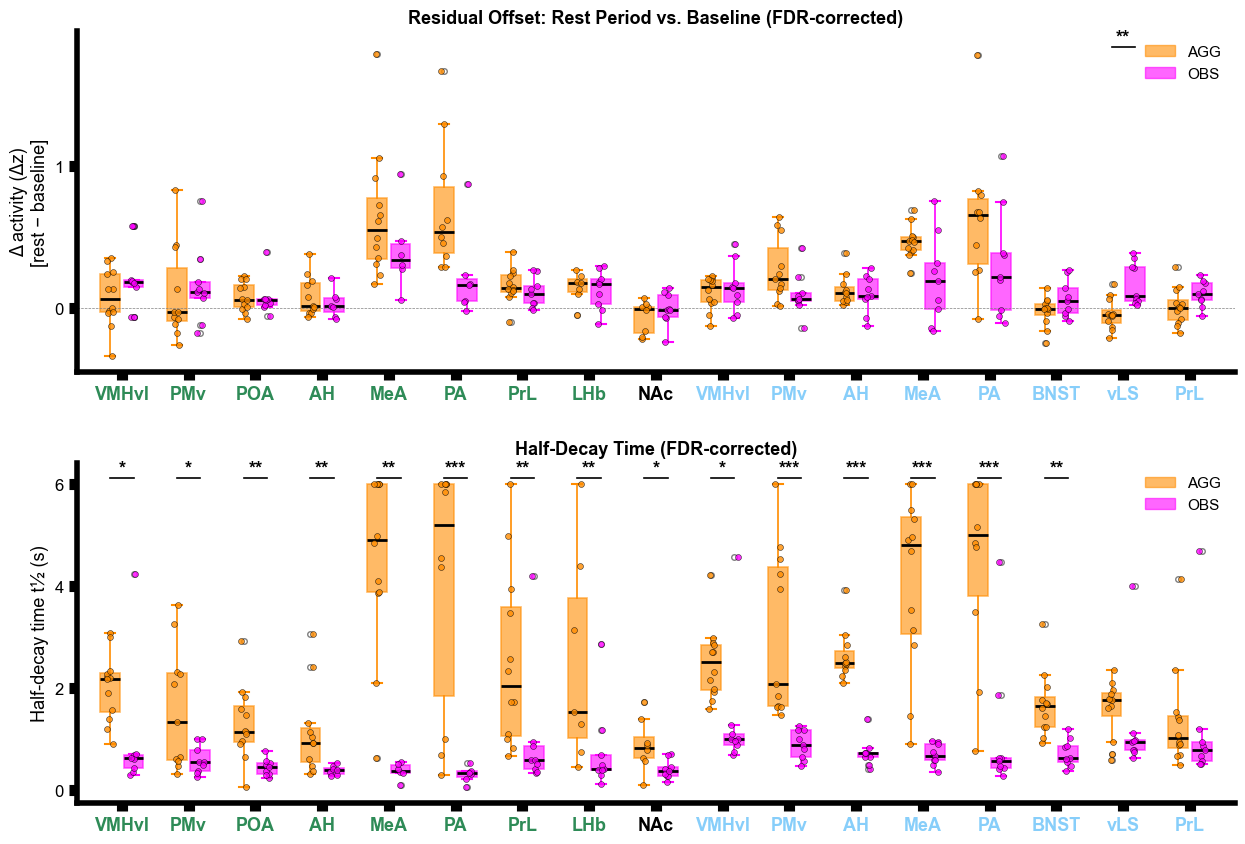

In [48]:
# EXP/OBS comparisons

import matplotlib
from scipy.stats import wilcoxon, ttest_rel
matplotlib.rcParams['font.family'] = 'Arial'

np.random.seed(42)  # for reproducible jitter in scatter plots

# ---- Region definitions ----
# Paired regions (E/I, no LHb): indices into region_ids
paired_E = [12, 16, 8,  4, 10, 20, 6, 14,  2,  0]  # VMHvl,PMv,AH,POA,MeA,PA,BNST,lPAG,vLS,PrL
paired_I = [13, 17, 9,  5, 11, 21, 7, 15,  3,  1]
paired_labels = ['VMHvl', 'PMv', 'AH', 'POA', 'MeA', 'PA', 'BNST', 'lPAG', 'vLS', 'PrL']

# Full fixed order for bar plots (including LHb and NAc)
excitatory_indices = [12, 16, 4, 8, 10, 20, 0, 18, 22]  # added LHb=18
inhibitory_indices = [13, 17, 9, 11, 21, 7,  3,  1]
fixed_order        = excitatory_indices + inhibitory_indices
region_labels      = np.array([x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '').replace('VMH', 'VMHvl').replace('PAG', 'lPAG') for x in region_ids])
ranked_labels      = region_labels[fixed_order]
ranked_colors      = [get_fixed_color(r) for r in fixed_order]
x_pos              = np.arange(len(fixed_order))
bar_width          = 0.35

def format_xaxis_dots(ax, ranked_labels, ranked_colors, fontsize=13):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ranked_labels, fontsize=fontsize, fontfamily='Arial',
                       rotation=0, ha='center')
    for tick_label, color in zip(ax.get_xticklabels(), ranked_colors):
        tick_label.set_color(color)
        tick_label.set_fontweight('bold')
        tick_label.set_fontfamily('Arial')
    for tick in ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(12)


def add_sig_markers_dots(ax, fixed_order, pvals_corrected):
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    for plot_idx, r_idx in enumerate(fixed_order):
        marker = get_sig_marker(pvals_corrected[r_idx])
        if marker:
            x1 = plot_idx - bar_width / 2
            x2 = plot_idx + bar_width / 2
            ax.plot([x1, x2], [y_max * 0.97, y_max * 0.97],
                    color='black', linewidth=1.2)
            ax.text((x1 + x2) / 2, y_max * 0.97, marker,
                    ha='center', va='bottom',
                    fontsize=13, fontweight='bold', fontfamily='Arial')


def plot_boxes(ax, agg_data, obs_data, fixed_order, scale=1.0):
    """Boxplots conserving AGG=darkorange, OBS=magenta, with individual points overlaid."""
    for plot_idx, r_idx in enumerate(fixed_order):
        agg_pts = agg_data[r_idx][~np.isnan(agg_data[r_idx])] * scale
        obs_pts = obs_data[r_idx][~np.isnan(obs_data[r_idx])] * scale

        for pts, x_offset, color in [
            (agg_pts, -bar_width / 2, 'darkorange'),
            (obs_pts,  bar_width / 2, 'magenta'),
        ]:
            if len(pts) == 0:
                continue
            bp = ax.boxplot(pts,
                            positions=[plot_idx + x_offset],
                            widths=bar_width * 0.85,
                            patch_artist=True,
                            showfliers=True,
                            medianprops=dict(color='black', linewidth=2),
                            boxprops=dict(facecolor=color, alpha=0.6,
                                          linewidth=1.2, edgecolor=color),
                            whiskerprops=dict(color=color, linewidth=1.2),
                            capprops=dict(color=color, linewidth=1.5),
                            flierprops=dict(marker='o', color=color,
                                            markeredgecolor='black',
                                            markersize=4, alpha=0.5,
                                            linewidth=0.5))

            # Individual points, jittered around the box position
            jitter = np.random.uniform(-bar_width * 0.15, bar_width * 0.15, size=len(pts))
            ax.scatter(plot_idx + x_offset + jitter, pts,
                       color=color, edgecolor='black', linewidth=0.4,
                       s=18, alpha=0.8, zorder=3)

# ======================================================
# FIGURE 1: BRD + Half-Decay — boxplots
# ======================================================
fig, (ax_brd, ax_thalf) = plt.subplots(2, 1, figsize=(13, 9))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', edgecolor='darkorange', alpha=0.6, label='AGG'),
    Patch(facecolor='magenta',    edgecolor='magenta',    alpha=0.6, label='OBS'),
]

# --- BRD ---
plot_boxes(ax_brd, agg_brd, obs_brd, fixed_order, scale=1.0)
ax_brd.axhline(0, color='gray', linewidth=0.5, linestyle='--')
format_xaxis_dots(ax_brd, ranked_labels, ranked_colors)
ax_brd.set_ylabel('Δ activity (Δz)\n[rest − baseline]', fontsize=13, fontfamily='Arial')
ax_brd.set_title('Residual Offset: Rest Period vs. Baseline (FDR-corrected)',
                 fontsize=13, fontfamily='Arial', fontweight='bold')
add_sig_markers_dots(ax_brd, fixed_order, brd_pvals_corrected)
leg = ax_brd.legend(handles=legend_elements, fontsize=11, frameon=False)
for text in leg.get_texts():
    text.set_fontfamily('Arial')

# --- Half-decay ---
plot_boxes(ax_thalf, agg_thalf, obs_thalf, fixed_order, scale=1/40)
format_xaxis_dots(ax_thalf, ranked_labels, ranked_colors)
ax_thalf.set_ylabel('Half-decay time t½ (s)', fontsize=13, fontfamily='Arial')
ax_thalf.set_title('Half-Decay Time (FDR-corrected)',
                   fontsize=13, fontfamily='Arial', fontweight='bold')
add_sig_markers_dots(ax_thalf, fixed_order, thalf_pvals_corrected)
leg = ax_thalf.legend(handles=legend_elements, fontsize=11, frameon=False)
for text in leg.get_texts():
    text.set_fontfamily('Arial')

sns.despine()
plt.tight_layout()
plt.savefig('./figures/ext7_brd_and_halfdecay.svg', dpi=300)
plt.show()

In [50]:
# Get source data

def channel_from_label(raw_label):
    if '(E)' in raw_label: return 'E'
    if '(I)' in raw_label: return 'I'
    if '(DA)' in raw_label: return 'DA'
    return 'unlabeled'

rows = []

for plot_idx, r_idx in enumerate(fixed_order):
    region_label = region_labels[r_idx]
    channel = channel_from_label(region_ids[r_idx])

    # Half-decay (scaled to seconds, matching the plotted units: scale=1/40)
    agg_pts = agg_thalf[r_idx][~np.isnan(agg_thalf[r_idx])] / 40
    obs_pts = obs_thalf[r_idx][~np.isnan(obs_thalf[r_idx])] / 40
    for group, pts in [('EXP', agg_pts), ('OBS', obs_pts)]:
        for v in pts:
            rows.append({
                'metric': 'Half-decay time t1/2 (s)', 'region': region_label, 'channel': channel,
                'group': group, 'value': v,
                'p_raw': thalf_pvals[r_idx], 'p_fdr': thalf_pvals_corrected[r_idx],
            })

sourceData_ED7b = pd.DataFrame(rows)
sourceData_ED7b.to_csv('./sourceData/ED7b.csv', index=False)

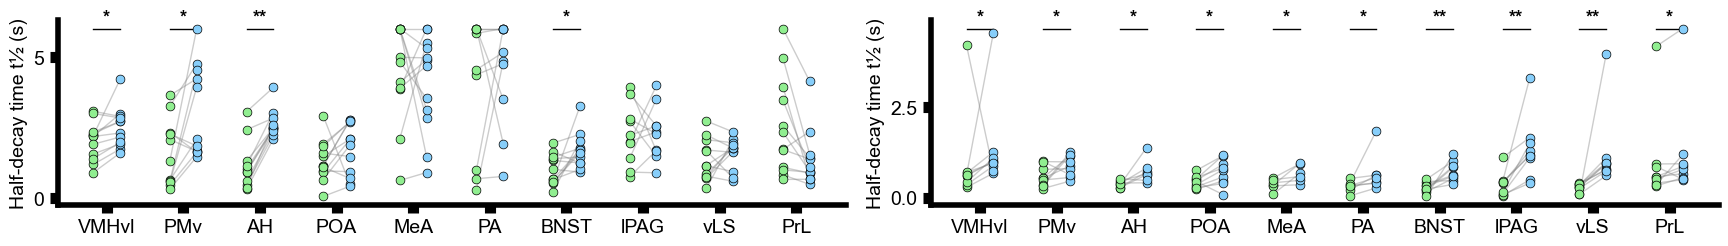

In [115]:
# EI comparison within paired regions

matplotlib.rcParams['font.family'] = 'Arial'

def within_group_EI_halfdecay(thalf_data, group_label, group_color, ax):
    n_regions = len(paired_E)
    x_E = np.arange(n_regions) * 2
    x_I = np.arange(n_regions) * 2 + 0.7
    pvals     = []
    test_used = []

    for i, (e_idx, i_idx) in enumerate(zip(paired_E, paired_I)):
        e_vals = thalf_data[e_idx][~np.isnan(thalf_data[e_idx])] / 40
        i_vals = thalf_data[i_idx][~np.isnan(thalf_data[i_idx])] / 40
        n_paired = min(len(e_vals), len(i_vals))
        e_paired = e_vals[:n_paired]
        i_paired = i_vals[:n_paired]

        for e_v, i_v in zip(e_paired, i_paired):
            ax.plot([x_E[i], x_I[i]], [e_v, i_v],
                    color='gray', alpha=0.4, linewidth=1, zorder=1)
            ax.scatter(x_E[i], e_v, color='lightgreen',
                       s=40, zorder=3, edgecolors='black', linewidths=0.5)
            ax.scatter(x_I[i], i_v, color='lightskyblue',
                       s=40, zorder=3, edgecolors='black', linewidths=0.5)

        if n_paired >= 3:
            _, p_e = shapiro(e_paired)
            _, p_i = shapiro(i_paired)
            if p_e > 0.05 and p_i > 0.05:
                _, p = ttest_rel(e_paired, i_paired, alternative='less')
                test_used.append('t')
            else:
                _, p = wilcoxon(e_paired, i_paired, alternative='less')
                test_used.append('W')
        else:
            p = np.nan
            test_used.append('')
        pvals.append(p)

    pvals_arr = np.array(pvals)
    valid     = ~np.isnan(pvals_arr)
    corrected = np.full(len(pvals), np.nan)
    if valid.sum() > 0:
        _, corrected[valid], _, _ = multipletests(pvals_arr[valid], method='fdr_bh')

    ax.autoscale()
    y_max = ax.get_ylim()[1]
    for i, p in enumerate(corrected):
        marker = get_sig_marker(p)
        if marker:
            x_mid = (x_E[i] + x_I[i]) / 2
            ax.plot([x_E[i], x_I[i]], [y_max * 0.95, y_max * 0.95],
                    color='black', linewidth=1)
            ax.text(x_mid, y_max * 0.96, marker, ha='center', va='bottom',
                    fontsize=13, fontweight='bold', fontfamily='Arial')

    x_mid_ticks = [(x_E[i] + x_I[i]) / 2 for i in range(n_regions)]
    ax.set_xticks(x_mid_ticks)
    ax.set_xticklabels(paired_labels, fontsize=14, fontfamily='Arial',
                       rotation=0, ha='center')

    # Force Arial on all tick labels
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(14)

    ax.set_ylabel('Half-decay time t½ (s)', fontsize=14, fontfamily='Arial')
    # ax.set_title(f'{group_label}: E vs I Half-Decay (paired, FDR-corrected)',
    #              fontsize=13, fontfamily='Arial', fontweight='bold')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
               markeredgecolor='black', markersize=8, label='E'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightskyblue',
               markeredgecolor='black', markersize=8, label='I'),
    ]
    # leg = ax.legend(handles=legend_elements, fontsize=11, frameon=False)
    # for text in leg.get_texts():
    #     text.set_fontfamily('Arial')

    sns.despine(ax=ax)


fig2, (ax_exp, ax_obs) = plt.subplots(1, 2, figsize=(18, 3), sharey=False)
within_group_EI_halfdecay(agg_thalf, 'EXP', 'darkorange', ax_exp)
within_group_EI_halfdecay(obs_thalf, 'OBS', 'magenta',    ax_obs)
plt.tight_layout()
plt.savefig('./figures/ext7_EI_halfdecay_within_group.svg', dpi=300)
plt.show()

In [108]:
def compute_EI_halfdecay_stats(thalf_data, group_label):
    """
    Paired E vs I half-decay test within a group.
    One-sided: testing whether E < I (alternative='less').
    Returns list of stat records and raw p-values.
    """
    records   = []
    raw_pvals = []

    for i, (e_idx, i_idx) in enumerate(zip(paired_E, paired_I)):
        label  = paired_labels[i]
        e_vals = thalf_data[e_idx][~np.isnan(thalf_data[e_idx])] / 40
        i_vals = thalf_data[i_idx][~np.isnan(thalf_data[i_idx])] / 40

        n = min(len(e_vals), len(i_vals))
        e_p = e_vals[:n]
        i_p = i_vals[:n]

        if n >= 3:
            _, p_e = shapiro(e_p)
            _, p_i = shapiro(i_p)
            if p_e > 0.05 and p_i > 0.05:
                stat, p = ttest_rel(e_p, i_p, alternative='less')
                test_label = 'paired t-test (E<I)'
            else:
                stat, p = wilcoxon(e_p, i_p, alternative='less')
                test_label = 'Wilcoxon (E<I)'
        else:
            stat, p = np.nan, np.nan
            test_label = 'n/a'

        records.append({
            'group':      group_label,
            'region':     label,
            'comparison': 'E vs I (paired)',
            'test':       test_label,
            'stat':       stat,
            'p_raw':      p,
            'p_fdr':      np.nan,
            'n':          n,
            'mean_E':     np.nanmean(e_p) if n > 0 else np.nan,
            'mean_I':     np.nanmean(i_p) if n > 0 else np.nan,
        })
        raw_pvals.append(p)

    # ── FDR within group ──────────────────────────────────────────────────────
    valid_idx = [i for i, p in enumerate(raw_pvals) if not np.isnan(p)]
    if valid_idx:
        _, corr, _, _ = multipletests(
            [raw_pvals[i] for i in valid_idx], method='fdr_bh')
        for rank, i in enumerate(valid_idx):
            records[i]['p_fdr'] = corr[rank]

    return records


# ── Run for both groups ───────────────────────────────────────────────────────
exp_ei_records = compute_EI_halfdecay_stats(agg_thalf, 'EXP')
obs_ei_records = compute_EI_halfdecay_stats(obs_thalf, 'OBS')

all_ei_records = exp_ei_records + obs_ei_records

# ── Print table ───────────────────────────────────────────────────────────────
print(f'\n{"="*90}')
print(f'E vs I half-decay comparison — within group, paired, one-sided (E < I)')
print(f'Correction: FDR-BH applied separately within each group')
print(f'{"="*90}')
print(f'{"Group":<6} {"Region":<8} {"Comparison":<18} {"Test":<22} '
      f'{"Stat":>9} {"p_raw":>10} {"p_fdr":>10} {"Sig":>5} '
      f'{"n":>4} {"mean_E (s)":>11} {"mean_I (s)":>11}')
print(f'{"─"*90}')

current_group = None
for r in all_ei_records:
    if r['group'] != current_group:
        print(f'\n  ── {r["group"]} ──')
        current_group = r['group']
    sig     = get_sig_marker(r['p_fdr']) if not np.isnan(r['p_fdr']) else 'n/a'
    stat_s  = f'{r["stat"]:>9.3f}'   if not np.isnan(r['stat'])   else '      n/a'
    p_raw_s = f'{r["p_raw"]:>10.4f}' if not np.isnan(r['p_raw'])  else '       n/a'
    p_fdr_s = f'{r["p_fdr"]:>10.4f}' if not np.isnan(r['p_fdr'])  else '       n/a'
    me_s    = f'{r["mean_E"]:>11.4f}' if not np.isnan(r['mean_E']) else '        n/a'
    mi_s    = f'{r["mean_I"]:>11.4f}' if not np.isnan(r['mean_I']) else '        n/a'
    print(f'  {r["group"]:<6} {r["region"]:<8} {r["comparison"]:<18} '
          f'{r["test"]:<22} {stat_s} {p_raw_s} {p_fdr_s} {sig:>5} '
          f'{r["n"]:>4} {me_s} {mi_s}')

print(f'\n{"="*90}')
for grp, recs in [('EXP', exp_ei_records), ('OBS', obs_ei_records)]:
    n_sig = sum(1 for r in recs
                if not np.isnan(r['p_fdr']) and r['p_fdr'] < 0.05)
    print(f'{grp}: {n_sig}/{len(recs)} regions significant (FDR<0.05, E<I)')
print(f'{"="*90}')


E vs I half-decay comparison — within group, paired, one-sided (E < I)
Correction: FDR-BH applied separately within each group
Group  Region   Comparison         Test                        Stat      p_raw      p_fdr   Sig    n  mean_E (s)  mean_I (s)
──────────────────────────────────────────────────────────────────────────────────────────

  ── EXP ──
  EXP    VMHvl    E vs I (paired)    paired t-test (E<I)       -2.973     0.0063     0.0292     *   12      2.0144      2.4977
  EXP    PMv      E vs I (paired)    Wilcoxon (E<I)             7.000     0.0093     0.0292     *   11      1.5841      3.0635
  EXP    AH       E vs I (paired)    Wilcoxon (E<I)             0.000     0.0005     0.0049    **   11      1.1393      2.6287
  EXP    POA      E vs I (paired)    paired t-test (E<I)       -1.368     0.0993     0.1987         12      1.3011      1.7435
  EXP    MeA      E vs I (paired)    Wilcoxon (E<I)            38.000     0.6717     0.7463         12      4.5288      4.0963
  EXP   

In [109]:
# Get source data

def build_EI_halfdecay_source(thalf_data, group_label, records):
    stats_lookup = {r['region']: r for r in records}
    rows = []
    for i, (e_idx, i_idx) in enumerate(zip(paired_E, paired_I)):
        label = paired_labels[i]
        e_vals = thalf_data[e_idx][~np.isnan(thalf_data[e_idx])] / 40
        i_vals = thalf_data[i_idx][~np.isnan(thalf_data[i_idx])] / 40
        n_paired = min(len(e_vals), len(i_vals))
        e_paired = e_vals[:n_paired]
        i_paired = i_vals[:n_paired]

        sr = stats_lookup[label]
        for pair_idx in range(n_paired):
            rows.append({
                'group': group_label,
                'region': label,
                'pair_idx': pair_idx,
                'E_halfdecay_s': e_paired[pair_idx],
                'I_halfdecay_s': i_paired[pair_idx],
                'test': sr['test'],
                'stat': sr['stat'],
                'p_raw': sr['p_raw'],
                'p_fdr': sr['p_fdr'],
                'n': sr['n'],
            })
    return pd.DataFrame(rows)

sourceData_ED7c = build_EI_halfdecay_source(agg_thalf, 'EXP', exp_ei_records)
sourceData_ED7c.to_csv('./sourceData/ED7c.csv', index=False)

sourceData_ED7d = build_EI_halfdecay_source(obs_thalf, 'OBS', obs_ei_records)
sourceData_ED7d.to_csv('./sourceData/ED7d.csv', index=False)

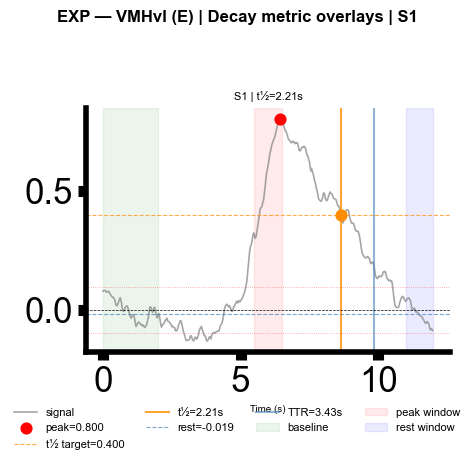

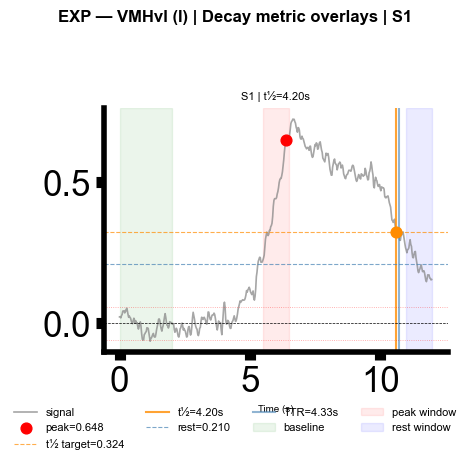

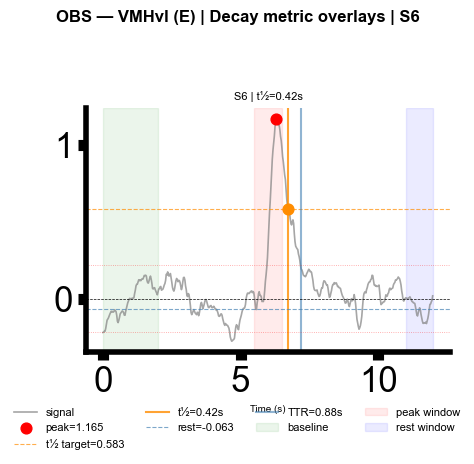

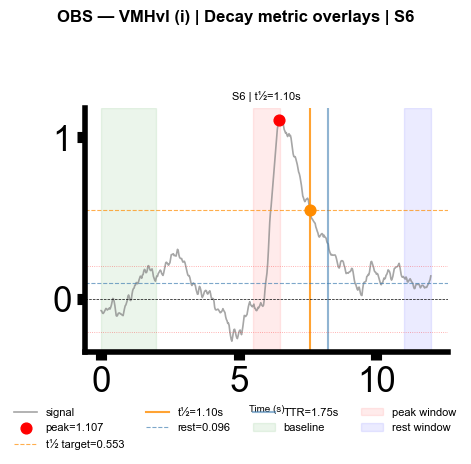

In [117]:
def plot_decay_examples(peths, region_idx, region_name, group_name,
                        baseline, peak_window, rest_window,
                        settle_thresh=0.25, sustain=4,
                        n_cols=4, scale=1/40,
                        subject_num=None):
    """
    Plot individual subject PETHs with decay metric overlays:
      - Peak marker
      - Half-decay point
      - Rest value line
      - Time-to-rest marker
      - Time-to-baseline marker

    subject_num : int or None
        1-indexed subject to isolate (matches the "S1", "S2", ... labels
        used in titles/filenames). If None, plots the full grid of all
        subjects as before. If given, plots only that one subject in a
        single-panel figure.
    """
    from scipy.ndimage import uniform_filter1d

    n_subjects = peths.shape[2]

    if subject_num is not None:
        if not (1 <= subject_num <= n_subjects):
            raise ValueError(f'subject_num must be between 1 and {n_subjects}, got {subject_num}')
        subject_indices = [subject_num - 1]
        n_rows, n_cols_use = 1, 1
        figsize = (5, 4.5)
    else:
        subject_indices = list(range(n_subjects))
        n_rows = int(np.ceil(n_subjects / n_cols))
        n_cols_use = n_cols
        figsize = (n_cols * 3.5, n_rows * 3)

    fig, axes = plt.subplots(n_rows, n_cols_use, figsize=figsize, sharey=False)
    axes = np.atleast_1d(axes).flatten()

    for plot_pos, s in enumerate(subject_indices):
        ax    = axes[plot_pos]
        trace = peths[:, region_idx, s]

        if np.any(np.isnan(trace)):
            ax.set_title(f'S{s+1} — NaN', fontsize=8)
            ax.axis('off')
            continue

        bl        = np.nanmedian(trace[baseline[0]:baseline[1]])
        bl_std    = np.nanstd(trace[baseline[0]:baseline[1]])
        corrected = trace - bl
        t         = np.arange(len(corrected)) * scale  # convert to seconds

        # Plot raw corrected trace
        ax.plot(t, corrected, color='gray', linewidth=1.2, alpha=0.7, label='signal')

        # Noise threshold
        noise_threshold = 2 * bl_std

        # --- Peak detection ---
        smoothed   = uniform_filter1d(corrected.astype(float), size=3)
        search_seg = smoothed[peak_window[0]:peak_window[1]]
        if np.all(np.isnan(search_seg)):
            ax.set_title(f'S{s+1} — no peak', fontsize=8)
            continue

        peak_local = np.nanargmax(search_seg)
        peak_abs   = peak_window[0] + peak_local
        peak_val   = corrected[peak_abs]

        if np.isnan(peak_val) or abs(peak_val) < noise_threshold:
            ax.set_title(f'S{s+1} — peak below noise\n(peak={peak_val:.3f}, thr={noise_threshold:.3f})',
                         fontsize=7, color='red')
            ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
            ax.axhline(noise_threshold,  color='red', linewidth=0.8,
                       linestyle=':', alpha=0.5, label='noise floor')
            ax.axhline(-noise_threshold, color='red', linewidth=0.8,
                       linestyle=':', alpha=0.5)
            sns.despine(ax=ax)
            continue

        # Rest value
        rest_seg = corrected[rest_window[0]:rest_window[1]]
        rest_val = np.nanmean(rest_seg) if not np.all(np.isnan(rest_seg)) else np.nan

        post_peak   = corrected[peak_abs:]
        half_target = peak_val / 2

        # --- Mark peak ---
        ax.scatter(peak_abs * scale, peak_val, color='red', s=60, zorder=5,
                   label=f'peak={peak_val:.3f}')

        # --- Half-decay ---
        half_frame = None
        for i in range(1, len(post_peak)):
            val = post_peak[i]
            if np.isnan(val):
                continue
            crossed = (peak_val > 0 and val <= half_target) or \
                      (peak_val < 0 and val >= half_target)
            if crossed:
                prev_val = post_peak[i - 1]
                if not np.isnan(prev_val) and prev_val != val:
                    frac      = (half_target - prev_val) / (val - prev_val)
                    half_frame = (i - 1) + frac
                else:
                    half_frame = float(i)
                break

        ax.axhline(half_target, color='darkorange', linewidth=0.8,
                   linestyle='--', alpha=0.7, label=f't½ target={half_target:.3f}')
        if half_frame is not None:
            t_half_abs = (peak_abs + half_frame) * scale
            ax.axvline(t_half_abs, color='darkorange', linewidth=1.5,
                       linestyle='-', alpha=0.8,
                       label=f't½={half_frame * scale:.2f}s')
            ax.scatter(t_half_abs, half_target, color='darkorange',
                       s=60, zorder=5)
        else:
            ax.set_title(f'S{s+1} — never decayed', fontsize=8, color='purple')

        # --- Rest value line ---
        if not np.isnan(rest_val):
            ax.axhline(rest_val, color='steelblue', linewidth=0.8,
                       linestyle='--', alpha=0.7, label=f'rest={rest_val:.3f}')

        # --- Time-to-rest marker ---
        delta = peak_val - rest_val if not np.isnan(rest_val) else np.nan
        if not np.isnan(delta) and abs(delta) >= noise_threshold:
            threshold = abs(delta) * settle_thresh
            for i in range(len(post_peak) - sustain):
                window = post_peak[i:i + sustain]
                if np.all(~np.isnan(window)) and \
                   np.all(np.abs(window - rest_val) <= threshold):
                    t_ttr = (peak_abs + i) * scale
                    ax.axvline(t_ttr, color='steelblue', linewidth=1.5,
                               linestyle='-', alpha=0.6,
                               label=f'TTR={i * scale:.2f}s')
                    break

        # --- Baseline and peak window shading ---
        ax.axvspan(baseline[0] * scale,    baseline[1] * scale,
                   alpha=0.08, color='green', label='baseline')
        ax.axvspan(peak_window[0] * scale, peak_window[1] * scale,
                   alpha=0.08, color='red',   label='peak window')
        ax.axvspan(rest_window[0] * scale, rest_window[1] * scale,
                   alpha=0.08, color='blue',  label='rest window')

        # --- Noise floor lines ---
        ax.axhline( noise_threshold, color='red', linewidth=0.6,
                    linestyle=':', alpha=0.4)
        ax.axhline(-noise_threshold, color='red', linewidth=0.6,
                    linestyle=':', alpha=0.4)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

        title = f'S{s+1}'
        if half_frame is not None:
            title += f' | t½={half_frame * scale:.2f}s'
        ax.set_title(title, fontsize=8, fontfamily='Arial')
        ax.set_xlabel('Time (s)', fontsize=7)
        sns.despine(ax=ax)

    # Hide unused axes (only relevant in full-grid mode)
    for j in range(len(subject_indices), len(axes)):
        axes[j].axis('off')

    # Single legend from first valid axis
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4,
               fontsize=8, frameon=False,
               bbox_to_anchor=(0.5, -0.02))

    subj_suffix = f' | S{subject_num}' if subject_num is not None else ''
    fig.suptitle(f'{group_name} — {region_name} | Decay metric overlays{subj_suffix}',
                 fontsize=12, fontweight='bold', fontfamily='Arial')
    plt.tight_layout()
    # plt.savefig(f'./figures/fig2/decay_examples_{group_name}_{region_name.replace(" ", "_")}.svg',
    #             dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

plot_decay_examples(peths=agg_peths, region_idx=12, region_name='VMHvl (E)',
                     group_name='EXP', baseline=baseline,
                     peak_window=peak_search_window, rest_window=rest_window,
                     subject_num=1)

plot_decay_examples(peths=agg_peths, region_idx=13, region_name='VMHvl (I)',
                     group_name='EXP', baseline=baseline,
                     peak_window=peak_search_window, rest_window=rest_window,
                     subject_num=1)

plot_decay_examples(peths=obs_peths, region_idx=12, region_name='VMHvl (E)',
                     group_name='OBS', baseline=baseline,
                     peak_window=peak_search_window, rest_window=rest_window,
                     subject_num=6)

plot_decay_examples(peths=obs_peths, region_idx=13, region_name='VMHvl (i)',
                     group_name='OBS', baseline=baseline,
                     peak_window=peak_search_window, rest_window=rest_window,
                     subject_num=6)

In [118]:
from scipy.ndimage import uniform_filter1d

def extract_decay_example_data(peths, region_idx, region_name, group_name,
                                baseline, peak_window, rest_window,
                                subject_num, settle_thresh=0.25, sustain=4, scale=1/40):
    """
    Recomputes the same quantities plot_decay_examples draws for one subject,
    returned as a long-format DataFrame instead of a figure: the full
    baseline-corrected trace plus scalar annotations (peak, half-decay,
    rest, time-to-rest) broadcast across rows.
    """
    s = subject_num - 1
    trace = peths[:, region_idx, s]

    bl        = np.nanmedian(trace[baseline[0]:baseline[1]])
    bl_std    = np.nanstd(trace[baseline[0]:baseline[1]])
    corrected = trace - bl
    t         = np.arange(len(corrected)) * scale
    noise_threshold = 2 * bl_std

    smoothed   = uniform_filter1d(corrected.astype(float), size=3)
    search_seg = smoothed[peak_window[0]:peak_window[1]]
    peak_local = np.nanargmax(search_seg)
    peak_abs   = peak_window[0] + peak_local
    peak_val   = corrected[peak_abs]

    rest_seg = corrected[rest_window[0]:rest_window[1]]
    rest_val = np.nanmean(rest_seg) if not np.all(np.isnan(rest_seg)) else np.nan

    post_peak   = corrected[peak_abs:]
    half_target = peak_val / 2

    half_frame = None
    for i in range(1, len(post_peak)):
        val = post_peak[i]
        if np.isnan(val):
            continue
        crossed = (peak_val > 0 and val <= half_target) or \
                  (peak_val < 0 and val >= half_target)
        if crossed:
            prev_val = post_peak[i - 1]
            if not np.isnan(prev_val) and prev_val != val:
                frac = (half_target - prev_val) / (val - prev_val)
                half_frame = (i - 1) + frac
            else:
                half_frame = float(i)
            break

    ttr_frame = None
    delta = peak_val - rest_val if not np.isnan(rest_val) else np.nan
    if not np.isnan(delta) and abs(delta) >= noise_threshold:
        threshold = abs(delta) * settle_thresh
        for i in range(len(post_peak) - sustain):
            window = post_peak[i:i + sustain]
            if np.all(~np.isnan(window)) and np.all(np.abs(window - rest_val) <= threshold):
                ttr_frame = i
                break

    df = pd.DataFrame({
        'time_s': t,
        'signal_corrected': corrected,
    })
    df.insert(0, 'group', group_name)
    df.insert(1, 'region', region_name)
    df.insert(2, 'subject_num', subject_num)
    df['peak_time_s']       = peak_abs * scale
    df['peak_value']        = peak_val
    df['half_decay_time_s'] = (peak_abs + half_frame) * scale if half_frame is not None else np.nan
    df['half_decay_target'] = half_target
    df['rest_value']        = rest_val
    df['time_to_rest_s']    = (peak_abs + ttr_frame) * scale if ttr_frame is not None else np.nan
    df['noise_threshold']   = noise_threshold

    return df

sourceData_ED7a = pd.concat([
    extract_decay_example_data(agg_peths, 12, 'VMHvl (E)', 'EXP', baseline,
                                peak_search_window, rest_window, subject_num=1),
    extract_decay_example_data(agg_peths, 13, 'VMHvl (I)', 'EXP', baseline,
                                peak_search_window, rest_window, subject_num=1),
    extract_decay_example_data(obs_peths, 12, 'VMHvl (E)', 'OBS', baseline,
                                peak_search_window, rest_window, subject_num=6),
    extract_decay_example_data(obs_peths, 13, 'VMHvl (I)', 'OBS', baseline,
                                peak_search_window, rest_window, subject_num=6),
], ignore_index=True)

sourceData_ED7a.to_csv('./sourceData/ED7a.csv', index=False)

### Using time warping to standardize conflict-aligned PETHs for all three groups - hard fight

In [334]:
PAD_LENGTH = 2400

def pad_df_with_zeros(df, pad_length=PAD_LENGTH):
    """
    Appends pad_length rows of zeros to the end of df, matching its
    existing columns.
    """
    pad_data = {col: np.zeros(pad_length, dtype=df[col].dtype) for col in df.columns}
    pad_df = pd.DataFrame(pad_data)
    return pd.concat([df, pad_df], ignore_index=True)

sessions_df = pd.read_pickle('boris_labels_hf.pickle')
sessions_df = {
    key: pad_df_with_zeros(df) for key, df in sessions_df.items()
}

stim_map = {
    'EXP': 'mCD1',
    'OBS': 'OBSmCD1',
    'NON': 'toyCD1'
}

behavior_labels = ['resident_unilateral', 'intruder_unilateral',
                   'resident_resistance', 'intruder_resistance', 'resident_flee']

combined_labels = {
    'conflict': ['resident_unilateral', 'resident_resistance',
                 'intruder_resistance', 'intruder_unilateral'],
}

def align_behavior_to_neural(behavior_series, neural_length):
    """Pad with zeros at end OR trim from front to match neural length."""
    n = len(behavior_series)
    if n == neural_length:
        return behavior_series.reset_index(drop=True)
    elif n > neural_length:
        return behavior_series.iloc[n - neural_length:].reset_index(drop=True)
    else:
        pad = pd.Series(np.zeros(neural_length - n, dtype=int))
        return pd.concat([behavior_series.reset_index(drop=True), pad],
                         ignore_index=True)

def concatenate_sessions_for_animal(animal, group, full_data, sessions_df,
                                    day=9, sessions=(1, 2, 3)):
    stim           = stim_map[group]
    neural_list    = []
    behavior_lists = {label: [] for label in behavior_labels}
    for combined_name in combined_labels:
        behavior_lists[combined_name] = []

    for session_num in sessions:
        fdata_key = f'{animal}_d{day}_{stim}_t{session_num}'
        sdf_key   = (animal, session_num, group)

        if fdata_key not in full_data:
            continue
        if sdf_key not in sessions_df:
            continue

        neural_df     = full_data[fdata_key]
        sdf           = sessions_df[sdf_key]
        region_cols   = [c for c in neural_df.columns if c in region_ids]
        neural_trace  = neural_df[region_cols].values
        neural_length = neural_trace.shape[0]

        for label in behavior_labels:
            if label in sdf.columns:
                b = align_behavior_to_neural(sdf[label], neural_length)
            else:
                b = pd.Series(np.zeros(neural_length, dtype=int))
            behavior_lists[label].append(b.values)

        for combined_name, source_labels in combined_labels.items():
            available = [l for l in source_labels if l in sdf.columns]
            combined  = (sdf[available].sum(axis=1) > 0).astype(int) \
                        if available else pd.Series(np.zeros(neural_length, dtype=int))
            behavior_lists[combined_name].append(
                align_behavior_to_neural(combined, neural_length).values
            )

        neural_list.append(neural_trace)

    if not neural_list:
        return None, None

    neural_array  = np.vstack(neural_list)
    behavior_dict = {label: np.concatenate(vals)
                     for label, vals in behavior_lists.items()}
    return neural_array, behavior_dict

def extract_windows_for_animal(animal, group, full_data, sessions_df,
                                window_size=480, day=9):
    
    neural_array, behavior_dict = concatenate_sessions_for_animal(
        animal, group, full_data, sessions_df, day=day
    )
    if neural_array is None:
        return None

    n_frames  = neural_array.shape[0]
    n_regions = neural_array.shape[1]
    windows_dict = {}

    for combined_name in combined_labels:
        y = behavior_dict[combined_name]

        try:
            on, off = find_window_of_behavior(
                y, label_ID=1,
                window_size=window_size,
                window_of_separation=window_size,  # no overlapping windows
                min_segment_length=4
            )
        except (IndexError, Exception):
            on = []

        if len(on) == 0:
            windows_dict[combined_name] = {
                'windows': np.full((0, window_size, n_regions), np.nan),
            }
            continue

        # ── Pad short windows ─────────────────────────────────────────────────
        for i, lst in enumerate(on):
            if len(lst) < window_size:
                mean_val = float(np.mean(lst)) if len(lst) > 0 else 0.0
                on[i]    = list(lst) + [mean_val] * (window_size - len(lst))

        aggression_windows = np.asarray(on)
        n_trials           = aggression_windows.shape[0]
        traces4beh         = np.full((n_trials, window_size, n_regions), np.nan)

        for region_idx in range(n_regions):
            trace = neural_array[:, region_idx]
            for j, window in enumerate(aggression_windows):
                window = np.array(window).astype(int)
                valid  = (window >= 0) & (window < n_frames)
                if valid.sum() == 0:
                    continue
                traces4beh[j, :, region_idx] = np.where(valid, trace[window], np.nan)

        windows_dict[combined_name] = {
            'windows': traces4beh,   # (n_trials, 480, n_regions)
        }

    return windows_dict

def warp_behavior(results, behavior, warp_params):
    all_trials, trial_map = [], []

    for group in ['EXP', 'OBS', 'NON']:
        for animal, windows_dict in results[group].items():
            if behavior not in windows_dict:
                continue
            entry = windows_dict[behavior]
            arr   = entry['windows']
            if arr is None or arr.size == 0 or arr.shape[0] == 0:
                continue
            for t in range(arr.shape[0]):
                all_trials.append(arr[t])
                trial_map.append((group, animal, t))

    if not all_trials:
        print(f"[{behavior}] No trials found.")
        return None, None

    all_trials = np.stack(all_trials, axis=0)
    print(f"[{behavior}] Trials: {all_trials.shape[0]}")

    # Complete vs incomplete
    complete_idx, incomplete_idx = [], []
    for i in range(all_trials.shape[0]):
        if np.all(np.isnan(all_trials[i]), axis=0).any():
            incomplete_idx.append(i)
        else:
            complete_idx.append(i)

    if not complete_idx:
        print(f"[{behavior}] No complete trials — cannot fit model.")
        return None, None

    # Fit on complete
    model = RobustTimeWarping(**warp_params)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        warped_complete, clean_mask_complete = model.fit_transform(
            all_trials[complete_idx]
        )

    # Align incomplete
    warped_incomplete     = None
    clean_mask_incomplete = np.zeros(len(incomplete_idx), dtype=bool)

    if incomplete_idx:
        filled = all_trials[incomplete_idx].copy()
        for i in range(filled.shape[0]):
            missing   = np.all(np.isnan(filled[i]), axis=0)
            available = np.where(~missing)[0]
            if len(available) == 0:
                continue
            for r in np.where(missing)[0]:
                filled[i, :, r] = filled[i, :, available[0]]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            warped_filled, _, clean_mask_incomplete = model.align_to_template(filled)

        warped_incomplete = warped_filled.copy()
        for i in range(warped_incomplete.shape[0]):
            missing = np.all(np.isnan(all_trials[incomplete_idx[i]]), axis=0)
            warped_incomplete[i, :, missing] = np.nan

    # Recombine
    warped_all = np.full_like(all_trials, np.nan)
    clean_complete_global = np.array(complete_idx)[clean_mask_complete]
    warped_all[clean_complete_global] = warped_complete
    if warped_incomplete is not None:
        clean_incomplete_global = np.array(incomplete_idx)[clean_mask_incomplete]
        warped_all[clean_incomplete_global] = warped_incomplete

    # Split by group
    warped_by_group = {
        g: {'warped_trials': [], 'trial_map': []}
        for g in ['EXP', 'OBS', 'NON']
    }
    for i, (group, animal, t) in enumerate(trial_map):
        warped_by_group[group]['warped_trials'].append(warped_all[i])
        warped_by_group[group]['trial_map'].append((animal, t))

    for group in ['EXP', 'OBS', 'NON']:
        wt = warped_by_group[group]['warped_trials']
        warped_by_group[group]['warped_trials'] = np.stack(wt) if wt else None

    return warped_by_group, model

# ── Main extraction ────────────────────────────────────────────────────────────

animal_group_map = {}
for (animal, session_num, group) in sessions_df.keys():
    if animal not in animal_group_map:
        animal_group_map[animal] = group

results = {'EXP': {}, 'OBS': {}, 'NON': {}}
for animal, group in tqdm(animal_group_map.items()):
    windows_dict = extract_windows_for_animal(
        animal, group, full_data, sessions_df, window_size=480, day=9
    )
    if windows_dict is None:
        print(f"Skipping {animal} ({group}): no sessions")
        continue
    results[group][animal] = windows_dict

# ── Warp ──────────────────────────────────────────────────────────────────────
warp_params = dict(
    maxlag               = 0.05,
    warp_reg_scale       = 0.0,
    smoothness_reg_scale = 0,
    l2_reg_scale         = 0.0,
    artifact_threshold   = 3,
    artifact_window      = (0, 80),
    boundary_threshold   = 8888,
    center_shifts        = True,
    niter                = 10
)

warped_results, warp_models = {}, {}
for behavior in combined_labels:
    print(f"\n{'='*50}\nBehavior: {behavior}")
    warped_by_group, model = warp_behavior(results, behavior, warp_params)
    warped_results[behavior] = warped_by_group
    warp_models[behavior]    = model

100%|██████████| 27/27 [00:00<00:00, 74.60it/s]



Behavior: conflict
[conflict] Trials: 189
Removing 5 artifact trials out of 174 total


Loss: 2.43: 100%|██████████| 10/10 [00:00<00:00, 52.74it/s]


Removing 1 artifact trials out of 15 total
Finding optimal shifts for 14 new trials...
New shifts range: -20.0 to 28.0
Mean new shift: 0.07 ± 18.98


In [345]:
from itertools import combinations
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from scipy.stats import shapiro, levene, bartlett, f_oneway, kruskal, ttest_ind, brunnermunzel, mannwhitneyu

# ── Helper: check warped_trials shape and build per-animal PETHs ──────────────

tw = [220, 280]
baseline = [0, 80] 
periods  = [80, 400]
sorting_E = [12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18]   # E indices + NAc DA (idx 22)
sorting_I = [13, 17, 9, 5, 11, 21, 7, 15, 3, 1, 22]        # I indices
group_colors = {
    'EXP': 'darkorange',
    'OBS': 'magenta',
    'NON': 'gray',
}

def build_peths(warped_results, behavior):
    peths = {}
    for group in ['EXP', 'OBS', 'NON']:
        entry = warped_results[behavior][group]

        if entry is None or entry.get('warped_trials') is None:
            peths[group] = None
            continue

        wt        = entry['warped_trials']
        trial_map = entry['trial_map']

        if wt.ndim != 3:
            print(f"  [WARN] {group}: warped_trials has unexpected ndim={wt.ndim}, "
                  f"shape={wt.shape}. Skipping.")
            peths[group] = None
            continue

        n_trials, n_timepoints, n_regions = wt.shape
        animals_uniq = list(dict.fromkeys([tm[0] for tm in trial_map]))
        peth_stack   = []

        for animal in animals_uniq:
            idx = [i for i, tm in enumerate(trial_map) if tm[0] == animal]

            if not idx:
                continue

            animal_data = wt[idx]

            if np.all(np.isnan(animal_data)):
                continue

            animal_mean = np.nanmean(animal_data, axis=0)
            peth_stack.append(animal_mean)

        if not peth_stack:
            peths[group] = None
            continue

        peths[group] = np.stack(peth_stack, axis=2)

    return peths

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

def run_group_stats(peths, region_idx, tw, baseline, alpha=0.05, variance_alpha=0.05):
    """
    1) Normality (Shapiro, per group)
    2) Variance (Levene always; Bartlett too if all normal)
    3) Omnibus: ANOVA (normal+equal var) / Welch ANOVA (normal+unequal var)
       / Kruskal-Wallis (non-normal) — only if 3+ valid groups
    4) Posthoc (gated by omnibus p<=0.05, or run directly if only 2 valid
       groups): t-test / Welch t-test / Brunner-Munzel (Mann-Whitney U
       fallback if Brunner-Munzel degenerates — non-finite statistic/p,
       typically from heavy ties / zero-inflation), FDR-BH within region
       across the pairwise comparisons.

    Returns: group_vals, omni_stat, omni_p, posthoc, omni_test
      posthoc[(g1, g2)] = (statistic, p_raw, p_corrected, test_name, df)
    """
    group_vals = {}

    for group in ['EXP', 'OBS', 'NON']:
        peth = peths[group]
        if peth is None:
            group_vals[group] = np.array([])
            continue
        region_data   = peth[:, region_idx, :]   # (n_timepoints, n_animals) — THIS region only
        baseline_mean = np.nanmean(
            region_data[baseline[0]:baseline[1], :], axis=0)
        data_corrected = region_data - baseline_mean[np.newaxis, :]
        window_mean    = np.nanmean(
            data_corrected[tw[0]:tw[1], :], axis=0)
        group_vals[group] = window_mean[~np.isnan(window_mean)]

    valid_groups = [g for g in ['EXP', 'OBS', 'NON']
                    if len(group_vals[g]) >= 3]

    if len(valid_groups) < 2:
        return group_vals, np.nan, np.nan, {}, 'insufficient data'

    samples = [group_vals[g] for g in valid_groups]

    # ── 1. Normality ────────────────────────────────────────────────────────────
    try:
        norm_ps = [shapiro(s)[1] for s in samples]
        normality_passed = all(p > alpha for p in norm_ps)
    except Exception as e:
        print(f"  [WARN] Shapiro failed: {e}")
        normality_passed = False

    # ── 2. Variance ───────────────────────────────────────────────────────────────
    try:
        levene_stat, levene_p = levene(*samples)
        equal_variances = levene_p > variance_alpha
    except Exception as e:
        print(f"  [WARN] Levene failed: {e}")
        equal_variances = False

    if normality_passed:
        try:
            _, bartlett_p = bartlett(*samples)
            equal_variances = equal_variances and (bartlett_p > variance_alpha)
        except Exception as e:
            print(f"  [WARN] Bartlett failed: {e}")

    # ── 3. Omnibus ────────────────────────────────────────────────────────────────
    if len(valid_groups) >= 3:
        if normality_passed and equal_variances:
            df_combined = pd.DataFrame({
                'Activity': np.concatenate(samples),
                'Group': np.concatenate([[g]*len(v) for g, v in zip(valid_groups, samples)]),
            })
            try:
                model = sm.OLS.from_formula('Activity ~ C(Group)', data=df_combined).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
                omni_stat, omni_p = anova_table['F'][0], anova_table['PR(>F)'][0]
                omni_test, pairwise_test = 'ANOVA', 't-test'
            except Exception as e:
                print(f"  [WARN] ANOVA failed: {e}")
                omni_stat, omni_p, omni_test, pairwise_test = np.nan, np.nan, 'ANOVA (failed)', 'Brunner-Munzel'
        elif normality_passed and not equal_variances:
            try:
                omni_stat, omni_p = f_oneway(*samples)
                omni_test, pairwise_test = 'Welch ANOVA', 'Welch t-test'
            except Exception as e:
                print(f"  [WARN] Welch ANOVA failed: {e}")
                omni_stat, omni_p, omni_test, pairwise_test = np.nan, np.nan, 'Welch ANOVA (failed)', 'Brunner-Munzel'
        else:
            try:
                omni_stat, omni_p = kruskal(*samples)
                omni_test, pairwise_test = 'Kruskal-Wallis', 'Brunner-Munzel'
            except Exception as e:
                print(f"  [WARN] Kruskal-Wallis failed: {e}")
                omni_stat, omni_p, omni_test, pairwise_test = np.nan, np.nan, 'Kruskal-Wallis (failed)', 'Brunner-Munzel'
    else:
        # only 2 valid groups — no omnibus, go straight to a single pairwise test
        omni_stat, omni_p = np.nan, np.nan
        if normality_passed and equal_variances:
            omni_test, pairwise_test = 'n/a (2 groups)', 't-test'
        elif normality_passed and not equal_variances:
            omni_test, pairwise_test = 'n/a (2 groups)', 'Welch t-test'
        else:
            omni_test, pairwise_test = 'n/a (2 groups)', 'Brunner-Munzel'

    # ── 4. Posthoc (gated by omnibus p <= 0.05, or always run if only 2 groups) ────
    pair_keys = list(combinations(valid_groups, 2))
    raw_p, stats_, dfs_, test_names = [], [], [], []

    run_posthoc = (len(valid_groups) < 3) or (not np.isnan(omni_p) and omni_p <= 0.05)

    for g1, g2 in pair_keys:
        a, b = group_vals[g1], group_vals[g2]
        if run_posthoc and len(a) >= 2 and len(b) >= 2:
            try:
                if pairwise_test == 't-test':
                    stat, p = ttest_ind(a, b, equal_var=True)
                    test_used = 't-test'
                elif pairwise_test == 'Welch t-test':
                    stat, p = ttest_ind(a, b, equal_var=False)
                    test_used = 'Welch t-test'
                else:
                    stat, p = brunnermunzel(a, b, alternative='two-sided')
                    if not np.isfinite(stat) or not np.isfinite(p):
                        stat, p = mannwhitneyu(a, b, alternative='two-sided')
                        test_used = 'Mann-Whitney U (BM degenerate — fallback)'
                    else:
                        test_used = 'Brunner-Munzel'

                d = compute_df_for_test(test_used, a, b) \
                    if test_used in ('t-test', 'Welch t-test') else np.nan
            except Exception as e:
                print(f"  [WARN] {pairwise_test} {g1} vs {g2} failed: {e}")
                stat, p, test_used, d = np.nan, np.nan, 'n/a (error)', np.nan
        else:
            stat, p, test_used, d = np.nan, np.nan, 'n/a (omnibus n.s.)', np.nan

        stats_.append(stat)
        raw_p.append(p)
        dfs_.append(d)
        test_names.append(test_used)

    # ── FDR-BH within this region across the pairs ─────────────────────────────
    valid_idx = [i for i, p in enumerate(raw_p) if not np.isnan(p)]
    corr_p    = [np.nan] * len(raw_p)
    if valid_idx:
        _, corr, _, _ = multipletests(
            [raw_p[i] for i in valid_idx], method='fdr_tsbh')
        for rank, i in enumerate(valid_idx):
            corr_p[i] = corr[rank]

    posthoc = {
        (g1, g2): (stats_[i], raw_p[i], corr_p[i], test_names[i], dfs_[i])
        for i, (g1, g2) in enumerate(pair_keys)
    }

    return group_vals, omni_stat, omni_p, posthoc, omni_test

def sig_stars(p):
    if p is None or np.isnan(p):
        return 'n.s.'
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'n.s.'

def plot_stat_panel(ax, group_vals, kw_p, posthoc, group_colors):
    group_order  = ['EXP', 'OBS', 'NON']
    x_positions  = {g: i for i, g in enumerate(group_order)}
    rng          = np.random.default_rng(42)

    # ── Scatter + mean ± SEM ──────────────────────────────────────────────────
    for group in group_order:
        vals = group_vals[group]
        if len(vals) == 0:
            continue

        xpos  = x_positions[group]
        color = group_colors[group]

        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(
            xpos + jitter, vals,
            color=color, alpha=0.6, s=25, zorder=3, linewidths=0
        )

        mean = np.nanmean(vals)
        sem  = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))
        ax.errorbar(
            xpos, mean, yerr=sem,
            fmt='_', color='black',
            markersize=14, markeredgewidth=2.5,
            elinewidth=2.5, capsize=5, zorder=4
        )

    # ── No brackets — stats are printed in the main loop ─────────────────────

    all_vals_flat = np.concatenate(
        [v for v in group_vals.values() if len(v) > 0]
    )

    if len(all_vals_flat) == 0:
        ax.axis('off')
        return

    y_max   = np.nanmax(all_vals_flat)
    y_min   = np.nanmin(all_vals_flat)
    y_range = (y_max - y_min) if (y_max != y_min) else 1.0

    ax.set_ylim(bottom=y_min - y_range * 0.15,
                top=y_max   + y_range * 0.15)

    # ── Axis formatting ───────────────────────────────────────────────────────
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order, fontsize=7, fontfamily='Arial')

    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))

    for tick in ax.get_yticklabels():
        tick.set_fontsize(15)
        tick.set_fontfamily('Arial')

    for spine in ax.spines.values():
        spine.set_linewidth(3.0)

    ax.tick_params(axis='both', length=4, width=3.0)
    sns.despine(ax=ax)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:52: RuntimeWarning: Mean of empty slice
  animal_mean = np.nanmean(animal_data, axis=0)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\684343685.py:29: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\684343685.py:80: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\684343685.py:80: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\684343685.py:80: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\684343685.py:80: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(



  PETH-only plot | Behavior: conflict  |  regions: ['PMv (I)', 'AH (I)', 'MeA (I)', 'BNST (I)']
  Saved → ./figures/hf_peths_conflict_subset_I_only.svg


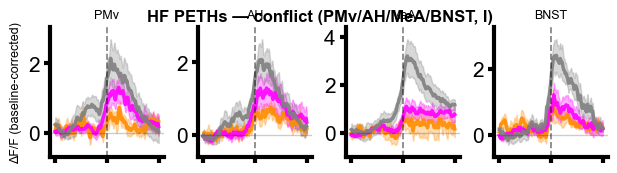


Behavior: conflict
  EXP: peth shape = (480, 23, 9)
  OBS: peth shape = (480, 23, 9)
  NON: peth shape = (480, 23, 8)

  Plot type: E_DA  |  n_regions=11

  [E_DA] Region: VMH (E)
    n_EXP = 9
    n_OBS = 9
    n_NON = 8
    Omnibus (Welch ANOVA): stat=0.8018, p=0.4607
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [E_DA] Region: PMv (E)
    n_EXP = 7
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=0.6482, p=0.7232
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [E_DA] Region: AH (E)
    n_EXP = 7
    n_OBS = 9
    n_NON = 8
    Omnibus (Welch ANOVA): stat=0.5484, p=0.5859
    EX

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:52: RuntimeWarning: Mean of empty slice
  animal_mean = np.nanmean(animal_data, axis=0)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\Falk


  [E_DA] Region: PA (E)
    n_EXP = 7
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=0.4038, p=0.8172
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [E_DA] Region: BNST (E)
    n_EXP = 7
    n_OBS = 9
    n_NON = 8
    Omnibus (ANOVA): stat=0.1708, p=0.8441
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [E_DA] Region: PAG (E)
    n_EXP = 6
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=0.0848, p=0.9585
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
 

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Loc

  Saved → ./figures/hf_stats_only_conflict_E_DA.svg


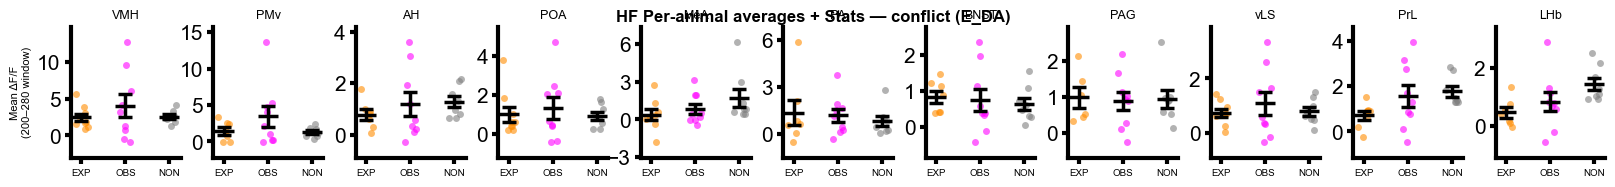


  Plot type: I  |  n_regions=11

  [I] Region: VMH (I)
    n_EXP = 9
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=4.2633, p=0.1186
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [I] Region: PMv (I)
    n_EXP = 7
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=6.1503, p=0.0462
    EXP vs OBS: Brunner-Munzel, stat=1.603, df=n/a, p_raw=0.1439  p_fdr=0.1439  n.s.
    EXP vs NON: Brunner-Munzel, stat=4.531, df=n/a, p_raw=0.0008  p_fdr=0.0015  **
    OBS vs NON: Brunner-Munzel, stat=0.726, df=n/a, p_raw=0.4793  p_fdr=0.3195  n.s.

  [I] Region: AH (I)
    n_EXP = 7
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=7.0762, p=0.0291
    EXP vs OBS: Brunner-Munzel, stat=0.884, df=n/a, p_raw=0.3950  p_fdr=0.2633  n.s.
    EXP vs NON: Brunner-Munzel, stat

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Loc


  [I] Region: PAG (I)
    n_EXP = 6
    n_OBS = 9
    n_NON = 8
    Omnibus (ANOVA): stat=2.9168, p=0.0773
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [I] Region: vLS (I)
    n_EXP = 9
    n_OBS = 9
    n_NON = 8
    Omnibus (Kruskal-Wallis): stat=2.0874, p=0.3522
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.

  [I] Region: PrL (I)
    n_EXP = 8
    n_OBS = 9
    n_NON = 8
    Omnibus (ANOVA): stat=3.2728, p=0.0570
    EXP vs OBS: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    EXP vs NON: n/a (omnibus n.s.), stat=n/a, df=n/a, p_raw=n/a  p_fdr=n/a  n.s.
    OBS vs NON: n/a

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(


  Saved → ./figures/hf_stats_only_conflict_I.svg


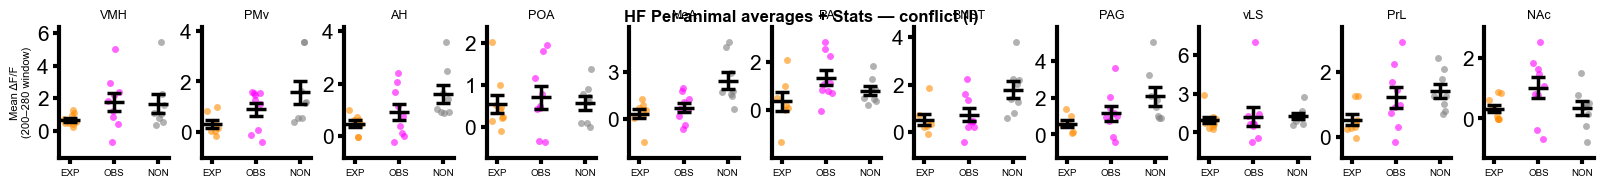

In [348]:
# PLOT 1 — PETH traces ONLY, restricted to PMv (I), AH (I), MeA (I), BNST (I


peth_subset_regions = ['PMv (I)', 'AH (I)', 'MeA (I)', 'BNST (I)']
peth_subset_idx = [region_ids.index(r) for r in peth_subset_regions]

for behavior in combined_labels.keys():

    if behavior != 'conflict':
        continue
    if warped_results.get(behavior) is None:
        continue

    peths = build_peths(warped_results, behavior)

    n_regions = len(peth_subset_idx)
    print(f"\n  PETH-only plot | Behavior: {behavior}  |  regions: {peth_subset_regions}")

    # ── Pre-compute ylims (same logic as main loop, restricted to subset) ────
    ylims = {}
    for r in peth_subset_idx:
        all_mins, all_maxs = [], []
        for group in ['EXP', 'OBS', 'NON']:
            peth = peths[group]
            if peth is None or r >= peth.shape[1]:
                continue
            try:
                region_data   = peth[:, r, :]
                baseline_mean = np.nanmean(
                    region_data[baseline[0]:baseline[1], :], axis=0)
                data_bc  = region_data - baseline_mean[np.newaxis, :]
                window   = data_bc[periods[0]:periods[1], :]
                mean_t   = np.nanmean(window, axis=1)
                sem_t    = (np.nanstd(window, axis=1, ddof=1) /
                            np.sqrt(np.sum(~np.isnan(window), axis=1).clip(min=1)))
                all_mins.append(float(np.nanmin(mean_t - sem_t)))
                all_maxs.append(float(np.nanmax(mean_t + sem_t)))
            except (IndexError, ValueError) as e:
                print(f"    [WARN] ylim calc failed for region {r}, {group}: {e}")

        if all_mins and all_maxs:
            pad      = (max(all_maxs) - min(all_mins)) * 0.12
            ylims[r] = (min(all_mins) - pad, max(all_maxs) + pad)
        else:
            ylims[r] = None

    n_timepoints = None
    for group in ['EXP', 'OBS', 'NON']:
        if peths[group] is not None:
            n_timepoints = peths[group].shape[0]
            break
    if n_timepoints is None:
        print(f"  [SKIP] {behavior}: all groups have None peth.")
        continue

    n_plot = periods[1] - periods[0]

    # ── Figure: single row of PETH traces ─────────────────────────────────────
    fig, axes = plt.subplots(
        1, n_regions,
        figsize=(n_regions * 1.8, 1.7),
        gridspec_kw={'wspace': 0.3},
        sharey=False
    )
    axes = np.atleast_1d(axes)

    for col, r in enumerate(peth_subset_idx):
        ax          = axes[col]
        any_plotted = False

        for group in ['EXP', 'OBS', 'NON']:
            color = group_colors[group]
            peth  = peths[group]

            if peth is None or r >= peth.shape[1]:
                continue

            try:
                region_data   = peth[:, r, :]
                baseline_mean = np.nanmean(
                    region_data[baseline[0]:baseline[1], :], axis=0)
                data_bc = region_data - baseline_mean[np.newaxis, :]
                window  = data_bc[periods[0]:periods[1], :]

                mean_t = np.nanmean(window, axis=1)
                n_obs  = np.sum(~np.isnan(window), axis=1).clip(min=1)
                sem_t  = np.nanstd(window, axis=1, ddof=1) / np.sqrt(n_obs)

                x_vals = np.arange(n_plot)

                ax.plot(x_vals, mean_t, color=color, linewidth=2.5, alpha=0.9, label=group)
                ax.fill_between(x_vals, mean_t - sem_t, mean_t + sem_t, alpha=0.3, color=color)
                any_plotted = True

            except (IndexError, ValueError) as e:
                print(f"    [WARN] PETH plot failed for region {r}, {group}: {e}")
                continue

        if not any_plotted:
            ax.axis('off')
            continue

        mid = n_plot / 2
        ax.axvline(mid, linestyle='--', color='black', alpha=0.5, linewidth=1.2)
        ax.axhline(0,   linestyle='-',  color='black', alpha=0.2, linewidth=1.0)
        ax.set_xticks([0, n_plot // 2, n_plot])
        ax.set_xticklabels(['', '', ''])

        if ylims[r] is not None:
            ax.set_ylim(ylims[r])

        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=3))

        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontfamily('Arial')
            tick.set_fontsize(15)

        for spine in ax.spines.values():
            spine.set_linewidth(3.0)

        ax.tick_params(axis='both', length=4, width=3.0)

        label = (region_ids[r]
                 .replace(' (E)',  '')
                 .replace(' (I)',  '')
                 .replace(' (DA)', ''))
        ax.set_title(label, fontsize=9, fontfamily='Arial')

        if col == 0:
            ax.set_ylabel('ΔF/F (baseline-corrected)', fontsize=9, fontfamily='Arial')

        sns.despine(ax=ax)

    fig.suptitle(f'HF PETHs — {behavior} (PMv/AH/MeA/BNST, I)',
                fontsize=12, fontweight='bold', fontfamily='Arial')

    save_path = f'./figures/hf_peths_{behavior}_subset_I_only.svg'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()
    plt.close(fig)

# PLOT 2 — Per-animal average strip plots (stats panel ONLY), for ALL regions

for behavior in combined_labels.keys():

    if behavior != 'conflict':
        continue
    if warped_results.get(behavior) is None:
        continue

    print(f"\n{'='*60}\nBehavior: {behavior}\n{'='*60}")

    peths = build_peths(warped_results, behavior)

    for g, p in peths.items():
        shape_str = str(p.shape) if p is not None else 'None'
        print(f"  {g}: peth shape = {shape_str}")

    for plot_type, sort_idx in [('E_DA', sorting_E), ('I', sorting_I)]:
        n_regions = len(sort_idx)

        if n_regions == 0:
            print(f"  [SKIP] {plot_type}: no regions.")
            continue

        print(f"\n  Plot type: {plot_type}  |  n_regions={n_regions}")

        # ── Figure: single row of strip plots (stats panel only) ─────────────
        fig, axes = plt.subplots(
            1, n_regions,
            figsize=(n_regions * 1.8, 1.7),
            gridspec_kw={'wspace': 0.3},
            sharey=False
        )
        axes = np.atleast_1d(axes)

        for col, r in enumerate(sort_idx):
            ax = axes[col]

            group_vals, omni_stat, omni_p, posthoc, omni_test = run_group_stats(
                peths, r, tw, baseline
            )

            has_data = any(len(v) > 0 for v in group_vals.values())
            if not has_data:
                ax.axis('off')
                continue

            plot_stat_panel(ax, group_vals, omni_p, posthoc, group_colors)

            # ── Print stats for this region ───────────────────────────────────
            region_label = region_ids[r]
            print(f"\n  [{plot_type}] Region: {region_label}")

            for group in ['EXP', 'OBS', 'NON']:
                n = len(group_vals[group])
                print(f"    n_{group} = {n}")

            omni_str = f"stat={omni_stat:.4f}, p={omni_p:.4f}" if not np.isnan(omni_p) else "n/a"
            print(f"    Omnibus ({omni_test}): {omni_str}")
            for (g1, g2), (stat, p_raw, p_fdr, test_name, df) in posthoc.items():
                stars    = sig_stars(p_fdr)
                stat_str = f"{stat:.3f}" if not np.isnan(stat) else "n/a"
                df_str   = f"{df:.1f}"   if not np.isnan(df)   else "n/a"
                p_r_str  = f"{p_raw:.4f}" if not np.isnan(p_raw) else "n/a"
                p_f_str  = f"{p_fdr:.4f}" if not np.isnan(p_fdr) else "n/a"
                print(f"    {g1} vs {g2}: {test_name}, stat={stat_str}, df={df_str}, "
                      f"p_raw={p_r_str}  p_fdr={p_f_str}  {stars}")

            label = (region_ids[r]
                     .replace(' (E)',  '')
                     .replace(' (I)',  '')
                     .replace(' (DA)', ''))
            ax.set_title(label, fontsize=9, fontfamily='Arial')

            if col == 0:
                ax.set_ylabel('Mean ΔF/F\n(200–280 window)', fontsize=8, fontfamily='Arial')

        fig.suptitle(
            f'HF Per-animal averages + Stats — {behavior} ({plot_type})',
            fontsize=12, fontweight='bold', fontfamily='Arial'
        )

        save_path = (f'./figures/'
                     f'hf_stats_only_{behavior}_{plot_type}.svg')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Saved → {save_path}")
        plt.show()
        plt.close(fig)

In [347]:
# ── Source data export: ED9a (PETH traces, PMv/AH/MeA/BNST, I) ──────────────
os.makedirs('./sourceData', exist_ok=True)

peth_subset_regions = ['PMv (I)', 'AH (I)', 'MeA (I)', 'BNST (I)']
peth_subset_idx = [region_ids.index(r) for r in peth_subset_regions]

rows_9a = []

for behavior in combined_labels.keys():
    if behavior != 'conflict':
        continue
    if warped_results.get(behavior) is None:
        continue

    peths = build_peths(warped_results, behavior)
    n_plot = periods[1] - periods[0]

    for r in peth_subset_idx:
        region_label = (region_ids[r]
                        .replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''))

        for group in ['EXP', 'OBS', 'NON']:
            peth = peths[group]
            if peth is None or r >= peth.shape[1]:
                continue

            try:
                region_data   = peth[:, r, :]  # (n_timepoints, n_animals)
                baseline_mean = np.nanmean(region_data[baseline[0]:baseline[1], :], axis=0)
                data_bc = region_data - baseline_mean[np.newaxis, :]
                window  = data_bc[periods[0]:periods[1], :]  # (n_plot, n_animals)

                mean_t = np.nanmean(window, axis=1)
                n_obs  = np.sum(~np.isnan(window), axis=1).clip(min=1)
                sem_t  = np.nanstd(window, axis=1, ddof=1) / np.sqrt(n_obs)

                for t in range(n_plot):
                    row = {
                        'behavior': behavior,
                        'region': region_label,
                        'group': group,
                        'timepoint': t,
                        'mean': mean_t[t],
                        'sem': sem_t[t],
                    }
                    for a in range(window.shape[1]):
                        row[f'animal_{a}'] = window[t, a]
                    rows_9a.append(row)

            except (IndexError, ValueError) as e:
                print(f"[WARN] source data failed for region {r}, {group}: {e}")
                continue

sourceData_ED9a = pd.DataFrame(rows_9a)
sourceData_ED9a.to_csv('./sourceData/ED9a.csv', index=False)


# ── Source data export: ED9b (per-animal averages + stats, all regions) ─────
os.makedirs('./sourceData', exist_ok=True)

rows_9b = []

for behavior in combined_labels.keys():
    if behavior != 'conflict':
        continue
    if warped_results.get(behavior) is None:
        continue

    peths = build_peths(warped_results, behavior)

    for plot_type, sort_idx in [('E_DA', sorting_E), ('I', sorting_I)]:
        for r in sort_idx:
            group_vals, omni_stat, omni_p, posthoc, omni_test = run_group_stats(
                peths, r, tw, baseline
            )

            has_data = any(len(v) > 0 for v in group_vals.values())
            if not has_data:
                continue

            region_label = (region_ids[r]
                            .replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''))

            posthoc_lookup = {}
            for (g1, g2), (stat, p_raw, p_fdr, test_name, df) in posthoc.items():
                posthoc_lookup[f'{g1}_vs_{g2}'] = {
                    'test': test_name, 'stat': stat, 'df': df,
                    'p_raw': p_raw, 'p_fdr': p_fdr,
                }

            for group in ['EXP', 'OBS', 'NON']:
                for v in group_vals[group]:
                    row = {
                        'behavior': behavior,
                        'plot_type': plot_type,
                        'region': region_label,
                        'group': group,
                        'mean_dff_window': v,
                        'omnibus_test': omni_test,
                        'omnibus_stat': omni_stat,
                        'omnibus_p': omni_p,
                    }
                    for key, d in posthoc_lookup.items():
                        row[f'{key}_test']  = d['test']
                        row[f'{key}_stat']  = d['stat']
                        row[f'{key}_df']    = d['df']
                        row[f'{key}_p_raw'] = d['p_raw']
                        row[f'{key}_p_fdr'] = d['p_fdr']
                    rows_9b.append(row)

sourceData_ED9b = pd.DataFrame(rows_9b)
sourceData_ED9b.to_csv('./sourceData/ED9b.csv', index=False)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:52: RuntimeWarning: Mean of empty slice
  animal_mean = np.nanmean(animal_data, axis=0)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\3729098784.py:29: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(region_data[baseline[0]:baseline[1], :], axis=0)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty slice
  baseline_mean = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:99: RuntimeWarning: Mean of empty slice
  window_mean    = np.nanmean(
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_36580\789414987.py:96: RuntimeWarning: Mean of empty s

## Additional analyses: NAc vs LHb

In [205]:
from matplotlib.colors import LinearSegmentedColormap
# Define the colormap
colors = [(0, 1, 0), (0, 0, 0), (0.9, 0.9, 0.9)]  # Black to white to green
n_bins = 100  # Number of bins in the colormap
cmap_name = 'black_white_green'

# Create the colormap
black_green_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

In [206]:
# Compute selectivity between NAc and LHb during training period

from sklearn.linear_model import LinearRegression

start = 200
end = 280

trial_indices = [0, None]

# Do AGG animals
agg_selectivity = []
agg_selectivity_distribution = []
for mouse in TW_agg_dict.keys():
    # Extract data
    photometry = TW_agg_dict[mouse]
    NAc = photometry[trial_indices[0]:trial_indices[1],start:end, -1]
    LHb = photometry[trial_indices[0]:trial_indices[1],start:end, 18]
    
    # Check for all NaNs in NAc or LHb data
    if np.isnan(NAc).any() or np.isnan(LHb).any():
        print(f'Skipping {mouse}: NAc or LHb data is all NaNs')
        continue

    # Compute selectivity metrics
    selectivity = (NAc - LHb) / (NAc + LHb + 1.5)  # Added small constant to avoid division by zero
    selectivity = np.where(np.abs(selectivity) > 1.5, np.nan, selectivity)
    agg_selectivity_distribution.append(selectivity)
    mean_selectivity = np.nanmedian(selectivity)
    agg_selectivity.append(mean_selectivity)
    # plt.savefig(f'./figures/agg_selectivity_{mouse}.svg', dpi=300)

# Do OBS animals - but include LHb/NAc correlations
obs_selectivity = []
obs_selectivity_distribution = []
obs_lhb_strength_vs_correlation = []

for mouse in TW_obs_attn_dict.keys():

    # Extract data
    photometry = TW_obs_dict[mouse]
    NAc = photometry[trial_indices[0]:trial_indices[1],start:end, -1]
    LHb = photometry[trial_indices[0]:trial_indices[1],start:end, 18]

    # Check for all NaNs in NAc or LHb data
    if np.isnan(NAc).all() or np.isnan(LHb).all():
        print(f'Skipping {mouse}: NAc or LHb data is all NaNs')
        continue

    # Compute selectivity metrics
    selectivity = (NAc - LHb) / (NAc + LHb + 1.5)  # Added small constant to avoid division by zero
    selectivity = np.where(np.abs(selectivity) > 1.5, np.nan, selectivity)
    obs_selectivity_distribution.append(selectivity)
    mean_selectivity = np.nanmedian(selectivity)
    obs_selectivity.append(mean_selectivity)

    # Trial-by-trial regression coefficients
    mouse_regression_coeffs = []  # Changed from mouse_correlations
    mouse_lhb_strengths = []

    for trial in range(photometry.shape[0]):
        nac_trial = photometry[trial, start:end, -1] - np.nanmedian(photometry[trial, :80, -1])
        lhb_trial = photometry[trial, start:end, 18] - np.nanmedian(photometry[trial, :80, 18])

        # Skip trials with NaN values (including check for all NaNs)
        if np.any(np.isnan(nac_trial)) or np.any(np.isnan(lhb_trial)) or np.isnan(nac_trial).all() or np.isnan(lhb_trial).all():
            continue
            
        # Calculate LHb strength
        lhb_strength = np.nanmean(lhb_trial)
        
        # Calculate regression coefficient
        # Regress NAc on LHb (or vice versa, depending on your hypothesis)
        X = nac_trial.reshape(-1, 1)  # NAc as predictor
        y = lhb_trial                   # LHb as outcome

        # Fit regression and get coefficient
        reg = LinearRegression().fit(X, y)
        regression_coeff = reg.coef_[0]
        
        # Store if both values are valid
        if not np.isnan(regression_coeff) and not np.isnan(lhb_strength):
            mouse_regression_coeffs.append(regression_coeff)
            mouse_lhb_strengths.append(lhb_strength)

    # Store for this mouse
    if len(mouse_regression_coeffs) > 0:
        obs_lhb_strength_vs_correlation.append({
            'mouse': mouse,
            'lhb_strengths': np.array(mouse_lhb_strengths),
            'nac_lhb_regression_coeffs': np.array(mouse_regression_coeffs),  # Changed name
            'n_trials': len(mouse_regression_coeffs)
        })

Skipping mouse7: NAc or LHb data is all NaNs
Skipping mouse8: NAc or LHb data is all NaNs
Skipping mouse9: NAc or LHb data is all NaNs
Skipping mouse11: NAc or LHb data is all NaNs


t-test: t=4.444  p=0.0005
KS test: KS=0.288  p=0.0000


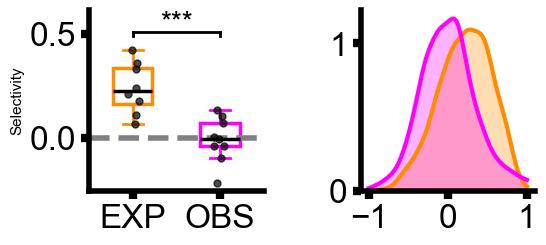

In [207]:
from scipy.stats import sem, ks_2samp, ttest_ind

def get_stars(p_val):
    if p_val < 0.001:  return '***'
    elif p_val < 0.01: return '**'
    elif p_val < 0.05: return '*'
    else:              return 'ns'

def add_significance_bracket(ax, x1, x2, y, p_val, height_offset=0.05):
    ax.plot([x1, x2], [y, y], 'k-', linewidth=2)
    ax.plot([x1, x1], [y - height_offset/2, y], 'k-', linewidth=2)
    ax.plot([x2, x2], [y - height_offset/2, y], 'k-', linewidth=2)
    stars = get_stars(p_val)
    ax.text((x1 + x2) / 2, y - height_offset/2, stars,
            ha='center', va='bottom', fontsize=20, fontfamily='Arial')

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# ── Boxplot + jittered dots ───────────────────────────────────────────────────
data_pairs = [
    (agg_selectivity, 'darkorange', 0),
    (obs_selectivity, 'magenta',    1),
]

for vals, color, xpos in data_pairs:
    vals  = np.array(vals, dtype=float)
    clean = vals[~np.isnan(vals)]

    box = ax[0].boxplot(clean,
                        positions=[xpos], widths=0.45,
                        patch_artist=True,
                        medianprops =dict(color='black', linewidth=2.5),
                        whiskerprops=dict(color=color,  linewidth=2),
                        capprops    =dict(color=color,  linewidth=2),
                        flierprops  =dict(marker='',    markersize=0))
    box['boxes'][0].set_facecolor('white')
    box['boxes'][0].set_edgecolor(color)
    box['boxes'][0].set_linewidth(2.5)

    jitter = np.random.default_rng(42 + xpos).uniform(
        -0.07, 0.07, size=len(clean))
    ax[0].scatter(np.full(len(clean), xpos) + jitter, clean,
                  color='black', s=25, alpha=0.7, zorder=5)

tt, tp = ttest_ind(agg_selectivity, obs_selectivity, nan_policy='omit')
print(f't-test: t={tt:.3f}  p={tp:.4f}')

ax[0].autoscale()
y_lo, y_hi = ax[0].get_ylim()
bracket_y  = y_hi + (y_hi - y_lo) * 0.08
add_significance_bracket(ax[0], 0, 1, bracket_y, tp,
                         height_offset=(y_hi - y_lo) * 0.05)
ax[0].set_ylim(top=bracket_y + (y_hi - y_lo) * 0.15)
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['EXP', 'OBS'], fontfamily='Arial', fontsize=11)
ax[0].set_ylabel('Selectivity', fontfamily='Arial', fontsize=11)
ax[0].axhline(0, color='gray', linestyle='--', linewidth=4)

# ── KDE distribution ──────────────────────────────────────────────────────────
# collapse each mouse's (n_trials, 80) → (n_trials,) by averaging over the time window
agg_selectivity_distribution_trial = [
    np.nanmedian(sel, axis=1) for sel in agg_selectivity_distribution
]
obs_selectivity_distribution_trial = [
    np.nanmedian(sel, axis=1) for sel in obs_selectivity_distribution
]

flattened_agg = np.concatenate(agg_selectivity_distribution_trial)
flattened_agg = flattened_agg[~np.isnan(flattened_agg)]
flattened_obs = np.concatenate(obs_selectivity_distribution_trial)
flattened_obs = flattened_obs[~np.isnan(flattened_obs)]

sns.kdeplot(flattened_agg, ax=ax[1], color='darkorange',
            fill=True, alpha=0.3, lw=0, clip=(-1, 1))
sns.kdeplot(flattened_agg, ax=ax[1], color='darkorange',
            lw=3, clip=(-1, 1))
sns.kdeplot(flattened_obs, ax=ax[1], color='magenta',
            fill=True, alpha=0.3, lw=0, clip=(-1, 1))
sns.kdeplot(flattened_obs, ax=ax[1], color='magenta',
            lw=3, clip=(-1, 1))

ks, ksp = ks_2samp(flattened_agg, flattened_obs)
print(f'KS test: KS={ks:.3f}  p={ksp:.4f}')

ax[1].set_ylabel('', fontfamily='Arial')

for i in range(2):
    for label in ax[i].get_xticklabels() + ax[i].get_yticklabels():
        label.set_fontfamily('Arial')
        label.set_fontsize(24)
    for spine in ax[i].spines.values():
        spine.set_linewidth(4)
    ax[i].tick_params(width=6, length=6)

sns.despine()
plt.tight_layout()
plt.savefig('.\\figures\\fig2_selectivity_comparison.svg', dpi=300)
plt.show()

In [212]:
# ── Stats table ────────────────────────────────────────────────────────────────
agg_sel_clean = np.array(agg_selectivity, dtype=float)
agg_sel_clean = agg_sel_clean[~np.isnan(agg_sel_clean)]
obs_sel_clean = np.array(obs_selectivity, dtype=float)
obs_sel_clean = obs_sel_clean[~np.isnan(obs_sel_clean)]

print(f'\n{"="*90}')
print(f'Selectivity comparison — EXP vs OBS')
print(f'{"="*90}')
print(f'{"Panel":<22} {"Test":<12} {"Stat":>10} {"p-value":>10} '
      f'{"Sig":>5} {"n_EXP":>7} {"n_OBS":>7}')
print(f'{"─"*90}')

sig_tt = get_stars(tp)
sig_ks = get_stars(ksp)

print(f'{"Boxplot (per-animal)":<22} {"t-test":<12} {tt:>10.3f} {tp:>10.4e} '
      f'{sig_tt:>5} {len(agg_sel_clean):>7} {len(obs_sel_clean):>7}')
print(f'{"KDE (all trials)":<22} {"KS":<12} {ks:>10.3f} {ksp:>10.4e} '
      f'{sig_ks:>5} {len(flattened_agg):>7} {len(flattened_obs):>7}')

print(f'{"="*90}')


Selectivity comparison — EXP vs OBS
Panel                  Test               Stat    p-value   Sig   n_EXP   n_OBS
──────────────────────────────────────────────────────────────────────────────────────────
Boxplot (per-animal)   t-test            4.444 4.7293e-04   ***       8       9
KDE (all trials)       KS                0.288 9.2071e-50   ***    1137    1641


In [126]:
agg_sel_clean = np.array(agg_selectivity, dtype=float)
agg_sel_clean = agg_sel_clean[~np.isnan(agg_sel_clean)]
obs_sel_clean = np.array(obs_selectivity, dtype=float)
obs_sel_clean = obs_sel_clean[~np.isnan(obs_sel_clean)]

# ── Left: boxplot (per-animal selectivity) ────────────────────────────────────
sourceData_3b_left = pd.concat([
    pd.DataFrame({'group': 'EXP', 'selectivity': agg_sel_clean}),
    pd.DataFrame({'group': 'OBS', 'selectivity': obs_sel_clean}),
], ignore_index=True)
sourceData_3b_left['test'] = 't-test'
sourceData_3b_left['stat'] = tt
sourceData_3b_left['p_value'] = tp
sourceData_3b_left.to_csv('./sourceData/3b_left.csv', index=False)

# ── Right: KDE (per-trial selectivity, underlying data not the smoothed curve) ─
sourceData_3b_right = pd.concat([
    pd.DataFrame({'group': 'EXP', 'selectivity_trial': flattened_agg}),
    pd.DataFrame({'group': 'OBS', 'selectivity_trial': flattened_obs}),
], ignore_index=True)
sourceData_3b_right['test'] = 'KS'
sourceData_3b_right['stat'] = ks
sourceData_3b_right['p_value'] = ksp
sourceData_3b_right.to_csv('./sourceData/3b_right.csv', index=False)

### Comparing neural responses during attacks toward conspecifics vs. attacks toward toy

In [116]:
toystim_dict = pd.read_pickle('simulated-vs-real-attacks.pickle')
glove_dict = {}
balbc_dict = {}

for key, value in toystim_dict.items():
    if 'glove' in key:
        glove_dict[key] = value
    elif 'balbc' in key:
        balbc_dict[key] = value

In [117]:
# Toy data
glove_data = np.concatenate([glove_dict[key] for key in list(glove_dict.keys())], axis=0)
clean_glove_data = []
preserved_idxs = []
for row in range(glove_data.shape[0]):
    if np.isnan(glove_data[row]).any() == False:
        clean_glove_data.append(glove_data[row, :, :])
        preserved_idxs.append(row)
clean_glove_data = [x.reshape(1, window_size, 23) for x in clean_glove_data]
clean_glove_data = np.concatenate(clean_glove_data, axis=0)

# Balbc data
balbc_data = np.concatenate([balbc_dict[key] for key in list(balbc_dict.keys())], axis=0)
clean_balbc_data = []
preserved_idxs = []
for row in range(balbc_data.shape[0]):
    if np.isnan(balbc_data[row]).any() == False:
        clean_balbc_data.append(balbc_data[row, :, :])
        preserved_idxs.append(row)
clean_balbc_data = [x.reshape(1, window_size, 23) for x in clean_balbc_data]
clean_balbc_data = np.concatenate(clean_balbc_data, axis=0)

In [118]:
# Apply shifting

# Reset OBS model
_, _ = trained_obs_model.fit_transform(clean_obs_data)

# Apply OBS model to both datasets
glove_heldover_new_data, glove_heldover_new_shifts, glove_heldover_clean_mask = trained_obs_model.align_to_template(clean_glove_data)
print(f"Aligned {glove_heldover_new_data.shape[0]} heldover trials to OBS template")

balbc_heldover_new_data, balbc_heldover_new_shifts, balbc_heldover_clean_mask = trained_obs_model.align_to_template(clean_balbc_data)
print(f"Aligned {balbc_heldover_new_data.shape[0]} heldover trials to OBS template")

Removing 4 artifact trials out of 1147 total


Loss: 1.20: 100%|██████████| 5/5 [00:01<00:00,  4.46it/s]

Set 389 boundary shifts to zero (threshold: 75.600)
Removing 0 artifact trials out of 144 total
Finding optimal shifts for 144 new trials...
Set 13 boundary shifts to zero (threshold: 75.600)
New shifts range: -86.0 to 86.0
Mean new shift: -4.44 ± 35.90
Corrected 13 boundary shifts
Aligned 144 heldover trials to OBS template
Removing 0 artifact trials out of 73 total
Finding optimal shifts for 73 new trials...
Set 9 boundary shifts to zero (threshold: 75.600)
New shifts range: -86.0 to 86.0
Mean new shift: 2.22 ± 39.31
Corrected 9 boundary shifts
Aligned 73 heldover trials to OBS template


In [121]:
# PETHs - glove
glove_attack_idxs = [x.shape[0] for x in [glove_dict[key] for key in glove_dict.keys()]]
z_glove = np.insert(np.cumsum(glove_attack_idxs), 0, 0)
TW_glove_dict = {}
for t, trials in enumerate(z_glove[:-1]):
    TW_glove_dict['mouse%i' % t] = glove_heldover_new_data[z_glove[t]:z_glove[t+1], :, :]
glove_peths_across = compute_peths_across_all_trials(TW_glove_dict, region_ids, window_size=window_size)
glove_peths = compute_peths(TW_glove_dict, region_ids, window_size=window_size)

# PETHs - balbc
balbc_attack_idxs = [x.shape[0] for x in [balbc_dict[key] for key in balbc_dict.keys()]]
z_balbc = np.insert(np.cumsum(balbc_attack_idxs), 0, 0)
TW_balbc_dict = {}
for t, trials in enumerate(z_balbc[:-1]):
    TW_balbc_dict['mouse%i' % t] = balbc_heldover_new_data[z_balbc[t]:z_balbc[t+1], :, :]
balbc_peths_across = compute_peths_across_all_trials(TW_balbc_dict, region_ids, window_size=window_size)
balbc_peths = compute_peths(TW_balbc_dict, region_ids, window_size=window_size)


In [359]:
# Standardized statistical testing (used downstream for every decoding analysis so ALWAYS RUN)

from statsmodels.stats.multitest import multipletests

def toy_stats(data2plot, alpha=0.05):
    """
    Improved between-group statistical testing with better normality testing
    and effect size calculations.
    """
    # Clean data
    balbc_roi_activity = data2plot[0][~np.isnan(data2plot[0])]
    toy_roi_activity = data2plot[1][~np.isnan(data2plot[1])]
    results = {}
    
    # Test BALBC vs TOY
    results['balbc_vs_toy'] = _perform_comparison(
        balbc_roi_activity, toy_roi_activity, 'BALBC', 'TOY', alpha
    )
    
    return results

def _perform_comparison(group1, group2, name1, name2, alpha):
    """Helper function to perform individual comparisons"""
    
    # Enhanced normality testing using multiple methods
    def test_normality(data, name):
        if len(data) < 8:
            return False, "Sample too small"
        
        # Shapiro-Wilk (most powerful for small samples)
        _, p_shapiro = stats.shapiro(data)
        
        # D'Agostino-Pearson (better for larger samples >20)
        if len(data) >= 20:
            _, p_dagostino = stats.normaltest(data)
            is_normal = (p_shapiro > alpha) and (p_dagostino > alpha)
            return is_normal, f"Shapiro: {p_shapiro:.4f}, D'Agostino: {p_dagostino:.4f}"
        else:
            is_normal = p_shapiro > alpha
            return is_normal, f"Shapiro: {p_shapiro:.4f}"
    
    # Calculate means and direction
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    mean_diff = mean1 - mean2
    
    # Determine direction
    if mean_diff > 0:
        direction = f"{name1} > {name2}"
    elif mean_diff < 0:
        direction = f"{name1} < {name2}"
    else:
        direction = f"{name1} = {name2}"
    
    # Test normality for both groups
    normal1, norm_info1 = test_normality(group1, name1)
    normal2, norm_info2 = test_normality(group2, name2)
    
    # Choose appropriate test
    if normal1 and normal2:
        # Check equal variances (Levene's test is more robust than Bartlett's)
        _, p_levene = stats.levene(group1, group2)
        equal_var = p_levene > alpha
        
        # Perform t-test
        statistic, p_value = stats.ttest_ind(group1, group2, equal_var=equal_var, alternative='greater')
        test_type = f"t-test (equal_var={equal_var})"
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(group1)-1)*np.var(group1, ddof=1) + 
                            (len(group2)-1)*np.var(group2, ddof=1)) / 
                           (len(group1) + len(group2) - 2))
        effect_size = (mean1 - mean2) / pooled_std
        effect_name = "Cohen's d"
        
    else:
        # Non-parametric test
        statistic, p_value = stats.brunnermunzel(group1, group2, alternative='greater')
        test_type = "Brunner-Munzel"

        if np.isnan(p_value):
            statistic, p_value = stats.mannwhiteyu(group1, group2, alternative='greater')
            test_type = "MWU"
        
        # Effect size (r = Z / sqrt(N)) - preserve sign
        z_score = stats.norm.ppf(1 - p_value/2) * np.sign(np.median(group1) - np.median(group2))
        effect_size = z_score / np.sqrt(len(group1) + len(group2))  # Keep sign for direction
        effect_name = "r (effect size)"
    
    return {
        'statistic': statistic,
        'p_value': p_value,
        'test_type': test_type,
        'effect_size': effect_size,
        'effect_name': effect_name,
        'direction': direction,
        'group1_normal': normal1,
        'group2_normal': normal2,
        'norm_info1': norm_info1,
        'norm_info2': norm_info2,
        'n1': len(group1),
        'n2': len(group2),
        'group1_mean': mean1,
        'group2_mean': mean2,
        'mean_diff': mean_diff
    }

In [124]:
# Classifier-based decoding analysis

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
import warnings
from scipy import stats
from collections import Counter
warnings.filterwarnings("ignore")

# Define data
start = 240  # 0
stop = start + 40  # +1s
baseline = [120, 200]
balbc_diff = balbc_peths_across[:, start:stop] - np.nanmedian(balbc_peths_across[:, baseline[0]:baseline[1]], keepdims=True)
toy_diff = glove_peths_across[:, start:stop] - np.nanmedian(glove_peths_across[:, baseline[0]:baseline[1]], keepdims=True)

# Verify optimal number of splits
def evaluate_cv_splits(X, y, model, split_range=range(2, 21)):
    results = []
    for k in split_range:
        if k > len(y):  # Can't have more splits than samples
            continue
        scores = cross_val_score(model, X, y, cv=k, scoring='balanced_accuracy')
        results.append({
            'k': k,
            'mean_score': np.mean(scores),
            'std_score': np.std(scores),
            'scores': scores
        })
    return results

# Inits
random_state = 42
E_idxs = [12, 16, 8, 4, 10, 20, 6, 0, 18, 22]
I_idxs = [13, 17, 9, 5, 11, 21, 7, 15, 3, 1]
sig_regions = np.sort(np.array(E_idxs + I_idxs))
sig_regions_labels = [region_ids[idx] for idx in sig_regions]
print("Significant OBS regions:", sig_regions_labels)


# Define parameter grid for L1 regularized logistic regression
param_grid = {
    'classifier__C': [0.0001, 0.01, 0.1, 1.0, 10.0, 1e3, 1e5], 
    'classifier__penalty': ['l1', 'l2'],  # L1 and L2 regularization    
    'classifier__solver': ['liblinear']
}

results = {
    'region_accuracies': [],
    'region_best_params': [],
    'region_cv_scores': [],
    'region_grid_scores': [],
    'region_pvalues': [],
    'region_significant': []
}

print(f"Parameter grid: C = {param_grid['classifier__C']}, penalty = {param_grid['classifier__penalty']}")

for region in sig_regions:
    print(f"Processing region {region_ids[region]}...")

    # Use mean activity across time window
    balbc_features = np.nanmean(balbc_diff[:, :, region], axis=1).reshape(-1, 1)
    toy_features = np.nanmean(toy_diff[:, :, region], axis=1).reshape(-1, 1)
    
    # Combine features and create labels
    X = np.vstack([balbc_features, toy_features])
    y = np.concatenate([np.zeros(balbc_features.shape[0]), 
                        np.ones(toy_features.shape[0])])
    
    # Remove NaN rows
    valid_mask = ~np.any(np.isnan(X), axis=1) & ~np.any(np.isinf(X), axis=1)
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    # Create pipeline with scaling and L1 Logistic Regression
    pipeline = Pipeline([
        ('classifier', LogisticRegression(
            class_weight='balanced', 
            random_state=random_state,
            max_iter=1000  # Increase iterations for convergence
        ))
    ])

    prelim = evaluate_cv_splits(X_clean, y_clean, pipeline, split_range=range(12, 14))
    splits = np.argmax([res['mean_score'] for res in prelim])
    splits = prelim[splits]['k']
    print(f"Selected {splits}-fold cross-validation based on evaluation.")
    
    # Use stratified k-fold cross-validation for grid search
    cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=random_state)
    
    try:
        # Perform grid search
        grid_search = GridSearchCV(
            pipeline, 
            param_grid, 
            cv=cv, 
            scoring='balanced_accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_clean, y_clean)
        
        # Get best results
        best_score = grid_search.best_score_
        best_params = grid_search.best_params_
        
        # Get all CV results for the best model
        best_estimator = grid_search.best_estimator_
        final_cv_scores = cross_val_score(
            best_estimator, X_clean, y_clean, 
            cv=cv, scoring='balanced_accuracy'
        )
        
        # ── Normality check → t-test or Wilcoxon against 0.5 ─────────────────
        clean_cv = final_cv_scores[~np.isnan(final_cv_scores)]
        shifted  = clean_cv - 0.5

        if len(clean_cv) >= 3:
            _, p_norm = stats.shapiro(clean_cv)
        else:
            p_norm = 0.0   # too few — assume non-normal

        if p_norm > 0.05 and len(clean_cv) >= 3:
            # parametric: one-sample t-test against 0.5
            t_stat, p_value = stats.ttest_1samp(clean_cv, 0.5,
                                                  alternative='greater')
            df          = len(clean_cv) - 1
            test_label  = f't-test (df={df})'
            is_significant = p_value < 0.05
        else:
            # non-parametric: Wilcoxon signed-rank against 0.5
            try:
                t_stat, p_value = stats.wilcoxon(shifted,
                                                   alternative='greater')
            except ValueError:
                t_stat, p_value = np.nan, np.nan
            df          = None
            test_label  = 'Wilcoxon'
            is_significant = p_value < 0.05 if not np.isnan(p_value) else False

        # ── 95% CI ────────────────────────────────────────────────────────────
        mean_score = np.mean(clean_cv)
        sem_score  = stats.sem(clean_cv)
        if len(clean_cv) > 1:
            ci_95 = stats.t.interval(0.95, len(clean_cv) - 1,
                                      loc=mean_score, scale=sem_score)
        else:
            ci_95 = (np.nan, np.nan)

        df_str = f'df={df}' if df is not None else 'n/a'
        print(f"  Best CV score : {best_score:.3f} "
              f"(95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  Normality p   : {p_norm:.4f} "
              f"({'normal' if p_norm > 0.05 else 'non-normal'})")
        print(f"  Test          : {test_label}, "
              f"stat={t_stat:.3f}, {df_str}, "
              f"p={p_value:.4f}, sig={is_significant}")
        
        # Store detailed grid search results with 95% CI
        grid_results = {}
        for params, mean_score_grid, std_score in zip(
            grid_search.cv_results_['params'],
            grid_search.cv_results_['mean_test_score'],
            grid_search.cv_results_['std_test_score']
        ):
            param_key = f"C={params['classifier__C']}, penalty={params['classifier__penalty']}"
            # Calculate 95% CI for grid search results (assuming normal distribution)
            n_folds = cv.get_n_splits()
            sem_grid = std_score / np.sqrt(n_folds)
            ci_95_grid = stats.norm.interval(0.95, loc=mean_score_grid, scale=sem_grid)
            
            grid_results[param_key] = {
                'mean_score': mean_score_grid,
                'ci_95': ci_95_grid
            }
        
        results['region_accuracies'].append(best_score)
        results['region_best_params'].append(best_params)
        results['region_cv_scores'].append(final_cv_scores)
        results['region_grid_scores'].append(grid_results)
        results['region_pvalues'].append(p_value)
        results['region_significant'].append(is_significant)
        
        print(f"  Best CV score: {best_score:.3f} (95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  Statistical test: t={t_stat:.3f}, p={p_value:.4f}, significant={is_significant}")
        
    except Exception as e:
        print(f"  Error: {e}")
        results['region_accuracies'].append(np.nan)
        results['region_best_params'].append({})
        results['region_cv_scores'].append([])
        results['region_grid_scores'].append({})
        results['region_pvalues'].append(np.nan)
        results['region_significant'].append(False)

# Summary with statistical validation
accuracies = [acc for acc in results['region_accuracies'] if not np.isnan(acc)]
pvalues = [p for p in results['region_pvalues'] if not np.isnan(p)]
significant_regions = np.sum(results['region_significant'])

if accuracies:
    above_chance = np.sum(np.array(accuracies) > 0.5)
    print(f"\nSUMMARY:")
    print(f"Regions above chance (>50%): {above_chance}/{len(accuracies)}")
    print(f"Regions with significant decoding (p<0.05): {significant_regions}/{len(accuracies)}")
    print(f"Mean accuracy: {np.mean(accuracies):.3f}")
    print(f"Best accuracy: {np.max(accuracies):.3f}")
    
    # Show best performing regions with statistical info
    best_indices = np.where(np.array(results['region_accuracies']) > 0.5)[0]
    # sig_pvalues = [results['region_pvalues'][i] for i in best_indices]
    sig_pvalues = [results['region_pvalues'][i] for i in best_indices if not np.isnan(results['region_pvalues'][i])]
    sig_pvalues_corrected = multipletests(sig_pvalues, method='fdr_bh', alpha=0.05)[1]
    print(f"\nAbove chance regions with statistical validation:")
    for i in best_indices:
        if not np.isnan(results['region_accuracies'][i]):
            acc = results['region_accuracies'][i]
            cv_scores = results['region_cv_scores'][i]
            p_val = results['region_pvalues'][i]
            is_sig = results['region_significant'][i]
            p_val_corrected = sig_pvalues_corrected[best_indices.tolist().index(i)] if i in best_indices.tolist() else None
            # Use corrected p-value if available
            p_val = p_val_corrected if p_val_corrected is not None else p_val
            # Calculate 95% CI
            mean_score = np.mean(cv_scores)
            sem = stats.sem(cv_scores)
            ci_95 = stats.t.interval(0.95, len(cv_scores)-1, loc=mean_score, scale=sem)
            
            sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            print(f"  {sig_regions_labels[i]}: {acc:.3f} [{ci_95[0]:.3f}, {ci_95[1]:.3f}] p={p_val:.4f} {sig_marker}")

Significant OBS regions: ['PrL (E)', 'PrL (I)', 'vLS (I)', 'POA (E)', 'POA (I)', 'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)', 'VMH (E)', 'VMH (I)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'PA (E)', 'PA (I)', 'NAc (DA)']
Parameter grid: C = [0.0001, 0.01, 0.1, 1.0, 10.0, 1000.0, 100000.0], penalty = ['l1', 'l2']
Processing region PrL (E)...
Selected 13-fold cross-validation based on evaluation.
  Best CV score : 0.558 (95% CI: [0.487, 0.629])
  Normality p   : 0.4988 (normal)
  Test          : t-test (df=12), stat=1.779, df=12, p=0.0502, sig=False
  Best CV score: 0.558 (95% CI: [0.487, 0.629])
  Statistical test: t=1.779, p=0.0502, significant=False
Processing region PrL (I)...
Selected 13-fold cross-validation based on evaluation.
  Best CV score : 0.513 (95% CI: [0.453, 0.572])
  Normality p   : 0.8027 (normal)
  Test          : t-test (df=12), stat=0.463, df=12, p=0.3260, sig=False
  Best CV score: 0.513 (95% CI: [0.453, 0.572])
  Statistical test: t=0.463, 

In [125]:
# ── Full stats table ──────────────────────────────────────────────────────────
print(f'\n{"="*95}')
print(f'Full decoding statistics — all regions')
print(f'Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5')
print(f'p_final: FDR-BH corrected')
print(f'{"="*95}')
print(f'{"Region":<22} {"Acc":>6} {"CI_lo":>7} {"CI_hi":>7} '
      f'{"Test":<22} {"df":>5} {"stat":>8} {"p_final":>10} {"Sig":>5} '
      f'{"n_balbc":>8} {"n_toy":>7} {"n_folds":>8}')
print(f'{"─"*105}')

# rebuild corrected p-value lookup for all regions
all_pvals_full   = results['region_pvalues']
valid_full_idx   = [i for i, p in enumerate(all_pvals_full) if not np.isnan(p)]
p_fdr_full       = np.full(len(all_pvals_full), np.nan)
if valid_full_idx:
    _, corr_full, _, _ = multipletests(
        [all_pvals_full[i] for i in valid_full_idx], method='fdr_bh')
    for rank, i in enumerate(valid_full_idx):
        p_fdr_full[i] = corr_full[rank]

for i, region in enumerate(sig_regions):
    label       = sig_regions_labels[i]
    acc         = results['region_accuracies'][i]
    cv_scores   = results['region_cv_scores'][i]
    p_raw       = results['region_pvalues'][i]
    p_final     = p_fdr_full[i]
    best_params = results['region_best_params'][i]

    # ── sample sizes ──────────────────────────────────────────────────────────
    balbc_feat = np.nanmean(balbc_diff[:, :, region], axis=1)
    toy_feat   = np.nanmean(toy_diff[:,   :, region], axis=1)
    n_balbc    = int(np.sum(~np.isnan(balbc_feat)))
    n_toy      = int(np.sum(~np.isnan(toy_feat)))

    if np.isnan(acc):
        print(f'  {label:<20} {"n/a":>6} {"":>7} {"":>7} '
              f'{"error":<22} {"":>5} {"":>8} {"":>10} {"":>5} '
              f'{n_balbc:>8} {n_toy:>7}')
        continue

    clean_cv = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
               if len(cv_scores) > 0 else np.array([])
    n_folds  = int(len(clean_cv)) if len(clean_cv) > 0 else 0

    # ── CI ────────────────────────────────────────────────────────────────────
    if len(clean_cv) > 1:
        se_cv = stats.sem(clean_cv)
        ci    = stats.t.interval(0.95, len(clean_cv) - 1,
                                  loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci = (np.nan, np.nan)

    # ── normality + test ──────────────────────────────────────────────────────
    if len(clean_cv) >= 3:
        _, p_norm = stats.shapiro(clean_cv)
    else:
        p_norm = 0.0

    if p_norm > 0.05 and len(clean_cv) >= 3:
        t_s, _    = stats.ttest_1samp(clean_cv, 0.5, alternative='greater')
        df        = len(clean_cv) - 1
        test_str  = f't-test'
        df_str    = str(df)
    else:
        try:
            t_s, _ = stats.wilcoxon(clean_cv - 0.5, alternative='greater')
        except Exception:
            t_s = np.nan
        test_str = 'Wilcoxon'
        df_str   = 'n/a'

    # ── significance from FDR-corrected p ─────────────────────────────────────
    sig = get_sig(p_final) if not np.isnan(p_final) else 'n/a'

    def _f(v): return f'{v:.3f}' if not np.isnan(v) else '  n/a'

    print(f'  {label:<20} {acc:>6.3f} {_f(ci[0]):>7} {_f(ci[1]):>7} '
          f'{test_str:<22} {df_str:>5} {_f(t_s):>8} '
          f'{p_final:>10.4f} {sig:>5} '
          f'{n_balbc:>8} {n_toy:>7} {n_folds:>8}')

print(f'{"="*105}')
print(f'Note: p_final is FDR-BH corrected across all {len(valid_full_idx)} regions with valid p-values.')
print(f'Regions with errors/NaN accuracy are listed but excluded from correction family.')


Full decoding statistics — all regions
Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5
p_final: FDR-BH corrected
Region                    Acc   CI_lo   CI_hi Test                      df     stat    p_final   Sig  n_balbc   n_toy  n_folds
─────────────────────────────────────────────────────────────────────────────────────────────────────────
  PrL (E)               0.558   0.487   0.629 t-test                    12    1.779     0.0904    ns       73     144       13
  PrL (I)               0.513   0.453   0.572 t-test                    12    0.463     0.3452    ns       73     144       13
  vLS (I)               0.575   0.512   0.637 t-test                    11    2.642     0.0329     *       73     144       12
  POA (E)               0.562   0.518   0.606 t-test                    11    3.091     0.0324     *       73     144       12
  POA (I)               0.545   0.493   0.596 t-test                    11    1.897     0.0844    ns   

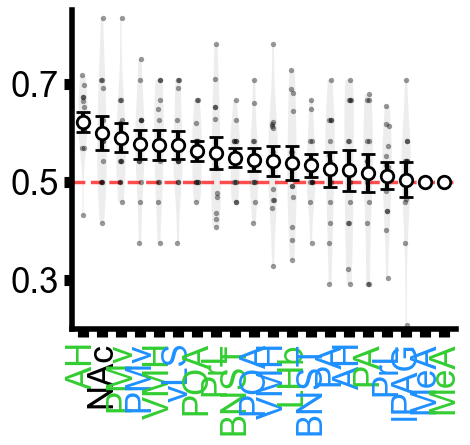

In [126]:
from scipy.stats import sem

# Plotting results from grid search
accuracies = np.array(results['region_accuracies'])
valid_mask = ~np.isnan(accuracies)
valid_accuracies = accuracies[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Sort by accuracy (descending)
sorting = np.argsort(valid_accuracies)[::-1]
sorted_accuracies = valid_accuracies[sorting]
sorted_indices = valid_indices[sorting]

# Calculate SEM from CV scores
stds = []
for idx in sorted_indices:
    cv_scores = results['region_cv_scores'][idx]
    if len(cv_scores) > 1:
        clean_scores = cv_scores[~np.isnan(cv_scores)]
        if len(clean_scores) > 1:
            stds.append(sem(clean_scores))
        else:
            stds.append(0)
    else:
        stds.append(0)
stds = np.array(stds)

n_valid_regions = len(sorted_accuracies)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(5.25, 5))

# ── Overlay individual fold scores as jittered scatter (behind mean marker) ──
rng = np.random.default_rng(42)
for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    cv_scores    = results['region_cv_scores'][idx]
    clean_scores = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
                   if len(cv_scores) > 0 else np.array([])
    if len(clean_scores) == 0:
        continue
    jitter = rng.uniform(-0.08, 0.08, size=len(clean_scores))
    ax.scatter(np.full(len(clean_scores), xpos) + jitter,
               clean_scores, color='black', s=15,
               alpha=0.4, zorder=3, linewidths=0)
    parts = ax.violinplot(clean_scores, positions=[xpos], widths=0.5,
                      showmeans=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('lightgray')
        pc.set_alpha(0.4)
        pc.set_zorder(1)
    

# ── Mean ± SEM marker ──────────────────────────────────────────────────────────
ax.errorbar(range(n_valid_regions), sorted_accuracies, yerr=stds,
           fmt='o', color='black', markerfacecolor='white',
           markersize=9, markeredgewidth=2,
           capsize=5, capthick=3, elinewidth=3, zorder=5)

# Create x-tick labels with colors based on cell type and remove parentheses
tick_labels = []
tick_colors = []
for i in sorted_indices:
    label = sig_regions_labels[i]
    clean_label = label.split('(')[0].strip()
    tick_labels.append(clean_label)

    if '(DA)' in label:
        tick_colors.append('black')
    elif '(E)' in label:
        tick_colors.append('limegreen')
    elif '(I)' in label:
        tick_colors.append('dodgerblue')
    else:
        tick_colors.append('black')

tick_labels = np.where(tick_labels == 'VMH', 'VMHvl', tick_labels)
tick_labels = np.where(tick_labels == 'PAG', 'lPAG', tick_labels)

ax.set_xticks(range(n_valid_regions))
ax.set_xticklabels(tick_labels, rotation=90, fontfamily='Arial')

for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
    tick_label.set_color(color)

plt.yticks([0.3, 0.5, 0.7], fontfamily='Arial')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Chance level (50%)')
ax.set_xlim(-0.6, n_valid_regions - 0.4)
ax.set_ylim(0.2, 0.85)
sns.despine()
plt.tight_layout()
# plt.savefig('./figure_updates/toy_vs_live_decoding.svg',
#            dpi=300, bbox_inches='tight', pad_inches=0.1)

In [127]:
all_pvals_full = results['region_pvalues']
valid_full_idx = [i for i, p in enumerate(all_pvals_full) if not np.isnan(p)]
p_fdr_full     = np.full(len(all_pvals_full), np.nan)
if valid_full_idx:
    _, corr_full, _, _ = multipletests(
        [all_pvals_full[i] for i in valid_full_idx], method='fdr_bh')
    for rank, i in enumerate(valid_full_idx):
        p_fdr_full[i] = corr_full[rank]

def clean_region_label(label):
    clean = label.split('(')[0].strip()
    if clean == 'VMH':
        clean = 'VMHvl'
    elif clean == 'PAG':
        clean = 'lPAG'
    return clean

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

rows = []

for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    label       = sig_regions_labels[idx]
    region_name = clean_region_label(label)
    channel     = channel_from_label(label)

    cv_scores   = results['region_cv_scores'][idx]
    clean_cv    = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] if len(cv_scores) > 0 else np.array([])

    acc     = results['region_accuracies'][idx]
    p_raw   = results['region_pvalues'][idx]
    p_final = p_fdr_full[idx]

    balbc_feat = np.nanmean(balbc_diff[:, :, idx], axis=1)
    toy_feat   = np.nanmean(toy_diff[:, :, idx], axis=1)
    n_balbc    = int(np.sum(~np.isnan(balbc_feat)))
    n_toy      = int(np.sum(~np.isnan(toy_feat)))

    if len(clean_cv) > 1:
        se_cv = sem(clean_cv)
        ci_lo, ci_hi = stats.t.interval(0.95, len(clean_cv) - 1, loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci_lo, ci_hi = np.nan, np.nan

    if len(clean_cv) >= 3:
        _, p_norm = stats.shapiro(clean_cv)
    else:
        p_norm = 0.0

    if p_norm > 0.05 and len(clean_cv) >= 3:
        stat_val, _ = stats.ttest_1samp(clean_cv, 0.5, alternative='greater')
        test_str = 't-test vs 0.5'
        df_val   = len(clean_cv) - 1
    else:
        try:
            stat_val, _ = stats.wilcoxon(clean_cv - 0.5, alternative='greater')
        except Exception:
            stat_val = np.nan
        test_str = 'Wilcoxon vs 0.5'
        df_val   = np.nan

    sig = get_sig(p_final) if not np.isnan(p_final) else 'n/a'

    for fold_idx, score in enumerate(clean_cv):
        rows.append({
            'x_position': xpos,
            'region': region_name,
            'channel': channel,
            'fold_idx': fold_idx,
            'cv_accuracy': score,
            'mean_accuracy': acc,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'test': test_str,
            'df': df_val,
            'stat': stat_val,
            'p_raw': p_raw,
            'p_fdr': p_final,
            'sig': sig,
            'n_balbc': n_balbc,
            'n_toy': n_toy,
            'n_folds': len(clean_cv),
        })

sourceData_3e = pd.DataFrame(rows)
sourceData_3e.to_csv('./sourceData/3e_left.csv', index=False)

In [142]:
# Compute activity for all regions
start = 240  # 0
stop = start + 40  # +1s
baseline = [120, 200]
balbc_diff = balbc_peths_across[:, start:stop]
toy_diff = glove_peths_across[:, start:stop]
mean_func = np.nanmean 

# Define regions to analyze
idxs2loop = np.array([8, 22, 16, 12, 17, 18])
pval_names = [region_ids[idx] for idx in idxs2loop]

# Collect all region data for analysis
all_region_data = []
for roi in idxs2loop:
    try:
        region_data = [
            mean_func(balbc_diff[:, :, roi], axis=1),  # BALBC data
            mean_func(toy_diff[:, :, roi], axis=1)   # TOY data
        ]
        all_region_data.append(region_data)
    except IndexError:
        region_data = [
            mean_func(balbc_diff[:, roi, :], axis=0),  # BALBC data
            mean_func(toy_diff[:, roi, :], axis=0)   # TOY data
        ]
        all_region_data.append(region_data)

# Run statistical analysis without multiple comparisons correction first
results_uncorrected = []
toy_pvals_uncorrected = []

for region_idx, region_data in enumerate(all_region_data):
    region_results = toy_stats(region_data, alpha=0.05)
    results_uncorrected.append(region_results)
    
    # Collect uncorrected p-values separately
    toy_pvals_uncorrected.append(region_results['balbc_vs_toy']['p_value'])

# Apply separate multiple comparisons corrections
toy_rejected, toy_pvals_corrected, _, _ = multipletests(toy_pvals_uncorrected, method='fdr_bh', alpha=0.05)

# Extract results for display with separate corrections
prep_pvals_corrected_TOY = toy_pvals_corrected
prep_effect_sizes_TOY = []
prep_test_types_TOY = []
prep_tvals_TOY = []

for region_results in results_uncorrected:
    # TOY vs BALBC
    toy_result = region_results['balbc_vs_toy']
    prep_effect_sizes_TOY.append(toy_result['effect_size'])
    prep_test_types_TOY.append(toy_result['test_type'])
    prep_tvals_TOY.append(toy_result['statistic'])

# Convert to numpy arrays
prep_pvals_corrected_TOY = np.array(prep_pvals_corrected_TOY)

### Display results with enhanced information
print("=== TOY STIM STATISTICS (SEPARATE CORRECTIONS) ===")
print(f"TOY comparisons corrected across {len(toy_pvals_uncorrected)} regions")
print()

print("\n### BALBC vs TOY ###")
for i, region_name in enumerate(pval_names):
    significance = "***" if prep_pvals_corrected_TOY[i] < 0.001 else "**" if prep_pvals_corrected_TOY[i] < 0.01 else "*" if prep_pvals_corrected_TOY[i] < 0.05 else "ns"
    direction = results_uncorrected[i]['balbc_vs_toy']['direction']
    print(f'{region_name} BALBC vs TOY: {prep_test_types_TOY[i]}, '
          f'statistic = {prep_tvals_TOY[i]:.3f}, '
          f'p_uncorrected = {toy_pvals_uncorrected[i]:.6f}, '
          f'p_corrected = {prep_pvals_corrected_TOY[i]:.6f} {significance}, '
          f'effect_size = {prep_effect_sizes_TOY[i]:.3f}, '
          f'direction: {direction}')

# Print summary of significant results
print(f"\n=== SUMMARY ===")
toy_significant = np.sum(prep_pvals_corrected_TOY < 0.05)
print(f"TOY vs BALBC: {toy_significant}/{len(pval_names)} regions significant (separate correction)")

# Compare with joint correction impact
print(f"\nUncorrected significant:")
print(f"TOY vs BALBC: {np.sum(np.array(toy_pvals_uncorrected) < 0.05)}/{len(pval_names)} regions")

# Display regions with strongest effects
print(f"\n=== TOP REGIONS BY EFFECT SIZE ===")
toy_sorted_idx = np.argsort(np.abs(prep_effect_sizes_TOY))[::-1]

print("TOY (top 5 by effect size):")
for i in toy_sorted_idx[:5]:
    if prep_pvals_corrected_TOY[i] < 0.05:
        print(f"  {pval_names[i]}: effect = {prep_effect_sizes_TOY[i]:.3f}, p = {prep_pvals_corrected_TOY[i]:.4f}")

=== TOY STIM STATISTICS (SEPARATE CORRECTIONS) ===
TOY comparisons corrected across 6 regions


### BALBC vs TOY ###
AH (E) BALBC vs TOY: Brunner-Munzel, statistic = -2.120, p_uncorrected = 0.017992, p_corrected = 0.034278 *, effect_size = 0.161, direction: BALBC > TOY
NAc (DA) BALBC vs TOY: Brunner-Munzel, statistic = -2.408, p_uncorrected = 0.008691, p_corrected = 0.026073 *, effect_size = 0.178, direction: BALBC > TOY
PMv (E) BALBC vs TOY: Brunner-Munzel, statistic = -2.731, p_uncorrected = 0.003569, p_corrected = 0.021413 *, effect_size = 0.198, direction: BALBC > TOY
VMH (E) BALBC vs TOY: Brunner-Munzel, statistic = -1.811, p_uncorrected = 0.036234, p_corrected = 0.043480 *, effect_size = 0.142, direction: BALBC > TOY
PMv (I) BALBC vs TOY: Brunner-Munzel, statistic = -2.018, p_uncorrected = 0.022852, p_corrected = 0.034278 *, effect_size = 0.154, direction: BALBC > TOY
LHb (E) BALBC vs TOY: Brunner-Munzel, statistic = -0.798, p_uncorrected = 0.213196, p_corrected = 0.213196 ns, ef

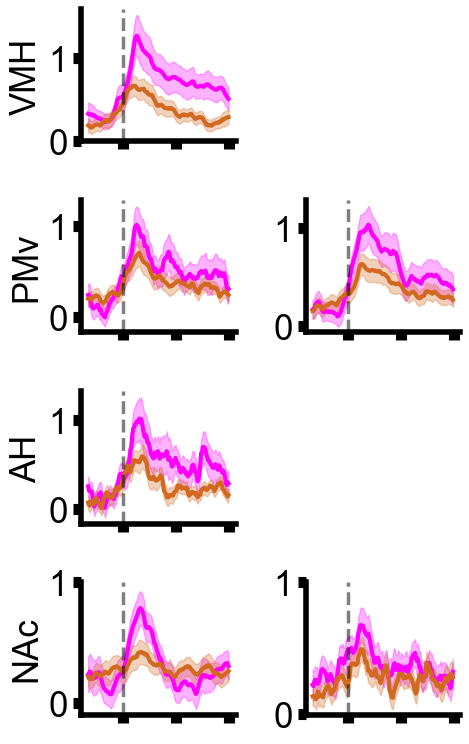

In [143]:
# Compare toy and balbc PETHs
 
from matplotlib.ticker import MaxNLocator
start_idx = 200
end_idx = 360
periods = [start_idx, end_idx] 
n = periods[1] - periods[0]
 
fig, ax = plt.subplots(4, 2, figsize=(5.25, 8))
sorting = [12, 16, 8, 22]
obs_color = 'magenta'
non_color='chocolate' # actually toy stim
 
def add_significance_to_plot(ax, post_pval, ylim_top, n):
    """Add significance asterisks to plot"""
    def get_sig_marker(p):
        if p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        else:
            return ''
    
    # Post-attack significance
    post_marker = get_sig_marker(post_pval)
    if post_marker:
        ax.text(60, ylim_top, post_marker, ha='center', va='bottom', fontsize=12, fontweight='bold')
 
for i, r in enumerate(sorting):
    try:
        # plot exc.
        obs_E = balbc_peths_across[:, :, r] - np.nanmedian(balbc_peths_across[:, baseline[0]:baseline[1], r]).reshape(-1,1)
        non_E = glove_peths_across[:, :, r] - np.nanmedian(glove_peths_across[:, baseline[0]:baseline[1], r]).reshape(-1,1)
        ax[i, 0].plot(np.nanmean(obs_E, axis=0)[periods[0]:periods[1]], label='obs', color=obs_color,
        linewidth=3)
        ax[i, 0].fill_between(range(n), np.nanmean(obs_E, axis=0)[periods[0]:periods[1]] - np.nanstd(obs_E, axis=0)[periods[0]:periods[1]]/np.sqrt(obs_E.shape[0]),
        np.nanmean(obs_E, axis=0)[periods[0]:periods[1]] + np.nanstd(obs_E, axis=0)[periods[0]:periods[1]]/np.sqrt(obs_E.shape[0]), alpha=0.3, color=obs_color)
        ax[i, 0].plot(np.nanmean(non_E, axis=0)[periods[0]:periods[1]], label='non', color=non_color,
        linewidth=3)
        ax[i, 0].fill_between(range(n), np.nanmean(non_E, axis=0)[periods[0]:periods[1]] - np.nanstd(non_E, axis=0)[periods[0]:periods[1]]/np.sqrt(non_E.shape[0]),
        np.nanmean(non_E, axis=0)[periods[0]:periods[1]] + np.nanstd(non_E, axis=0)[periods[0]:periods[1]]/np.sqrt(non_E.shape[0]), alpha=0.3, color=non_color)
        ax[i, 0].axvline(40, linestyle='--', color='black', alpha=0.5)
        ax[i, 0].set_xticks([40, 100, 160], ['', '', ''])
        ax[i, 0].set_yticks([0, 1.0])
 
        # plot inh.
        obs_I = balbc_peths_across[:, :, r+1] - np.nanmedian(balbc_peths_across[:, baseline[0]:baseline[1], r+1]).reshape(-1,1)
        non_I = glove_peths_across[:, :, r+1] - np.nanmedian(glove_peths_across[:, baseline[0]:baseline[1], r+1]).reshape(-1,1)
        ax[i, 1].plot(np.nanmean(obs_I, axis=0)[periods[0]:periods[1]], label='obs', color=obs_color,
        linewidth=3)
        ax[i, 1].fill_between(range(n), np.nanmean(obs_I, axis=0)[periods[0]:periods[1]] - np.nanstd(obs_I, axis=0)[periods[0]:periods[1]]/np.sqrt(obs_I.shape[0]),
        np.nanmean(obs_I, axis=0)[periods[0]:periods[1]] + np.nanstd(obs_I, axis=0)[periods[0]:periods[1]]/np.sqrt(obs_I.shape[0]), alpha=0.3, color=obs_color)
        ax[i, 1].plot(np.nanmean(non_I, axis=0)[periods[0]:periods[1]], label='non', color=non_color,
        linewidth=3)
        ax[i, 1].fill_between(range(n), np.nanmean(non_I, axis=0)[periods[0]:periods[1]] - np.nanstd(non_I, axis=0)[periods[0]:periods[1]]/np.sqrt(non_I.shape[0]),
        np.nanmean(non_I, axis=0)[periods[0]:periods[1]] + np.nanstd(non_I, axis=0)[periods[0]:periods[1]]/np.sqrt(non_I.shape[0]), alpha=0.3, color=non_color)
        ax[i, 1].axvline(40, linestyle='--', color='black', alpha=0.5)
        ax[i, 1].set_xticks([40, 100, 160], ['', '', ''])
        ax[i, 1].set_yticks([0, 1.0])
        ax[i, 0].set_ylabel(region_ids[r].replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''), fontfamily='Arial')
 
    except IndexError:
        continue

# Plot LHb next to NAc
obs_E = balbc_peths_across[:, :, 18] - np.nanmedian(balbc_peths_across[:, baseline[0]:baseline[1], 18]).reshape(-1,1)
non_E = glove_peths_across[:, :, 18] - np.nanmedian(glove_peths_across[:, baseline[0]:baseline[1], 18]).reshape(-1,1)
ax[3, 1].plot(np.nanmean(obs_E, axis=0)[periods[0]:periods[1]], label='obs', color=obs_color,
linewidth=3)
ax[3, 1].fill_between(range(n), np.nanmean(obs_E, axis=0)[periods[0]:periods[1]] - np.nanstd(obs_E, axis=0)[periods[0]:periods[1]]/np.sqrt(obs_E.shape[0]),
np.nanmean(obs_E, axis=0)[periods[0]:periods[1]] + np.nanstd(obs_E, axis=0)[periods[0]:periods[1]]/np.sqrt(obs_E.shape[0]), alpha=0.3, color=obs_color)
ax[3, 1].plot(np.nanmean(non_E, axis=0)[periods[0]:periods[1]], label='non', color=non_color,
linewidth=3)
ax[3, 1].fill_between(range(n), np.nanmean(non_E, axis=0)[periods[0]:periods[1]] - np.nanstd(non_E, axis=0)[periods[0]:periods[1]]/np.sqrt(non_E.shape[0]),
np.nanmean(non_E, axis=0)[periods[0]:periods[1]] + np.nanstd(non_E, axis=0)[periods[0]:periods[1]]/np.sqrt(non_E.shape[0]), alpha=0.3, color=non_color)
ax[3, 1].axvline(40, linestyle='--', color='black', alpha=0.5)
ax[3, 1].set_xticks([40, 100, 160], ['', '', ''])
ax[3, 1].set_yticks([0, 1.0])
 
sns.despine()
# Add sig stars
fig.delaxes(ax[0, 1])
fig.delaxes(ax[2, 1])
# fig.delaxes(ax[3, 1])
ax[3, 0].set_ylabel('NAc');
fig.subplots_adjust(wspace=0.7, hspace=0.25)
plt.tight_layout()
# plt.savefig('./figures/fig3alt/toy_stim_results.svg', dpi=300)
# plt.tight_layout()
 

In [144]:
start_idx, end_idx = 200, 360
periods_3e = [start_idx, end_idx]
n_3e = periods_3e[1] - periods_3e[0]

panel_regions = [
    ('VMHvl (E)', 12), ('PMv (E)', 16), ('PMv (I)', 17),
    ('AH (E)', 8), ('NAc (DA)', 22), ('LHb (E)', 18),
]

region_stats_lookup = {}
for i, ridx in enumerate(idxs2loop):
    region_stats_lookup[ridx] = {
        'test': prep_test_types_TOY[i], 'stat': prep_tvals_TOY[i],
        'p_raw': toy_pvals_uncorrected[i], 'p_fdr': prep_pvals_corrected_TOY[i],
        'effect_size': prep_effect_sizes_TOY[i],
    }

rows = []
for region_label, r in panel_regions:
    balbc_full = balbc_peths_across[:, :, r] - \
                 np.nanmedian(balbc_peths_across[:, baseline[0]:baseline[1], r]).reshape(-1, 1)
    toy_full   = glove_peths_across[:, :, r] - \
                 np.nanmedian(glove_peths_across[:, baseline[0]:baseline[1], r]).reshape(-1, 1)

    balbc_slice = balbc_full[:, periods_3e[0]:periods_3e[1]].T  # (n_timepoints, n_trials)
    toy_slice   = toy_full[:, periods_3e[0]:periods_3e[1]].T

    balbc_mean = np.nanmean(balbc_slice, axis=1)
    balbc_sem  = np.nanstd(balbc_slice, axis=1) / np.sqrt(balbc_slice.shape[1])
    toy_mean   = np.nanmean(toy_slice, axis=1)
    toy_sem    = np.nanstd(toy_slice, axis=1) / np.sqrt(toy_slice.shape[1])

    sr = region_stats_lookup.get(r, {})

    for t in range(n_3e):
        row = {
            'region': region_label, 'timepoint': t,
            'balbc_mean': balbc_mean[t], 'balbc_sem': balbc_sem[t],
            'toy_mean': toy_mean[t], 'toy_sem': toy_sem[t],
            'test': sr.get('test', np.nan), 'stat': sr.get('stat', np.nan),
            'p_raw': sr.get('p_raw', np.nan), 'p_fdr': sr.get('p_fdr', np.nan),
            'effect_size': sr.get('effect_size', np.nan),
        }
        for a in range(balbc_slice.shape[1]):
            row[f'balbc_trial_{a}'] = balbc_slice[t, a]
        for a in range(toy_slice.shape[1]):
            row[f'toy_trial_{a}'] = toy_slice[t, a]
        rows.append(row)

sourceData_3e_right = pd.DataFrame(rows)
sourceData_3e_right.to_csv('./sourceData/3e_right.csv', index=False)

### Mapping neural responses when observed aggressor is familiar vs. novel

In [145]:
# Load data
fam_vs_novel = pd.read_pickle('familiar-vs-novel-attacks.pickle')

In [146]:
# Extract aggression windows for each animal and align activity to those windows

fam_vs_novel_dict = {}

for key in fam_vs_novel.keys():
    sample = fam_vs_novel[key].to_numpy()
    sample = sample.reshape(sample.shape[0], 24, 1)
    X, y = produce_XY(sample)
    y = y.ravel()
    X = X.T

    try:
        on, off = find_window_of_behavior(y, label_ID=1, window_size=window_size, window_of_separation=240, min_segment_length=2) # 3 is aggression
        
        for i, lst in enumerate(on):
            if len(lst) < window_size:
                mean_val = sum(lst) / len(lst)
                on[i] = list(lst) + [mean_val] * (window_size - len(lst))

        aggression_windows = np.asarray(on)
        traces4beh = np.zeros((aggression_windows.shape[0], aggression_windows.shape[1], 23))
        traces4beh[:] = np.nan

        for i, region in enumerate(np.arange(23)):
            trace = X[i, :]
            for j, window in enumerate(aggression_windows):
                window = window.astype(int)
                t = trace[window]
                traces4beh[j, :, region] = t
                
    except IndexError:
        # Create empty array for epochs with no attacks
        traces4beh = np.zeros((1, window_size, 23))
        traces4beh[:] = np.nan

    fam_vs_novel_dict[key] = traces4beh # dictionary of each animal with all of their aggression windows by day

familiar_dict = {}
novel_dict = {}

for key, value in fam_vs_novel_dict.items():
    if 'familiar1' in key:
        familiar_dict[key] = value
    elif 'novel1' in key:
        novel_dict[key] = value

In [147]:
# Data formatting

# Familiar data
familiar_data = np.concatenate([familiar_dict[key] for key in list(familiar_dict.keys())], axis=0)
clean_familiar_data = []
preserved_idxs = []
for row in range(familiar_data.shape[0]):
    if np.isnan(familiar_data[row]).any() == False:
        clean_familiar_data.append(familiar_data[row, :, :])
        preserved_idxs.append(row)
clean_familiar_data = [x.reshape(1, window_size, 23) for x in clean_familiar_data]
clean_familiar_data = np.concatenate(clean_familiar_data, axis=0)

# Novel data
novel_data = np.concatenate([novel_dict[key] for key in list(novel_dict.keys())], axis=0)
clean_novel_data = []
preserved_idxs = []
for row in range(novel_data.shape[0]):
    if np.isnan(novel_data[row]).any() == False:
        clean_novel_data.append(novel_data[row, :, :])
        preserved_idxs.append(row)
clean_novel_data = [x.reshape(1, window_size, 23) for x in clean_novel_data]
clean_novel_data = np.concatenate(clean_novel_data, axis=0)

In [148]:
# Apply shifting

# Reset OBS model
_, _ = trained_obs_model.fit_transform(clean_obs_data)

# Apply OBS model to both datasets
familiar_heldover_new_data, familiar_heldover_new_shifts, familiar_heldover_clean_mask = trained_obs_model.align_to_template(clean_familiar_data)
print(f"Aligned {familiar_heldover_new_data.shape[0]} heldover trials to OBS template")

novel_heldover_new_data, novel_heldover_new_shifts, novel_heldover_clean_mask = trained_obs_model.align_to_template(clean_novel_data)
print(f"Aligned {novel_heldover_new_data.shape[0]} heldover trials to OBS template")

Removing 4 artifact trials out of 1147 total


Loss: 1.20: 100%|██████████| 5/5 [00:01<00:00,  4.09it/s]

Set 389 boundary shifts to zero (threshold: 75.600)
Removing 0 artifact trials out of 50 total
Finding optimal shifts for 50 new trials...
Set 6 boundary shifts to zero (threshold: 75.600)
New shifts range: -86.0 to 86.0
Mean new shift: -10.04 ± 33.63
Corrected 6 boundary shifts
Aligned 50 heldover trials to OBS template
Removing 0 artifact trials out of 77 total
Finding optimal shifts for 77 new trials...
Set 7 boundary shifts to zero (threshold: 75.600)
New shifts range: -86.0 to 86.0
Mean new shift: -8.17 ± 32.91
Corrected 7 boundary shifts
Aligned 77 heldover trials to OBS template


In [149]:
# PETHs - familiar
familiar_attack_idxs = [x.shape[0] for x in [familiar_dict[key] for key in familiar_dict.keys()]]
z_familiar = np.insert(np.cumsum(familiar_attack_idxs), 0, 0)
TW_familiar_dict = {}
for t, trials in enumerate(z_familiar[:-1]):
    TW_familiar_dict['mouse%i' % t] = familiar_heldover_new_data[z_familiar[t]:z_familiar[t+1], :, :]
familiar_peths_across = compute_peths_across_all_trials(TW_familiar_dict, region_ids, window_size=window_size)
familiar_peths = compute_peths(TW_familiar_dict, region_ids, window_size=window_size)

# PETHs - novel
novel_attack_idxs = [x.shape[0] for x in [novel_dict[key] for key in novel_dict.keys()]]
z_novel = np.insert(np.cumsum(novel_attack_idxs), 0, 0)
TW_novel_dict = {}
for t, trials in enumerate(z_novel[:-1]):
    TW_novel_dict['mouse%i' % t] = novel_heldover_new_data[z_novel[t]:z_novel[t+1], :, :]
novel_peths_across = compute_peths_across_all_trials(TW_novel_dict, region_ids, window_size=window_size)
novel_peths = compute_peths(TW_novel_dict, region_ids, window_size=window_size)


In [150]:
# Familiar vs novel decoding

# Define data
start = 240  # 0
stop = start + 40  # +1s
baseline = [120, 200]
familiar_diff = familiar_peths_across[:, start:stop] - np.nanmedian(familiar_peths_across[:, baseline[0]:baseline[1]], keepdims=True)
novel_diff = novel_peths_across[:, start:stop] - np.nanmedian(novel_peths_across[:, baseline[0]:baseline[1]], keepdims=True)

# Verify optimal number of splits
def evaluate_cv_splits(X, y, model, split_range=range(2, 21)):
    results = []
    for k in split_range:
        if k > len(y):  # Can't have more splits than samples
            continue
        scores = cross_val_score(model, X, y, cv=k, scoring='balanced_accuracy')
        results.append({
            'k': k,
            'mean_score': np.mean(scores),
            'std_score': np.std(scores),
            'scores': scores
        })
    return results

# Inits
random_state = 42
E_idxs = [12, 16, 8, 4, 10, 20, 6, 0, 18, 22]
I_idxs = [13, 17, 9, 5, 11, 21, 7, 15, 3, 1]
sig_regions = np.sort(np.array(E_idxs+I_idxs))
sig_regions_labels = [region_ids[idx] for idx in sig_regions]
print("Significant OBS regions:", sig_regions_labels)


# Define parameter grid for L1 regularized logistic regression
param_grid = {
    'classifier__C': [0.0001, 0.01, 0.1, 1.0, 10.0, 1e3, 1e5], 
    'classifier__penalty': ['l1', 'l2'],  # L1 and L2 regularization    
    'classifier__solver': ['liblinear']
}

results = {
    'region_accuracies': [],
    'region_best_params': [],
    'region_cv_scores': [],
    'region_grid_scores': [],
    'region_pvalues': [],
    'region_significant': []
}

print(f"Parameter grid: C = {param_grid['classifier__C']}, penalty = {param_grid['classifier__penalty']}")

for region in sig_regions:
    print(f"Processing region {region_ids[region]}...")

    # Use mean activity across time window
    familiar_features = np.nanmean(familiar_diff[:, :, region], axis=1).reshape(-1, 1)
    novel_features = np.nanmean(novel_diff[:, :, region], axis=1).reshape(-1, 1)
    
    # Combine features and create labels
    X = np.vstack([familiar_features, novel_features])
    y = np.concatenate([np.zeros(familiar_features.shape[0]), 
                        np.ones(novel_features.shape[0])])
    
    # Remove NaN rows
    valid_mask = ~np.any(np.isnan(X), axis=1) & ~np.any(np.isinf(X), axis=1)
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    # Create pipeline with scaling and L1 Logistic Regression
    pipeline = Pipeline([
        ('classifier', LogisticRegression(
            class_weight='balanced', 
            random_state=random_state,
            max_iter=1000  # Increase iterations for convergence
        ))
    ])

    prelim = evaluate_cv_splits(X_clean, y_clean, pipeline, split_range=range(12, 14))
    splits = np.argmax([res['mean_score'] for res in prelim])
    splits = prelim[splits]['k']
    print(f"Selected {splits}-fold cross-validation based on evaluation.")
    
    # Use stratified k-fold cross-validation for grid search
    cv = StratifiedKFold(n_splits=splits, shuffle=True, random_state=random_state)
    
    try:
        # Perform grid search
        grid_search = GridSearchCV(
            pipeline, 
            param_grid, 
            cv=cv, 
            scoring='balanced_accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_clean, y_clean)
        
        # Get best results
        best_score = grid_search.best_score_
        best_params = grid_search.best_params_
        
        # Get all CV results for the best model
        best_estimator = grid_search.best_estimator_
        final_cv_scores = cross_val_score(
            best_estimator, X_clean, y_clean, 
            cv=cv, scoring='balanced_accuracy'
        )
        
        # ── Normality check → t-test or Wilcoxon against 0.5 ─────────────────
        clean_cv = final_cv_scores[~np.isnan(final_cv_scores)]
        shifted  = clean_cv - 0.5

        if len(clean_cv) >= 3:
            _, p_norm = stats.shapiro(clean_cv)
        else:
            p_norm = 0.0

        if p_norm > 0.05 and len(clean_cv) >= 3:
            t_stat, p_value = stats.ttest_1samp(clean_cv, 0.5,
                                                  alternative='greater')
            df_val     = len(clean_cv) - 1
            test_label = 't-test'
        else:
            try:
                t_stat, p_value = stats.wilcoxon(shifted,
                                                   alternative='greater')
            except ValueError:
                t_stat, p_value = np.nan, np.nan
            df_val     = None
            test_label = 'Wilcoxon'

        is_significant = p_value < 0.05 if not np.isnan(p_value) else False

        mean_score = np.mean(clean_cv)
        sem        = stats.sem(clean_cv)
        ci_95      = stats.t.interval(0.95, len(clean_cv) - 1,
                                       loc=mean_score, scale=sem) \
                     if len(clean_cv) > 1 else (np.nan, np.nan)

        df_str = f'df={df_val}' if df_val is not None else 'n/a'
        print(f"  Best CV score : {best_score:.3f} "
              f"(95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  Normality p   : {p_norm:.4f} "
              f"({'normal' if p_norm > 0.05 else 'non-normal'})")
        print(f"  Test          : {test_label}, "
              f"stat={t_stat:.3f}, {df_str}, "
              f"p={p_value:.4f}, sig={is_significant}")

        # store test metadata alongside existing results
        results.setdefault('region_test_labels', []).append(test_label)
        results.setdefault('region_test_stats',  []).append(t_stat)
        results.setdefault('region_test_dfs',    []).append(df_val)
        results.setdefault('region_cv_scores_clean', []).append(clean_cv)
        
        # Store detailed grid search results with 95% CI
        grid_results = {}
        for params, mean_score_grid, std_score in zip(
            grid_search.cv_results_['params'],
            grid_search.cv_results_['mean_test_score'],
            grid_search.cv_results_['std_test_score']
        ):
            param_key = f"C={params['classifier__C']}, penalty={params['classifier__penalty']}"
            # Calculate 95% CI for grid search results (assuming normal distribution)
            n_folds = cv.get_n_splits()
            sem_grid = std_score / np.sqrt(n_folds)
            ci_95_grid = stats.norm.interval(0.95, loc=mean_score_grid, scale=sem_grid)
            
            grid_results[param_key] = {
                'mean_score': mean_score_grid,
                'ci_95': ci_95_grid
            }
        
        results['region_accuracies'].append(best_score)
        results['region_best_params'].append(best_params)
        results['region_cv_scores'].append(final_cv_scores)
        results['region_grid_scores'].append(grid_results)
        results['region_pvalues'].append(p_value)
        results['region_significant'].append(is_significant)
        
        print(f"  Best CV score: {best_score:.3f} (95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  Statistical test: t={t_stat:.3f}, p={p_value:.4f}, significant={is_significant}")
        
    except Exception as e:
        print(f"  Error: {e}")
        results['region_accuracies'].append(np.nan)
        results['region_best_params'].append({})
        results['region_cv_scores'].append([])
        results['region_grid_scores'].append({})
        results['region_pvalues'].append(np.nan)
        results['region_significant'].append(False)

# Summary with statistical validation
accuracies = [acc for acc in results['region_accuracies'] if not np.isnan(acc)]
pvalues_unfilt = [p for p in results['region_pvalues']]
pvalues = [p for p in results['region_pvalues'] if not np.isnan(p)]
significant_regions = np.sum(results['region_significant'])

if accuracies:
    above_chance = np.sum(np.array(accuracies) > 0.5)
    print(f"\nSUMMARY:")
    print(f"Regions above chance (>50%): {above_chance}/{len(accuracies)}")
    print(f"Regions with significant decoding (p<0.05): {significant_regions}/{len(accuracies)}")
    print(f"Mean accuracy: {np.mean(accuracies):.3f}")
    print(f"Best accuracy: {np.max(accuracies):.3f}")
    
    # Show best performing regions with statistical info
    best_indices = np.where(np.array(results['region_accuracies']) > 0.5)[0]
    sig_pvalues = [results['region_pvalues'][i] for i in best_indices]
    sig_pvalues_corrected = multipletests(sig_pvalues, method='fdr_bh', alpha=0.05)[1]
    print(f"\nAbove chance regions with statistical validation:")
    for i in best_indices:
        if not np.isnan(results['region_accuracies'][i]):
            acc = results['region_accuracies'][i]
            cv_scores = results['region_cv_scores'][i]
            p_val = results['region_pvalues'][i]
            is_sig = results['region_significant'][i]
            p_val_corrected = sig_pvalues_corrected[best_indices.tolist().index(i)] if i in best_indices.tolist() else None
            # Use corrected p-value if available
            p_val = p_val_corrected if p_val_corrected is not None else p_val
            # Calculate 95% CI
            mean_score = np.mean(cv_scores)
            sem = stats.sem(cv_scores)
            ci_95 = stats.t.interval(0.95, len(cv_scores)-1, loc=mean_score, scale=sem)
            
            sig_marker = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
            print(f"  {sig_regions_labels[i]}: {acc:.3f} [{ci_95[0]:.3f}, {ci_95[1]:.3f}] p={p_val:.4f} {sig_marker}")
    
    # Show parameter preferences
    print(f"\nParameter preferences across all regions:")
    all_c_values = []
    for params in results['region_best_params']:
        if params:  # Skip empty dicts
            all_c_values.append(params.get('classifier__C'))
    
    c_counts = Counter(all_c_values)
    print(f"  C values: {dict(c_counts)}")

# Show detailed grid search results for best region with 95% CI
best_region_idx = np.nanargmax(results['region_accuracies'])
if not np.isnan(results['region_accuracies'][best_region_idx]):
    print(f"\nDetailed grid search for best region ({region_ids[best_region_idx]}):")
    for param_combo, scores in results['region_grid_scores'][best_region_idx].items():
        mean_score = scores['mean_score']
        ci_95 = scores['ci_95']
        print(f"  {param_combo}: {mean_score:.3f} [95% CI: {ci_95[0]:.3f}, {ci_95[1]:.3f}]")

Significant OBS regions: ['PrL (E)', 'PrL (I)', 'vLS (I)', 'POA (E)', 'POA (I)', 'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)', 'VMH (E)', 'VMH (I)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'PA (E)', 'PA (I)', 'NAc (DA)']
Parameter grid: C = [0.0001, 0.01, 0.1, 1.0, 10.0, 1000.0, 100000.0], penalty = ['l1', 'l2']
Processing region PrL (E)...
Selected 13-fold cross-validation based on evaluation.
  Best CV score : 0.604 (95% CI: [0.519, 0.690])
  Normality p   : 0.9007 (normal)
  Test          : t-test, stat=2.668, df=12, p=0.0102, sig=True
  Best CV score: 0.604 (95% CI: [0.519, 0.690])
  Statistical test: t=2.668, p=0.0102, significant=True
Processing region PrL (I)...
Selected 12-fold cross-validation based on evaluation.
  Best CV score : 0.608 (95% CI: [0.506, 0.710])
  Normality p   : 0.0227 (non-normal)
  Test          : Wilcoxon, stat=54.500, n/a, p=0.0278, sig=True
  Best CV score: 0.608 (95% CI: [0.506, 0.710])
  Statistical test: t=54.500, p=0.0278, sig

In [151]:
# ── Full stats table — familiar vs novel decoding ─────────────────────────────
print(f'\n{"="*100}')
print(f'Familiar vs Novel decoding — full statistics table')
print(f'Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5')
print(f'Correction: FDR-BH across all {len(sig_regions)} regions')
print(f'{"="*100}')
print(f'{"Region":<22} {"Acc":>6} {"CI_lo":>7} {"CI_hi":>7} '
      f'{"Test":<10} {"df":>5} {"stat":>8} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5} '
      f'{"n_fam":>7} {"n_nov":>7} {"n_folds":>8}')
print(f'{"─"*100}')

# ── FDR across all regions ────────────────────────────────────────────────────
all_pvals_raw = results['region_pvalues']
valid_idx     = [i for i, p in enumerate(all_pvals_raw) if not np.isnan(p)]
p_fdr_arr     = np.full(len(all_pvals_raw), np.nan)
if valid_idx:
    _, corr, _, _ = multipletests(
        [all_pvals_raw[i] for i in valid_idx], method='fdr_bh')
    for rank, i in enumerate(valid_idx):
        p_fdr_arr[i] = corr[rank]

for i, region in enumerate(sig_regions):
    label      = sig_regions_labels[i]
    acc        = results['region_accuracies'][i]
    cv_scores  = results['region_cv_scores_clean'][i] \
                 if 'region_cv_scores_clean' in results \
                 else np.array(results['region_cv_scores'][i])
    p_raw      = all_pvals_raw[i]
    p_fdr      = p_fdr_arr[i]
    test_label = results['region_test_labels'][i] \
                 if 'region_test_labels' in results else 'n/a'
    t_stat_val = results['region_test_stats'][i] \
                 if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][i] \
                 if 'region_test_dfs' in results else None

    # sample sizes
    fam_feat = np.nanmean(familiar_diff[:, :, region], axis=1)
    nov_feat = np.nanmean(novel_diff[:,   :, region], axis=1)
    n_fam    = int(np.sum(~np.isnan(fam_feat)))
    n_nov    = int(np.sum(~np.isnan(nov_feat)))
    n_folds  = len(cv_scores) if len(cv_scores) > 0 else 0

    if np.isnan(acc):
        print(f'  {label:<20} {"error":>6}')
        continue

    # CI
    if len(cv_scores) > 1:
        se_cv = stats.sem(cv_scores)
        ci    = stats.t.interval(0.95, len(cv_scores) - 1,
                                  loc=np.mean(cv_scores), scale=se_cv)
    else:
        ci = (np.nan, np.nan)

    df_str  = str(df_val)  if df_val  is not None     else 'n/a'
    sig     = get_sig(p_fdr) if not np.isnan(p_fdr)   else 'n/a'

    def _f(v): return f'{v:.3f}' if not np.isnan(v) else '  n/a'

    print(f'  {label:<20} {acc:>6.3f} {_f(ci[0]):>7} {_f(ci[1]):>7} '
          f'{test_label:<10} {df_str:>5} {_f(t_stat_val):>8} '
          f'{p_raw:>10.4f} {p_fdr:>10.4f} {sig:>5} '
          f'{n_fam:>7} {n_nov:>7} {n_folds:>8}')

print(f'{"="*100}')
print(f'Note: p_fdr = FDR-BH corrected across all {len(valid_idx)} regions with valid p-values.')


Familiar vs Novel decoding — full statistics table
Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5
Correction: FDR-BH across all 20 regions
Region                    Acc   CI_lo   CI_hi Test          df     stat      p_raw      p_fdr   Sig   n_fam   n_nov  n_folds
────────────────────────────────────────────────────────────────────────────────────────────────────
  PrL (E)               0.604   0.519   0.690 t-test        12    2.668     0.0102     0.0216     *      50      77       13
  PrL (I)               0.608   0.506   0.710 Wilcoxon     n/a   54.500     0.0278     0.0378     *      50      77       12
  vLS (I)               0.588   0.510   0.667 t-test        12    2.462     0.0150     0.0237     *      50      77       13
  POA (E)               0.529   0.436   0.623 t-test        11    0.687     0.2532     0.2532    ns      50      77       12
  POA (I)               0.535   0.430   0.640 t-test        12    0.719     0.2431     0.25

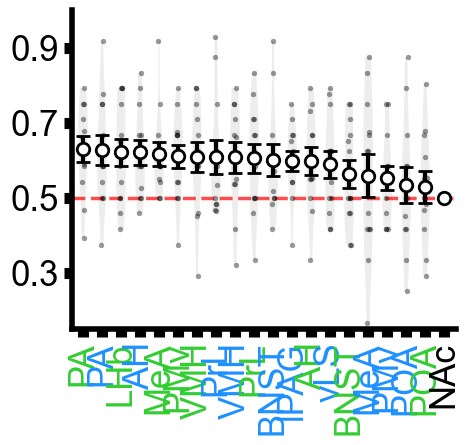

In [152]:
from scipy.stats import sem

# Plotting results from grid search
accuracies = np.array(results['region_accuracies'])
valid_mask = ~np.isnan(accuracies)
valid_accuracies = accuracies[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Sort by accuracy (descending)
sorting = np.argsort(valid_accuracies)[::-1]
sorted_accuracies = valid_accuracies[sorting]
sorted_indices = valid_indices[sorting]

# Calculate SEM from CV scores
stds = []
for idx in sorted_indices:
    cv_scores = results['region_cv_scores'][idx]
    if len(cv_scores) > 1:
        clean_scores = cv_scores[~np.isnan(cv_scores)]
        if len(clean_scores) > 1:
            stds.append(sem(clean_scores))
        else:
            stds.append(0)
    else:
        stds.append(0)
stds = np.array(stds)

n_valid_regions = len(sorted_accuracies)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(5.25, 5))

# ── Overlay individual fold scores as jittered scatter (behind mean marker) ──
rng = np.random.default_rng(42)
for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    cv_scores    = results['region_cv_scores'][idx]
    clean_scores = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
                   if len(cv_scores) > 0 else np.array([])
    if len(clean_scores) == 0:
        continue
    jitter = rng.uniform(-0.08, 0.08, size=len(clean_scores))
    ax.scatter(np.full(len(clean_scores), xpos) + jitter,
               clean_scores, color='black', s=15,
               alpha=0.4, zorder=3, linewidths=0)
    parts = ax.violinplot(clean_scores, positions=[xpos], widths=0.5,
                      showmeans=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('lightgray')
        pc.set_alpha(0.4)
        pc.set_zorder(1)
    

# ── Mean ± SEM marker ──────────────────────────────────────────────────────────
ax.errorbar(range(n_valid_regions), sorted_accuracies, yerr=stds,
           fmt='o', color='black', markerfacecolor='white',
           markersize=9, markeredgewidth=2,
           capsize=5, capthick=3, elinewidth=3, zorder=5)

# Create x-tick labels with colors based on cell type and remove parentheses
tick_labels = []
tick_colors = []
for i in sorted_indices:
    label = sig_regions_labels[i]
    clean_label = label.split('(')[0].strip()
    tick_labels.append(clean_label)

    if '(DA)' in label:
        tick_colors.append('black')
    elif '(E)' in label:
        tick_colors.append('limegreen')
    elif '(I)' in label:
        tick_colors.append('dodgerblue')
    else:
        tick_colors.append('black')

tick_labels = np.where(tick_labels == 'VMH', 'VMHvl', tick_labels)
tick_labels = np.where(tick_labels == 'PAG', 'lPAG', tick_labels)

ax.set_xticks(range(n_valid_regions))
ax.set_xticklabels(tick_labels, rotation=90, fontfamily='Arial')

for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
    tick_label.set_color(color)

plt.yticks([0.3, 0.5, 0.7, 0.9], fontfamily='Arial')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Chance level (50%)')
ax.set_xlim(-0.6, n_valid_regions - 0.4)
ax.set_ylim(0.15, 1)
sns.despine()
plt.tight_layout()
# plt.savefig('./figures/familiar_vs_novel_decoding.svg',
#            dpi=300, bbox_inches='tight', pad_inches=0.1)

In [383]:
# Get source data

def clean_region_label(label):
    clean = label.split('(')[0].strip()
    if clean == 'VMH':
        clean = 'VMHvl'
    elif clean == 'PAG':
        clean = 'lPAG'
    return clean

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

rows = []

for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    label       = sig_regions_labels[idx]
    region_name = clean_region_label(label)
    channel     = channel_from_label(label)
    family      = 'neuromod' if idx in neuromod_idx else 'E/I'

    cv_scores = results['region_cv_scores'][idx]
    clean_cv  = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] if len(cv_scores) > 0 else np.array([])

    acc   = results['region_accuracies'][idx]
    p_raw = all_pvals_raw[idx]
    p_fdr = p_fdr_arr[idx]

    n_high = results['region_n_high'][idx]
    n_low  = results['region_n_low'][idx]
    n_tot  = results['region_n_samples'][idx]
    k      = results['region_n_splits'][idx]

    test_label = results['region_test_labels'][idx] if 'region_test_labels' in results else np.nan
    stat_val   = results['region_test_stats'][idx] if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][idx] if 'region_test_dfs' in results else np.nan
    p_norm     = results['region_norm_p'][idx] if 'region_norm_p' in results else np.nan

    if len(clean_cv) > 1:
        se_cv = sem(clean_cv)
        ci_lo, ci_hi = stats.t.interval(0.95, len(clean_cv) - 1, loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci_lo, ci_hi = np.nan, np.nan

    sig = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

    for fold_idx, score in enumerate(clean_cv):
        rows.append({
            'x_position': xpos,
            'region': region_name,
            'channel': channel,
            'fdr_family': family,
            'fold_idx': fold_idx,
            'cv_accuracy': score,
            'mean_accuracy': acc,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'test': test_label,
            'df': df_val,
            'stat': stat_val,
            'norm_p': p_norm,
            'p_raw': p_raw,
            'p_fdr': p_fdr,
            'sig': sig,
            'n_high': n_high,
            'n_low': n_low,
            'n_total': n_tot,
            'k_splits': k,
            'n_folds': len(clean_cv),
        })

sourceData_placeholder = pd.DataFrame(rows)
sourceData_placeholder.to_csv('./sourceData/3d_bottom_left.csv')  # rename once confirmed

In [158]:
# compute PETHs activity for all regions
start = 240  # 0
stop = start + 40  # +1s
baseline = [120, 200]
familiar_diff = familiar_peths_across[:, start:stop] - np.nanmedian(familiar_peths_across[:, baseline[0]:baseline[1]])
novel_diff = novel_peths_across[:, start:stop] - np.nanmedian(novel_peths_across[:, baseline[0]:baseline[1]])
mean_func = np.nanmean 

# Define regions to analyze
sig_activity = np.array([ 0,  1,  2,  6,  7,  8,  9, 11, 12, 13, 14, 16, 17, 18, -1])
pval_names = [sig_regions_labels[idx] for idx in sig_activity]
idxs2loop = [indices[idx] for idx in pval_names]

# Collect all region data for analysis
all_region_data = []
for roi in idxs2loop:
    try:
        region_data = [
            mean_func(familiar_diff[:, :, roi], axis=1),  # Familiar data
            mean_func(novel_diff[:, :, roi], axis=1)   # Novel data
        ]
        all_region_data.append(region_data)
    except IndexError:
        region_data = [
            mean_func(familiar_diff[:, roi, :], axis=0),  # Familiar data
            mean_func(novel_diff[:, roi, :], axis=0)   # Novel data
        ]
        all_region_data.append(region_data)

# Run statistical analysis without multiple comparisons correction first
results_uncorrected = []
novel_pvals_uncorrected = []

for region_idx, region_data in enumerate(all_region_data):
    region_results = toy_stats(region_data, alpha=0.05)
    results_uncorrected.append(region_results)
    
    # Collect uncorrected p-values separately
    novel_pvals_uncorrected.append(region_results['balbc_vs_toy']['p_value'])

# Apply separate multiple comparisons corrections
novel_rejected, novel_pvals_corrected, _, _ = multipletests(novel_pvals_uncorrected, method='fdr_bh', alpha=0.05)

# Extract results for display with separate corrections
prep_pvals_corrected_NOVEL = novel_pvals_corrected
prep_effect_sizes_NOVEL = []
prep_test_types_NOVEL = []
prep_tvals_NOVEL = []

for region_results in results_uncorrected:
    # FAMILIAR vs NOVEL
    novel_result = region_results['balbc_vs_toy']
    prep_effect_sizes_NOVEL.append(novel_result['effect_size'])
    prep_test_types_NOVEL.append(novel_result['test_type'])
    prep_tvals_NOVEL.append(novel_result['statistic'])

# Convert to numpy arrays
prep_pvals_corrected_NOVEL = np.array(prep_pvals_corrected_NOVEL)

### Display results with enhanced information
print("=== FAM VS NOVEL STIM STATISTICS (SEPARATE CORRECTIONS) ===")
print(f"FAM comparisons corrected across {len(novel_pvals_uncorrected)} regions")
print()

print("\n### FAMILIAR vs NOVEL ###")
for i, region_name in enumerate(pval_names):
    significance = "***" if prep_pvals_corrected_NOVEL[i] < 0.001 else "**" if prep_pvals_corrected_NOVEL[i] < 0.01 else "*" if prep_pvals_corrected_NOVEL[i] < 0.05 else "ns"
    direction = results_uncorrected[i]['balbc_vs_toy']['direction']
    print(f'{region_name} FAMILIAR vs NOVEL: {prep_test_types_NOVEL[i]}, '
          f'statistic = {prep_tvals_NOVEL[i]:.3f}, '
          f'p_uncorrected = {novel_pvals_uncorrected[i]:.6f}, '
          f'p_corrected = {prep_pvals_corrected_NOVEL[i]:.6f} {significance}, '
          f'effect_size = {prep_effect_sizes_NOVEL[i]:.3f}, '
          f'direction: {direction}')

# Print summary of significant results
print(f"\n=== SUMMARY ===")
novel_significant = np.sum(prep_pvals_corrected_NOVEL < 0.05)
print(f"FAMILIAR vs NOVEL: {novel_significant}/{len(pval_names)} regions significant (separate correction)")

# Compare with joint correction impact
print(f"\nUncorrected significant:")
print(f"FAMILIAR vs NOVEL: {np.sum(np.array(novel_pvals_uncorrected) < 0.05)}/{len(pval_names)} regions")

# Display regions with strongest effects
print(f"\n=== TOP REGIONS BY EFFECT SIZE ===")
novel_sorted_idx = np.argsort(np.abs(prep_effect_sizes_NOVEL))[::-1]

print("NOVEL (top 5 by effect size):")
for i in novel_sorted_idx[:5]:
    if prep_pvals_corrected_NOVEL[i] < 0.05:
        print(f"  {pval_names[i]}: effect = {prep_effect_sizes_NOVEL[i]:.3f}, p = {prep_pvals_corrected_NOVEL[i]:.4f}")

=== FAM VS NOVEL STIM STATISTICS (SEPARATE CORRECTIONS) ===
FAM comparisons corrected across 15 regions


### FAMILIAR vs NOVEL ###
PrL (E) FAMILIAR vs NOVEL: Brunner-Munzel, statistic = -3.355, p_uncorrected = 0.000551, p_corrected = 0.004135 **, effect_size = 0.307, direction: BALBC > TOY
PrL (I) FAMILIAR vs NOVEL: Brunner-Munzel, statistic = -2.074, p_uncorrected = 0.020495, p_corrected = 0.023648 *, effect_size = 0.206, direction: BALBC > TOY
vLS (I) FAMILIAR vs NOVEL: Brunner-Munzel, statistic = -1.489, p_uncorrected = 0.069963, p_corrected = 0.074960 ns, effect_size = 0.161, direction: BALBC > TOY
BNST (I) FAMILIAR vs NOVEL: Brunner-Munzel, statistic = -2.147, p_uncorrected = 0.016917, p_corrected = 0.021203 *, effect_size = 0.212, direction: BALBC > TOY
AH (E) FAMILIAR vs NOVEL: Brunner-Munzel, statistic = -2.315, p_uncorrected = 0.011570, p_corrected = 0.019283 *, effect_size = 0.224, direction: BALBC > TOY
AH (I) FAMILIAR vs NOVEL: Brunner-Munzel, statistic = -2.471, p_uncorre

In [154]:
def clean_region_label(label):
    clean = label.split('(')[0].strip()
    if clean == 'VMH':
        clean = 'VMHvl'
    elif clean == 'PAG':
        clean = 'lPAG'
    return clean

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

rows = []

for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    label       = sig_regions_labels[idx]
    region_name = clean_region_label(label)
    channel     = channel_from_label(label)

    cv_scores = results['region_cv_scores_clean'][idx] \
                if 'region_cv_scores_clean' in results \
                else np.array(results['region_cv_scores'][idx])
    clean_cv  = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] if len(cv_scores) > 0 else np.array([])

    acc   = results['region_accuracies'][idx]
    p_raw = all_pvals_raw[idx]
    p_fdr = p_fdr_arr[idx]

    fam_feat = np.nanmean(familiar_diff[:, :, idx], axis=1)
    nov_feat = np.nanmean(novel_diff[:, :, idx], axis=1)
    n_fam    = int(np.sum(~np.isnan(fam_feat)))
    n_nov    = int(np.sum(~np.isnan(nov_feat)))

    if len(clean_cv) > 1:
        se_cv = sem(clean_cv)
        ci_lo, ci_hi = stats.t.interval(0.95, len(clean_cv) - 1, loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci_lo, ci_hi = np.nan, np.nan

    test_label = results['region_test_labels'][idx] if 'region_test_labels' in results else 'n/a'
    stat_val   = results['region_test_stats'][idx] if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][idx] if 'region_test_dfs' in results else np.nan

    sig = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

    for fold_idx, score in enumerate(clean_cv):
        rows.append({
            'x_position': xpos,
            'region': region_name,
            'channel': channel,
            'fold_idx': fold_idx,
            'cv_accuracy': score,
            'mean_accuracy': acc,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'test': test_label,
            'df': df_val,
            'stat': stat_val,
            'p_raw': p_raw,
            'p_fdr': p_fdr,
            'sig': sig,
            'n_familiar': n_fam,
            'n_novel': n_nov,
            'n_folds': len(clean_cv),
        })

sourceData_3f = pd.DataFrame(rows)
sourceData_3f.to_csv('./sourceData/3f_left.csv', index=False)

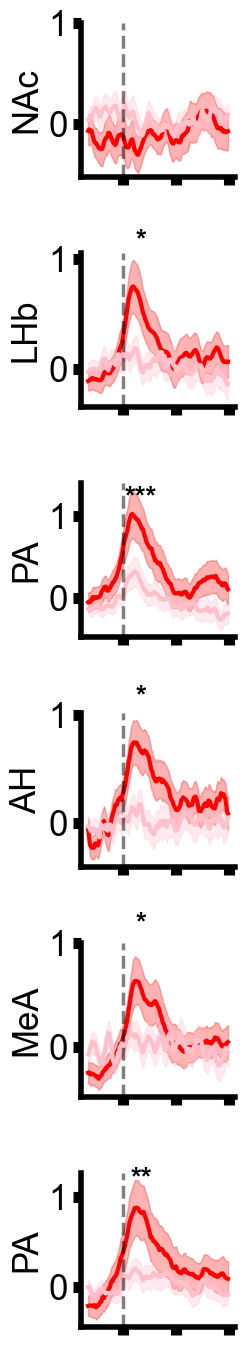

In [155]:
# Compare familiar vs novel PETHs

from matplotlib.ticker import MaxNLocator
start_idx = 200
end_idx = 360
periods = [start_idx, end_idx]
n = periods[1] - periods[0]

target_channels = [
    ('NAc (DA)', 22),
    ('LHb (E)',  18),
    ('PA (E)',   20),
    ('AH (I)',    9),
    ('MeA (E)',  10),
    ('PA (I)',   21),
]

fig, ax = plt.subplots(len(target_channels), 1, figsize=(3, 14))
familiar_color = 'red'
novel_color = 'pink'

def add_significance_to_plot(ax, post_pval, ylim_top, n):
    def get_sig_marker(p):
        if np.isnan(p):
            return ''
        elif p < 0.001:
            return '***'
        elif p < 0.01:
            return '**'
        elif p < 0.05:
            return '*'
        elif p < 0.075:
            return '#'
        else:
            return ''
    post_marker = get_sig_marker(post_pval)
    if post_marker:
        ax.text(60, ylim_top - 0.15, post_marker, ha='center', va='bottom',
                fontsize=20, fontweight='bold')

for i, (region_label, r) in enumerate(target_channels):
    fam_data = familiar_peths_across[:, :, r] - \
               np.nanmedian(familiar_peths_across[:, baseline[0]:baseline[1], r], axis=1).reshape(-1, 1)
    nov_data = novel_peths_across[:, :, r] - \
               np.nanmedian(novel_peths_across[:, baseline[0]:baseline[1], r], axis=1).reshape(-1, 1)

    ax[i].plot(np.nanmean(fam_data, axis=0)[periods[0]:periods[1]], label='familiar', color=familiar_color, linewidth=3)
    ax[i].fill_between(range(n),
        np.nanmean(fam_data, axis=0)[periods[0]:periods[1]] - np.nanstd(fam_data, axis=0)[periods[0]:periods[1]]/np.sqrt(fam_data.shape[0]),
        np.nanmean(fam_data, axis=0)[periods[0]:periods[1]] + np.nanstd(fam_data, axis=0)[periods[0]:periods[1]]/np.sqrt(fam_data.shape[0]),
        alpha=0.3, color=familiar_color)
    ax[i].plot(np.nanmean(nov_data, axis=0)[periods[0]:periods[1]], label='novel', color=novel_color, linewidth=3)
    ax[i].fill_between(range(n),
        np.nanmean(nov_data, axis=0)[periods[0]:periods[1]] - np.nanstd(nov_data, axis=0)[periods[0]:periods[1]]/np.sqrt(nov_data.shape[0]),
        np.nanmean(nov_data, axis=0)[periods[0]:periods[1]] + np.nanstd(nov_data, axis=0)[periods[0]:periods[1]]/np.sqrt(nov_data.shape[0]),
        alpha=0.3, color=novel_color)
    ax[i].axvline(40, linestyle='--', color='black', alpha=0.5)
    ax[i].set_xticks([40, 100, 160], ['', '', ''])
    ax[i].set_yticks([0, 1.0])
    ax[i].set_ylabel(region_label.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', ''), fontfamily='Arial')

    if region_ids[r] in pval_names:
        idx = pval_names.index(region_ids[r])
        add_significance_to_plot(ax[i], prep_pvals_corrected_NOVEL[idx], 1.2, n)

sns.despine()
fig.subplots_adjust(hspace=0.5)
plt.tight_layout()
# plt.savefig('./figures/fig3alt/fam_vs_novel_PETHs_culled.svg', dpi=300)
plt.show()

In [159]:
rows = []
for region_label, r in target_channels:
    clean_label = region_label.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')
    channel = 'DA' if '(DA)' in region_label else ('E' if '(E)' in region_label else 'I')

    fam_slice = (familiar_peths_across[:, :, r] - np.nanmedian(familiar_peths_across[:, baseline[0]:baseline[1], r], axis=1).reshape(-1, 1))[:, periods[0]:periods[1]].T
    nov_slice = (novel_peths_across[:, :, r] - np.nanmedian(novel_peths_across[:, baseline[0]:baseline[1], r], axis=1).reshape(-1, 1))[:, periods[0]:periods[1]].T
    # .T → (n_timepoints, n_trials)

    fam_mean = np.nanmean(fam_slice, axis=1)
    fam_sem  = np.nanstd(fam_slice, axis=1) / np.sqrt(fam_slice.shape[1])
    nov_mean = np.nanmean(nov_slice, axis=1)
    nov_sem  = np.nanstd(nov_slice, axis=1) / np.sqrt(nov_slice.shape[1])

    p_fdr = np.nan
    if region_ids[r] in pval_names:
        idx = pval_names.index(region_ids[r])
        p_fdr = prep_pvals_corrected_NOVEL[idx]

    for t in range(n):
        row = {
            'region': clean_label, 'channel': channel, 'timepoint': t,
            'familiar_mean': fam_mean[t], 'familiar_sem': fam_sem[t],
            'novel_mean': nov_mean[t], 'novel_sem': nov_sem[t],
            'p_fdr': p_fdr,
        }
        for a in range(fam_slice.shape[1]):
            row[f'familiar_trial_{a}'] = fam_slice[t, a]
        for a in range(nov_slice.shape[1]):
            row[f'novel_trial_{a}'] = nov_slice[t, a]
        rows.append(row)

sourceData_3f = pd.DataFrame(rows)
sourceData_3f.to_csv('./sourceData/3f_right.csv', index=False)

### Neural sensitivity to observed flight velocity during OBS

In [372]:
filt = np.where(all_occupancy_values > 200)[0]  # Example filter for occupancy > 0.5
combined_obs_data_filtered = combined_obs_data[filt, :, :]
all_spd_values_filtered = all_spd_values[filt]

# Get the sorting indices (ascending order of speed values)
sorted_indices = np.argsort(all_spd_values)
sorted_indices_filtered = np.argsort(all_spd_values_filtered)

# Sort the tensor using these indices
combined_obs_data_sorted = combined_obs_data[sorted_indices, :, :]
combined_obs_data_sorted = combined_obs_data_filtered[sorted_indices_filtered, :, :]

# Also sort the speed values to keep them aligned
all_spd_values_sorted = all_spd_values[sorted_indices]
all_spd_values_sorted = all_spd_values_filtered[sorted_indices_filtered]
intruder_indices = all_spd_values_sorted.copy()

print(f"Original tensor shape: {combined_obs_data.shape}")
print(f"Sorted tensor shape: {combined_obs_data_sorted.shape}")
print(f"Speed range: {all_spd_values_sorted[0]:.3f} to {all_spd_values_sorted[-1]:.3f}")

# Check that sorting is monotonically increasing
is_sorted = np.all(all_spd_values_sorted[:-1] <= all_spd_values_sorted[1:])
print(f"Is correctly sorted: {is_sorted}")

Original tensor shape: (1641, 480, 23)
Sorted tensor shape: (657, 480, 23)
Speed range: -0.631 to 15.602
Is correctly sorted: True


In [380]:
# Fast vs slow decoding adaptive thresholding (resident cues)
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
import warnings
from scipy import stats
from collections import Counter
warnings.filterwarnings("ignore")

# Define data
start    = 240
stop     = start + 80
baseline = [160, 240]

# Remove global percentile calculation - now done per region
target_n_high = None
target_n_low  = None

# --- Principled fold selection based on sample size ---
def get_n_splits(X, y, min_samples_per_fold=5, max_splits=10):
    min_class_count = np.min(np.bincount(y.astype(int)))
    k = int(min_class_count / min_samples_per_fold)
    k = max(2, min(k, max_splits))
    return k

def get_percentile_idx_targeted(spd_values1, features, target_n_high, target_n_low, pct=10, max_iter=50):
    """
    Get exactly target_n_high and target_n_low valid (non-NaN) trials by
    expanding the percentile window iteratively until targets are met.
    
    pct: starting percentile (e.g. 10 = top/bottom 10%)
    max_iter: safety cap on expansion iterations
    """
    valid_mask = ~np.isnan(features)
    
    step = 1.0  # expand by 1 percentile each iteration
    current_pct = pct
    
    for _ in range(max_iter):
        low_thresh  = np.nanpercentile(spd_values1, current_pct)
        high_thresh = np.nanpercentile(spd_values1, 100 - current_pct)
        
        candidate_low  = np.where(spd_values1 <= low_thresh)[0]
        candidate_high = np.where(spd_values1 >= high_thresh)[0]
        
        valid_low  = candidate_low[valid_mask[candidate_low]]
        valid_high = candidate_high[valid_mask[candidate_high]]
        
        if len(valid_low) >= target_n_low and len(valid_high) >= target_n_high:
            # Trim to exactly the target (keep the most extreme trials)
            valid_low  = valid_low[:target_n_low]    # spd sorted ascending, so first = lowest
            valid_high = valid_high[-target_n_high:] # last = highest
            return valid_low, valid_high
        
        current_pct += step
    
    # If we exhaust iterations, return whatever we have
    print(f"    Warning: could not reach target after {max_iter} expansions. "
          f"Returning {len(valid_low)}/{target_n_low} low, {len(valid_high)}/{target_n_high} high.")
    return valid_low, valid_high

def get_percentile_idx(spd_values, features, pct=10):
    """
    Compute percentile thresholds only on trials where features are non-NaN.
    Returns high and low indices into the original array.
    """
    valid_mask  = ~np.isnan(features)
    valid_spd   = spd_values[valid_mask]
    valid_idx   = np.where(valid_mask)[0]

    low_thresh  = np.nanpercentile(valid_spd, pct)
    high_thresh = np.nanpercentile(valid_spd, 100 - pct)

    low_idx  = valid_idx[valid_spd <= low_thresh]
    high_idx = valid_idx[valid_spd >= high_thresh]
    return low_idx, high_idx

# Inits
random_state = 42
E_idxs = [12, 16, 8, 4, 10, 20, 6, 0, 18, 22]
I_idxs = [13, 17, 9, 5, 11, 21, 7, 15, 3, 1]
sig_regions        = np.sort(np.array(E_idxs + I_idxs))
sig_regions_labels = [region_ids[idx] for idx in sig_regions]
print("Significant OBS regions:", sig_regions_labels)

param_grid = {
    'classifier__C':       [1.0, 10.0, 1e3, 1e5],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['liblinear']
}

results = {
    'region_accuracies':  [],
    'region_best_params': [],
    'region_cv_scores':   [],
    'region_grid_scores': [],
    'region_pvalues':     [],
    'region_significant': [],
    'region_n_splits':    [],
    'region_n_samples':   [],
    'region_n_high':      [],  # track per-region trial counts
    'region_n_low':       [],
}

for region in sig_regions:
    print(f"Processing region {region_ids[region]}...")

    region_mean_all = np.nanmean(
        combined_obs_data_sorted[:, start:stop, region] -
        np.nanmedian(combined_obs_data_sorted[:, baseline[0]:baseline[1], region],
                     axis=1, keepdims=True),
        axis=1
    )

    if target_n_high is None:
        # First region sets the target using the standard percentile
        low_idx, high_idx = get_percentile_idx(all_spd_values_sorted, region_mean_all)
        target_n_high = len(high_idx)
        target_n_low  = len(low_idx)
        print(f"  Targets set from first region: n_high={target_n_high}, n_low={target_n_low}")
    else:
        # Subsequent regions expand window until targets are met
        low_idx, high_idx = get_percentile_idx_targeted(
            all_spd_values_sorted, region_mean_all,
            target_n_high=target_n_high, target_n_low=target_n_low
        )
    
    print(f"  Low trials: {len(low_idx)}, High trials: {len(high_idx)}")

    # --- Recompute diff using region-specific valid trial sets ---
    high_diff = combined_obs_data_sorted[high_idx, start:stop, region] - \
                np.nanmedian(combined_obs_data_sorted[high_idx, baseline[0]:baseline[1], region],
                             axis=1, keepdims=True)
    low_diff  = combined_obs_data_sorted[low_idx,  start:stop, region] - \
                np.nanmedian(combined_obs_data_sorted[low_idx,  baseline[0]:baseline[1], region],
                             axis=1, keepdims=True)

    high_features = np.nanmean(high_diff, axis=1).reshape(-1, 1)
    low_features  = np.nanmean(low_diff,  axis=1).reshape(-1, 1)

    X = np.vstack([high_features, low_features])
    y = np.concatenate([np.zeros(len(high_features)),
                        np.ones(len(low_features))])

    valid_mask = ~np.any(np.isnan(X), axis=1) & ~np.any(np.isinf(X), axis=1)
    X_clean    = X[valid_mask]
    y_clean    = y[valid_mask]

    n_splits = get_n_splits(X_clean, y_clean, min_samples_per_fold=7, max_splits=10)
    print(f"  n={len(y_clean)}, using {n_splits}-fold CV.")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    pipeline = Pipeline([
        ('classifier', LogisticRegression(
            random_state=random_state,
            max_iter=1000
        ))
    ])

    try:
        grid_search = GridSearchCV(
            pipeline, param_grid,
            cv=cv, scoring='balanced_accuracy',
            n_jobs=-1, verbose=0
        )
        grid_search.fit(X_clean, y_clean)

        best_score  = grid_search.best_score_
        best_params = grid_search.best_params_

        final_cv_scores = cross_val_score(
            grid_search.best_estimator_, X_clean, y_clean,
            cv=cv, scoring='balanced_accuracy'
        )

        # ── Normality check → t-test or Wilcoxon against 0.5 ─────────────────
        clean_cv = final_cv_scores[~np.isnan(final_cv_scores)]
        shifted  = clean_cv - 0.5

        if len(clean_cv) >= 3:
            _, p_norm = stats.shapiro(clean_cv)
        else:
            p_norm = 0.0

        if p_norm > 0.05 and len(clean_cv) >= 3:
            t_stat, p_value = stats.ttest_1samp(clean_cv, 0.5,
                                                  alternative='greater')
            df_val     = len(clean_cv) - 1
            test_label = 't-test'
        else:
            try:
                t_stat, p_value = stats.wilcoxon(shifted,
                                                   alternative='greater')
            except ValueError:
                t_stat, p_value = np.nan, np.nan
            df_val     = None
            test_label = 'Wilcoxon'

        is_significant = p_value < 0.05 if not np.isnan(p_value) else False

        mean_score = np.mean(clean_cv)
        sem        = stats.sem(clean_cv)
        ci_95      = stats.t.interval(0.95, len(clean_cv) - 1,
                                       loc=mean_score, scale=sem) \
                     if len(clean_cv) > 1 else (np.nan, np.nan)

        df_str = f'df={df_val}' if df_val is not None else 'n/a'
        print(f"  Best CV score : {best_score:.3f} "
              f"(95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  Normality p   : {p_norm:.4f} "
              f"({'normal' if p_norm > 0.05 else 'non-normal'})")
        print(f"  Test          : {test_label}, "
              f"stat={t_stat:.3f}, {df_str}, "
              f"p={p_value:.4f}, sig={is_significant}")

        grid_results = {}
        for params, mean_score_grid, std_score in zip(
            grid_search.cv_results_['params'],
            grid_search.cv_results_['mean_test_score'],
            grid_search.cv_results_['std_test_score']
        ):
            param_key  = f"C={params['classifier__C']}, penalty={params['classifier__penalty']}"
            sem_grid   = std_score / np.sqrt(n_splits)
            ci_95_grid = stats.norm.interval(0.95, loc=mean_score_grid, scale=sem_grid)
            grid_results[param_key] = {'mean_score': mean_score_grid, 'ci_95': ci_95_grid}

        results['region_accuracies'].append(best_score)
        results['region_best_params'].append(best_params)
        results['region_cv_scores'].append(final_cv_scores)
        results['region_grid_scores'].append(grid_results)
        results['region_pvalues'].append(p_value)
        results['region_significant'].append(is_significant)
        results['region_n_splits'].append(n_splits)
        results['region_n_samples'].append(len(y_clean))
        results['region_n_high'].append(len(high_idx))
        results['region_n_low'].append(len(low_idx))
        results.setdefault('region_test_labels', []).append(test_label)
        results.setdefault('region_test_stats',  []).append(t_stat)
        results.setdefault('region_test_dfs',    []).append(df_val)
        results.setdefault('region_norm_p',      []).append(p_norm)

        print(f"  Best CV score: {best_score:.3f} (95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  t={t_stat:.3f}, p={p_value:.4f}, significant={is_significant}")

    except Exception as e:
        print(f"  Error: {e}")
        for key in ['region_accuracies', 'region_best_params', 'region_cv_scores',
                    'region_grid_scores', 'region_pvalues', 'region_significant',
                    'region_n_splits', 'region_n_samples', 'region_n_high', 'region_n_low']:
            results[key].append(np.nan if key not in ['region_best_params',
                                 'region_cv_scores', 'region_grid_scores',
                                 'region_significant'] else {} if 'params' in key
                                 or 'grid' in key else [] if 'scores' in key else False)

# --- Summary ---
accuracies          = [acc for acc in results['region_accuracies'] if not np.isnan(acc)]
significant_regions = np.sum(results['region_significant'])

if accuracies:
    above_chance = np.sum(np.array(accuracies) > 0.5)
    print(f"\nSUMMARY:")
    print(f"Regions above chance (>50%): {above_chance}/{len(accuracies)}")
    print(f"Regions with significant decoding (p<0.05): {significant_regions}/{len(accuracies)}")
    print(f"Mean accuracy: {np.mean(accuracies):.3f}")
    print(f"Best accuracy: {np.max(accuracies):.3f}")

    best_indices          = np.where(np.array(results['region_accuracies']) > 0.55)[0]
    sig_pvalues           = [results['region_pvalues'][i] for i in best_indices]
    sig_pvalues_corrected = multipletests(sig_pvalues, method='fdr_bh', alpha=0.05)[1]

    print(f"\nAbove chance regions:")
    for i in best_indices:
        if not np.isnan(results['region_accuracies'][i]):
            acc          = results['region_accuracies'][i]
            cv_scores    = results['region_cv_scores'][i]
            n_splits     = results['region_n_splits'][i]
            n_samples    = results['region_n_samples'][i]
            n_high       = results['region_n_high'][i]
            n_low        = results['region_n_low'][i]
            region_label = sig_regions_labels[i]
            p_val        = sig_pvalues_corrected[best_indices.tolist().index(i)]
            mean_score   = np.mean(cv_scores)
            sem          = stats.sem(cv_scores)
            ci_95        = stats.t.interval(0.95, len(cv_scores)-1,
                                             loc=mean_score, scale=sem)
            sig_marker   = "***" if p_val < 0.001 else "**" if p_val < 0.01 \
                           else "*" if p_val < 0.05 else ""
            print(f"  {region_label}: "
                  f"{acc:.3f} [{ci_95[0]:.3f}, {ci_95[1]:.3f}] "
                  f"p={p_val:.4f} {sig_marker} "
                  f"(n={n_samples}, high={n_high}, low={n_low}, k={n_splits})")

    print(f"\nParameter preferences:")
    all_c_values = [p.get('classifier__C') for p in results['region_best_params'] if p]
    print(f"  C values: {dict(Counter(all_c_values))}")

best_region_idx = np.nanargmax(results['region_accuracies'])
if not np.isnan(results['region_accuracies'][best_region_idx]):
    print(f"\nDetailed grid search for best region "
          f"({sig_regions_labels[best_region_idx]}):")
    for param_combo, scores in results['region_grid_scores'][best_region_idx].items():
        print(f"  {param_combo}: {scores['mean_score']:.3f} "
              f"[95% CI: {scores['ci_95'][0]:.3f}, {scores['ci_95'][1]:.3f}]")

Significant OBS regions: ['PrL (E)', 'PrL (I)', 'vLS (I)', 'POA (E)', 'POA (I)', 'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)', 'VMH (E)', 'VMH (I)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'PA (E)', 'PA (I)', 'NAc (DA)']
Processing region PrL (E)...
  Targets set from first region: n_high=66, n_low=66
  Low trials: 66, High trials: 66
  n=132, using 9-fold CV.
  Best CV score : 0.467 (95% CI: [0.375, 0.559])
  Normality p   : 0.0808 (normal)
  Test          : t-test, stat=-0.820, df=8, p=0.7820, sig=False
  Best CV score: 0.467 (95% CI: [0.375, 0.559])
  t=-0.820, p=0.7820, significant=False
Processing region PrL (I)...
  Low trials: 66, High trials: 66
  n=132, using 9-fold CV.
  Best CV score : 0.509 (95% CI: [0.424, 0.593])
  Normality p   : 0.5783 (normal)
  Test          : t-test, stat=0.244, df=8, p=0.4068, sig=False
  Best CV score: 0.509 (95% CI: [0.424, 0.593])
  t=0.244, p=0.4068, significant=False
Processing region vLS (I)...
  Low trials: 66, High tr

In [381]:
# ── Full stats table — fast vs slow decoding ──────────────────────────────────
print(f'\n{"="*110}')
print(f'Fast vs Slow decoding — full statistics table')
print(f'Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5')
print(f'Correction: FDR-BH across all {len(sig_regions)} regions')
print(f'{"="*110}')
print(f'{"Region":<22} {"Family":<10} {"Acc":>6} {"CI_lo":>7} {"CI_hi":>7} '
      f'{"Test":<10} {"df":>5} {"stat":>8} {"norm_p":>8} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5} '
      f'{"n_high":>7} {"n_low":>7} {"n_tot":>6} {"k":>4}')
print(f'{"─"*110}')

# ── define raw pvals first ────────────────────────────────────────────────────
all_pvals_raw = results['region_pvalues']

# ── Two correction families: NAc DA + LHb(E) vs E/I regions ──────────────────
neuromod_labels = ['NAc (DA)', 'LHb (E)']
neuromod_idx    = [i for i, l in enumerate(sig_regions_labels)
                   if any(nm in l for nm in neuromod_labels)]
ei_idx          = [i for i in range(len(sig_regions_labels))
                   if i not in neuromod_idx]

p_fdr_arr = np.full(len(all_pvals_raw), np.nan)

for family_idx, family_label in [(neuromod_idx, 'neuromod'),
                                   (ei_idx,       'E/I')]:
    valid_fam = [i for i in family_idx if not np.isnan(all_pvals_raw[i])]
    if valid_fam:
        _, corr, _, _ = multipletests(
            [all_pvals_raw[i] for i in valid_fam], method='fdr_bh')
        for rank, i in enumerate(valid_fam):
            p_fdr_arr[i] = corr[rank]
        print(f'  FDR family [{family_label}]: '
              f'{len(valid_fam)} comparisons — '
              f'regions: {[sig_regions_labels[i] for i in valid_fam]}')

def _f(v): return f'{v:.3f}' if not np.isnan(v) else '  n/a'

for i, region in enumerate(sig_regions):
    label      = sig_regions_labels[i]
    acc        = results['region_accuracies'][i]
    p_raw      = all_pvals_raw[i]
    p_fdr      = p_fdr_arr[i]
    n_high     = results['region_n_high'][i]
    n_low      = results['region_n_low'][i]
    n_tot      = results['region_n_samples'][i]
    k          = results['region_n_splits'][i]
    test_label = results['region_test_labels'][i] \
                 if 'region_test_labels' in results else 'n/a'
    t_s        = results['region_test_stats'][i] \
                 if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][i] \
                 if 'region_test_dfs' in results else None
    p_norm     = results['region_norm_p'][i] \
                 if 'region_norm_p' in results else np.nan

    if np.isnan(acc):
        print(f'  {label:<20} {"error":<6}')
        continue

    cv_scores = results['region_cv_scores'][i]
    clean_cv  = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
                if len(cv_scores) > 0 else np.array([])
    n_folds   = len(clean_cv)

    if len(clean_cv) > 1:
        se_cv = stats.sem(clean_cv)
        ci    = stats.t.interval(0.95, len(clean_cv) - 1,
                                  loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci = (np.nan, np.nan)

    df_str = str(df_val) if df_val is not None else 'n/a'
    sig    = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

    family = 'neuromod' if i in neuromod_idx else 'E/I'

    print(f'  {label:<20} {family:<10} {acc:>6.3f} {_f(ci[0]):>7} {_f(ci[1]):>7} '
          f'{test_label:<10} {df_str:>5} {_f(t_s):>8} {_f(p_norm):>8} '
          f'{p_raw:>10.4f} {p_fdr:>10.4f} {sig:>5} '
          f'{n_high:>7} {n_low:>7} {n_tot:>6} {k:>4}')

print(f'{"="*110}')
print(f'Note: Two FDR-BH correction families — '
      f'neuromod (NAc DA + LHb E, n={len(neuromod_idx)}) '
      f'and E/I regions (n={len(ei_idx)}).')
print(f'norm_p = Shapiro-Wilk p-value (>0.05 → t-test, ≤0.05 → Wilcoxon).')


Fast vs Slow decoding — full statistics table
Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5
Correction: FDR-BH across all 20 regions
Region                 Family        Acc   CI_lo   CI_hi Test          df     stat   norm_p      p_raw      p_fdr   Sig  n_high   n_low  n_tot    k
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  FDR family [neuromod]: 2 comparisons — regions: ['LHb (E)', 'NAc (DA)']
  FDR family [E/I]: 18 comparisons — regions: ['PrL (E)', 'PrL (I)', 'vLS (I)', 'POA (E)', 'POA (I)', 'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)', 'VMH (E)', 'VMH (I)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'PA (E)', 'PA (I)']
  PrL (E)              E/I         0.467   0.375   0.559 t-test         8   -0.820    0.081     0.7820     0.8280            66      66    132    9
  PrL (I)              E/I         0.509   0.424   0.593 t-test         8    0.244    0.578     0.

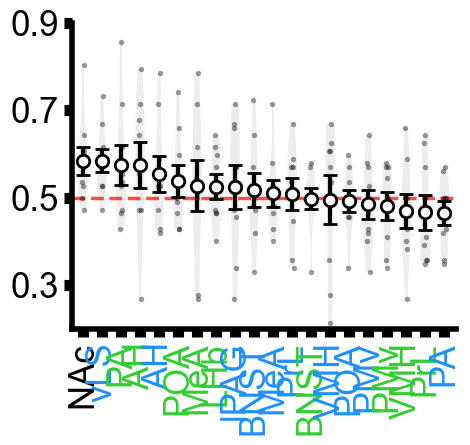

In [382]:
from scipy.stats import sem

# Plotting results from grid search
accuracies = np.array(results['region_accuracies'])
valid_mask = ~np.isnan(accuracies)
valid_accuracies = accuracies[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Sort by accuracy (descending)
sorting = np.argsort(valid_accuracies)[::-1]
sorted_accuracies = valid_accuracies[sorting]
sorted_indices = valid_indices[sorting]

# Calculate SEM from CV scores
stds = []
for idx in sorted_indices:
    cv_scores = results['region_cv_scores'][idx]
    if len(cv_scores) > 1:
        clean_scores = cv_scores[~np.isnan(cv_scores)]
        if len(clean_scores) > 1:
            stds.append(sem(clean_scores))
        else:
            stds.append(0)
    else:
        stds.append(0)
stds = np.array(stds)

n_valid_regions = len(sorted_accuracies)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(5.25, 5))

# ── Overlay individual fold scores as jittered scatter (behind mean marker) ──
rng = np.random.default_rng(42)
for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    cv_scores    = results['region_cv_scores'][idx]
    clean_scores = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
                   if len(cv_scores) > 0 else np.array([])
    if len(clean_scores) == 0:
        continue
    jitter = rng.uniform(-0.08, 0.08, size=len(clean_scores))
    ax.scatter(np.full(len(clean_scores), xpos) + jitter,
               clean_scores, color='black', s=15,
               alpha=0.4, zorder=3, linewidths=0)
    parts = ax.violinplot(clean_scores, positions=[xpos], widths=0.5,
                      showmeans=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('lightgray')
        pc.set_alpha(0.4)
        pc.set_zorder(1)
    

# ── Mean ± SEM marker ──────────────────────────────────────────────────────────
ax.errorbar(range(n_valid_regions), sorted_accuracies, yerr=stds,
           fmt='o', color='black', markerfacecolor='white',
           markersize=9, markeredgewidth=2,
           capsize=5, capthick=3, elinewidth=3, zorder=5)

# Create x-tick labels with colors based on cell type and remove parentheses
tick_labels = []
tick_colors = []
for i in sorted_indices:
    label = sig_regions_labels[i]
    clean_label = label.split('(')[0].strip()
    tick_labels.append(clean_label)

    if '(DA)' in label:
        tick_colors.append('black')
    elif '(E)' in label:
        tick_colors.append('limegreen')
    elif '(I)' in label:
        tick_colors.append('dodgerblue')
    else:
        tick_colors.append('black')

tick_labels = np.where(tick_labels == 'VMH', 'VMHvl', tick_labels)
tick_labels = np.where(tick_labels == 'PAG', 'lPAG', tick_labels)

ax.set_xticks(range(n_valid_regions))
ax.set_xticklabels(tick_labels, rotation=90, fontfamily='Arial')

for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
    tick_label.set_color(color)

plt.yticks([0.3, 0.5, 0.7, 0.9], fontfamily='Arial')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Chance level (50%)')
ax.set_xlim(-0.6, n_valid_regions - 0.4)
ax.set_ylim(0.2, 0.9)
sns.despine()
plt.tight_layout()
# plt.savefig('./figure_updates/intruder-fast-vs-slow-attacks.svg',
#            dpi=300, bbox_inches='tight', pad_inches=0.1)

In [376]:
# Get source data

def clean_region_label(label):
    clean = label.split('(')[0].strip()
    if clean == 'VMH':
        clean = 'VMHvl'
    elif clean == 'PAG':
        clean = 'lPAG'
    return clean

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

rows = []

for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    label       = sig_regions_labels[idx]
    region_name = clean_region_label(label)
    channel     = channel_from_label(label)
    family      = 'neuromod' if idx in neuromod_idx else 'E/I'

    cv_scores = results['region_cv_scores'][idx]
    clean_cv  = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] if len(cv_scores) > 0 else np.array([])

    acc   = results['region_accuracies'][idx]
    p_raw = all_pvals_raw[idx]
    p_fdr = p_fdr_arr[idx]

    n_high = results['region_n_high'][idx]
    n_low  = results['region_n_low'][idx]
    n_tot  = results['region_n_samples'][idx]
    k      = results['region_n_splits'][idx]

    test_label = results['region_test_labels'][idx] if 'region_test_labels' in results else np.nan
    stat_val   = results['region_test_stats'][idx] if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][idx] if 'region_test_dfs' in results else np.nan
    p_norm     = results['region_norm_p'][idx] if 'region_norm_p' in results else np.nan

    if len(clean_cv) > 1:
        se_cv = sem(clean_cv)
        ci_lo, ci_hi = stats.t.interval(0.95, len(clean_cv) - 1, loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci_lo, ci_hi = np.nan, np.nan

    sig = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

    for fold_idx, score in enumerate(clean_cv):
        rows.append({
            'x_position': xpos,
            'region': region_name,
            'channel': channel,
            'fdr_family': family,
            'fold_idx': fold_idx,
            'cv_accuracy': score,
            'mean_accuracy': acc,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'test': test_label,
            'df': df_val,
            'stat': stat_val,
            'norm_p': p_norm,
            'p_raw': p_raw,
            'p_fdr': p_fdr,
            'sig': sig,
            'n_high': n_high,
            'n_low': n_low,
            'n_total': n_tot,
            'k_splits': k,
            'n_folds': len(clean_cv),
        })

sourceData_3d_bottom_left = pd.DataFrame(rows)

DA: Hi vs low p-value: 0.003676
LHb: Hi vs low p-value: 0.781874

High vs Low intruder speed — mean activity in window [40:80] frames
Comparison: high-speed trials vs low-speed trials (unpaired)
Region       Test                              Stat       df    p_value   Sig  n_high   n_low   mean_high   mean_low
────────────────────────────────────────────────────────────────────────────────────────────────────
  NAc (DA)   t-test (Student)                 2.723    130.0     0.0037    **      66      66      0.6598     0.2539
    Levene: F=2.932, p=0.0893 (equal variance assumed)
  LHb (E)    Brunner-Munzel                   0.781      n/a     0.7819            66      66      0.2398     0.2793
    Levene: F=0.000, p=0.9839 (equal variance assumed)
Window: frames 40–80 post-event (1–2s at 40fps)
Trials: top/bottom 66 by intruder speed


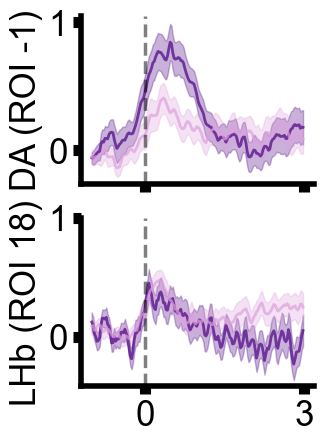

In [377]:
# Create figure with 2 subplots stacked vertically
fig, axes = plt.subplots(2, 1, figsize=(3, 4.8), sharex=True)
ntrials = low_idx.shape[0]
from scipy.stats import shapiro, mannwhitneyu

# --- TOP PLOT: ROI = -1 (DA) ---
ax_top = axes[0]

# Extract high and low speed trials with baseline correction for ROI -1
roi = -1
region_high = combined_obs_data_sorted[-ntrials:, 200:360, roi] - np.nanmedian(
    combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], roi], axis=1, keepdims=True
)
region_low = combined_obs_data_sorted[:ntrials, 200:360, roi] - np.nanmedian(
    combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], roi], axis=1, keepdims=True
)

print('DA: Hi vs low p-value: %f' % toy_stats([np.nanmean(region_high[:, 40:80], axis=1), np.nanmean(region_low[:, 40:80], axis=1)], alpha=0.05)['balbc_vs_toy']['p_value'])

# Plot high speed
ax_top.plot(np.nanmean(region_high, axis=0), color='indigo', label='High Speed', alpha=0.7, linewidth=2)
ax_top.fill_between(range(160), 
                    np.nanmean(region_high, axis=0) - stats.sem(region_high, axis=0, nan_policy='omit'), 
                    np.nanmean(region_high, axis=0) + stats.sem(region_high, axis=0, nan_policy='omit'), 
                    color='indigo', alpha=0.3)

# Plot low speed
ax_top.plot(np.nanmean(region_low, axis=0), color='plum', label='Low Speed', alpha=0.7, linewidth=2)
ax_top.fill_between(range(160), 
                    np.nanmean(region_low, axis=0) - stats.sem(region_low, axis=0, nan_policy='omit'), 
                    np.nanmean(region_low, axis=0) + stats.sem(region_low, axis=0, nan_policy='omit'), 
                    color='plum', alpha=0.3)

# Formatting for top plot
ax_top.axvline(40, linestyle='--', color='black', alpha=0.5)
ax_top.set_yticks([0, 1])
ax_top.set_yticklabels([0, 1], fontfamily='Arial')
ax_top.set_ylabel('DA (ROI -1)', fontfamily='Arial')

# --- BOTTOM PLOT: ROI = 18 (LHb) ---
ax_bottom = axes[1]

# Extract high and low speed trials with baseline correction for ROI 18
region_high = combined_obs_data_sorted[-ntrials:, 200:360, 18] - np.nanmedian(
    combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], 18], axis=1, keepdims=True
)
region_low = combined_obs_data_sorted[:ntrials, 200:360, 18] - np.nanmedian(
    combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], 18], axis=1, keepdims=True
)

print('LHb: Hi vs low p-value: %f' % toy_stats([np.nanmean(region_high[:, 40:80], axis=1), np.nanmean(region_low[:, 40:80], axis=1)], alpha=0.05)['balbc_vs_toy']['p_value'])

# Plot high speed
ax_bottom.plot(np.nanmean(region_high, axis=0), color='indigo', label='High Speed', alpha=0.7, linewidth=2)
ax_bottom.fill_between(range(160), 
                    np.nanmean(region_high, axis=0) - stats.sem(region_high, axis=0, nan_policy='omit'), 
                    np.nanmean(region_high, axis=0) + stats.sem(region_high, axis=0, nan_policy='omit'), 
                    color='indigo', alpha=0.3)

# Plot low speed
ax_bottom.plot(np.nanmean(region_low, axis=0), color='plum', label='Low Speed', alpha=0.7, linewidth=2)
ax_bottom.fill_between(range(160), 
                    np.nanmean(region_low, axis=0) - stats.sem(region_low, axis=0, nan_policy='omit'), 
                    np.nanmean(region_low, axis=0) + stats.sem(region_low, axis=0, nan_policy='omit'), 
                    color='plum', alpha=0.3)

# Formatting for bottom plot
ax_bottom.axvline(40, linestyle='--', color='black', alpha=0.5)
ax_bottom.set_xticks([40, 160])
ax_bottom.set_xticklabels([0, 3], fontfamily='Arial')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_yticklabels([0, 1], fontfamily='Arial')
ax_bottom.set_ylabel('LHb (ROI 18)', fontfamily='Arial')
sns.despine()


# ── Stats table ───────────────────────────────────────────────────────────────
regions_to_test = [
    ('NAc (DA)', -1),
    ('LHb (E)',  18),
]

print(f'\n{"="*100}')
print(f'High vs Low intruder speed — mean activity in window [40:80] frames')
print(f'Comparison: high-speed trials vs low-speed trials (unpaired)')
print(f'{"="*100}')
print(f'{"Region":<12} {"Test":<28} {"Stat":>9} {"df":>8} {"p_value":>10} {"Sig":>5} '
      f'{"n_high":>7} {"n_low":>7} {"mean_high":>11} {"mean_low":>10}')
print(f'{"─"*100}')

for region_label, roi in regions_to_test:
    hi = combined_obs_data_sorted[-ntrials:, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], roi],
        axis=1, keepdims=True)
    lo = combined_obs_data_sorted[:ntrials, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], roi],
        axis=1, keepdims=True)

    hi_vals = np.nanmean(hi[:, 40:80], axis=1)
    lo_vals = np.nanmean(lo[:, 40:80], axis=1)
    hi_vals = hi_vals[~np.isnan(hi_vals)]
    lo_vals = lo_vals[~np.isnan(lo_vals)]

    _, p_hi = shapiro(hi_vals) if len(hi_vals) >= 3 else (None, 0)
    _, p_lo = shapiro(lo_vals) if len(lo_vals) >= 3 else (None, 0)
    normal = p_hi > 0.05 and p_lo > 0.05

    levene_stat, levene_p = levene(hi_vals, lo_vals)
    equal_var = levene_p > 0.05

    if normal:
        stat, p = ttest_ind(hi_vals, lo_vals, alternative='greater', equal_var=equal_var)
        n1, n2 = len(hi_vals), len(lo_vals)
        if equal_var:
            df = n1 + n2 - 2
            test_label = 't-test (Student)'
        else:
            v1, v2 = np.var(hi_vals, ddof=1), np.var(lo_vals, ddof=1)
            df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
            test_label = 't-test (Welch)'
    else:
        stat, p = brunnermunzel(hi_vals, lo_vals, alternative='greater')
        df = np.nan
        test_label = 'Brunner-Munzel'

    sig = get_sig(p)
    df_str = f'{df:.1f}' if not np.isnan(df) else 'n/a'
    print(f'  {region_label:<10} {test_label:<28} {stat:>9.3f} {df_str:>8} {p:>10.4f} '
          f'{sig:>5} {len(hi_vals):>7} {len(lo_vals):>7} '
          f'{np.nanmean(hi_vals):>11.4f} {np.nanmean(lo_vals):>10.4f}')
    print(f'    Levene: F={levene_stat:.3f}, p={levene_p:.4f} '
          f'({"equal" if equal_var else "unequal"} variance assumed)')

print(f'{"="*100}')
print(f'Window: frames 40–80 post-event (1–2s at 40fps)')
print(f'Trials: top/bottom {ntrials} by intruder speed')

In [379]:
regions_to_test = [
    ('NAc (DA)', -1),
    ('LHb (E)',  18),
]

rows = []

for region_label, roi in regions_to_test:
    clean_label = region_label.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

    hi_slice = (combined_obs_data_sorted[-ntrials:, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], roi], axis=1, keepdims=True))
    lo_slice = (combined_obs_data_sorted[:ntrials, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], roi], axis=1, keepdims=True))
    # shape: (n_trials, n_timepoints) — transpose for (timepoint, trial)
    hi_slice_t = hi_slice.T
    lo_slice_t = lo_slice.T

    hi_mean = np.nanmean(hi_slice, axis=0)
    hi_sem  = stats.sem(hi_slice, axis=0, nan_policy='omit')
    lo_mean = np.nanmean(lo_slice, axis=0)
    lo_sem  = stats.sem(lo_slice, axis=0, nan_policy='omit')

    # window stats (frames 40:80 post-event, matching the stats-table cell)
    hi_vals = np.nanmean(hi_slice[:, 40:80], axis=1)
    lo_vals = np.nanmean(lo_slice[:, 40:80], axis=1)
    hi_vals = hi_vals[~np.isnan(hi_vals)]
    lo_vals = lo_vals[~np.isnan(lo_vals)]

    _, p_hi = shapiro(hi_vals) if len(hi_vals) >= 3 else (None, 0)
    _, p_lo = shapiro(lo_vals) if len(lo_vals) >= 3 else (None, 0)

    if p_hi > 0.05 and p_lo > 0.05:
        stat, p = ttest_ind(hi_vals, lo_vals, alternative='greater')
        test_label = 't-test (unpaired)'
    else:
        stat, p = brunnermunzel(hi_vals, lo_vals, alternative='greater')
        test_label = 'Mann-Whitney U'

    n_time = hi_slice.shape[1]
    for t in range(n_time):
        row = {
            'region': clean_label, 'timepoint': t,
            'high_speed_mean': hi_mean[t], 'high_speed_sem': hi_sem[t],
            'low_speed_mean': lo_mean[t], 'low_speed_sem': lo_sem[t],
            'window_test': test_label, 'window_stat': stat, 'window_p': p,
            'n_high': len(hi_vals), 'n_low': len(lo_vals),
        }
        for trial_idx in range(hi_slice_t.shape[1]):
            row[f'high_speed_trial_{trial_idx}'] = hi_slice_t[t, trial_idx]
        for trial_idx in range(lo_slice_t.shape[1]):
            row[f'low_speed_trial_{trial_idx}'] = lo_slice_t[t, trial_idx]
        rows.append(row)

sourceData_3d_right = pd.DataFrame(rows)
sourceData_3d_right.to_csv('./sourceData/3d_right.csv', index=False)

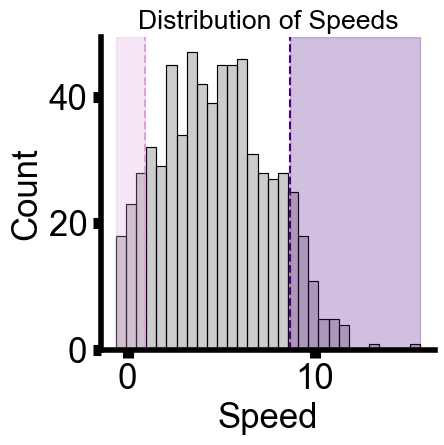

In [171]:
# Plot distribution of speeds with decoding trial regions highlighted
pct = 10
low_thresh  = np.nanpercentile(all_spd_values_sorted, pct)
high_thresh = np.nanpercentile(all_spd_values_sorted, 100 - pct)

fig, ax = plt.subplots(figsize=(5, 5))

# Base distribution
sns.histplot(all_spd_values_filtered, bins=30, kde=False, ax=ax,
             color='gray', alpha=0.4, label='All trials')

# Shade low-speed region
ax.axvspan(all_spd_values_filtered.min(), low_thresh,
           alpha=0.25, color='plum', label=f'Low trials (≤{pct}th pct, n={target_n_low})')

# Shade high-speed region
ax.axvspan(high_thresh, all_spd_values_filtered.max(),
           alpha=0.25, color='indigo', label=f'High trials (≥{100-pct}th pct, n={target_n_high})')

# Threshold lines
ax.axvline(low_thresh,  color='plum', linestyle='--', linewidth=1.5,
           label=f'Low thresh = {low_thresh:.2f}')
ax.axvline(high_thresh, color='indigo', linestyle='--', linewidth=1.5,
           label=f'High thresh = {high_thresh:.2f}')

ax.set_title('Distribution of Speeds', fontfamily='Arial')
ax.set_xlabel('Speed', fontfamily='Arial')
ax.set_ylabel('Count', fontfamily='Arial')
# ax.legend(fontsize=8, frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('.//figures/fig3/intruder_spd_distributions.svg', dpi=300)

In [191]:
sourceData_3d_top_left = pd.DataFrame({
    'speed_value': all_spd_values_filtered,
})
sourceData_3d_top_left['low_threshold'] = low_thresh
sourceData_3d_top_left['high_threshold'] = high_thresh
sourceData_3d_top_left['percentile_cutoff'] = pct
sourceData_3d_top_left['n_low_trials'] = target_n_low
sourceData_3d_top_left['n_high_trials'] = target_n_high

sourceData_3d_top_left.to_csv('./sourceData/3d_top_left.csv', index=False)

### Neural sensitivity to aggressor attack velocity

In [362]:
# Get the sorting indices (ascending order of speed values)
filt = np.where(all_occupancy_values > 200)[0]  # Example filter for occupancy > 0.5
combined_obs_data_filtered = combined_obs_data[filt, :, :]
all_spd2_values_filtered = all_spd2_values[filt]

# Get the sorting indices (ascending order of speed values)
sorted_indices = np.argsort(all_spd2_values)
sorted_indices_filtered = np.argsort(all_spd2_values_filtered)
resident_indices = sorted_indices_filtered.copy()

# Sort the tensor using these indices
combined_obs_data_sorted = combined_obs_data[sorted_indices, :, :]
combined_obs_data_sorted = combined_obs_data_filtered[sorted_indices_filtered, :, :]

# Also sort the speed values to keep them aligned
all_spd2_values_sorted = all_spd2_values[sorted_indices]
all_spd2_values_sorted = all_spd2_values_filtered[sorted_indices_filtered]

print(f"Original tensor shape: {combined_obs_data.shape}")
print(f"Sorted tensor shape: {combined_obs_data_sorted.shape}")
print(f"Speed range: {all_spd2_values_sorted[0]:.3f} to {all_spd2_values_sorted[-1]:.3f}")

# Check that sorting is monotonically increasing
is_sorted = np.all(all_spd2_values_sorted[:-1] <= all_spd2_values_sorted[1:])
print(f"Is correctly sorted: {is_sorted}")

Original tensor shape: (1641, 480, 23)
Sorted tensor shape: (657, 480, 23)
Speed range: -0.561 to 10.774
Is correctly sorted: True


In [363]:
# Fast vs slow decoding adaptive thresholding (resident cues)
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score
import warnings
from scipy import stats
from collections import Counter
warnings.filterwarnings("ignore")
from sklearn.inspection import permutation_importance
from sklearn.model_selection import permutation_test_score

# Define data
start    = 240
stop     = start + 80
# baseline = [120, 200]
baseline = [160, 240]

# Remove global percentile calculation - now done per region
target_n_high = None
target_n_low  = None

# --- Principled fold selection based on sample size ---
def get_n_splits(X, y, min_samples_per_fold=5, max_splits=10):
    min_class_count = np.min(np.bincount(y.astype(int)))
    k = int(min_class_count / min_samples_per_fold)
    k = max(2, min(k, max_splits))
    return k

def get_percentile_idx_targeted(spd_values2, features, target_n_high, target_n_low, pct=10, max_iter=50):
    """
    Get exactly target_n_high and target_n_low valid (non-NaN) trials by
    expanding the percentile window iteratively until targets are met.
    
    pct: starting percentile (e.g. 10 = top/bottom 10%)
    max_iter: safety cap on expansion iterations
    """
    valid_mask = ~np.isnan(features)
    
    step = 1.0  # expand by 1 percentile each iteration
    current_pct = pct
    
    for _ in range(max_iter):
        low_thresh  = np.nanpercentile(spd_values2, current_pct)
        high_thresh = np.nanpercentile(spd_values2, 100 - current_pct)
        
        candidate_low  = np.where(spd_values2 <= low_thresh)[0]
        candidate_high = np.where(spd_values2 >= high_thresh)[0]
        
        valid_low  = candidate_low[valid_mask[candidate_low]]
        valid_high = candidate_high[valid_mask[candidate_high]]
        
        if len(valid_low) >= target_n_low and len(valid_high) >= target_n_high:
            # Trim to exactly the target (keep the most extreme trials)
            valid_low  = valid_low[:target_n_low]    # spd sorted ascending, so first = lowest
            valid_high = valid_high[-target_n_high:] # last = highest
            return valid_low, valid_high
        
        current_pct += step
    
    # If we exhaust iterations, return whatever we have
    print(f"    Warning: could not reach target after {max_iter} expansions. "
          f"Returning {len(valid_low)}/{target_n_low} low, {len(valid_high)}/{target_n_high} high.")
    return valid_low, valid_high

def get_percentile_idx(spd_values2, features, pct=10):
    """
    Compute percentile thresholds only on trials where features are non-NaN.
    Returns high and low indices into the original array.
    """
    valid_mask  = ~np.isnan(features)
    valid_spd   = spd_values2[valid_mask]
    valid_idx   = np.where(valid_mask)[0]

    low_thresh  = np.nanpercentile(valid_spd, pct)
    high_thresh = np.nanpercentile(valid_spd, 100 - pct)

    low_idx  = valid_idx[valid_spd <= low_thresh]
    high_idx = valid_idx[valid_spd >= high_thresh]
    return low_idx, high_idx

# Inits
random_state = 42

param_grid = {
    'classifier__C':       [0.01, 0.1, 1.0, 10.0, 1e3, 1e5],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['liblinear']
}

results = {
    'region_accuracies':  [],
    'region_best_params': [],
    'region_cv_scores':   [],
    'region_grid_scores': [],
    'region_pvalues':     [],
    'region_significant': [],
    'region_n_splits':    [],
    'region_n_samples':   [],
    'region_n_high':      [],  # track per-region trial counts
    'region_n_low':       [],
}

for region in sig_regions:
    print(f"Processing region {region_ids[region]}...")

    region_mean_all = np.nanmean(
        combined_obs_data_sorted[:, start:stop, region] -
        np.nanmedian(combined_obs_data_sorted[:, baseline[0]:baseline[1], region],
                     axis=1, keepdims=True),
        axis=1
    )

    if target_n_high is None:
        # First region sets the target using the standard percentile
        low_idx, high_idx = get_percentile_idx(all_spd2_values_sorted, region_mean_all)
        target_n_high = len(high_idx)
        target_n_low  = len(low_idx)
        print(f"  Targets set from first region: n_high={target_n_high}, n_low={target_n_low}")
    else:
        # Subsequent regions expand window until targets are met
        low_idx, high_idx = get_percentile_idx_targeted(
            all_spd2_values_sorted, region_mean_all,
            target_n_high=target_n_high, target_n_low=target_n_low
        )
    
    print(f"  Low trials: {len(low_idx)}, High trials: {len(high_idx)}")

    # --- Recompute diff using region-specific valid trial sets ---
    high_diff = combined_obs_data_sorted[high_idx, start:stop, region] - \
                np.nanmedian(combined_obs_data_sorted[high_idx, baseline[0]:baseline[1], region],
                             axis=1, keepdims=True)
    low_diff  = combined_obs_data_sorted[low_idx,  start:stop, region] - \
                np.nanmedian(combined_obs_data_sorted[low_idx,  baseline[0]:baseline[1], region],
                             axis=1, keepdims=True)

    high_features = np.nanmean(high_diff, axis=1).reshape(-1, 1)
    low_features  = np.nanmean(low_diff,  axis=1).reshape(-1, 1)

    X = np.vstack([high_features, low_features])
    y = np.concatenate([np.zeros(len(high_features)),
                        np.ones(len(low_features))])

    valid_mask = ~np.any(np.isnan(X), axis=1) & ~np.any(np.isinf(X), axis=1)
    X_clean    = X[valid_mask]
    y_clean    = y[valid_mask]

    n_splits = get_n_splits(X_clean, y_clean, min_samples_per_fold=7, max_splits=10)
    print(f"  n={len(y_clean)}, using {n_splits}-fold CV.")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    pipeline = Pipeline([
        ('classifier', LogisticRegression(
            random_state=random_state,
            max_iter=1000
        ))
    ])

    try:
        grid_search = GridSearchCV(
            pipeline, param_grid,
            cv=cv, scoring='balanced_accuracy',
            n_jobs=-1, verbose=0
        )
        grid_search.fit(X_clean, y_clean)

        best_score  = grid_search.best_score_
        best_params = grid_search.best_params_

        final_cv_scores = cross_val_score(
            grid_search.best_estimator_, X_clean, y_clean,
            cv=cv, scoring='balanced_accuracy'
        )

        # ── Normality check → t-test or Wilcoxon against 0.5 ─────────────────
        clean_cv = final_cv_scores[~np.isnan(final_cv_scores)]
        shifted  = clean_cv - 0.5

        if len(clean_cv) >= 3:
            _, p_norm = stats.shapiro(clean_cv)
        else:
            p_norm = 0.0

        if p_norm > 0.05 and len(clean_cv) >= 3:
            t_stat, p_value = stats.ttest_1samp(clean_cv, 0.5,
                                                  alternative='greater')
            df_val     = len(clean_cv) - 1
            test_label = 't-test'
        else:
            try:
                t_stat, p_value = stats.wilcoxon(shifted,
                                                   alternative='greater')
            except ValueError:
                t_stat, p_value = np.nan, np.nan
            df_val     = None
            test_label = 'Wilcoxon'

        is_significant = p_value < 0.05 if not np.isnan(p_value) else False

        mean_score = np.mean(clean_cv)
        sem        = stats.sem(clean_cv)
        ci_95      = stats.t.interval(0.95, len(clean_cv) - 1,
                                       loc=mean_score, scale=sem) \
                     if len(clean_cv) > 1 else (np.nan, np.nan)

        df_str = f'df={df_val}' if df_val is not None else 'n/a'
        print(f"  Best CV score : {best_score:.3f} "
              f"(95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  Normality p   : {p_norm:.4f} "
              f"({'normal' if p_norm > 0.05 else 'non-normal'})")
        print(f"  Test          : {test_label}, "
              f"stat={t_stat:.3f}, {df_str}, "
              f"p={p_value:.4f}, sig={is_significant}")

        results['region_accuracies'].append(best_score)
        results['region_best_params'].append(best_params)
        results['region_cv_scores'].append(final_cv_scores)
        results['region_grid_scores'].append(grid_results)
        results['region_pvalues'].append(p_value)
        results['region_significant'].append(is_significant)
        results['region_n_splits'].append(n_splits)
        results['region_n_samples'].append(len(y_clean))
        results['region_n_high'].append(len(high_idx))
        results['region_n_low'].append(len(low_idx))
        results.setdefault('region_test_labels', []).append(test_label)
        results.setdefault('region_test_stats',  []).append(t_stat)
        results.setdefault('region_test_dfs',    []).append(df_val)
        results.setdefault('region_norm_p',      []).append(p_norm)
        print(f"  Best CV score: {best_score:.3f} (95% CI: [{ci_95[0]:.3f}, {ci_95[1]:.3f}])")
        print(f"  t={t_stat:.3f}, p={p_value:.4f}, significant={is_significant}")

    except Exception as e:
        print(f"  Error: {e}")
        for key in ['region_accuracies', 'region_best_params', 'region_cv_scores',
                    'region_grid_scores', 'region_pvalues', 'region_significant',
                    'region_n_splits', 'region_n_samples', 'region_n_high', 'region_n_low']:
            results[key].append(np.nan if key not in ['region_best_params',
                                 'region_cv_scores', 'region_grid_scores',
                                 'region_significant'] else {} if 'params' in key
                                 or 'grid' in key else [] if 'scores' in key else False)

# --- Summary ---
accuracies          = [acc for acc in results['region_accuracies'] if not np.isnan(acc)]
significant_regions = np.sum(results['region_significant'])

if accuracies:
    above_chance = np.sum(np.array(accuracies) > 0.5)
    print(f"\nSUMMARY:")
    print(f"Regions above chance (>50%): {above_chance}/{len(accuracies)}")
    print(f"Regions with significant decoding (p<0.05): {significant_regions}/{len(accuracies)}")
    print(f"Mean accuracy: {np.mean(accuracies):.3f}")
    print(f"Best accuracy: {np.max(accuracies):.3f}")

    best_indices          = np.where(np.array(results['region_accuracies']) > 0.55)[0]
    sig_pvalues           = [results['region_pvalues'][i] for i in best_indices]
    sig_pvalues_corrected = multipletests(sig_pvalues, method='fdr_bh', alpha=0.05)[1]

    print(f"\nAbove chance regions:")
    for i in best_indices:
        if not np.isnan(results['region_accuracies'][i]):
            acc          = results['region_accuracies'][i]
            cv_scores    = results['region_cv_scores'][i]
            n_splits     = results['region_n_splits'][i]
            n_samples    = results['region_n_samples'][i]
            n_high       = results['region_n_high'][i]
            n_low        = results['region_n_low'][i]
            region_label = sig_regions_labels[i]
            p_val        = sig_pvalues_corrected[best_indices.tolist().index(i)]
            mean_score   = np.mean(cv_scores)
            sem          = stats.sem(cv_scores)
            ci_95        = stats.t.interval(0.95, len(cv_scores)-1,
                                             loc=mean_score, scale=sem)
            sig_marker   = "***" if p_val < 0.001 else "**" if p_val < 0.01 \
                           else "*" if p_val < 0.05 else ""
            print(f"  {region_label}: "
                  f"{acc:.3f} [{ci_95[0]:.3f}, {ci_95[1]:.3f}] "
                  f"p={p_val:.4f} {sig_marker} "
                  f"(n={n_samples}, high={n_high}, low={n_low}, k={n_splits})")

    print(f"\nParameter preferences:")
    all_c_values = [p.get('classifier__C') for p in results['region_best_params'] if p]
    print(f"  C values: {dict(Counter(all_c_values))}")

best_region_idx = np.nanargmax(results['region_accuracies'])
if not np.isnan(results['region_accuracies'][best_region_idx]):
    print(f"\nDetailed grid search for best region "
          f"({sig_regions_labels[best_region_idx]}):")
    for param_combo, scores in results['region_grid_scores'][best_region_idx].items():
        print(f"  {param_combo}: {scores['mean_score']:.3f} "
              f"[95% CI: {scores['ci_95'][0]:.3f}, {scores['ci_95'][1]:.3f}]")

Processing region PrL (E)...
  Targets set from first region: n_high=66, n_low=66
  Low trials: 66, High trials: 66
  n=132, using 9-fold CV.
  Best CV score : 0.500 (95% CI: [nan, nan])
  Normality p   : 1.0000 (normal)
  Test          : t-test, stat=nan, df=8, p=nan, sig=False
  Best CV score: 0.500 (95% CI: [nan, nan])
  t=nan, p=nan, significant=False
Processing region PrL (I)...
  Low trials: 66, High trials: 66
  n=132, using 9-fold CV.
  Best CV score : 0.504 (95% CI: [0.434, 0.574])
  Normality p   : 0.9754 (normal)
  Test          : t-test, stat=0.132, df=8, p=0.4493, sig=False
  Best CV score: 0.504 (95% CI: [0.434, 0.574])
  t=0.132, p=0.4493, significant=False
Processing region vLS (I)...
  Low trials: 66, High trials: 66
  n=132, using 9-fold CV.
  Best CV score : 0.543 (95% CI: [0.423, 0.662])
  Normality p   : 0.3520 (normal)
  Test          : t-test, stat=0.822, df=8, p=0.2175, sig=False
  Best CV score: 0.543 (95% CI: [0.423, 0.662])
  t=0.822, p=0.2175, significant=Fa

In [364]:
# ── Full stats table — intruder speed decoding ────────────────────────────────
print(f'\n{"="*115}')
print(f'Fast vs Slow (intruder speed) decoding — full statistics table')
print(f'Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5')
print(f'Correction: FDR-BH within two families — neuromod (NAc DA + LHb E) and E/I')
print(f'{"="*115}')
print(f'{"Region":<22} {"Family":<10} {"Acc":>6} {"CI_lo":>7} {"CI_hi":>7} '
      f'{"Test":<10} {"df":>5} {"stat":>8} {"norm_p":>8} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5} '
      f'{"n_high":>7} {"n_low":>7} {"n_tot":>6} {"k":>4}')
print(f'{"─"*115}')

# ── define raw pvals ──────────────────────────────────────────────────────────
all_pvals_raw = results['region_pvalues']

# ── two correction families ───────────────────────────────────────────────────
neuromod_labels = ['NAc (DA)', 'LHb (E)']
neuromod_idx    = [i for i, l in enumerate(sig_regions_labels)
                   if any(nm in l for nm in neuromod_labels)]
ei_idx          = [i for i in range(len(sig_regions_labels))
                   if i not in neuromod_idx]

p_fdr_arr = np.full(len(all_pvals_raw), np.nan)

for family_idx, family_label in [(neuromod_idx, 'neuromod'),
                                   (ei_idx,       'E/I')]:
    valid_fam = [i for i in family_idx
                 if not np.isnan(all_pvals_raw[i])]
    if valid_fam:
        _, corr, _, _ = multipletests(
            [all_pvals_raw[i] for i in valid_fam], method='fdr_bh')
        for rank, i in enumerate(valid_fam):
            p_fdr_arr[i] = corr[rank]
        print(f'  FDR family [{family_label}]: '
              f'{len(valid_fam)} comparisons — '
              f'regions: {[sig_regions_labels[i] for i in valid_fam]}')

print(f'{"─"*115}')

def _f(v): return f'{v:.3f}' if not np.isnan(v) else '  n/a'

for i, region in enumerate(sig_regions):
    label      = sig_regions_labels[i]
    acc        = results['region_accuracies'][i]
    p_raw      = all_pvals_raw[i]
    p_fdr      = p_fdr_arr[i]
    n_high     = results['region_n_high'][i]
    n_low      = results['region_n_low'][i]
    n_tot      = results['region_n_samples'][i]
    k          = results['region_n_splits'][i]
    test_label = results['region_test_labels'][i] \
                 if 'region_test_labels' in results else 'n/a'
    t_s        = results['region_test_stats'][i] \
                 if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][i] \
                 if 'region_test_dfs' in results else None
    p_norm     = results['region_norm_p'][i] \
                 if 'region_norm_p' in results else np.nan
    family     = 'neuromod' if i in neuromod_idx else 'E/I'

    if np.isnan(acc):
        print(f'  {label:<20} {family:<10} {"error"}')
        continue

    cv_scores = results['region_cv_scores'][i]
    clean_cv  = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
                if len(cv_scores) > 0 else np.array([])
    n_folds   = len(clean_cv)

    if len(clean_cv) > 1:
        se_cv = stats.sem(clean_cv)
        ci    = stats.t.interval(0.95, len(clean_cv) - 1,
                                  loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci = (np.nan, np.nan)

    df_str = str(df_val) if df_val is not None else 'n/a'
    sig    = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

    print(f'  {label:<20} {family:<10} {acc:>6.3f} {_f(ci[0]):>7} {_f(ci[1]):>7} '
          f'{test_label:<10} {df_str:>5} {_f(t_s):>8} {_f(p_norm):>8} '
          f'{p_raw:>10.4f} {p_fdr:>10.4f} {sig:>5} '
          f'{n_high:>7} {n_low:>7} {n_tot:>6} {k:>4}')

print(f'{"="*115}')
print(f'Note: Two FDR-BH correction families — '
      f'neuromod (NAc DA + LHb E, n={len(neuromod_idx)}) '
      f'and E/I regions (n={len(ei_idx)}).')
print(f'norm_p = Shapiro-Wilk p-value (>0.05 → t-test, ≤0.05 → Wilcoxon).')
print(f'k = number of CV folds used per region.')


Fast vs Slow (intruder speed) decoding — full statistics table
Test: Shapiro-Wilk normality → t-test (normal) or Wilcoxon (non-normal), one-sided vs 0.5
Correction: FDR-BH within two families — neuromod (NAc DA + LHb E) and E/I
Region                 Family        Acc   CI_lo   CI_hi Test          df     stat   norm_p      p_raw      p_fdr   Sig  n_high   n_low  n_tot    k
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  FDR family [neuromod]: 1 comparisons — regions: ['NAc (DA)']
  FDR family [E/I]: 8 comparisons — regions: ['PrL (I)', 'vLS (I)', 'POA (E)', 'POA (I)', 'AH (E)', 'AH (I)', 'VMH (E)', 'PA (E)']
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  PrL (E)              E/I         0.500     n/a     n/a t-test         8      n/a    1.000        nan        nan   n/a      66      66    132    9
  PrL (I)              E/I         0.504   0.434 

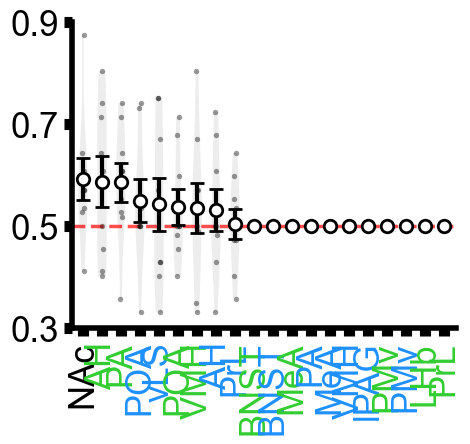

In [365]:
from scipy.stats import sem

# Plotting results from grid search
accuracies = np.array(results['region_accuracies'])
valid_mask = ~np.isnan(accuracies)
valid_accuracies = accuracies[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Sort by accuracy (descending)
sorting = np.argsort(valid_accuracies)[::-1]
sorted_accuracies = valid_accuracies[sorting]
sorted_indices = valid_indices[sorting]

# Calculate SEM from CV scores
stds = []
for idx in sorted_indices:
    cv_scores = results['region_cv_scores'][idx]
    if len(cv_scores) > 1:
        clean_scores = cv_scores[~np.isnan(cv_scores)]
        if len(clean_scores) > 1:
            stds.append(sem(clean_scores))
        else:
            stds.append(0)
    else:
        stds.append(0)
stds = np.array(stds)

n_valid_regions = len(sorted_accuracies)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(5.25, 5))

# ── Overlay individual fold scores as jittered scatter (behind mean marker) ──
rng = np.random.default_rng(42)
for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    cv_scores    = results['region_cv_scores'][idx]
    clean_scores = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] \
                   if len(cv_scores) > 0 else np.array([])
    if len(clean_scores) == 0:
        continue
    jitter = rng.uniform(-0.08, 0.08, size=len(clean_scores))
    ax.scatter(np.full(len(clean_scores), xpos) + jitter,
               clean_scores, color='black', s=15,
               alpha=0.4, zorder=3, linewidths=0)
    parts = ax.violinplot(clean_scores, positions=[xpos], widths=0.5,
                      showmeans=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor('lightgray')
        pc.set_alpha(0.4)
        pc.set_zorder(1)
    

# ── Mean ± SEM marker ──────────────────────────────────────────────────────────
ax.errorbar(range(n_valid_regions), sorted_accuracies, yerr=stds,
           fmt='o', color='black', markerfacecolor='white',
           markersize=9, markeredgewidth=2,
           capsize=5, capthick=3, elinewidth=3, zorder=5)

# Create x-tick labels with colors based on cell type and remove parentheses
tick_labels = []
tick_colors = []
for i in sorted_indices:
    label = sig_regions_labels[i]
    clean_label = label.split('(')[0].strip()
    tick_labels.append(clean_label)

    if '(DA)' in label:
        tick_colors.append('black')
    elif '(E)' in label:
        tick_colors.append('limegreen')
    elif '(I)' in label:
        tick_colors.append('dodgerblue')
    else:
        tick_colors.append('black')

tick_labels = np.where(tick_labels == 'VMH', 'VMHvl', tick_labels)
tick_labels = np.where(tick_labels == 'PAG', 'lPAG', tick_labels)

ax.set_xticks(range(n_valid_regions))
ax.set_xticklabels(tick_labels, rotation=90, fontfamily='Arial')

for tick_label, color in zip(ax.get_xticklabels(), tick_colors):
    tick_label.set_color(color)

plt.yticks([0.3, 0.5, 0.7, 0.9], fontfamily='Arial')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Chance level (50%)')
ax.set_xlim(-0.6, n_valid_regions - 0.4)
ax.set_ylim(0.3, 0.9)
sns.despine()
plt.tight_layout()
# plt.savefig('./figure_updates/resident-fast-vs-slow-attacks.svg',
#            dpi=300, bbox_inches='tight', pad_inches=0.1)

In [366]:
# Get source data

def clean_region_label(label):
    clean = label.split('(')[0].strip()
    if clean == 'VMH':
        clean = 'VMHvl'
    elif clean == 'PAG':
        clean = 'lPAG'
    return clean

def channel_from_label(label):
    if '(DA)' in label: return 'DA'
    if '(E)' in label:  return 'E'
    if '(I)' in label:  return 'I'
    return 'unlabeled'

rows = []

for xpos, idx in zip(range(n_valid_regions), sorted_indices):
    label       = sig_regions_labels[idx]
    region_name = clean_region_label(label)
    channel     = channel_from_label(label)
    family      = 'neuromod' if idx in neuromod_idx else 'E/I'

    cv_scores = results['region_cv_scores'][idx]
    clean_cv  = np.array(cv_scores)[~np.isnan(np.array(cv_scores))] if len(cv_scores) > 0 else np.array([])

    acc   = results['region_accuracies'][idx]
    p_raw = all_pvals_raw[idx]
    p_fdr = p_fdr_arr[idx]

    n_high = results['region_n_high'][idx]
    n_low  = results['region_n_low'][idx]
    n_tot  = results['region_n_samples'][idx]
    k      = results['region_n_splits'][idx]

    test_label = results['region_test_labels'][idx] if 'region_test_labels' in results else np.nan
    stat_val   = results['region_test_stats'][idx] if 'region_test_stats' in results else np.nan
    df_val     = results['region_test_dfs'][idx] if 'region_test_dfs' in results else np.nan
    p_norm     = results['region_norm_p'][idx] if 'region_norm_p' in results else np.nan

    if len(clean_cv) > 1:
        se_cv = sem(clean_cv)
        ci_lo, ci_hi = stats.t.interval(0.95, len(clean_cv) - 1, loc=np.mean(clean_cv), scale=se_cv)
    else:
        ci_lo, ci_hi = np.nan, np.nan

    sig = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

    for fold_idx, score in enumerate(clean_cv):
        rows.append({
            'x_position': xpos,
            'region': region_name,
            'channel': channel,
            'fdr_family': family,
            'fold_idx': fold_idx,
            'cv_accuracy': score,
            'mean_accuracy': acc,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
            'test': test_label,
            'df': df_val,
            'stat': stat_val,
            'norm_p': p_norm,
            'p_raw': p_raw,
            'p_fdr': p_fdr,
            'sig': sig,
            'n_high': n_high,
            'n_low': n_low,
            'n_total': n_tot,
            'k_splits': k,
            'n_folds': len(clean_cv),
        })

sourceData_placeholder = pd.DataFrame(rows)
sourceData_placeholder.to_csv('./sourceData/3c_bottom_left.csv')  # rename once confirmed

DA: Hi vs low p-value: 0.009889
LHb: Hi vs low p-value: 0.544765

High vs Low resident speed — mean activity in region-specific windows
Comparison: high-speed trials vs low-speed trials (unpaired)
Region           Window Test                        Stat    p_value   Sig  n_high   n_low   mean_high   mean_low
───────────────────────────────────────────────────────────────────────────
  NAc (DA)   t-test (Student)                 2.360    130.0     0.0099    **      66      66      0.4848     0.2150
    Levene: F=0.353, p=0.5537 (equal variance assumed)
  LHb (E)    Brunner-Munzel                   0.113      n/a     0.5448            66      66      0.2183     0.2627
    Levene: F=3.601, p=0.0600 (equal variance assumed)
NAc (DA) window: frames 40–160 post-event (1–3s at 40fps)
LHb (E)  window: frames 40–80  post-event (1–2s at 40fps)
Trials: top/bottom 66 by resident speed


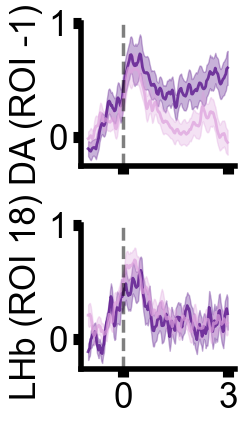

In [367]:
# Create figure with 2 subplots stacked vertically
fig, axes = plt.subplots(2, 1, figsize=(3, 4.8), sharex=True)
ntrials = low_idx.shape[0]

# --- TOP PLOT: ROI = -1 (DA) ---
ax_top = axes[0]

# Extract high and low speed trials with baseline correction for ROI -1
roi = -1
region_high = combined_obs_data_sorted[-ntrials:, 200:360, roi] - np.nanmedian(
    combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], roi], axis=1, keepdims=True
)
region_low = combined_obs_data_sorted[:ntrials, 200:360, roi] - np.nanmedian(
    combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], roi], axis=1, keepdims=True
)

print('DA: Hi vs low p-value: %f' % toy_stats([np.nanmean(region_high[:, 40:160], axis=1), np.nanmean(region_low[:, 40:160], axis=1)], alpha=0.05)['balbc_vs_toy']['p_value'])

# Plot high speed
ax_top.plot(np.nanmean(region_high, axis=0), color='indigo', label='High Speed', alpha=0.7, linewidth=2)
ax_top.fill_between(range(160), 
                    np.nanmean(region_high, axis=0) - stats.sem(region_high, axis=0, nan_policy='omit'), 
                    np.nanmean(region_high, axis=0) + stats.sem(region_high, axis=0, nan_policy='omit'), 
                    color='indigo', alpha=0.3)

# Plot low speed
ax_top.plot(np.nanmean(region_low, axis=0), color='plum', label='Low Speed', alpha=0.7, linewidth=2)
ax_top.fill_between(range(160), 
                    np.nanmean(region_low, axis=0) - stats.sem(region_low, axis=0, nan_policy='omit'), 
                    np.nanmean(region_low, axis=0) + stats.sem(region_low, axis=0, nan_policy='omit'), 
                    color='plum', alpha=0.3)

# Formatting for top plot
ax_top.axvline(40, linestyle='--', color='black', alpha=0.5)
ax_top.set_yticks([0, 1])
ax_top.set_yticklabels([0, 1], fontfamily='Arial')
ax_top.set_ylabel('DA (ROI -1)', fontfamily='Arial')

# --- BOTTOM PLOT: ROI = 18 (LHb) ---
ax_bottom = axes[1]

# Extract high and low speed trials with baseline correction for ROI 18
region_high = combined_obs_data_sorted[-ntrials:, 200:360, 18] - np.nanmedian(
    combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], 18], axis=1, keepdims=True
)
region_low = combined_obs_data_sorted[:ntrials, 200:360, 18] - np.nanmedian(
    combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], 18], axis=1, keepdims=True
)

print('LHb: Hi vs low p-value: %f' % toy_stats([np.nanmean(region_high[:, 40:160], axis=1), np.nanmean(region_low[:, 40:160], axis=1)], alpha=0.05)['balbc_vs_toy']['p_value'])

# Plot high speed
ax_bottom.plot(np.nanmean(region_high, axis=0), color='indigo', label='High Speed', alpha=0.7, linewidth=2)
ax_bottom.fill_between(range(160), 
                    np.nanmean(region_high, axis=0) - stats.sem(region_high, axis=0, nan_policy='omit'), 
                    np.nanmean(region_high, axis=0) + stats.sem(region_high, axis=0, nan_policy='omit'), 
                    color='indigo', alpha=0.3)

# Plot low speed
ax_bottom.plot(np.nanmean(region_low, axis=0), color='plum', label='Low Speed', alpha=0.7, linewidth=2)
ax_bottom.fill_between(range(160), 
                    np.nanmean(region_low, axis=0) - stats.sem(region_low, axis=0, nan_policy='omit'), 
                    np.nanmean(region_low, axis=0) + stats.sem(region_low, axis=0, nan_policy='omit'), 
                    color='plum', alpha=0.3)

# Formatting for bottom plot
ax_bottom.axvline(40, linestyle='--', color='black', alpha=0.5)
ax_bottom.set_xticks([40, 160])
ax_bottom.set_xticklabels([0, 3], fontfamily='Arial')
ax_bottom.set_yticks([0, 1])
ax_bottom.set_yticklabels([0, 1], fontfamily='Arial')
ax_bottom.set_ylabel('LHb (ROI 18)', fontfamily='Arial')
sns.despine()

# ── Stats table ───────────────────────────────────────────────────────────────
regions_to_test = [
    ('NAc (DA)', -1,  40, 160),   # window 40:160
    ('LHb (E)',  18,  40,  160),   # window 40:160
]

print(f'\n{"="*75}')
print(f'High vs Low resident speed — mean activity in region-specific windows')
print(f'Comparison: high-speed trials vs low-speed trials (unpaired)')
print(f'{"="*75}')
print(f'{"Region":<12} {"Window":>10} {"Test":<22} {"Stat":>9} {"p_value":>10} '
      f'{"Sig":>5} {"n_high":>7} {"n_low":>7} {"mean_high":>11} {"mean_low":>10}')
print(f'{"─"*75}')

for region_label, roi, w0, w1 in regions_to_test:
    hi = combined_obs_data_sorted[-ntrials:, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], roi],
        axis=1, keepdims=True)
    lo = combined_obs_data_sorted[:ntrials, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], roi],
        axis=1, keepdims=True)

    hi_vals = np.nanmean(hi[:, w0:w1], axis=1)
    lo_vals = np.nanmean(lo[:, w0:w1], axis=1)
    hi_vals = hi_vals[~np.isnan(hi_vals)]
    lo_vals = lo_vals[~np.isnan(lo_vals)]

    _, p_hi = shapiro(hi_vals) if len(hi_vals) >= 3 else (None, 0)
    _, p_lo = shapiro(lo_vals) if len(lo_vals) >= 3 else (None, 0)
    normal = p_hi > 0.05 and p_lo > 0.05

    levene_stat, levene_p = levene(hi_vals, lo_vals)
    equal_var = levene_p > 0.05

    if normal:
        stat, p = ttest_ind(hi_vals, lo_vals, alternative='greater', equal_var=equal_var)
        n1, n2 = len(hi_vals), len(lo_vals)
        if equal_var:
            df = n1 + n2 - 2
            test_label = 't-test (Student)'
        else:
            v1, v2 = np.var(hi_vals, ddof=1), np.var(lo_vals, ddof=1)
            df = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
            test_label = 't-test (Welch)'
    else:
        stat, p = brunnermunzel(hi_vals, lo_vals, alternative='greater')
        df = np.nan
        test_label = 'Brunner-Munzel'

    sig = get_sig(p)
    df_str = f'{df:.1f}' if not np.isnan(df) else 'n/a'
    print(f'  {region_label:<10} {test_label:<28} {stat:>9.3f} {df_str:>8} {p:>10.4f} '
          f'{sig:>5} {len(hi_vals):>7} {len(lo_vals):>7} '
          f'{np.nanmean(hi_vals):>11.4f} {np.nanmean(lo_vals):>10.4f}')
    print(f'    Levene: F={levene_stat:.3f}, p={levene_p:.4f} '
          f'({"equal" if equal_var else "unequal"} variance assumed)')

print(f'{"="*75}')
print(f'NAc (DA) window: frames 40–160 post-event (1–3s at 40fps)')
print(f'LHb (E)  window: frames 40–80  post-event (1–2s at 40fps)')
print(f'Trials: top/bottom {ntrials} by resident speed')

plt.tight_layout()
# plt.savefig('./figures/fig3/DA_LHb_resident_speeds.svg', dpi=300, bbox_inches='tight')
plt.show()

In [370]:
regions_to_test = [
    ('NAc (DA)', -1,  40, 160),
    ('LHb (E)',  18,  40, 160),  
]

rows = []

for region_label, roi, w0, w1 in regions_to_test:
    clean_label = region_label.replace(' (E)', '').replace(' (I)', '').replace(' (DA)', '')

    hi_slice = (combined_obs_data_sorted[-ntrials:, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[-ntrials:, baseline[0]:baseline[1], roi], axis=1, keepdims=True))
    lo_slice = (combined_obs_data_sorted[:ntrials, 200:360, roi] - np.nanmedian(
        combined_obs_data_sorted[:ntrials, baseline[0]:baseline[1], roi], axis=1, keepdims=True))
    hi_slice_t = hi_slice.T
    lo_slice_t = lo_slice.T

    hi_mean = np.nanmean(hi_slice, axis=0)
    hi_sem  = stats.sem(hi_slice, axis=0, nan_policy='omit')
    lo_mean = np.nanmean(lo_slice, axis=0)
    lo_sem  = stats.sem(lo_slice, axis=0, nan_policy='omit')

    hi_vals = np.nanmean(hi_slice[:, w0:w1], axis=1)
    lo_vals = np.nanmean(lo_slice[:, w0:w1], axis=1)
    hi_vals = hi_vals[~np.isnan(hi_vals)]
    lo_vals = lo_vals[~np.isnan(lo_vals)]

    _, p_hi = shapiro(hi_vals) if len(hi_vals) >= 3 else (None, 0)
    _, p_lo = shapiro(lo_vals) if len(lo_vals) >= 3 else (None, 0)

    if p_hi > 0.05 and p_lo > 0.05:
        stat, p = ttest_ind(hi_vals, lo_vals, alternative='greater')
        test_label = 't-test (unpaired)'
    else:
        stat, p = brunnermunzel(hi_vals, lo_vals, alternative='greater')
        test_label = 'Brunner-Munzel'

    n_time = hi_slice.shape[1]
    for t in range(n_time):
        row = {
            'region': clean_label, 'timepoint': t,
            'high_speed_mean': hi_mean[t], 'high_speed_sem': hi_sem[t],
            'low_speed_mean': lo_mean[t], 'low_speed_sem': lo_sem[t],
            'window_start': w0, 'window_end': w1,
            'window_test': test_label, 'window_stat': stat, 'window_p': p,
            'n_high': len(hi_vals), 'n_low': len(lo_vals),
        }
        for trial_idx in range(hi_slice_t.shape[1]):
            row[f'high_speed_trial_{trial_idx}'] = hi_slice_t[t, trial_idx]
        for trial_idx in range(lo_slice_t.shape[1]):
            row[f'low_speed_trial_{trial_idx}'] = lo_slice_t[t, trial_idx]
        rows.append(row)

sourceData_3c_right = pd.DataFrame(rows)
sourceData_3c_right.to_csv('./sourceData/3c_right.csv', index=False)

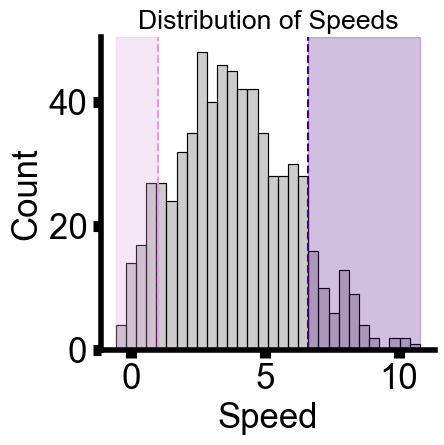

In [199]:
# Plot distribution of speeds with decoding trial regions highlighted
pct = 10
low_thresh  = np.nanpercentile(all_spd2_values_sorted, pct)
high_thresh = np.nanpercentile(all_spd2_values_sorted, 100 - pct)

fig, ax = plt.subplots(figsize=(5, 5))

# Base distribution
sns.histplot(all_spd2_values_filtered, bins=30, kde=False, ax=ax,
             color='gray', alpha=0.4, label='All trials')

# Shade low-speed region
ax.axvspan(all_spd2_values_filtered.min(), low_thresh,
           alpha=0.25, color='plum', label=f'Low trials (≤{pct}th pct, n={target_n_low})')

# Shade high-speed region
ax.axvspan(high_thresh, all_spd2_values_filtered.max(),
           alpha=0.25, color='indigo', label=f'High trials (≥{100-pct}th pct, n={target_n_high})')

# Threshold lines
ax.axvline(low_thresh,  color='plum', linestyle='--', linewidth=1.5,
           label=f'Low thresh = {low_thresh:.2f}')
ax.axvline(high_thresh, color='indigo', linestyle='--', linewidth=1.5,
           label=f'High thresh = {high_thresh:.2f}')

ax.set_title('Distribution of Speeds', fontfamily='Arial')
ax.set_xlabel('Speed', fontfamily='Arial')
ax.set_ylabel('Count', fontfamily='Arial')
# ax.legend(fontsize=8, frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('.//figures/fig3/resident_spd_distributions.svg', dpi=300)

In [203]:
sourceData_3c_top_left = pd.DataFrame({
    'speed_value': all_spd2_values_filtered,
})
sourceData_3c_top_left['low_threshold'] = low_thresh
sourceData_3c_top_left['high_threshold'] = high_thresh
sourceData_3c_top_left['percentile_cutoff'] = pct
sourceData_3c_top_left['n_low_trials'] = target_n_low
sourceData_3c_top_left['n_high_trials'] = target_n_high

sourceData_3c_top_left.to_csv('./sourceData/3c_top_left.csv', index=False)